In [2]:
# ============================================================
# Cell 1. External food-system indicators preprocessing
# Project: AI-food research attention vs food-system needs
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
# 이 노트북 파일과 02~11번 csv/pdf 파일이 같은 폴더에 있다고 가정
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

FILES = {
    "population": DATA_DIR / "02_wb_population_SP.POP.TOTL_raw.csv",
    "gdp": DATA_DIR / "03_wb_gdp_current_usd_NY.GDP.MKTP.CD_raw.csv",
    "rd": DATA_DIR / "04_wb_rd_expenditure_GB.XPD.RSDV.GD.ZS_raw.csv",
    "undernourishment": DATA_DIR / "05_wb_undernourishment_SN.ITK.DEFC.ZS_raw.csv",
    "stunting": DATA_DIR / "06_wb_child_stunting_SH.STA.STNT.ZS_raw.csv",
    "obesity": DATA_DIR / "07_wb_adult_obesity_by_sex_SH.STA.OB18.FE-MA.ZS_raw.csv",
    "food_waste_pdf": DATA_DIR / "08_unep_food_waste_index_report_2024_raw.pdf",
    "ghg": DATA_DIR / "09_faostat_agrifood_ghg_emissions_raw.csv",
    "cereal": DATA_DIR / "10_fao_cereal_import_dependency_raw.csv",
    "metadata": DATA_DIR / "11_wb_country_metadata_income_region_raw.csv",
}

missing_files = [name for name, path in FILES.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing files: {missing_files}")

print("All required files found.")


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def clean_columns(df):
    """Clean column names and remove unnamed columns."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~pd.Index(df.columns).str.match(r"^Unnamed")]
    return df


def normalize_country_name(x):
    """Normalize country names for rough matching."""
    x = str(x).lower().strip()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    x = re.sub(r"\([^)]*\)", "", x)
    x = x.replace("&", "and")
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def read_wb_wide_csv(path, value_name):
    """
    Read World Bank WDI CSV format:
    first 4 rows are metadata, then years are wide columns.
    """
    df = pd.read_csv(path, skiprows=4)
    df = clean_columns(df)

    id_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
    year_cols = [c for c in df.columns if re.fullmatch(r"\d{4}", str(c))]

    long = df.melt(
        id_vars=id_cols,
        value_vars=year_cols,
        var_name="year",
        value_name=value_name
    )

    long["year"] = pd.to_numeric(long["year"], errors="coerce").astype("Int64")
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")

    long = long.rename(
        columns={
            "Country Name": "country",
            "Country Code": "iso3",
            "Indicator Name": "indicator_name",
            "Indicator Code": "indicator_code",
        }
    )

    long = long.dropna(subset=[value_name])
    return long


def latest_available_by_iso3(df, value_col, year_col="year"):
    """Take latest available non-missing value by country."""
    use = df.dropna(subset=[value_col]).copy()
    use[year_col] = pd.to_numeric(use[year_col], errors="coerce")
    use = use.dropna(subset=[year_col])

    use = use.sort_values(["iso3", year_col])
    out = use.groupby("iso3", as_index=False).tail(1)

    out = out[["iso3", "country", year_col, value_col]].copy()
    out = out.rename(columns={year_col: f"{value_col}_year"})
    return out.reset_index(drop=True)


def read_country_metadata(path):
    """Read World Bank country metadata and keep individual countries."""
    meta = pd.read_csv(path)
    meta = clean_columns(meta)

    meta = meta.rename(
        columns={
            "Country Code": "iso3",
            "TableName": "country",
            "Region": "region",
            "IncomeGroup": "income_group",
        }
    )

    # Region이 비어 있으면 보통 World, OECD, High income 같은 aggregate
    meta["region"] = meta["region"].replace("", pd.NA)
    meta = meta.dropna(subset=["region"]).copy()

    # 일부 실제 국가에서 IncomeGroup이 비어 있을 수 있음
    meta["income_group"] = meta["income_group"].replace("", pd.NA)
    meta["income_group"] = meta["income_group"].fillna("Not classified")

    meta = meta[["iso3", "country", "region", "income_group"]].drop_duplicates("iso3")
    return meta


# ------------------------------------------------------------
# 2. Country metadata
# ------------------------------------------------------------
country_meta = read_country_metadata(FILES["metadata"])
print(f"Country metadata: {country_meta.shape[0]} countries/territories")


# ------------------------------------------------------------
# 3. World Bank indicators: 02–06
# ------------------------------------------------------------
wb_indicators = {
    "population": FILES["population"],
    "gdp_current_usd": FILES["gdp"],
    "rd_expenditure_pct_gdp": FILES["rd"],
    "undernourishment_pct": FILES["undernourishment"],
    "child_stunting_pct": FILES["stunting"],
}

latest_tables = []

for value_name, path in wb_indicators.items():
    df_long = read_wb_wide_csv(path, value_name)
    df_latest = latest_available_by_iso3(df_long, value_name)
    latest_tables.append(df_latest.drop(columns=["country"]))

    print(
        f"{value_name}: "
        f"{df_latest.shape[0]} countries, "
        f"latest year max = {df_latest[value_name + '_year'].max()}"
    )


# ------------------------------------------------------------
# 4. Adult obesity by sex: 07
# ------------------------------------------------------------
obesity = pd.read_csv(FILES["obesity"])
obesity = clean_columns(obesity)

obesity = obesity.rename(
    columns={
        "Country Name": "country",
        "Country Code": "iso3",
        "Year": "year",
        "Value": "value",
        "Disaggregation": "sex",
    }
)

obesity["year"] = pd.to_numeric(obesity["year"], errors="coerce")
obesity["value"] = pd.to_numeric(obesity["value"], errors="coerce")

# female/male 평균으로 adult_obesity_pct 생성
obesity_avg = (
    obesity.dropna(subset=["value"])
    .pivot_table(
        index=["iso3", "country", "year"],
        columns="sex",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)

for col in ["female", "male"]:
    if col not in obesity_avg.columns:
        obesity_avg[col] = np.nan

obesity_avg["adult_obesity_pct"] = obesity_avg[["female", "male"]].mean(axis=1)

obesity_latest = latest_available_by_iso3(
    obesity_avg[["iso3", "country", "year", "adult_obesity_pct"]],
    "adult_obesity_pct"
)

print(
    f"adult_obesity_pct: {obesity_latest.shape[0]} countries, "
    f"latest year max = {obesity_latest['adult_obesity_pct_year'].max()}"
)


# ------------------------------------------------------------
# 5. FAOSTAT / FAO agrifood-system GHG emissions: 09
# ------------------------------------------------------------
ghg = pd.read_csv(FILES["ghg"])
ghg = clean_columns(ghg)

ghg = ghg.rename(
    columns={
        "REF_AREA": "iso3",
        "REF_AREA_LABEL": "country",
        "TIME_PERIOD": "year",
        "OBS_VALUE": "agrifood_ghg_ktco2eq",
    }
)

ghg["year"] = pd.to_numeric(ghg["year"], errors="coerce")
ghg["agrifood_ghg_ktco2eq"] = pd.to_numeric(
    ghg["agrifood_ghg_ktco2eq"],
    errors="coerce"
)

ghg_latest = latest_available_by_iso3(
    ghg[["iso3", "country", "year", "agrifood_ghg_ktco2eq"]],
    "agrifood_ghg_ktco2eq"
)

print(
    f"agrifood_ghg_ktco2eq: {ghg_latest.shape[0]} countries, "
    f"latest year max = {ghg_latest['agrifood_ghg_ktco2eq_year'].max()}"
)


# ------------------------------------------------------------
# 6. Cereal import dependency ratio: 10
# ------------------------------------------------------------
cereal = pd.read_csv(FILES["cereal"])
cereal = clean_columns(cereal)

print("Cereal raw columns:")
print(cereal.columns.tolist())

# UNdata export 형태 대응
cereal = cereal.rename(
    columns={
        "Country or Area": "country",
        "Country": "country",
        "Area": "country",
        "Year": "period",
        "Value": "cereal_import_dependency_pct",
        "Item": "item",
        "Element": "element",
        "Unit": "unit",
    }
)

required_cereal_cols = ["country", "period", "cereal_import_dependency_pct"]
missing_cereal_cols = [c for c in required_cereal_cols if c not in cereal.columns]
if missing_cereal_cols:
    raise KeyError(
        f"Cereal file is missing required columns: {missing_cereal_cols}. "
        f"Current columns are: {cereal.columns.tolist()}"
    )

cereal["cereal_import_dependency_pct"] = pd.to_numeric(
    cereal["cereal_import_dependency_pct"],
    errors="coerce"
)

# period 예: 2018-2020 -> period_end_year = 2020
cereal["period_end_year"] = (
    cereal["period"].astype(str).str.extract(r"-(\d{4})")[0]
)
cereal["period_end_year"] = pd.to_numeric(
    cereal["period_end_year"],
    errors="coerce"
)

# 국가명 정규화
cereal["country_norm"] = cereal["country"].apply(normalize_country_name)

manual_country_map = {
    "bahamas": "bahamas the",
    "bolivia plurinational state of": "bolivia",
    "brunei darussalam": "brunei darussalam",
    "cabo verde": "cabo verde",
    "china hong kong sar": "hong kong sar china",
    "china macao sar": "macao sar china",
    "china mainland": "china",
    "china taiwan province of": "taiwan china",
    "congo": "congo rep",
    "cote d ivoire": "cote d ivoire",
    "democratic people s republic of korea": "korea dem people s rep",
    "democratic republic of the congo": "congo dem rep",
    "egypt": "egypt arab rep",
    "eswatini": "eswatini",
    "gambia": "gambia the",
    "iran islamic republic of": "iran islamic rep",
    "iran": "iran islamic rep",
    "kyrgyzstan": "kyrgyz republic",
    "lao people s democratic republic": "lao pdr",
    "micronesia federated states of": "micronesia fed sts",
    "occupied palestinian territory": "west bank and gaza",
    "palestine": "west bank and gaza",
    "republic of korea": "korea rep",
    "republic of moldova": "moldova",
    "russian federation": "russian federation",
    "saint kitts and nevis": "st kitts and nevis",
    "saint lucia": "st lucia",
    "saint vincent and the grenadines": "st vincent and the grenadines",
    "slovakia": "slovak republic",
    "syrian arab republic": "syrian arab republic",
    "turkiye": "turkiye",
    "turkey": "turkiye",
    "united kingdom of great britain and northern ireland": "united kingdom",
    "united republic of tanzania": "tanzania",
    "united states of america": "united states",
    "venezuela bolivarian republic of": "venezuela rb",
    "venezuela": "venezuela rb",
    "viet nam": "viet nam",
    "yemen": "yemen rep",
}

cereal["country_norm_for_merge"] = cereal["country_norm"].replace(manual_country_map)

# 최신 period만 사용
cereal_latest = (
    cereal.dropna(subset=["cereal_import_dependency_pct", "period_end_year"])
    .sort_values(["country_norm_for_merge", "period_end_year"])
    .groupby("country_norm_for_merge", as_index=False)
    .tail(1)
    .copy()
)

# metadata 쪽 country_norm 이름을 바꿔서 merge 충돌 방지
country_meta_match = country_meta.copy()
country_meta_match["meta_country_norm"] = country_meta_match["country"].apply(normalize_country_name)

cereal_latest = cereal_latest.merge(
    country_meta_match[["iso3", "meta_country_norm"]],
    left_on="country_norm_for_merge",
    right_on="meta_country_norm",
    how="left"
)

# unmatched country names 저장
cereal_unmatched = cereal_latest[cereal_latest["iso3"].isna()][
    ["country", "country_norm", "country_norm_for_merge"]
].drop_duplicates()

cereal_unmatched.to_csv(
    OUT_DIR / "00_cereal_unmatched_country_names.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    f"cereal_import_dependency_pct: matched "
    f"{cereal_latest['iso3'].notna().sum()} rows, "
    f"unmatched {cereal_latest['iso3'].isna().sum()} rows"
)

if len(cereal_unmatched) > 0:
    print("\nUnmatched country names preview:")
    display(cereal_unmatched.head(30))

# ------------------------------------------------------------
# 7. Merge all indicators
# ------------------------------------------------------------
master = country_meta.copy()

for tbl in latest_tables:
    master = master.merge(tbl, on="iso3", how="left")

master = master.merge(
    obesity_latest.drop(columns=["country"]),
    on="iso3",
    how="left"
)

master = master.merge(
    ghg_latest.drop(columns=["country"]),
    on="iso3",
    how="left"
)

master = master.merge(
    cereal_latest[
        [
            "iso3",
            "period",
            "period_end_year",
            "cereal_import_dependency_pct",
        ]
    ].rename(
        columns={
            "period": "cereal_import_dependency_period",
            "period_end_year": "cereal_import_dependency_period_end_year",
        }
    ),
    on="iso3",
    how="left"
)

# GHG per capita 계산
# kt CO2eq × 1000 = tonnes CO2eq
master["agrifood_ghg_tco2eq_per_capita"] = (
    master["agrifood_ghg_ktco2eq"] * 1000 / master["population"]
)

# 8번 food waste는 PDF 추출 전이므로 placeholder 생성
master["household_food_waste_kg_capita"] = np.nan
master["household_food_waste_source"] = np.nan
master["household_food_waste_confidence"] = np.nan


# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
output_file = OUT_DIR / "country_food_system_need_indicators_prelim_no_food_waste.csv"
master.to_csv(output_file, index=False, encoding="utf-8-sig")

missingness = (
    master.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missingness["non_missing_count"] = len(master) - missingness["missing_count"]
missingness.to_csv(
    OUT_DIR / "00_external_indicator_missingness_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(output_file)
print(OUT_DIR / "00_external_indicator_missingness_summary.csv")
print(OUT_DIR / "00_cereal_unmatched_country_names.csv")

print("\nMaster shape:", master.shape)
display(master.head())
display(missingness)

All required files found.
Country metadata: 217 countries/territories
population: 265 countries, latest year max = 2024
gdp_current_usd: 272 countries, latest year max = 2024
rd_expenditure_pct_gdp: 196 countries, latest year max = 2024
undernourishment_pct: 217 countries, latest year max = 2023
child_stunting_pct: 163 countries, latest year max = 2024
adult_obesity_pct: 189 countries, latest year max = 2016
agrifood_ghg_ktco2eq: 237 countries, latest year max = 2021
Cereal raw columns:
['Country or Area', 'Element', 'Year', 'Unit', 'Value', 'Value Footnotes']
cereal_import_dependency_pct: matched 179 rows, unmatched 43 rows

Unmatched country names preview:


,country,country_norm,country_norm_for_merge
1,Africa,africa,africa
8,Asia,asia,asia
10,Australia and New Zealand,australia and new zealand,australia and new zealand
32,Caribbean,caribbean,caribbean
34,Central America,central america,central america
35,Central Asia,central asia,central asia
36,Central Asia and Southern Asia,central asia and southern asia,central asia and southern asia
54,Eastern Africa,eastern africa,eastern africa
55,Eastern Asia,eastern asia,eastern asia
56,Eastern Asia and South-eastern Asia,eastern asia and south eastern asia,eastern asia and south eastern asia



Saved:
processed\country_food_system_need_indicators_prelim_no_food_waste.csv
processed\00_external_indicator_missingness_summary.csv
processed\00_cereal_unmatched_country_names.csv

Master shape: (217, 25)


,iso3,country,region,income_group,population_year,population,gdp_current_usd_year,gdp_current_usd,rd_expenditure_pct_gdp_year,rd_expenditure_pct_gdp,...,adult_obesity_pct,agrifood_ghg_ktco2eq_year,agrifood_ghg_ktco2eq,cereal_import_dependency_period,cereal_import_dependency_period_end_year,cereal_import_dependency_pct,agrifood_ghg_tco2eq_per_capita,household_food_waste_kg_capita,household_food_waste_source,household_food_waste_confidence
0,ABW,Aruba,Latin America & Caribbean,High income,2024,107995.0,2023,2.189144e+10,<NA>,NaN,...,NaN,2021.0,328.1017,NaN,NaN,NaN,3.038119,NaN,NaN,NaN
1,AFG,Afghanistan,Middle East & North Africa,Low income,2024,42647492.0,2023,1.033175e+11,<NA>,NaN,...,5.40,2021.0,22315.4346,2018-2020,2020.0,38.1,0.523253,NaN,NaN,NaN
2,AGO,Angola,Sub-Saharan Africa,Lower middle income,2024,37885849.0,2024,8.039694e+10,2016,0.03229,...,8.05,2021.0,88450.3468,2018-2020,2020.0,42.9,2.334654,NaN,NaN,NaN
3,ALB,Albania,Europe & Central Asia,Upper middle income,2024,2377128.0,2024,2.717774e+10,2022,0.19997,...,21.70,2021.0,4313.9221,2018-2020,2020.0,38.5,1.814762,NaN,NaN,NaN
4,AND,Andorra,Europe & Central Asia,High income,2024,81938.0,2024,4.039844e+09,2022,0.15818,...,25.60,2021.0,85.7224,NaN,NaN,NaN,1.046186,NaN,NaN,NaN


,column,missing_count,non_missing_count
0,iso3,0,217
1,country,0,217
2,region,0,217
3,income_group,0,217
4,population_year,0,217
5,population,0,217
6,gdp_current_usd_year,3,214
7,gdp_current_usd,3,214
8,rd_expenditure_pct_gdp_year,61,156
9,rd_expenditure_pct_gdp,61,156


In [3]:
# ============================================================
# Cell 2. Quality check for external indicator master table
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

master_path = OUT_DIR / "country_food_system_need_indicators_prelim_no_food_waste.csv"
missingness_path = OUT_DIR / "00_external_indicator_missingness_summary.csv"
cereal_unmatched_path = OUT_DIR / "00_cereal_unmatched_country_names.csv"

master = pd.read_csv(master_path)
missingness = pd.read_csv(missingness_path)
cereal_unmatched = pd.read_csv(cereal_unmatched_path)

print("Master table shape:", master.shape)
print("\nColumns:")
print(master.columns.tolist())

print("\nCountry metadata summary")
print(master[["iso3", "country", "region", "income_group"]].head())

print("\nIncome group counts:")
display(master["income_group"].value_counts(dropna=False).reset_index())

print("\nRegion counts:")
display(master["region"].value_counts(dropna=False).reset_index())

# ------------------------------------------------------------
# 1. Core indicator missingness
# ------------------------------------------------------------
core_cols = [
    "population",
    "gdp_current_usd",
    "rd_expenditure_pct_gdp",
    "undernourishment_pct",
    "child_stunting_pct",
    "adult_obesity_pct",
    "agrifood_ghg_ktco2eq",
    "agrifood_ghg_tco2eq_per_capita",
    "cereal_import_dependency_pct",
    "household_food_waste_kg_capita",
]

summary = []

for col in core_cols:
    if col in master.columns:
        summary.append({
            "indicator": col,
            "non_missing": master[col].notna().sum(),
            "missing": master[col].isna().sum(),
            "coverage_pct": round(master[col].notna().mean() * 100, 1),
            "min": master[col].min(skipna=True),
            "median": master[col].median(skipna=True),
            "max": master[col].max(skipna=True),
        })

summary_df = pd.DataFrame(summary)
display(summary_df)

# ------------------------------------------------------------
# 2. Indicator year summary
# ------------------------------------------------------------
year_cols = [c for c in master.columns if c.endswith("_year") or c.endswith("_end_year")]

year_summary = []

for col in year_cols:
    year_summary.append({
        "year_column": col,
        "non_missing": master[col].notna().sum(),
        "min_year": master[col].min(skipna=True),
        "median_year": master[col].median(skipna=True),
        "max_year": master[col].max(skipna=True),
    })

year_summary_df = pd.DataFrame(year_summary)
display(year_summary_df)

# ------------------------------------------------------------
# 3. Cereal unmatched country names
# ------------------------------------------------------------
print("\nCereal unmatched rows:", len(cereal_unmatched))

if len(cereal_unmatched) > 0:
    display(cereal_unmatched.head(50))
else:
    print("No unmatched cereal country names.")

# ------------------------------------------------------------
# 4. Quick check: countries with many missing indicators
# ------------------------------------------------------------
check_cols = [
    "population",
    "gdp_current_usd",
    "rd_expenditure_pct_gdp",
    "undernourishment_pct",
    "child_stunting_pct",
    "adult_obesity_pct",
    "agrifood_ghg_ktco2eq",
    "cereal_import_dependency_pct",
]

master["n_missing_core_indicators"] = master[check_cols].isna().sum(axis=1)

most_missing = master[
    ["iso3", "country", "region", "income_group", "n_missing_core_indicators"]
].sort_values("n_missing_core_indicators", ascending=False)

print("\nCountries/territories with most missing core indicators:")
display(most_missing.head(30))

# ------------------------------------------------------------
# 5. Preview final usable columns
# ------------------------------------------------------------
preview_cols = [
    "iso3",
    "country",
    "region",
    "income_group",
    "population",
    "gdp_current_usd",
    "rd_expenditure_pct_gdp",
    "undernourishment_pct",
    "child_stunting_pct",
    "adult_obesity_pct",
    "agrifood_ghg_tco2eq_per_capita",
    "cereal_import_dependency_pct",
]

display(master[preview_cols].head(20))

Master table shape: (217, 25)

Columns:
['iso3', 'country', 'region', 'income_group', 'population_year', 'population', 'gdp_current_usd_year', 'gdp_current_usd', 'rd_expenditure_pct_gdp_year', 'rd_expenditure_pct_gdp', 'undernourishment_pct_year', 'undernourishment_pct', 'child_stunting_pct_year', 'child_stunting_pct', 'adult_obesity_pct_year', 'adult_obesity_pct', 'agrifood_ghg_ktco2eq_year', 'agrifood_ghg_ktco2eq', 'cereal_import_dependency_period', 'cereal_import_dependency_period_end_year', 'cereal_import_dependency_pct', 'agrifood_ghg_tco2eq_per_capita', 'household_food_waste_kg_capita', 'household_food_waste_source', 'household_food_waste_confidence']

Country metadata summary
  iso3      country                      region         income_group
0  ABW        Aruba   Latin America & Caribbean          High income
1  AFG  Afghanistan  Middle East & North Africa           Low income
2  AGO       Angola          Sub-Saharan Africa  Lower middle income
3  ALB      Albania       Europe

,income_group,count
0,High income,86
1,Upper middle income,54
2,Lower middle income,50
3,Low income,25
4,Not classified,2



Region counts:


,region,count
0,Europe & Central Asia,58
1,Sub-Saharan Africa,48
2,Latin America & Caribbean,42
3,East Asia & Pacific,37
4,Middle East & North Africa,23
5,South Asia,6
6,North America,3


,indicator,non_missing,missing,coverage_pct,min,median,max
0,population,217,0,100.0,9.646000e+03,6.586476e+06,1.450936e+09
1,gdp_current_usd,214,3,98.6,1.603506e+08,4.321752e+10,2.918489e+13
2,rd_expenditure_pct_gdp,156,61,71.9,6.090000e-03,4.009500e-01,6.345890e+00
3,undernourishment_pct,169,48,77.9,2.500000e+00,5.300000e+00,5.420000e+01
4,child_stunting_pct,163,54,75.1,5.000000e-01,1.390000e+01,5.280000e+01
5,adult_obesity_pct,188,29,86.6,2.100000e+00,2.052500e+01,6.100000e+01
6,agrifood_ghg_ktco2eq,212,5,97.7,6.304100e+00,1.719815e+04,2.272326e+06
7,agrifood_ghg_tco2eq_per_capita,212,5,97.7,4.519809e-02,1.808357e+00,2.273213e+01
8,cereal_import_dependency_pct,179,38,82.5,-3.347000e+02,3.910000e+01,1.000000e+02
9,household_food_waste_kg_capita,0,217,0.0,NaN,NaN,NaN


...


Cereal unmatched rows: 43


,country,country_norm,country_norm_for_merge
0,Africa,africa,africa
1,Asia,asia,asia
2,Australia and New Zealand,australia and new zealand,australia and new zealand
3,Caribbean,caribbean,caribbean
4,Central America,central america,central america
5,Central Asia,central asia,central asia
6,Central Asia and Southern Asia,central asia and southern asia,central asia and southern asia
7,Eastern Africa,eastern africa,eastern africa
8,Eastern Asia,eastern asia,eastern asia
9,Eastern Asia and South-eastern Asia,eastern asia and south eastern asia,eastern asia and south eastern asia



Countries/territories with most missing core indicators:


,iso3,country,region,income_group,n_missing_core_indicators
119,MAF,St. Martin (French part),Latin America & Caribbean,High income,6
207,VGB,British Virgin Islands,Latin America & Caribbean,High income,6
34,CHI,Channel Islands,Europe & Central Asia,High income,6
212,XKX,Kosovo,Europe & Central Asia,Upper middle income,6
184,SXM,Sint Maarten (Dutch part),Latin America & Caribbean,High income,6
71,GIB,Gibraltar,Europe & Central Asia,High income,6
46,CUW,Curaçao,Latin America & Caribbean,High income,6
47,CYM,Cayman Islands,Latin America & Caribbean,High income,5
133,MNP,Northern Mariana Islands,East Asia & Pacific,High income,5
0,ABW,Aruba,Latin America & Caribbean,High income,5


,iso3,country,region,income_group,population,gdp_current_usd,rd_expenditure_pct_gdp,undernourishment_pct,child_stunting_pct,adult_obesity_pct,agrifood_ghg_tco2eq_per_capita,cereal_import_dependency_pct
0,ABW,Aruba,Latin America & Caribbean,High income,107995.0,2.189144e+10,NaN,NaN,NaN,NaN,3.038119,NaN
1,AFG,Afghanistan,Middle East & North Africa,Low income,42647492.0,1.033175e+11,NaN,28.1,44.6,5.40,0.523253,38.1
2,AGO,Angola,Sub-Saharan Africa,Lower middle income,37885849.0,8.039694e+10,0.03229,22.5,37.6,8.05,2.334654,42.9
3,ALB,Albania,Europe & Central Asia,Upper middle income,2377128.0,2.717774e+10,0.19997,5.4,11.3,21.70,1.814762,38.5
4,AND,Andorra,Europe & Central Asia,High income,81938.0,4.039844e+09,0.15818,NaN,NaN,25.60,1.046186,NaN
5,ARE,United Arab Emirates,Middle East & North Africa,High income,10986400.0,5.370788e+11,1.49469,2.5,NaN,34.25,1.780385,100.0
6,ARG,Argentina,Latin America & Caribbean,Upper middle income,45696159.0,6.332667e+11,0.60111,3.4,8.7,28.15,5.763291,-139.0
7,ARM,Armenia,Europe & Central Asia,Upper middle income,3033500.0,2.578659e+10,0.28610,2.5,9.4,20.05,1.225075,73.5
8,ASM,American Samoa,East Asia & Pacific,High income,46765.0,1.132300e+10,0.39552,NaN,NaN,NaN,2.977787,NaN
9,ATG,Antigua and Barbuda,Latin America & Caribbean,High income,93772.0,2.224815e+09,NaN,NaN,NaN,18.75,2.481362,97.5


In [6]:
# ============================================================
# Cell 3. Extract UNEP Food Waste Index Annex 3
#         and merge household food waste estimates
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata

try:
    import pdfplumber
except ImportError as e:
    raise ImportError(
        "pdfplumber가 설치되어 있지 않습니다. "
        "Anaconda Prompt 또는 Notebook에서 먼저 실행하세요: pip install pdfplumber"
    ) from e


# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

PDF_PATH = DATA_DIR / "08_unep_food_waste_index_report_2024_raw.pdf"

MASTER_IN = OUT_DIR / "country_food_system_need_indicators_prelim_no_food_waste.csv"
MASTER_OUT = OUT_DIR / "country_food_system_need_indicators_prelim_with_food_waste.csv"

FW_EXTRACTED_OUT = OUT_DIR / "08_unep_household_food_waste_annex3_extracted.csv"
FW_UNMATCHED_OUT = OUT_DIR / "00_food_waste_unmatched_country_names.csv"
MISSINGNESS_OUT = OUT_DIR / "00_external_indicator_missingness_summary_with_food_waste.csv"

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Cannot find PDF: {PDF_PATH}")

if not MASTER_IN.exists():
    raise FileNotFoundError(f"Cannot find master table: {MASTER_IN}")

master = pd.read_csv(MASTER_IN)

print("Master input shape:", master.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def clean_text_cell(x):
    """Clean line breaks and repeated spaces from PDF table cells."""
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.replace("\n", " ")
    x = x.replace("\u00a0", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x


def normalize_country_name(x):
    """Normalize country names for matching."""
    x = str(x).lower().strip()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    x = re.sub(r"\([^)]*\)", "", x)
    x = x.replace("&", "and")
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def to_number_from_pdf(x):
    """Convert PDF numbers such as '2 559 065' to numeric."""
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = x.replace(" ", "")
    x = x.replace(",", "")
    x = x.strip()
    return pd.to_numeric(x, errors="coerce")


# ------------------------------------------------------------
# 2. Find Annex 3 pages and extract tables
# ------------------------------------------------------------
raw_rows = []

with pdfplumber.open(PDF_PATH) as pdf:
    n_pages = len(pdf.pages)
    print("PDF pages:", n_pages)

    annex_start_idx = None

    # Annex 3는 문서 끝부분에 있으므로 마지막 30페이지에서 탐색
    for i in range(max(0, n_pages - 30), n_pages):
        text = pdf.pages[i].extract_text() or ""
        if "Annex 3: Table of household estimates" in text:
            annex_start_idx = i
            break

    # 탐색 실패 시 UNEP 2024 PDF 기준 page index 185 = displayed page 186
    if annex_start_idx is None:
        annex_start_idx = 185
        print("Annex 3 title not found automatically. Using fallback page index 185.")
    else:
        print(f"Annex 3 found at PDF page index {annex_start_idx}, displayed page {annex_start_idx + 1}")

    # Annex 3 table은 보통 7페이지 정도 이어짐
    for page_idx in range(annex_start_idx, min(annex_start_idx + 10, n_pages)):
        page = pdf.pages[page_idx]
        tables = page.extract_tables()

        if not tables:
            continue

        for table in tables:
            if len(table) < 2:
                continue

            header_text = " ".join([str(c) for c in table[0] if c is not None])

            # household estimate table만 사용
            if "HOUSEHOLD" not in header_text.upper():
                continue

            for row in table[1:]:
                if row is None:
                    continue

                # expected columns:
                # region, M49 code, country, kg/capita/year, tonnes/year, confidence
                if len(row) >= 6:
                    raw_rows.append(row[:6])

print("Raw extracted rows:", len(raw_rows))

if len(raw_rows) == 0:
    raise ValueError("No rows extracted from Annex 3. Check PDF extraction manually.")


# ------------------------------------------------------------
# 3. Clean extracted food waste table
# ------------------------------------------------------------
fw = pd.DataFrame(
    raw_rows,
    columns=[
        "unep_region",
        "m49_code",
        "unep_country",
        "household_food_waste_kg_capita",
        "household_food_waste_tonnes_year",
        "household_food_waste_confidence",
    ],
)

for col in fw.columns:
    fw[col] = fw[col].apply(clean_text_cell)

# 실제 데이터 행만 유지
fw = fw[fw["m49_code"].astype(str).str.fullmatch(r"\d+")].copy()

fw["m49_code"] = pd.to_numeric(fw["m49_code"], errors="coerce").astype("Int64")
fw["household_food_waste_kg_capita"] = fw["household_food_waste_kg_capita"].apply(to_number_from_pdf)
fw["household_food_waste_tonnes_year"] = fw["household_food_waste_tonnes_year"].apply(to_number_from_pdf)

fw["household_food_waste_source"] = "UNEP Food Waste Index Report 2024 Annex 3"

fw = fw.dropna(subset=["unep_country", "household_food_waste_kg_capita"]).copy()

# 혹시 중복 country가 있으면 첫 번째 유지
fw = fw.drop_duplicates(subset=["m49_code", "unep_country"], keep="first").reset_index(drop=True)

fw.to_csv(FW_EXTRACTED_OUT, index=False, encoding="utf-8-sig")

print("Cleaned UNEP household food waste rows:", fw.shape[0])
display(fw.head(20))


# ------------------------------------------------------------
# 4. Match UNEP country names to master iso3
# ------------------------------------------------------------
master_match = master[["iso3", "country"]].drop_duplicates("iso3").copy()
master_match["master_country_norm"] = master_match["country"].apply(normalize_country_name)

fw["country_norm"] = fw["unep_country"].apply(normalize_country_name)

# UNEP / UN naming -> World Bank naming
manual_country_map = {
    # East Asia / Asia-Pacific
    "china hong kong sar": "hong kong sar china",
    "china macao sar": "macao sar china",
    "china taiwan province of": "taiwan china",
    "democratic peoples republic of korea": "korea dem people s rep",
    "democratic people s republic of korea": "korea dem people s rep",
    "republic of korea": "korea rep",
    "micronesia": "micronesia fed sts",
    "micronesia fed states of": "micronesia fed sts",
    "micronesia federated states of": "micronesia fed sts",
    "lao peoples dem rep": "lao pdr",
    "lao people s democratic republic": "lao pdr",
    "viet nam": "viet nam",

    # Middle East / North Africa / South Asia
    "iran": "iran islamic rep",
    "iran islamic republic of": "iran islamic rep",
    "state of palestine": "west bank and gaza",
    "occupied palestinian territory": "west bank and gaza",
    "egypt": "egypt arab rep",
    "yemen": "yemen rep",
    "syrian arab republic": "syrian arab republic",

    # Europe
    "republic of moldova": "moldova",
    "russian federation": "russian federation",
    "slovakia": "slovak republic",
    "turkiye": "turkiye",
    "turkey": "turkiye",
    "united kingdom of great britain and northern ireland": "united kingdom",

    # Latin America and Caribbean
    "bahamas": "bahamas the",
    "bolivia plurinational state of": "bolivia",
    "venezuela": "venezuela rb",
    "venezuela bolivarian republic of": "venezuela rb",
    "saint kitts and nevis": "st kitts and nevis",
    "saint lucia": "st lucia",
    "saint vincent and grenadines": "st vincent and the grenadines",
    "saint vincent and the grenadines": "st vincent and the grenadines",
    "saint martin": "st martin",
    "sint maarten": "sint maarten",
    "united states virgin islands": "virgin islands",
    "virgin islands u s": "virgin islands",
    "virgin islands british": "british virgin islands",

    # Sub-Saharan Africa
    "congo": "congo rep",
    "dem rep of the congo": "congo dem rep",
    "democratic republic of the congo": "congo dem rep",
    "cote divoire": "cote d ivoire",
    "cote d ivoire": "cote d ivoire",
    "gambia": "gambia the",
    "somalia": "somalia fed rep",
    "united rep of tanzania": "tanzania",
    "united republic of tanzania": "tanzania",
    "eswatini": "eswatini",

    # North America
    "united states of america": "united states",
}

fw["country_norm_for_merge"] = fw["country_norm"].replace(manual_country_map)

fw_matched = fw.merge(
    master_match,
    left_on="country_norm_for_merge",
    right_on="master_country_norm",
    how="left",
)

fw_unmatched = fw_matched[fw_matched["iso3"].isna()][
    ["unep_country", "country_norm", "country_norm_for_merge", "unep_region", "m49_code"]
].drop_duplicates()

fw_unmatched.to_csv(FW_UNMATCHED_OUT, index=False, encoding="utf-8-sig")

print(
    f"Food waste matched to master iso3: "
    f"{fw_matched['iso3'].notna().sum()} / {fw_matched.shape[0]}"
)
print("Food waste unmatched rows:", len(fw_unmatched))

if len(fw_unmatched) > 0:
    display(fw_unmatched.head(50))


# ------------------------------------------------------------
# 5. Merge food waste estimates into master table
# ------------------------------------------------------------
fw_for_master = fw_matched.dropna(subset=["iso3"])[
    [
        "iso3",
        "unep_country",
        "unep_region",
        "m49_code",
        "household_food_waste_kg_capita",
        "household_food_waste_tonnes_year",
        "household_food_waste_confidence",
        "household_food_waste_source",
    ]
].copy()

# 동일 iso3가 중복될 경우 첫 번째 사용
fw_for_master = fw_for_master.drop_duplicates("iso3", keep="first")

# 기존 placeholder columns 제거 후 재병합
cols_to_drop = [
    "household_food_waste_kg_capita",
    "household_food_waste_source",
    "household_food_waste_confidence",
    "household_food_waste_tonnes_year",
    "unep_country",
    "unep_region",
    "m49_code",
]

master2 = master.drop(columns=[c for c in cols_to_drop if c in master.columns]).copy()

master2 = master2.merge(
    fw_for_master,
    on="iso3",
    how="left",
)

# 보기 좋게 컬럼 순서 정리
preferred_order = [
    "iso3",
    "country",
    "region",
    "income_group",

    "population_year",
    "population",

    "gdp_current_usd_year",
    "gdp_current_usd",

    "rd_expenditure_pct_gdp_year",
    "rd_expenditure_pct_gdp",

    "undernourishment_pct_year",
    "undernourishment_pct",

    "child_stunting_pct_year",
    "child_stunting_pct",

    "adult_obesity_pct_year",
    "adult_obesity_pct",

    "agrifood_ghg_ktco2eq_year",
    "agrifood_ghg_ktco2eq",
    "agrifood_ghg_tco2eq_per_capita",

    "cereal_import_dependency_period",
    "cereal_import_dependency_period_end_year",
    "cereal_import_dependency_pct",

    "household_food_waste_kg_capita",
    "household_food_waste_tonnes_year",
    "household_food_waste_confidence",
    "household_food_waste_source",
    "unep_country",
    "unep_region",
    "m49_code",
]

existing_preferred = [c for c in preferred_order if c in master2.columns]
remaining_cols = [c for c in master2.columns if c not in existing_preferred]
master2 = master2[existing_preferred + remaining_cols]

master2.to_csv(MASTER_OUT, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(MASTER_OUT)
print(FW_EXTRACTED_OUT)
print(FW_UNMATCHED_OUT)


# ------------------------------------------------------------
# 6. Missingness summary after adding food waste
# ------------------------------------------------------------
missingness = (
    master2.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missingness["non_missing_count"] = len(master2) - missingness["missing_count"]
missingness["coverage_pct"] = (missingness["non_missing_count"] / len(master2) * 100).round(1)

missingness.to_csv(MISSINGNESS_OUT, index=False, encoding="utf-8-sig")

print("\nMaster output shape:", master2.shape)
print(
    "Household food waste coverage:",
    master2["household_food_waste_kg_capita"].notna().sum(),
    "/",
    len(master2),
    f"({master2['household_food_waste_kg_capita'].notna().mean() * 100:.1f}%)"
)

display(
    master2[
        [
            "iso3",
            "country",
            "region",
            "income_group",
            "household_food_waste_kg_capita",
            "household_food_waste_confidence",
            "unep_country",
            "unep_region",
        ]
    ].head(30)
)

display(missingness)

Master input shape: (217, 25)
PDF pages: 193
Annex 3 found at PDF page index 185, displayed page 186
Raw extracted rows: 233
Cleaned UNEP household food waste rows: 233


,unep_region,m49_code,unep_country,household_food_waste_kg_capita,household_food_waste_tonnes_year,household_food_waste_confidence,household_food_waste_source
0,Australia and New Zealand,36,Australia,98,2559065.0,High confidence,UNEP Food Waste Index Report 2024 Annex 3
1,Australia and New Zealand,554,New Zealand,61,316590.0,High confidence,UNEP Food Waste Index Report 2024 Annex 3
2,Central Asia,398,Kazakhstan,88,1708990.0,Very low confidence,UNEP Food Waste Index Report 2024 Annex 3
3,Central Asia,417,Kyrgyzstan,86,568288.0,Very low confidence,UNEP Food Waste Index Report 2024 Annex 3
4,Central Asia,762,Tajikistan,86,852861.0,Very low confidence,UNEP Food Waste Index Report 2024 Annex 3
5,Central Asia,795,Turkmenistan,88,566433.0,Very low confidence,UNEP Food Waste Index Report 2024 Annex 3
6,Central Asia,860,Uzbekistan,86,2968299.0,Very low confidence,UNEP Food Waste Index Report 2024 Annex 3
7,Eastern Asia,156,China,76,108667369.0,Medium confidence,UNEP Food Waste Index Report 2024 Annex 3
8,Eastern Asia,344,"China, Hong Kong SAR",101,759923.0,Medium confidence,UNEP Food Waste Index Report 2024 Annex 3
9,Eastern Asia,446,China Macao SAR,76,53016.0,Low confidence,UNEP Food Waste Index Report 2024 Annex 3


Food waste matched to master iso3: 214 / 233
Food waste unmatched rows: 19


,unep_country,country_norm,country_norm_for_merge,unep_region,m49_code
3,Kyrgyzstan,kyrgyzstan,kyrgyzstan,Central Asia,417
24,Anguilla,anguilla,anguilla,Latin America and the Caribbean,660
32,"Bonaire, St. Eustatius & Saba",bonaire st eustatius and saba,bonaire st eustatius and saba,Latin America and the Caribbean,535
45,Falkland Islands (Malvinas),falkland islands,falkland islands,Latin America and the Caribbean,238
46,French Guiana,french guiana,french guiana,Latin America and the Caribbean,254
48,Guadeloupe,guadeloupe,guadeloupe,Latin America and the Caribbean,312
54,Martinique,martinique,martinique,Latin America and the Caribbean,474
56,Montserrat,montserrat,montserrat,Latin America and the Caribbean,500
62,Saint Barthélemy,saint barthelemy,saint barthelemy,Latin America and the Caribbean,652
92,Western Sahara,western sahara,western sahara,Northern Africa,732



Saved:
processed\country_food_system_need_indicators_prelim_with_food_waste.csv
processed\08_unep_household_food_waste_annex3_extracted.csv
processed\00_food_waste_unmatched_country_names.csv

Master output shape: (217, 29)
Household food waste coverage: 214 / 217 (98.6%)


,iso3,country,region,income_group,household_food_waste_kg_capita,household_food_waste_confidence,unep_country,unep_region
0,ABW,Aruba,Latin America & Caribbean,High income,88.0,Low confidence,Aruba,Latin America and the Caribbean
1,AFG,Afghanistan,Middle East & North Africa,Low income,127.0,Medium confidence,Afghanistan,Southern Asia
2,AGO,Angola,Sub-Saharan Africa,Lower middle income,89.0,Low confidence,Angola,Sub-Saharan Africa
3,ALB,Albania,Europe & Central Asia,Upper middle income,86.0,Low confidence,Albania,Southern Europe
4,AND,Andorra,Europe & Central Asia,High income,82.0,Low confidence,Andorra,Southern Europe
5,ARE,United Arab Emirates,Middle East & North Africa,High income,99.0,Low confidence,United Arab Emirates,Western Asia
6,ARG,Argentina,Latin America & Caribbean,Upper middle income,91.0,Low confidence,Argentina,Latin America and the Caribbean
7,ARM,Armenia,Europe & Central Asia,Upper middle income,102.0,Low confidence,Armenia,Western Asia
8,ASM,American Samoa,East Asia & Pacific,High income,81.0,Very low confidence,American Samoa,Polynesia
9,ATG,Antigua and Barbuda,Latin America & Caribbean,High income,88.0,Low confidence,Antigua and Barbuda,Latin America and the Caribbean


,column,missing_count,non_missing_count,coverage_pct
0,iso3,0,217,100.0
1,country,0,217,100.0
2,region,0,217,100.0
3,income_group,0,217,100.0
4,population_year,0,217,100.0
5,population,0,217,100.0
6,gdp_current_usd_year,3,214,98.6
7,gdp_current_usd,3,214,98.6
8,rd_expenditure_pct_gdp_year,61,156,71.9
9,rd_expenditure_pct_gdp,61,156,71.9


In [7]:
# ============================================================
# Cell 4. Patch food waste matching and build preliminary
#         food-system need index
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

MASTER_IN = OUT_DIR / "country_food_system_need_indicators_prelim_with_food_waste.csv"
FW_EXTRACTED = OUT_DIR / "08_unep_household_food_waste_annex3_extracted.csv"

MASTER_OUT = OUT_DIR / "country_food_system_need_indicators_v1.csv"
NEED_SUMMARY_OUT = OUT_DIR / "00_need_index_summary_v1.csv"
MISSING_FW_OUT = OUT_DIR / "00_master_missing_food_waste_after_patch.csv"

master = pd.read_csv(MASTER_IN)
fw = pd.read_csv(FW_EXTRACTED)

print("Input master shape:", master.shape)
print("Extracted food waste rows:", fw.shape)


# ------------------------------------------------------------
# 1. Patch unmatched real country: Kyrgyzstan -> Kyrgyz Republic
# ------------------------------------------------------------
patch_map = {
    "Kyrgyzstan": "KGZ",
}

patch_cols = [
    "unep_country",
    "unep_region",
    "m49_code",
    "household_food_waste_kg_capita",
    "household_food_waste_tonnes_year",
    "household_food_waste_confidence",
    "household_food_waste_source",
]

for unep_name, iso3 in patch_map.items():
    patch_row = fw[fw["unep_country"].eq(unep_name)]

    if patch_row.empty:
        print(f"Warning: cannot find {unep_name} in extracted UNEP table.")
        continue

    patch_row = patch_row.iloc[0]

    for col in patch_cols:
        if col in master.columns and col in patch_row.index:
            master.loc[master["iso3"].eq(iso3), col] = patch_row[col]

print("\nAfter Kyrgyzstan patch:")
print(
    "Household food waste coverage:",
    master["household_food_waste_kg_capita"].notna().sum(),
    "/",
    len(master),
    f"({master['household_food_waste_kg_capita'].notna().mean() * 100:.1f}%)"
)

missing_fw = master[master["household_food_waste_kg_capita"].isna()][
    ["iso3", "country", "region", "income_group"]
].copy()

missing_fw.to_csv(MISSING_FW_OUT, index=False, encoding="utf-8-sig")

print("\nCountries/territories still missing household food waste:")
display(missing_fw)


# ------------------------------------------------------------
# 2. Numeric type correction
# ------------------------------------------------------------
numeric_cols = [
    "population",
    "gdp_current_usd",
    "rd_expenditure_pct_gdp",
    "undernourishment_pct",
    "child_stunting_pct",
    "adult_obesity_pct",
    "agrifood_ghg_ktco2eq",
    "agrifood_ghg_tco2eq_per_capita",
    "cereal_import_dependency_pct",
    "household_food_waste_kg_capita",
    "household_food_waste_tonnes_year",
]

for col in numeric_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors="coerce")


# ------------------------------------------------------------
# 3. Derived control variables
# ------------------------------------------------------------
# GDP per capita는 연구역량/경제규모 보정용으로만 사용
master["gdp_per_capita_current_usd"] = master["gdp_current_usd"] / master["population"]

# log variables for later regression or map scaling
for col in ["population", "gdp_current_usd", "gdp_per_capita_current_usd"]:
    log_col = f"log10_{col}"
    master[log_col] = np.where(
        master[col] > 0,
        np.log10(master[col]),
        np.nan
    )

# Cereal import dependency:
# 음수는 곡물 순수출국을 의미하므로 vulnerability 계산에서는 0으로 처리
master["cereal_import_dependency_vulnerability_pct"] = (
    master["cereal_import_dependency_pct"]
    .clip(lower=0, upper=100)
)


# ------------------------------------------------------------
# 4. Percentile-based need scores
# ------------------------------------------------------------
def percentile_score(series):
    """
    Convert indicator to 0-1 percentile score.
    Higher raw value = higher need.
    Missing values remain missing.
    """
    return series.rank(pct=True, method="average")


# Food security need
master["need_food_security_score"] = percentile_score(
    master["undernourishment_pct"]
)

# Nutrition need: double burden concept
master["need_child_stunting_score"] = percentile_score(
    master["child_stunting_pct"]
)

master["need_adult_obesity_score"] = percentile_score(
    master["adult_obesity_pct"]
)

master["need_nutrition_score"] = master[
    [
        "need_child_stunting_score",
        "need_adult_obesity_score",
    ]
].mean(axis=1, skipna=True)

# Food waste need
master["need_food_waste_score"] = percentile_score(
    master["household_food_waste_kg_capita"]
)

# Sustainability burden
master["need_sustainability_score"] = percentile_score(
    master["agrifood_ghg_tco2eq_per_capita"]
)

# Supply-chain vulnerability
master["need_supply_vulnerability_score"] = percentile_score(
    master["cereal_import_dependency_vulnerability_pct"]
)


# ------------------------------------------------------------
# 5. Composite food-system need index
# ------------------------------------------------------------
need_axis_cols = [
    "need_food_security_score",
    "need_nutrition_score",
    "need_food_waste_score",
    "need_sustainability_score",
    "need_supply_vulnerability_score",
]

master["n_need_axes_available"] = master[need_axis_cols].notna().sum(axis=1)

# 최소 3개 축 이상 있을 때만 composite index 계산
master["food_system_need_index_v1"] = master[need_axis_cols].mean(
    axis=1,
    skipna=True
)

master.loc[
    master["n_need_axes_available"] < 3,
    "food_system_need_index_v1"
] = np.nan


# ------------------------------------------------------------
# 6. Food waste confidence grouping
# ------------------------------------------------------------
def classify_food_waste_confidence(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()

    if x in ["high confidence", "eurostat"]:
        return "higher confidence"
    elif x in ["medium confidence"]:
        return "medium confidence"
    elif x in ["low confidence", "very low confidence"]:
        return "low or very low confidence"
    else:
        return x

master["household_food_waste_confidence_group"] = master[
    "household_food_waste_confidence"
].apply(classify_food_waste_confidence)


# ------------------------------------------------------------
# 7. Save final external indicator master table
# ------------------------------------------------------------
master.to_csv(MASTER_OUT, index=False, encoding="utf-8-sig")

print("\nSaved final external indicator table:")
print(MASTER_OUT)
print("Shape:", master.shape)


# ------------------------------------------------------------
# 8. Summary tables
# ------------------------------------------------------------
need_summary = []

raw_indicator_cols = [
    "undernourishment_pct",
    "child_stunting_pct",
    "adult_obesity_pct",
    "household_food_waste_kg_capita",
    "agrifood_ghg_tco2eq_per_capita",
    "cereal_import_dependency_pct",
    "cereal_import_dependency_vulnerability_pct",
    "food_system_need_index_v1",
]

for col in raw_indicator_cols:
    need_summary.append({
        "variable": col,
        "non_missing": master[col].notna().sum(),
        "missing": master[col].isna().sum(),
        "coverage_pct": round(master[col].notna().mean() * 100, 1),
        "min": master[col].min(skipna=True),
        "median": master[col].median(skipna=True),
        "max": master[col].max(skipna=True),
    })

need_summary = pd.DataFrame(need_summary)
need_summary.to_csv(NEED_SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nNeed indicator summary:")
display(need_summary)


# ------------------------------------------------------------
# 9. Countries with highest preliminary food-system need index
# ------------------------------------------------------------
top_need = master[
    [
        "iso3",
        "country",
        "region",
        "income_group",
        "food_system_need_index_v1",
        "n_need_axes_available",
        "need_food_security_score",
        "need_nutrition_score",
        "need_food_waste_score",
        "need_sustainability_score",
        "need_supply_vulnerability_score",
        "undernourishment_pct",
        "child_stunting_pct",
        "adult_obesity_pct",
        "household_food_waste_kg_capita",
        "agrifood_ghg_tco2eq_per_capita",
        "cereal_import_dependency_pct",
    ]
].sort_values("food_system_need_index_v1", ascending=False)

print("\nTop 30 countries by preliminary food-system need index:")
display(top_need.head(30))


# ------------------------------------------------------------
# 10. Food waste confidence distribution
# ------------------------------------------------------------
print("\nHousehold food waste confidence distribution:")
display(
    master["household_food_waste_confidence"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "confidence", "household_food_waste_confidence": "count"})
)

print("\nHousehold food waste confidence group distribution:")
display(
    master["household_food_waste_confidence_group"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={"index": "confidence_group", "household_food_waste_confidence_group": "count"})
)

Input master shape: (217, 29)
Extracted food waste rows: (233, 7)

After Kyrgyzstan patch:
Household food waste coverage: 215 / 217 (99.1%)

Countries/territories still missing household food waste:


,iso3,country,region,income_group
34,CHI,Channel Islands,Europe & Central Asia,High income
212,XKX,Kosovo,Europe & Central Asia,Upper middle income



Saved final external indicator table:
processed\country_food_system_need_indicators_v1.csv
Shape: (217, 44)

Need indicator summary:


,variable,non_missing,missing,coverage_pct,min,median,max
0,undernourishment_pct,169,48,77.9,2.500000,5.300000,54.200000
1,child_stunting_pct,163,54,75.1,0.500000,13.900000,52.800000
2,adult_obesity_pct,188,29,86.6,2.100000,20.525000,61.000000
3,household_food_waste_kg_capita,215,2,99.1,18.000000,88.000000,207.000000
4,agrifood_ghg_tco2eq_per_capita,212,5,97.7,0.045198,1.808357,22.732135
5,cereal_import_dependency_pct,179,38,82.5,-334.700000,39.100000,100.000000
6,cereal_import_dependency_vulnerability_pct,179,38,82.5,0.000000,39.100000,100.000000
7,food_system_need_index_v1,196,21,90.3,0.146341,0.515880,0.835271



Top 30 countries by preliminary food-system need index:


,iso3,country,region,income_group,food_system_need_index_v1,n_need_axes_available,need_food_security_score,need_nutrition_score,need_food_waste_score,need_sustainability_score,need_supply_vulnerability_score,undernourishment_pct,child_stunting_pct,adult_obesity_pct,household_food_waste_kg_capita,agrifood_ghg_tco2eq_per_capita,cereal_import_dependency_pct
177,SSD,South Sudan,Sub-Saharan Africa,Low income,0.835271,4,0.887574,0.834356,0.746512,0.872642,NaN,22.3,31.3,NaN,92.0,5.141338,NaN
155,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,0.807955,5,0.934911,0.762482,0.572093,0.806604,0.963687,28.7,49.5,21.20,89.0,3.502837,100.0
19,BHR,Bahrain,Middle East & North Africa,High income,0.778500,3,NaN,0.693333,0.953488,0.688679,NaN,NaN,13.6,31.15,132.0,2.457819,NaN
20,BHS,"Bahamas, The",Latin America & Caribbean,High income,0.759191,4,NaN,0.904255,0.486047,0.735849,0.910615,NaN,NaN,31.25,88.0,2.747374,99.0
163,QAT,Qatar,Middle East & North Africa,High income,0.748103,3,NaN,0.583426,0.797674,0.863208,NaN,NaN,6.2,37.80,93.0,4.819615,NaN
168,SDN,Sudan,Sub-Saharan Africa,Low income,0.721671,5,0.674556,0.938650,0.925581,0.622642,0.446927,11.0,38.2,NaN,116.0,2.200602,33.5
210,VUT,Vanuatu,East Asia & Pacific,Lower middle income,0.720836,5,0.603550,0.774589,0.960465,0.301887,0.963687,7.2,28.9,25.15,141.0,1.255522,100.0
109,LBR,Liberia,Sub-Saharan Africa,Low income,0.719502,5,0.952663,0.545351,0.746512,0.721698,0.631285,35.5,29.8,9.85,92.0,2.671285,60.7
139,NAM,Namibia,Sub-Saharan Africa,Lower middle income,0.718826,5,0.816568,0.532388,0.627907,0.924528,0.692737,18.1,22.7,16.45,90.0,7.105761,69.2
31,CAF,Central African Republic,Sub-Saharan Africa,Low income,0.715402,5,0.940828,0.551364,0.746512,0.952830,0.385475,29.8,37.9,7.30,92.0,9.999341,24.9



Household food waste confidence distribution:


,count,count
0,Low confidence,98
1,Medium confidence,55
2,Eurostat,27
3,Very low confidence,24
4,High confidence,11
5,NaN,2



Household food waste confidence group distribution:


,count,count
0,low or very low confidence,122
1,medium confidence,55
2,higher confidence,38
3,NaN,2


In [8]:
# ============================================================
# Cell 5. Build main/strict food-system need indices
#         and create analysis-ready external indicator table
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

MASTER_IN = OUT_DIR / "country_food_system_need_indicators_v1.csv"

MASTER_OUT = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"
TOP_MAIN_OUT = OUT_DIR / "00_top_food_system_need_index_main.csv"
TOP_STRICT_OUT = OUT_DIR / "00_top_food_system_need_index_strict.csv"
DOMAIN_SUMMARY_OUT = OUT_DIR / "00_need_domain_summary_by_income_region.csv"

master = pd.read_csv(MASTER_IN)

print("Input shape:", master.shape)


# ------------------------------------------------------------
# 1. Define need-axis columns
# ------------------------------------------------------------
need_axis_cols = [
    "need_food_security_score",
    "need_nutrition_score",
    "need_food_waste_score",
    "need_sustainability_score",
    "need_supply_vulnerability_score",
]

for col in need_axis_cols:
    if col not in master.columns:
        raise KeyError(f"Missing need-axis column: {col}")

master["n_need_axes_available"] = master[need_axis_cols].notna().sum(axis=1)

# ------------------------------------------------------------
# 2. Main and strict composite need indices
# ------------------------------------------------------------
# v1은 기존처럼 3개 이상일 때 사용한 preliminary index
master["food_system_need_index_v1_min3"] = master[need_axis_cols].mean(axis=1, skipna=True)
master.loc[
    master["n_need_axes_available"] < 3,
    "food_system_need_index_v1_min3"
] = np.nan

# main index: 최소 4개 need axis가 있어야 계산
master["food_system_need_index_main_min4"] = master[need_axis_cols].mean(axis=1, skipna=True)
master.loc[
    master["n_need_axes_available"] < 4,
    "food_system_need_index_main_min4"
] = np.nan

# strict index: 5개 need axis가 모두 있어야 계산
master["food_system_need_index_strict_all5"] = master[need_axis_cols].mean(axis=1, skipna=False)


# ------------------------------------------------------------
# 3. Broader domain scores
# ------------------------------------------------------------
# Social need: food security + nutrition
master["need_social_score"] = master[
    [
        "need_food_security_score",
        "need_nutrition_score",
    ]
].mean(axis=1, skipna=True)

# Environmental/consumption burden: food waste + agrifood GHG
master["need_environmental_score"] = master[
    [
        "need_food_waste_score",
        "need_sustainability_score",
    ]
].mean(axis=1, skipna=True)

# Resilience need: cereal import dependency vulnerability
master["need_resilience_score"] = master["need_supply_vulnerability_score"]


# ------------------------------------------------------------
# 4. Identify dominant need profile
# ------------------------------------------------------------
profile_cols = {
    "food_security": "need_food_security_score",
    "nutrition": "need_nutrition_score",
    "food_waste": "need_food_waste_score",
    "sustainability": "need_sustainability_score",
    "supply_vulnerability": "need_supply_vulnerability_score",
}

def get_dominant_profile(row):
    values = {}
    for label, col in profile_cols.items():
        value = row.get(col, np.nan)
        if pd.notna(value):
            values[label] = value

    if len(values) == 0:
        return np.nan

    return max(values, key=values.get)

master["dominant_need_profile"] = master.apply(get_dominant_profile, axis=1)


# ------------------------------------------------------------
# 5. Missing-axis label
# ------------------------------------------------------------
def missing_axis_label(row):
    missing = []
    axis_names = {
        "need_food_security_score": "food_security",
        "need_nutrition_score": "nutrition",
        "need_food_waste_score": "food_waste",
        "need_sustainability_score": "sustainability",
        "need_supply_vulnerability_score": "supply_vulnerability",
    }

    for col, label in axis_names.items():
        if pd.isna(row[col]):
            missing.append(label)

    if len(missing) == 0:
        return "none"

    return "; ".join(missing)

master["missing_need_axes"] = master.apply(missing_axis_label, axis=1)


# ------------------------------------------------------------
# 6. Analysis flags
# ------------------------------------------------------------
# Main analysis flag: at least 4 axes
master["flag_main_need_index_available"] = master["food_system_need_index_main_min4"].notna()

# Strict sensitivity flag: all 5 axes
master["flag_strict_need_index_available"] = master["food_system_need_index_strict_all5"].notna()

# Small territories can be optionally excluded from some main map panels
# 기준은 일단 1 million population. 나중에 sensitivity에서 전체 포함 가능.
master["flag_population_ge_1m"] = master["population"] >= 1_000_000

# Food waste confidence flag
master["flag_food_waste_higher_confidence"] = master[
    "household_food_waste_confidence_group"
].eq("higher confidence")

master["flag_food_waste_low_confidence"] = master[
    "household_food_waste_confidence_group"
].eq("low or very low confidence")


# ------------------------------------------------------------
# 7. Rank variables
# ------------------------------------------------------------
master["rank_need_v1_min3"] = master["food_system_need_index_v1_min3"].rank(
    ascending=False,
    method="min"
)

master["rank_need_main_min4"] = master["food_system_need_index_main_min4"].rank(
    ascending=False,
    method="min"
)

master["rank_need_strict_all5"] = master["food_system_need_index_strict_all5"].rank(
    ascending=False,
    method="min"
)


# ------------------------------------------------------------
# 8. Save analysis-ready master table
# ------------------------------------------------------------
master.to_csv(MASTER_OUT, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(MASTER_OUT)
print("Output shape:", master.shape)


# ------------------------------------------------------------
# 9. Summary: index availability
# ------------------------------------------------------------
availability = pd.DataFrame({
    "index_version": [
        "v1_min3",
        "main_min4",
        "strict_all5",
    ],
    "available_countries": [
        master["food_system_need_index_v1_min3"].notna().sum(),
        master["food_system_need_index_main_min4"].notna().sum(),
        master["food_system_need_index_strict_all5"].notna().sum(),
    ],
})

availability["coverage_pct"] = (
    availability["available_countries"] / len(master) * 100
).round(1)

print("\nIndex availability:")
display(availability)


# ------------------------------------------------------------
# 10. Top countries by main index
# ------------------------------------------------------------
top_cols = [
    "iso3",
    "country",
    "region",
    "income_group",
    "population",
    "food_system_need_index_main_min4",
    "food_system_need_index_strict_all5",
    "n_need_axes_available",
    "dominant_need_profile",
    "missing_need_axes",
    "need_food_security_score",
    "need_nutrition_score",
    "need_food_waste_score",
    "need_sustainability_score",
    "need_supply_vulnerability_score",
    "undernourishment_pct",
    "child_stunting_pct",
    "adult_obesity_pct",
    "household_food_waste_kg_capita",
    "household_food_waste_confidence",
    "agrifood_ghg_tco2eq_per_capita",
    "cereal_import_dependency_pct",
]

top_main = master[
    master["food_system_need_index_main_min4"].notna()
][top_cols].sort_values(
    "food_system_need_index_main_min4",
    ascending=False
)

top_strict = master[
    master["food_system_need_index_strict_all5"].notna()
][top_cols].sort_values(
    "food_system_need_index_strict_all5",
    ascending=False
)

top_main.to_csv(TOP_MAIN_OUT, index=False, encoding="utf-8-sig")
top_strict.to_csv(TOP_STRICT_OUT, index=False, encoding="utf-8-sig")

print("\nTop 30 countries by MAIN need index, min 4 axes:")
display(top_main.head(30))

print("\nTop 30 countries by STRICT need index, all 5 axes:")
display(top_strict.head(30))


# ------------------------------------------------------------
# 11. Domain summary by income group and region
# ------------------------------------------------------------
domain_cols = [
    "food_system_need_index_main_min4",
    "need_social_score",
    "need_environmental_score",
    "need_resilience_score",
    "need_food_security_score",
    "need_nutrition_score",
    "need_food_waste_score",
    "need_sustainability_score",
    "need_supply_vulnerability_score",
]

income_summary = (
    master
    .groupby("income_group")[domain_cols]
    .agg(["count", "mean", "median"])
)

region_summary = (
    master
    .groupby("region")[domain_cols]
    .agg(["count", "mean", "median"])
)

# 보기 편하게 long format으로 저장
domain_summary_long = []

for group_col in ["income_group", "region"]:
    temp = (
        master
        .groupby(group_col)[domain_cols]
        .median(numeric_only=True)
        .reset_index()
    )

    temp_long = temp.melt(
        id_vars=group_col,
        var_name="need_variable",
        value_name="median_score"
    )

    temp_long = temp_long.rename(columns={group_col: "group"})
    temp_long["group_type"] = group_col

    domain_summary_long.append(temp_long)

domain_summary_long = pd.concat(domain_summary_long, ignore_index=True)
domain_summary_long.to_csv(DOMAIN_SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nMedian need scores by income group:")
display(
    master
    .groupby("income_group")[domain_cols]
    .median(numeric_only=True)
    .round(3)
)

print("\nMedian need scores by region:")
display(
    master
    .groupby("region")[domain_cols]
    .median(numeric_only=True)
    .round(3)
)

print("\nSaved:")
print(TOP_MAIN_OUT)
print(TOP_STRICT_OUT)
print(DOMAIN_SUMMARY_OUT)

Input shape: (217, 44)

Saved:
processed\country_food_system_need_indicators_v2_analysis_ready.csv
Output shape: (217, 60)

Index availability:


,index_version,available_countries,coverage_pct
0,v1_min3,196,90.3
1,main_min4,181,83.4
2,strict_all5,163,75.1



Top 30 countries by MAIN need index, min 4 axes:


,iso3,country,region,income_group,population,food_system_need_index_main_min4,food_system_need_index_strict_all5,n_need_axes_available,dominant_need_profile,missing_need_axes,...,need_food_waste_score,need_sustainability_score,need_supply_vulnerability_score,undernourishment_pct,child_stunting_pct,adult_obesity_pct,household_food_waste_kg_capita,household_food_waste_confidence,agrifood_ghg_tco2eq_per_capita,cereal_import_dependency_pct
177,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,0.835271,NaN,4,food_security,supply_vulnerability,...,0.746512,0.872642,NaN,22.3,31.3,NaN,92.0,Low confidence,5.141338,NaN
155,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,0.807955,0.807955,5,supply_vulnerability,none,...,0.572093,0.806604,0.963687,28.7,49.5,21.20,89.0,Very low confidence,3.502837,100.0
20,BHS,"Bahamas, The",Latin America & Caribbean,High income,401283.0,0.759191,NaN,4,supply_vulnerability,food_security,...,0.486047,0.735849,0.910615,NaN,NaN,31.25,88.0,Low confidence,2.747374,99.0
168,SDN,Sudan,Sub-Saharan Africa,Low income,50448963.0,0.721671,0.721671,5,nutrition,none,...,0.925581,0.622642,0.446927,11.0,38.2,NaN,116.0,Very low confidence,2.200602,33.5
210,VUT,Vanuatu,East Asia & Pacific,Lower middle income,327777.0,0.720836,0.720836,5,supply_vulnerability,none,...,0.960465,0.301887,0.963687,7.2,28.9,25.15,141.0,Medium confidence,1.255522,100.0
109,LBR,Liberia,Sub-Saharan Africa,Low income,5612817.0,0.719502,0.719502,5,food_security,none,...,0.746512,0.721698,0.631285,35.5,29.8,9.85,92.0,Low confidence,2.671285,60.7
139,NAM,Namibia,Sub-Saharan Africa,Lower middle income,3030131.0,0.718826,0.718826,5,sustainability,none,...,0.627907,0.924528,0.692737,18.1,22.7,16.45,90.0,Low confidence,7.105761,69.2
31,CAF,Central African Republic,Sub-Saharan Africa,Low income,5330690.0,0.715402,0.715402,5,sustainability,none,...,0.746512,0.952830,0.385475,29.8,37.9,7.30,92.0,Low confidence,9.999341,24.9
67,GAB,Gabon,Sub-Saharan Africa,Upper middle income,2538952.0,0.712279,0.712279,5,food_security,none,...,0.627907,0.764151,0.821229,25.3,14.4,14.95,90.0,Low confidence,2.924055,91.2
175,SOM,"Somalia, Fed. Rep.",Sub-Saharan Africa,Low income,19009151.0,0.709381,NaN,4,food_security,supply_vulnerability,...,0.746512,0.627358,NaN,53.2,25.3,8.10,92.0,Low confidence,2.220133,NaN



Top 30 countries by STRICT need index, all 5 axes:


...


Median need scores by income group:


,food_system_need_index_main_min4,need_social_score,need_environmental_score,need_resilience_score,need_food_security_score,need_nutrition_score,need_food_waste_score,need_sustainability_score,need_supply_vulnerability_score
income_group,,,,,,,,,
High income,0.448,0.371,0.489,0.547,0.189,0.495,0.344,0.616,0.547
Low income,0.578,0.700,0.576,0.380,0.896,0.521,0.747,0.406,0.380
Lower middle income,0.538,0.624,0.511,0.531,0.710,0.516,0.572,0.297,0.531
Not classified,0.549,0.615,0.538,0.437,0.683,0.546,0.487,0.590,0.437
Upper middle income,0.524,0.500,0.528,0.570,0.444,0.491,0.628,0.505,0.570



Median need scores by region:


,food_system_need_index_main_min4,need_social_score,need_environmental_score,need_resilience_score,need_food_security_score,need_nutrition_score,need_food_waste_score,need_sustainability_score,need_supply_vulnerability_score
region,,,,,,,,,
East Asia & Pacific,0.466,0.483,0.409,0.687,0.467,0.487,0.270,0.420,0.687
Europe & Central Asia,0.392,0.319,0.458,0.299,0.189,0.431,0.291,0.625,0.299
Latin America & Caribbean,0.595,0.529,0.524,0.640,0.531,0.535,0.557,0.547,0.640
Middle East & North Africa,0.611,0.619,0.600,0.782,0.595,0.631,0.884,0.292,0.782
North America,0.420,0.449,0.498,0.101,0.189,0.708,0.291,0.783,0.101
South Asia,0.354,0.431,0.207,0.291,0.639,0.374,0.293,0.151,0.291
Sub-Saharan Africa,0.563,0.664,0.548,0.480,0.831,0.501,0.628,0.410,0.480



Saved:
processed\00_top_food_system_need_index_main.csv
processed\00_top_food_system_need_index_strict.csv
processed\00_need_domain_summary_by_income_region.csv


In [9]:
# ============================================================
# Cell 6. Merge Scopus AI-food metadata parts,
#         deduplicate records, and run corpus quality checks
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

SCOPUS_FILES = [
    DATA_DIR / "01_scopus_ai_food_metadata_raw_part01_2010_2015.csv",
    DATA_DIR / "01_scopus_ai_food_metadata_raw_part02_2016_2021.csv",
    DATA_DIR / "01_scopus_ai_food_metadata_raw_part03_2022_2023.csv",
    DATA_DIR / "01_scopus_ai_food_metadata_raw_part04_2024.csv",
    DATA_DIR / "01_scopus_ai_food_metadata_raw_part05_2025.csv",
]

RAW_COMBINED_OUT = OUT_DIR / "01_scopus_ai_food_metadata_raw_combined.csv"
DEDUP_OUT = OUT_DIR / "01_scopus_ai_food_metadata_deduplicated.csv"
ANALYSIS_READY_OUT = OUT_DIR / "01_scopus_ai_food_metadata_analysis_ready.csv"

SUMMARY_OUT = OUT_DIR / "00_scopus_corpus_summary.csv"
ANNUAL_COUNTS_OUT = OUT_DIR / "00_scopus_annual_counts.csv"
SOURCE_COUNTS_OUT = OUT_DIR / "00_scopus_top_source_titles.csv"
DUPLICATES_OUT = OUT_DIR / "00_scopus_duplicate_records_by_eid.csv"

missing_files = [str(p) for p in SCOPUS_FILES if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing Scopus files: {missing_files}")

print("All Scopus part files found.")


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def clean_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~pd.Index(df.columns).str.match(r"^Unnamed")]
    return df


def normalize_text_key(x):
    """Normalize title/DOI-like text for duplicate checking."""
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()

    if x == "":
        return np.nan

    return x


def parse_year_range_from_filename(path):
    """Extract year range from filename."""
    name = path.name

    # examples:
    # part01_2010_2015.csv
    # part04_2024.csv
    m = re.search(r"_(\d{4})(?:_(\d{4}))?\.csv$", name)

    if m is None:
        return np.nan

    start = m.group(1)
    end = m.group(2)

    if end is None:
        return start

    return f"{start}-{end}"


def safe_read_scopus_csv(path):
    """Read Scopus CSV with robust encoding fallback."""
    try:
        df = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="cp949", low_memory=False)

    df = clean_columns(df)
    df["scopus_export_file"] = path.name
    df["scopus_export_year_range"] = parse_year_range_from_filename(path)

    return df


def first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


# ------------------------------------------------------------
# 2. Read and merge all Scopus part files
# ------------------------------------------------------------
dfs = []

for path in SCOPUS_FILES:
    df_part = safe_read_scopus_csv(path)
    dfs.append(df_part)

    print(
        f"{path.name}: "
        f"{df_part.shape[0]:,} rows × {df_part.shape[1]} columns"
    )

raw = pd.concat(dfs, ignore_index=True)

print("\nRaw combined shape:", raw.shape)

raw.to_csv(RAW_COMBINED_OUT, index=False, encoding="utf-8-sig")
print("Saved raw combined file:")
print(RAW_COMBINED_OUT)


# ------------------------------------------------------------
# 3. Standardize key column names
# ------------------------------------------------------------
rename_map = {
    "Authors": "authors",
    "Author full names": "author_full_names",
    "Author(s) ID": "author_ids",
    "Title": "title",
    "Year": "year",
    "Source title": "source_title",
    "Volume": "volume",
    "Issue": "issue",
    "Art. No.": "article_number",
    "Page start": "page_start",
    "Page end": "page_end",
    "Cited by": "cited_by",
    "DOI": "doi",
    "Link": "link",
    "Affiliations": "affiliations",
    "Authors with affiliations": "authors_with_affiliations",
    "Abstract": "abstract",
    "Author Keywords": "author_keywords",
    "Index Keywords": "index_keywords",
    "Funding Details": "funding_details",
    "Funding Texts": "funding_texts",
    "Correspondence Address": "correspondence_address",
    "Editors": "editors",
    "Publisher": "publisher",
    "ISSN": "issn",
    "ISBN": "isbn",
    "CODEN": "coden",
    "PubMed ID": "pubmed_id",
    "Language of Original Document": "language",
    "Abbreviated Source Title": "abbreviated_source_title",
    "Document Type": "document_type",
    "Publication Stage": "publication_stage",
    "Open Access": "open_access",
    "Source": "source",
    "EID": "eid",
}

df = raw.rename(columns=rename_map).copy()

required_cols = [
    "title",
    "year",
    "source_title",
    "abstract",
    "affiliations",
    "authors_with_affiliations",
    "document_type",
    "publication_stage",
    "language",
    "eid",
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(
        f"Missing required columns after renaming: {missing_required}. "
        f"Current columns are: {df.columns.tolist()}"
    )


# ------------------------------------------------------------
# 4. Basic type cleaning
# ------------------------------------------------------------
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["cited_by"] = pd.to_numeric(df.get("cited_by", np.nan), errors="coerce")

for col in [
    "title",
    "abstract",
    "source_title",
    "doi",
    "eid",
    "document_type",
    "publication_stage",
    "language",
    "author_keywords",
    "index_keywords",
    "affiliations",
    "authors_with_affiliations",
]:
    if col in df.columns:
        df[col] = df[col].replace("", np.nan)


# ------------------------------------------------------------
# 5. Duplicate diagnosis before deduplication
# ------------------------------------------------------------
duplicate_eid_rows = df[df["eid"].duplicated(keep=False)].copy()
duplicate_eid_rows = duplicate_eid_rows.sort_values(["eid", "year", "title"])

duplicate_eid_rows.to_csv(DUPLICATES_OUT, index=False, encoding="utf-8-sig")

print("\nDuplicate rows by EID:", duplicate_eid_rows.shape[0])
print("Saved duplicate diagnosis:")
print(DUPLICATES_OUT)


# ------------------------------------------------------------
# 6. Deduplication
# ------------------------------------------------------------
# Keep the most informative record if duplicates exist.
df["has_abstract"] = df["abstract"].notna()
df["has_affiliations"] = df["affiliations"].notna()
df["has_author_keywords"] = df["author_keywords"].notna()
df["has_index_keywords"] = df["index_keywords"].notna()

# normalized keys for fallback duplicate checks
df["doi_norm"] = df["doi"].astype(str).str.strip().str.lower()
df.loc[df["doi"].isna(), "doi_norm"] = np.nan

df["title_norm"] = df["title"].apply(normalize_text_key)
df["title_year_key"] = (
    df["title_norm"].fillna("") + "__" + df["year"].astype(str)
)
df.loc[df["title_norm"].isna() | df["year"].isna(), "title_year_key"] = np.nan

# Sorting criteria: keep record with more metadata
df = df.sort_values(
    by=[
        "eid",
        "has_abstract",
        "has_affiliations",
        "has_author_keywords",
        "has_index_keywords",
        "cited_by",
    ],
    ascending=[True, False, False, False, False, False],
    na_position="last"
).copy()

# 1) EID-based deduplication
df_dedup = df.drop_duplicates(subset=["eid"], keep="first").copy()

# 2) DOI fallback deduplication for records with DOI
# Usually unnecessary for Scopus EID, but useful as a safety check.
with_doi = df_dedup[df_dedup["doi_norm"].notna()].copy()
without_doi = df_dedup[df_dedup["doi_norm"].isna()].copy()

with_doi = with_doi.sort_values(
    by=[
        "doi_norm",
        "has_abstract",
        "has_affiliations",
        "has_author_keywords",
        "has_index_keywords",
        "cited_by",
    ],
    ascending=[True, False, False, False, False, False],
    na_position="last"
)

with_doi = with_doi.drop_duplicates(subset=["doi_norm"], keep="first")

df_dedup = pd.concat([with_doi, without_doi], ignore_index=True)

# 3) title-year fallback for records without DOI
with_title_year = df_dedup[
    df_dedup["doi_norm"].isna() & df_dedup["title_year_key"].notna()
].copy()

other_records = df_dedup[
    ~(df_dedup["doi_norm"].isna() & df_dedup["title_year_key"].notna())
].copy()

with_title_year = with_title_year.sort_values(
    by=[
        "title_year_key",
        "has_abstract",
        "has_affiliations",
        "has_author_keywords",
        "has_index_keywords",
        "cited_by",
    ],
    ascending=[True, False, False, False, False, False],
    na_position="last"
)

with_title_year = with_title_year.drop_duplicates(
    subset=["title_year_key"],
    keep="first"
)

df_dedup = pd.concat([other_records, with_title_year], ignore_index=True)

# optional strict filters based on intended corpus definition
# Main corpus should be Article + Review + English + Final.
df_dedup["is_main_document_type"] = df_dedup["document_type"].isin(["Article", "Review"])
df_dedup["is_english"] = df_dedup["language"].eq("English")
df_dedup["is_final_publication"] = df_dedup["publication_stage"].eq("Final")

df_main = df_dedup[
    df_dedup["is_main_document_type"]
    & df_dedup["is_english"]
    & df_dedup["is_final_publication"]
].copy()

print("\nRows before deduplication:", f"{raw.shape[0]:,}")
print("Rows after deduplication:", f"{df_dedup.shape[0]:,}")
print("Rows in main corpus after enforcing Article/Review + English + Final:", f"{df_main.shape[0]:,}")


# ------------------------------------------------------------
# 7. Text fields for later BERT/LLM classification
# ------------------------------------------------------------
for use_df in [df_dedup, df_main]:
    use_df["title_clean"] = use_df["title"].fillna("").astype(str).str.strip()
    use_df["abstract_clean"] = use_df["abstract"].fillna("").astype(str).str.strip()
    use_df["author_keywords_clean"] = use_df["author_keywords"].fillna("").astype(str).str.strip()
    use_df["index_keywords_clean"] = use_df["index_keywords"].fillna("").astype(str).str.strip()

    use_df["text_title_abstract"] = (
        use_df["title_clean"] + ". " + use_df["abstract_clean"]
    ).str.strip()

    use_df["text_for_classification"] = (
        use_df["title_clean"] + ". "
        + use_df["abstract_clean"] + " "
        + use_df["author_keywords_clean"] + " "
        + use_df["index_keywords_clean"]
    ).str.replace(r"\s+", " ", regex=True).str.strip()

    use_df["has_text_for_classification"] = (
        use_df["text_for_classification"].str.len() > 30
    )


# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
df_dedup.to_csv(DEDUP_OUT, index=False, encoding="utf-8-sig")
df_main.to_csv(ANALYSIS_READY_OUT, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(DEDUP_OUT)
print(ANALYSIS_READY_OUT)


# ------------------------------------------------------------
# 9. Corpus summary
# ------------------------------------------------------------
summary_rows = []

summary_rows.append({
    "item": "raw_combined_records",
    "value": raw.shape[0],
})

summary_rows.append({
    "item": "deduplicated_records",
    "value": df_dedup.shape[0],
})

summary_rows.append({
    "item": "main_corpus_records_article_review_english_final",
    "value": df_main.shape[0],
})

summary_rows.append({
    "item": "duplicate_rows_by_eid",
    "value": duplicate_eid_rows.shape[0],
})

summary_rows.append({
    "item": "records_with_abstract_main",
    "value": df_main["abstract"].notna().sum(),
})

summary_rows.append({
    "item": "records_with_affiliations_main",
    "value": df_main["affiliations"].notna().sum(),
})

summary_rows.append({
    "item": "records_with_author_keywords_main",
    "value": df_main["author_keywords"].notna().sum(),
})

summary_rows.append({
    "item": "records_with_index_keywords_main",
    "value": df_main["index_keywords"].notna().sum(),
})

summary = pd.DataFrame(summary_rows)
summary.to_csv(SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nCorpus summary:")
display(summary)


# ------------------------------------------------------------
# 10. Annual counts
# ------------------------------------------------------------
annual_counts = (
    df_main
    .groupby(["year", "document_type"], dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values(["year", "document_type"])
)

annual_total = (
    df_main
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values("year")
)

annual_counts.to_csv(ANNUAL_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nAnnual counts by document type:")
display(annual_counts.tail(20))

print("\nAnnual total counts:")
display(annual_total)


# ------------------------------------------------------------
# 11. Source-title counts
# ------------------------------------------------------------
source_counts = (
    df_main["source_title"]
    .value_counts(dropna=False)
    .reset_index()
)

source_counts.columns = ["source_title", "n_records"]
source_counts.to_csv(SOURCE_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nTop 30 source titles:")
display(source_counts.head(30))


# ------------------------------------------------------------
# 12. Document type, language, publication stage checks
# ------------------------------------------------------------
print("\nDocument type distribution in raw combined:")
display(raw["Document Type"].value_counts(dropna=False).reset_index())

print("\nDocument type distribution in main corpus:")
display(df_main["document_type"].value_counts(dropna=False).reset_index())

print("\nLanguage distribution before final main filter:")
display(df_dedup["language"].value_counts(dropna=False).reset_index())

print("\nPublication stage distribution before final main filter:")
display(df_dedup["publication_stage"].value_counts(dropna=False).reset_index())

All Scopus part files found.
01_scopus_ai_food_metadata_raw_part01_2010_2015.csv: 7,655 rows × 37 columns
01_scopus_ai_food_metadata_raw_part02_2016_2021.csv: 19,745 rows × 37 columns
01_scopus_ai_food_metadata_raw_part03_2022_2023.csv: 17,724 rows × 37 columns
01_scopus_ai_food_metadata_raw_part04_2024.csv: 12,655 rows × 37 columns
01_scopus_ai_food_metadata_raw_part05_2025.csv: 19,532 rows × 37 columns

Raw combined shape: (77311, 37)
Saved raw combined file:
processed\01_scopus_ai_food_metadata_raw_combined.csv

Duplicate rows by EID: 84
Saved duplicate diagnosis:
processed\00_scopus_duplicate_records_by_eid.csv

Rows before deduplication: 77,311
Rows after deduplication: 77,250
Rows in main corpus after enforcing Article/Review + English + Final: 77,244

Saved:
processed\01_scopus_ai_food_metadata_deduplicated.csv
processed\01_scopus_ai_food_metadata_analysis_ready.csv

Corpus summary:


,item,value
0,raw_combined_records,77311
1,deduplicated_records,77250
2,main_corpus_records_article_review_english_final,77244
3,duplicate_rows_by_eid,84
4,records_with_abstract_main,77244
5,records_with_affiliations_main,77030
6,records_with_author_keywords_main,69215
7,records_with_index_keywords_main,61013



Annual counts by document type:


,year,document_type,n_records
12,2016,Article,1636
13,2016,Review,74
14,2017,Article,1806
15,2017,Review,83
16,2018,Article,2292
17,2018,Review,108
18,2019,Article,3115
19,2019,Review,190
20,2020,Article,4282
21,2020,Review,283



Annual total counts:


...

,document_type,count
0,Article,70959
1,Review,6285



Language distribution before final main filter:


,language,count
0,English,77244
1,German,4
2,Polish,1
3,Italian,1



Publication stage distribution before final main filter:


,publication_stage,count
0,Final,77250


In [10]:
# ============================================================
# Cell 7. Extract affiliation countries from Scopus metadata
#         and build country-year AI-food research attention table
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

SCOPUS_IN = OUT_DIR / "01_scopus_ai_food_metadata_analysis_ready.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

SCOPUS_COUNTRY_OUT = OUT_DIR / "01_scopus_ai_food_metadata_with_affiliation_countries.csv"
PAPER_COUNTRY_LONG_OUT = OUT_DIR / "02_scopus_paper_country_long.csv"
COUNTRY_YEAR_ATTENTION_OUT = OUT_DIR / "03_country_year_ai_food_research_attention_raw.csv"
COUNTRY_TOTAL_ATTENTION_OUT = OUT_DIR / "03_country_total_ai_food_research_attention_raw.csv"
UNMATCHED_AFFIL_OUT = OUT_DIR / "00_affiliation_country_unmatched_tokens.csv"

if not SCOPUS_IN.exists():
    raise FileNotFoundError(f"Cannot find Scopus file: {SCOPUS_IN}")

if not NEED_IN.exists():
    raise FileNotFoundError(f"Cannot find need indicator file: {NEED_IN}")

df = pd.read_csv(SCOPUS_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("Scopus input shape:", df.shape)
print("Need indicator shape:", need.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def normalize_text(x):
    if pd.isna(x):
        return ""

    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def make_country_aliases(need_df):
    """
    Build alias dictionary:
    normalized country name -> iso3
    """
    alias = {}

    for _, row in need_df[["iso3", "country"]].dropna().iterrows():
        iso3 = row["iso3"]
        country = row["country"]
        alias[normalize_text(country)] = iso3

    # Common Scopus / affiliation aliases
    manual_alias = {
        # USA
        "usa": "USA",
        "u s a": "USA",
        "us": "USA",
        "u s": "USA",
        "united states": "USA",
        "united states of america": "USA",

        # UK
        "uk": "GBR",
        "u k": "GBR",
        "united kingdom": "GBR",
        "england": "GBR",
        "scotland": "GBR",
        "wales": "GBR",
        "northern ireland": "GBR",
        "great britain": "GBR",

        # Korea
        "south korea": "KOR",
        "republic of korea": "KOR",
        "korea": "KOR",
        "korea republic": "KOR",
        "korea rep": "KOR",

        # China variants
        "china": "CHN",
        "peoples republic of china": "CHN",
        "people s republic of china": "CHN",
        "pr china": "CHN",
        "p r china": "CHN",
        "mainland china": "CHN",
        "hong kong": "HKG",
        "hong kong sar": "HKG",
        "hong kong china": "HKG",
        "macao": "MAC",
        "macau": "MAC",
        "macao sar": "MAC",
        "taiwan": "TWN",
        "taiwan china": "TWN",

        # Russia / Iran / Egypt / etc.
        "russia": "RUS",
        "russian federation": "RUS",
        "iran": "IRN",
        "islamic republic of iran": "IRN",
        "iran islamic republic of": "IRN",
        "egypt": "EGY",
        "egypt arab republic": "EGY",
        "viet nam": "VNM",
        "vietnam": "VNM",
        "laos": "LAO",
        "lao pdr": "LAO",
        "lao people s democratic republic": "LAO",
        "moldova": "MDA",
        "republic of moldova": "MDA",
        "tanzania": "TZA",
        "united republic of tanzania": "TZA",
        "venezuela": "VEN",
        "bolivia": "BOL",
        "brunei": "BRN",
        "brunei darussalam": "BRN",
        "czech republic": "CZE",
        "czechia": "CZE",
        "slovakia": "SVK",
        "slovak republic": "SVK",
        "turkey": "TUR",
        "turkiye": "TUR",
        "syria": "SYR",
        "syrian arab republic": "SYR",
        "palestine": "PSE",
        "west bank and gaza": "PSE",

        # Common names
        "ivory coast": "CIV",
        "cote d ivoire": "CIV",
        "congo": "COG",
        "republic of congo": "COG",
        "democratic republic of congo": "COD",
        "dr congo": "COD",
        "drc": "COD",
        "gambia": "GMB",
        "the gambia": "GMB",
        "bahamas": "BHS",
        "the bahamas": "BHS",
        "cape verde": "CPV",
        "cabo verde": "CPV",
        "swaziland": "SWZ",
        "eswatini": "SWZ",
    }

    for k, v in manual_alias.items():
        alias[normalize_text(k)] = v

    # Remove problematic ambiguous short names if any
    for bad in ["and", "of", "the"]:
        alias.pop(bad, None)

    return alias


country_alias = make_country_aliases(need)

# Longer aliases first to avoid partial match issues
country_alias_items = sorted(
    country_alias.items(),
    key=lambda kv: len(kv[0]),
    reverse=True
)

iso3_to_country = need.set_index("iso3")["country"].to_dict()


def extract_countries_from_affiliations(affil_text):
    """
    Extract countries from Scopus affiliation text.
    Strategy:
    1. Split affiliations by semicolon.
    2. For each affiliation unit, inspect the end part after commas.
    3. Match normalized country aliases.
    """
    if pd.isna(affil_text):
        return []

    text = str(affil_text)
    chunks = re.split(r";|\|", text)

    found = []

    for chunk in chunks:
        chunk = chunk.strip()
        if not chunk:
            continue

        # Countries are usually at the end of affiliation after commas.
        # Use the last 1-3 comma-separated components, but also keep whole chunk fallback.
        comma_parts = [p.strip() for p in chunk.split(",") if p.strip()]
        candidates = []

        if len(comma_parts) >= 1:
            candidates.append(comma_parts[-1])
        if len(comma_parts) >= 2:
            candidates.append(" ".join(comma_parts[-2:]))
        if len(comma_parts) >= 3:
            candidates.append(" ".join(comma_parts[-3:]))

        candidates.append(chunk)

        for cand in candidates:
            norm = normalize_text(cand)

            if not norm:
                continue

            # exact alias match
            if norm in country_alias:
                found.append(country_alias[norm])
                break

            # bounded phrase match for longer aliases
            matched = False
            for alias_norm, iso3 in country_alias_items:
                if len(alias_norm) < 4:
                    continue

                pattern = r"\b" + re.escape(alias_norm) + r"\b"
                if re.search(pattern, norm):
                    found.append(iso3)
                    matched = True
                    break

            if matched:
                break

    # unique while preserving order
    seen = set()
    out = []
    for iso3 in found:
        if iso3 not in seen:
            seen.add(iso3)
            out.append(iso3)

    return out


def extract_unmatched_affiliation_end_tokens(affil_text):
    """
    Extract likely country-position tokens that did not match.
    Used only for QC.
    """
    if pd.isna(affil_text):
        return []

    chunks = re.split(r";|\|", str(affil_text))
    tokens = []

    for chunk in chunks:
        comma_parts = [p.strip() for p in chunk.split(",") if p.strip()]
        if len(comma_parts) >= 1:
            last = normalize_text(comma_parts[-1])
            if last and last not in country_alias:
                tokens.append(last)

    return tokens


# ------------------------------------------------------------
# 2. Extract affiliation countries
# ------------------------------------------------------------
df["affiliation_country_iso3_list"] = df["affiliations"].apply(extract_countries_from_affiliations)

df["n_affiliation_countries"] = df["affiliation_country_iso3_list"].apply(len)

df["affiliation_country_iso3"] = df["affiliation_country_iso3_list"].apply(
    lambda x: "; ".join(x) if len(x) > 0 else np.nan
)

df["affiliation_country_names"] = df["affiliation_country_iso3_list"].apply(
    lambda xs: "; ".join([iso3_to_country.get(x, x) for x in xs]) if len(xs) > 0 else np.nan
)

print("\nAffiliation country extraction coverage:")
print("Records with affiliation text:", df["affiliations"].notna().sum())
print("Records with extracted countries:", (df["n_affiliation_countries"] > 0).sum())
print(
    "Coverage among all records:",
    round((df["n_affiliation_countries"] > 0).mean() * 100, 2),
    "%"
)

display(
    df[
        [
            "eid",
            "year",
            "title",
            "affiliation_country_iso3",
            "affiliation_country_names",
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 3. Save unmatched affiliation end tokens for QC
# ------------------------------------------------------------
unmatched_tokens = []

sample_affils = df.loc[df["n_affiliation_countries"].eq(0), "affiliations"].dropna()

for aff in sample_affils.head(10000):
    unmatched_tokens.extend(extract_unmatched_affiliation_end_tokens(aff))

unmatched_token_counts = (
    pd.Series(unmatched_tokens)
    .value_counts()
    .reset_index()
)

unmatched_token_counts.columns = ["unmatched_token", "count"]

unmatched_token_counts.to_csv(UNMATCHED_AFFIL_OUT, index=False, encoding="utf-8-sig")

print("\nTop unmatched affiliation-end tokens:")
display(unmatched_token_counts.head(30))


# ------------------------------------------------------------
# 4. Build paper-country long table
# ------------------------------------------------------------
records = []

for idx, row in df.iterrows():
    iso3_list = row["affiliation_country_iso3_list"]

    if len(iso3_list) == 0:
        continue

    n_countries = len(iso3_list)
    fractional_weight = 1 / n_countries

    for iso3 in iso3_list:
        records.append({
            "eid": row["eid"],
            "year": row["year"],
            "document_type": row["document_type"],
            "source_title": row["source_title"],
            "iso3": iso3,
            "country": iso3_to_country.get(iso3, iso3),
            "n_affiliation_countries": n_countries,
            "full_count": 1.0,
            "fractional_count": fractional_weight,
        })

paper_country = pd.DataFrame(records)

print("\nPaper-country long table shape:", paper_country.shape)
display(paper_country.head(20))

paper_country.to_csv(PAPER_COUNTRY_LONG_OUT, index=False, encoding="utf-8-sig")


# ------------------------------------------------------------
# 5. Country-year research attention table
# ------------------------------------------------------------
country_year = (
    paper_country
    .groupby(["iso3", "country", "year"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
    )
    .reset_index()
)

# Add country metadata and need indicators
need_cols = [
    "iso3",
    "region",
    "income_group",
    "population",
    "gdp_current_usd",
    "rd_expenditure_pct_gdp",
    "food_system_need_index_main_min4",
    "food_system_need_index_strict_all5",
    "need_food_security_score",
    "need_nutrition_score",
    "need_food_waste_score",
    "need_sustainability_score",
    "need_supply_vulnerability_score",
]

need_subset = need[[c for c in need_cols if c in need.columns]].copy()

country_year = country_year.merge(
    need_subset,
    on="iso3",
    how="left"
)

# Normalize by population and GDP
country_year["ai_food_papers_per_million_population_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_million_population_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_billion_gdp_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year["ai_food_papers_per_billion_gdp_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year.to_csv(COUNTRY_YEAR_ATTENTION_OUT, index=False, encoding="utf-8-sig")

print("\nCountry-year attention table shape:", country_year.shape)
display(country_year.head(20))


# ------------------------------------------------------------
# 6. Country total research attention table, 2010-2025
# ------------------------------------------------------------
country_total = (
    paper_country
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_total = country_total.merge(
    need_subset,
    on="iso3",
    how="left"
)

country_total["ai_food_papers_per_million_population_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_million_population_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_billion_gdp_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total["ai_food_papers_per_billion_gdp_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total = country_total.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_total.to_csv(COUNTRY_TOTAL_ATTENTION_OUT, index=False, encoding="utf-8-sig")


# ------------------------------------------------------------
# 7. Save Scopus metadata with country extraction
# ------------------------------------------------------------
df = df.drop(columns=["affiliation_country_iso3_list"])
df.to_csv(SCOPUS_COUNTRY_OUT, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(SCOPUS_COUNTRY_OUT)
print(PAPER_COUNTRY_LONG_OUT)
print(COUNTRY_YEAR_ATTENTION_OUT)
print(COUNTRY_TOTAL_ATTENTION_OUT)
print(UNMATCHED_AFFIL_OUT)


# ------------------------------------------------------------
# 8. Summary outputs
# ------------------------------------------------------------
print("\nTop 30 countries by fractional AI-food paper count:")
display(
    country_total[
        [
            "iso3",
            "country",
            "region",
            "income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nAnnual global paper counts:")
annual_global = (
    df.groupby("year")
    .size()
    .reset_index(name="n_papers")
    .sort_values("year")
)
display(annual_global)

print("\nNumber of countries per paper:")
display(
    df["n_affiliation_countries"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "n_affiliation_countries", "n_affiliation_countries": "n_papers"})
)

Scopus input shape: (77244, 54)
Need indicator shape: (217, 60)

Affiliation country extraction coverage:
Records with affiliation text: 77030
Records with extracted countries: 76960
Coverage among all records: 99.63 %


,eid,year,title,affiliation_country_iso3,affiliation_country_names
0,2-s2.0-85085537565,2020,How will artificial intelligence affect patien...,USA,United States
1,2-s2.0-84877133420,2013,Abdominal swelling in a teenaged girl,USA,United States
2,2-s2.0-84908120743,2014,Climate change: Challenges and opportunities f...,USA; GBR,United States; United Kingdom
3,2-s2.0-85178542050,2023,"New FDA Advisory Team to Focus on AI, Other Di...",NaN,NaN
4,2-s2.0-85216607326,2025,FDA Perspective on the Regulation of Artificia...,USA,United States
5,2-s2.0-85209379413,2024,A Digital Health Behavior Intervention to Prev...,USA,United States
6,2-s2.0-85212990970,2024,FDA Commissioner Robert Califf on Setting Guar...,USA; SVN,United States; Slovenia
7,2-s2.0-105018023684,2025,Demographic Data Supporting FDA Authorization ...,LBR; USA,Liberia; United States
8,2-s2.0-85014951284,2017,Feasibility of obtaining measures of lifestyle...,USA; GBR,United States; United Kingdom
9,2-s2.0-105018000653,2025,Approach to the Postmarket Evaluation of Consu...,USA,United States



Top unmatched affiliation-end tokens:


,unmatched_token,count
0,ny,9
1,somalia,6
2,yemen,6
3,puerto rico,6
4,kyrgyzstan,4
5,mn,4
6,va,3
7,55108,3
8,calif,3
9,ca,3



Paper-country long table shape: (108752, 9)


...

,iso3,country,region,income_group,ai_food_papers_full_count,ai_food_papers_fractional_count,n_unique_papers,ai_food_papers_per_million_population_fractional,ai_food_papers_per_billion_gdp_fractional,food_system_need_index_main_min4
29,CHN,China,East Asia & Pacific,Upper middle income,25837.0,22317.488271,25837,15.839520,1.190660,0.247786
166,USA,United States,North America,High income,14094.0,10283.247017,14094,30.234974,0.352348,0.365022
72,IND,India,South Asia,Lower middle income,6932.0,5812.491362,6932,4.006029,1.485550,0.303823
55,GBR,United Kingdom,Europe & Central Asia,High income,4106.0,2181.628238,4106,31.514579,0.598718,0.345463
78,ITA,Italy,Europe & Central Asia,High income,3083.0,2089.387676,3083,35.441762,0.880567,0.531305
47,ESP,Spain,Europe & Central Asia,High income,2956.0,1961.599644,2956,40.156525,1.138647,0.403576
39,DEU,Germany,Europe & Central Asia,High income,3145.0,1898.357994,3145,22.730309,0.407379,0.297091
86,KOR,"Korea, Rep.",East Asia & Pacific,High income,2449.0,1888.540447,2449,36.492784,0.110261,0.466251
20,BRA,Brazil,Latin America & Caribbean,Upper middle income,2201.0,1712.604263,2201,8.078376,0.785810,0.490548
81,JPN,Japan,East Asia & Pacific,High income,2147.0,1651.097291,2147,13.317946,0.410087,0.316000



Annual global paper counts:


,year,n_papers
0,2010,927
1,2011,1108
2,2012,1232
3,2013,1367
4,2014,1440
5,2015,1565
6,2016,1710
7,2017,1889
8,2018,2400
9,2019,3305



Number of countries per paper:


,n_papers,count
0,0,284
1,1,55906
2,2,14948
3,3,3924
4,4,1248
5,5,446
6,6,200
7,7,82
8,8,61
9,9,46


In [11]:
# ============================================================
# Cell 8. Rule-based high-recall relevance screening
#         and rebuild filtered country-level research attention
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

SCOPUS_COUNTRY_IN = OUT_DIR / "01_scopus_ai_food_metadata_with_affiliation_countries.csv"
SCOPUS_FALLBACK_IN = OUT_DIR / "01_scopus_ai_food_metadata_analysis_ready.csv"
PAPER_COUNTRY_IN = OUT_DIR / "02_scopus_paper_country_long.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

SCREENED_OUT = OUT_DIR / "04_scopus_ai_food_metadata_relevance_screened.csv"
FILTERED_OUT = OUT_DIR / "04_scopus_ai_food_metadata_relevance_filtered_high_recall.csv"
FILTERED_PAPER_COUNTRY_OUT = OUT_DIR / "05_paper_country_long_relevance_filtered_high_recall.csv"
FILTERED_COUNTRY_YEAR_OUT = OUT_DIR / "06_country_year_ai_food_research_attention_filtered_high_recall.csv"
FILTERED_COUNTRY_TOTAL_OUT = OUT_DIR / "06_country_total_ai_food_research_attention_filtered_high_recall.csv"

SUMMARY_OUT = OUT_DIR / "00_relevance_screening_summary.csv"
ANNUAL_OUT = OUT_DIR / "00_relevance_screening_annual_counts.csv"
DOMAIN_OUT = OUT_DIR / "00_relevance_screening_domain_counts.csv"
SOURCE_OUT = OUT_DIR / "00_top_sources_after_relevance_filtering.csv"

NOISE_SAMPLE_OUT = OUT_DIR / "00_sample_likely_noise_records.csv"
RELEVANT_SAMPLE_OUT = OUT_DIR / "00_sample_likely_relevant_records.csv"
AMBIGUOUS_SAMPLE_OUT = OUT_DIR / "00_sample_ambiguous_records.csv"

if SCOPUS_COUNTRY_IN.exists():
    df = pd.read_csv(SCOPUS_COUNTRY_IN, low_memory=False)
    print(f"Loaded Scopus metadata with country extraction: {SCOPUS_COUNTRY_IN}")
else:
    df = pd.read_csv(SCOPUS_FALLBACK_IN, low_memory=False)
    print(f"Loaded Scopus fallback metadata: {SCOPUS_FALLBACK_IN}")

paper_country = pd.read_csv(PAPER_COUNTRY_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("Scopus input shape:", df.shape)
print("Paper-country input shape:", paper_country.shape)
print("Need indicator shape:", need.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def safe_col(df, col):
    if col in df.columns:
        return df[col].fillna("").astype(str)
    return pd.Series([""] * len(df), index=df.index)


def clean_screening_text(s):
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def contains_pattern(series, pattern):
    return series.str.contains(pattern, case=False, regex=True, na=False)


def count_domain_hits(row, domain_cols):
    return int(sum(bool(row[c]) for c in domain_cols))


# ------------------------------------------------------------
# 2. Build screening text
# ------------------------------------------------------------
df["screening_text"] = (
    safe_col(df, "title") + " "
    + safe_col(df, "abstract") + " "
    + safe_col(df, "author_keywords") + " "
    + safe_col(df, "index_keywords") + " "
    + safe_col(df, "source_title")
).apply(clean_screening_text)

# Remove FDA phrase before checking generic "food"
# This prevents false food matches from "Food and Drug Administration".
df["screening_text_no_fda"] = (
    df["screening_text"]
    .str.replace(r"\bfood and drug administration\b", " ", regex=True)
    .str.replace(r"\bfda\b", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


# ------------------------------------------------------------
# 3. Define high-recall food/agri/nutrition relevance patterns
# ------------------------------------------------------------
patterns = {
    "domain_food_system": (
        r"\b("
        r"food system|food systems|agri food|agri-food|agrifood|"
        r"food security|food insecurity|food access|food availability|"
        r"food supply chain|food supply chains|food chain|food chains|"
        r"food waste|food loss|food losses|food loss and waste|"
        r"food safety|food quality|food authentication|food fraud|"
        r"food processing|food preservation|food packaging|"
        r"food policy|food environment|food consumption|"
        r"sustainable food|global food|local food|food demand|"
        r"postharvest|post harvest|shelf life|shelf-life"
        r")\b"
    ),

    "domain_food_product_quality": (
        r"\b("
        r"food|foods|beverage|beverages|edible|"
        r"meat|beef|pork|chicken|poultry|lamb|mutton|"
        r"fish|seafood|shrimp|salmon|tuna|aquatic food|"
        r"dairy|milk|cheese|yogurt|yoghurt|butter|"
        r"cereal|cereals|grain|grains|wheat|rice|maize|corn|barley|oat|oats|"
        r"soybean|soybeans|legume|legumes|pulse|pulses|"
        r"fruit|fruits|vegetable|vegetables|apple|banana|tomato|potato|grape|"
        r"coffee|tea|wine|beer|juice|honey|egg|eggs|flour|bread|noodle|noodles|"
        r"oilseed|oilseeds|olive oil|cooking oil|"
        r"mycotoxin|aflatoxin|contamination|adulteration|freshness|ripeness"
        r")\b"
    ),

    "domain_agriculture_production": (
        r"\b("
        r"agriculture|agricultural|agronomy|crop|crops|cropping|"
        r"farm|farms|farming|farmer|farmers|"
        r"plant|plants|plant disease|plant diseases|"
        r"livestock|cattle|cow|cows|pig|pigs|swine|goat|sheep|"
        r"aquaculture|fishery|fisheries|"
        r"greenhouse|orchard|vineyard|field experiment|"
        r"soil|irrigation|harvest|harvesting|yield|yields|"
        r"cultivar|cultivars|seed|seeds|weed|weeds|pest|pests|"
        r"fertilizer|fertilisation|fertilization|"
        r"precision agriculture|smart agriculture|digital agriculture"
        r")\b"
    ),

    "domain_nutrition_diet_health": (
        r"\b("
        r"nutrition|nutritional|nutrient|nutrients|"
        r"diet|diets|dietary|dietary intake|diet quality|dietary pattern|dietary patterns|"
        r"food intake|meal|meals|calorie|calories|caloric|"
        r"malnutrition|undernutrition|undernourishment|stunting|wasting|"
        r"micronutrient|micronutrients|obesity|overweight|body mass index|bmi|"
        r"healthy eating|eating behavior|eating behaviour|"
        r"nutritional status"
        r")\b"
    ),

    "domain_sustainability_environment": (
        r"\b("
        r"sustainability|sustainable|greenhouse gas|greenhouse gases|ghg|"
        r"carbon footprint|climate change|life cycle assessment|lca|"
        r"environmental impact|water footprint|land use|resource use|"
        r"emission|emissions|mitigation|circular economy"
        r")\b"
    ),

    "domain_supply_resilience": (
        r"\b("
        r"supply chain|supply chains|resilience|trade|import dependency|"
        r"food price|food prices|market access|logistics|distribution|"
        r"transportation|shortage|shortages|shock|shocks|crisis|crises"
        r")\b"
    ),
}

# AI pattern is mainly for QC because Scopus query already selected AI-related records.
ai_pattern = (
    r"\b("
    r"artificial intelligence|machine learning|deep learning|"
    r"neural network|neural networks|computer vision|image analysis|"
    r"natural language processing|nlp|large language model|large language models|"
    r"llm|llms|bert|gpt|transformer|random forest|support vector machine|svm|"
    r"xgboost|gradient boosting|convolutional neural network|cnn|"
    r"recurrent neural network|rnn|classification|prediction|predictive model"
    r")\b"
)

medical_noise_pattern = (
    r"\b("
    r"patient|patients|clinical|clinician|clinicians|hospital|hospitals|"
    r"healthcare|medical|medicine|drug|drugs|pharmaceutical|"
    r"medical device|medical devices|diagnosis|diagnostic|diagnostics|"
    r"treatment|therapy|therapeutic|surgery|surgical|"
    r"radiology|radiological|oncology|cancer|tumor|tumour|"
    r"cardiology|cardiac|dermatology|dermatological|"
    r"vaccine|vaccination|epidemiology|electronic health record|"
    r"electronic medical record"
    r")\b"
)

fda_pattern = r"\b(fda|food and drug administration)\b"


# ------------------------------------------------------------
# 4. Apply rule-based screening
# ------------------------------------------------------------
for col, pattern in patterns.items():
    df[col] = contains_pattern(df["screening_text_no_fda"], pattern)

domain_cols = list(patterns.keys())

df["ai_method_term_present"] = contains_pattern(df["screening_text"], ai_pattern)
df["medical_noise_term_present"] = contains_pattern(df["screening_text"], medical_noise_pattern)
df["fda_term_present"] = contains_pattern(df["screening_text"], fda_pattern)

df["n_food_relevance_domains"] = df.apply(
    lambda row: count_domain_hits(row, domain_cols),
    axis=1
)

df["food_relevance_domain_labels"] = df.apply(
    lambda row: "; ".join([c.replace("domain_", "") for c in domain_cols if row[c]]),
    axis=1
)

df.loc[df["food_relevance_domain_labels"].eq(""), "food_relevance_domain_labels"] = np.nan

# Main high-recall relevance flag:
# Keep anything that has at least one food/agri/nutrition/sustainability/supply-chain signal
# after removing FDA terms.
df["is_relevant_high_recall_rule"] = df["n_food_relevance_domains"] >= 1

# Conservative flag:
# Strong food-system/product/nutrition terms are kept.
# Pure agriculture or pure sustainability records are kept conservatively only if
# at least two relevance domains are present.
df["is_relevant_conservative_rule"] = (
    df["domain_food_system"]
    | df["domain_food_product_quality"]
    | df["domain_nutrition_diet_health"]
    | (
        (df["domain_agriculture_production"] | df["domain_sustainability_environment"])
        & (df["n_food_relevance_domains"] >= 2)
    )
)

# Likely noise:
# FDA/medical records with no food/agri/nutrition/system relevance after FDA phrase removal.
df["is_likely_fda_or_medical_noise"] = (
    (df["fda_term_present"] | df["medical_noise_term_present"])
    & (~df["is_relevant_high_recall_rule"])
)

df["is_likely_generic_nonfood_ai_noise"] = (
    (~df["is_relevant_high_recall_rule"])
    & (~df["is_likely_fda_or_medical_noise"])
)

print("\nRelevance screening complete.")


# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------
summary_rows = [
    {
        "item": "total_records",
        "value": len(df),
        "pct": 100.0,
    },
    {
        "item": "high_recall_relevant_records",
        "value": int(df["is_relevant_high_recall_rule"].sum()),
        "pct": round(df["is_relevant_high_recall_rule"].mean() * 100, 2),
    },
    {
        "item": "conservative_relevant_records",
        "value": int(df["is_relevant_conservative_rule"].sum()),
        "pct": round(df["is_relevant_conservative_rule"].mean() * 100, 2),
    },
    {
        "item": "likely_fda_or_medical_noise",
        "value": int(df["is_likely_fda_or_medical_noise"].sum()),
        "pct": round(df["is_likely_fda_or_medical_noise"].mean() * 100, 2),
    },
    {
        "item": "likely_generic_nonfood_ai_noise",
        "value": int(df["is_likely_generic_nonfood_ai_noise"].sum()),
        "pct": round(df["is_likely_generic_nonfood_ai_noise"].mean() * 100, 2),
    },
    {
        "item": "records_with_affiliation_country",
        "value": int(df.get("n_affiliation_countries", pd.Series([np.nan]*len(df))).fillna(0).gt(0).sum()),
        "pct": round(df.get("n_affiliation_countries", pd.Series([np.nan]*len(df))).fillna(0).gt(0).mean() * 100, 2),
    },
]

summary = pd.DataFrame(summary_rows)
summary.to_csv(SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nRelevance screening summary:")
display(summary)


# ------------------------------------------------------------
# 6. Domain counts
# ------------------------------------------------------------
domain_counts = []

for col in domain_cols:
    domain_counts.append({
        "domain": col.replace("domain_", ""),
        "n_records": int(df[col].sum()),
        "pct_records": round(df[col].mean() * 100, 2),
    })

domain_counts = pd.DataFrame(domain_counts).sort_values("n_records", ascending=False)
domain_counts.to_csv(DOMAIN_OUT, index=False, encoding="utf-8-sig")

print("\nDomain hit counts:")
display(domain_counts)


# ------------------------------------------------------------
# 7. Annual before/after screening
# ------------------------------------------------------------
annual_before = (
    df.groupby("year", dropna=False)
    .size()
    .reset_index(name="raw_records")
)

annual_high = (
    df[df["is_relevant_high_recall_rule"]]
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="high_recall_relevant_records")
)

annual_cons = (
    df[df["is_relevant_conservative_rule"]]
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="conservative_relevant_records")
)

annual = (
    annual_before
    .merge(annual_high, on="year", how="left")
    .merge(annual_cons, on="year", how="left")
)

annual[["high_recall_relevant_records", "conservative_relevant_records"]] = (
    annual[["high_recall_relevant_records", "conservative_relevant_records"]]
    .fillna(0)
    .astype(int)
)

annual["high_recall_retention_pct"] = (
    annual["high_recall_relevant_records"] / annual["raw_records"] * 100
).round(2)

annual["conservative_retention_pct"] = (
    annual["conservative_relevant_records"] / annual["raw_records"] * 100
).round(2)

annual.to_csv(ANNUAL_OUT, index=False, encoding="utf-8-sig")

print("\nAnnual before/after relevance screening:")
display(annual)


# ------------------------------------------------------------
# 8. Top sources after high-recall filtering
# ------------------------------------------------------------
top_sources = (
    df[df["is_relevant_high_recall_rule"]]["source_title"]
    .value_counts(dropna=False)
    .reset_index()
)

top_sources.columns = ["source_title", "n_high_recall_records"]
top_sources.to_csv(SOURCE_OUT, index=False, encoding="utf-8-sig")

print("\nTop 30 sources after high-recall filtering:")
display(top_sources.head(30))


# ------------------------------------------------------------
# 9. Save screened and filtered metadata
# ------------------------------------------------------------
df.to_csv(SCREENED_OUT, index=False, encoding="utf-8-sig")

df_filtered = df[df["is_relevant_high_recall_rule"]].copy()
df_filtered.to_csv(FILTERED_OUT, index=False, encoding="utf-8-sig")

print("\nSaved screened metadata:")
print(SCREENED_OUT)
print("Saved high-recall filtered metadata:")
print(FILTERED_OUT)
print("Filtered records:", f"{df_filtered.shape[0]:,}")


# ------------------------------------------------------------
# 10. Save manual QC samples
# ------------------------------------------------------------
sample_cols = [
    "eid",
    "year",
    "title",
    "source_title",
    "document_type",
    "food_relevance_domain_labels",
    "n_food_relevance_domains",
    "fda_term_present",
    "medical_noise_term_present",
    "is_relevant_high_recall_rule",
    "is_relevant_conservative_rule",
    "abstract",
    "author_keywords",
    "index_keywords",
]

sample_cols = [c for c in sample_cols if c in df.columns]

noise_pool = df[~df["is_relevant_high_recall_rule"]].copy()
relevant_pool = df[df["is_relevant_high_recall_rule"]].copy()
ambiguous_pool = df[
    df["is_relevant_high_recall_rule"]
    & df["medical_noise_term_present"]
].copy()

noise_sample = noise_pool.sample(
    n=min(100, len(noise_pool)),
    random_state=42
) if len(noise_pool) > 0 else noise_pool

relevant_sample = relevant_pool.sample(
    n=min(100, len(relevant_pool)),
    random_state=42
) if len(relevant_pool) > 0 else relevant_pool

ambiguous_sample = ambiguous_pool.sample(
    n=min(100, len(ambiguous_pool)),
    random_state=42
) if len(ambiguous_pool) > 0 else ambiguous_pool

noise_sample[sample_cols].to_csv(NOISE_SAMPLE_OUT, index=False, encoding="utf-8-sig")
relevant_sample[sample_cols].to_csv(RELEVANT_SAMPLE_OUT, index=False, encoding="utf-8-sig")
ambiguous_sample[sample_cols].to_csv(AMBIGUOUS_SAMPLE_OUT, index=False, encoding="utf-8-sig")

print("\nSaved manual QC samples:")
print(NOISE_SAMPLE_OUT)
print(RELEVANT_SAMPLE_OUT)
print(AMBIGUOUS_SAMPLE_OUT)

print("\nLikely noise sample:")
display(noise_sample[sample_cols].head(20))

print("\nLikely relevant sample:")
display(relevant_sample[sample_cols].head(20))


# ------------------------------------------------------------
# 11. Rebuild paper-country table using filtered EIDs
# ------------------------------------------------------------
filtered_eids = set(df_filtered["eid"].dropna().astype(str))

paper_country["eid"] = paper_country["eid"].astype(str)

paper_country_filtered = paper_country[
    paper_country["eid"].isin(filtered_eids)
].copy()

paper_country_filtered.to_csv(
    FILTERED_PAPER_COUNTRY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nFiltered paper-country long table shape:", paper_country_filtered.shape)
print("Saved:")
print(FILTERED_PAPER_COUNTRY_OUT)


# ------------------------------------------------------------
# 12. Rebuild country-year and country-total attention tables
# ------------------------------------------------------------
need_cols = [
    "iso3",
    "region",
    "income_group",
    "population",
    "gdp_current_usd",
    "rd_expenditure_pct_gdp",
    "food_system_need_index_main_min4",
    "food_system_need_index_strict_all5",
    "need_food_security_score",
    "need_nutrition_score",
    "need_food_waste_score",
    "need_sustainability_score",
    "need_supply_vulnerability_score",
]

need_subset = need[[c for c in need_cols if c in need.columns]].copy()

# Country-year
country_year = (
    paper_country_filtered
    .groupby(["iso3", "country", "year"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
    )
    .reset_index()
)

country_year = country_year.merge(
    need_subset,
    on="iso3",
    how="left"
)

country_year["ai_food_papers_per_million_population_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_million_population_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_billion_gdp_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year["ai_food_papers_per_billion_gdp_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year.to_csv(
    FILTERED_COUNTRY_YEAR_OUT,
    index=False,
    encoding="utf-8-sig"
)

# Country total
country_total = (
    paper_country_filtered
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_total = country_total.merge(
    need_subset,
    on="iso3",
    how="left"
)

country_total["ai_food_papers_per_million_population_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_million_population_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_billion_gdp_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total["ai_food_papers_per_billion_gdp_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total = country_total.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_total.to_csv(
    FILTERED_COUNTRY_TOTAL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved filtered country attention tables:")
print(FILTERED_COUNTRY_YEAR_OUT)
print(FILTERED_COUNTRY_TOTAL_OUT)


# ------------------------------------------------------------
# 13. Final display outputs
# ------------------------------------------------------------
print("\nTop 30 countries by FILTERED fractional AI-food paper count:")
display(
    country_total[
        [
            "iso3",
            "country",
            "region",
            "income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nFiltered annual global paper counts:")
filtered_annual_global = (
    df_filtered.groupby("year")
    .size()
    .reset_index(name="n_filtered_papers")
    .sort_values("year")
)
display(filtered_annual_global)

print("\nNumber of countries per paper after filtering:")
display(
    df_filtered["n_affiliation_countries"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
    .rename(columns={"index": "n_affiliation_countries", "n_affiliation_countries": "n_papers"})
)

Loaded Scopus metadata with country extraction: processed\01_scopus_ai_food_metadata_with_affiliation_countries.csv
Scopus input shape: (77244, 57)
Paper-country input shape: (108752, 9)
Need indicator shape: (217, 60)


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\1976463260.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\1976463260.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\1976463260.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\1976463260.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the g


Relevance screening complete.

Relevance screening summary:


,item,value,pct
0,total_records,77244,100.00
1,high_recall_relevant_records,65000,84.15
2,conservative_relevant_records,61821,80.03
3,likely_fda_or_medical_noise,3919,5.07
4,likely_generic_nonfood_ai_noise,8325,10.78
5,records_with_affiliation_country,76960,99.63



Domain hit counts:


...

,iso3,country,region,income_group,ai_food_papers_full_count,ai_food_papers_fractional_count,n_unique_papers,ai_food_papers_per_million_population_fractional,ai_food_papers_per_billion_gdp_fractional,food_system_need_index_main_min4
29,CHN,China,East Asia & Pacific,Upper middle income,19040.0,16497.358684,19040,11.708766,0.880150,0.247786
165,USA,United States,North America,High income,11641.0,8489.160892,11641,24.959972,0.290875,0.365022
72,IND,India,South Asia,Lower middle income,6201.0,5215.764827,6201,3.594759,1.333039,0.303823
47,ESP,Spain,Europe & Central Asia,High income,2780.0,1854.996787,2780,37.974224,1.076767,0.403576
78,ITA,Italy,Europe & Central Asia,High income,2716.0,1844.841479,2716,31.293585,0.777504,0.531305
55,GBR,United Kingdom,Europe & Central Asia,High income,3366.0,1792.691137,3366,25.896211,0.491979,0.345463
20,BRA,Brazil,Latin America & Caribbean,Upper middle income,2113.0,1655.311216,2113,7.808124,0.759522,0.490548
86,KOR,"Korea, Rep.",East Asia & Pacific,High income,2093.0,1630.279242,2093,31.502332,0.095183,0.466251
39,DEU,Germany,Europe & Central Asia,High income,2659.0,1603.941260,2659,19.205061,0.344199,0.297091
74,IRN,"Iran, Islamic Rep.",Middle East & North Africa,Upper middle income,1904.0,1458.150121,1904,15.924278,3.337443,0.542867



Filtered annual global paper counts:


,year,n_filtered_papers
0,2010,874
1,2011,1038
2,2012,1160
3,2013,1272
4,2014,1334
5,2015,1443
6,2016,1591
7,2017,1691
8,2018,2106
9,2019,2813



Number of countries per paper after filtering:


,n_papers,count
0,0,220
1,1,47043
2,2,12486
3,3,3328
4,4,1084
5,5,403
6,6,178
7,7,74
8,8,55
9,9,41


In [12]:
# ============================================================
# Cell 9. Refined rule-based food-system taxonomy
#         and country-domain AI-food research attention
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

FILTERED_IN = OUT_DIR / "04_scopus_ai_food_metadata_relevance_filtered_high_recall.csv"
PAPER_COUNTRY_IN = OUT_DIR / "05_paper_country_long_relevance_filtered_high_recall.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"
COUNTRY_TOTAL_IN = OUT_DIR / "06_country_total_ai_food_research_attention_filtered_high_recall.csv"
COUNTRY_YEAR_IN = OUT_DIR / "06_country_year_ai_food_research_attention_filtered_high_recall.csv"

TAXONOMY_OUT = OUT_DIR / "07_scopus_ai_food_metadata_taxonomy_rule_based.csv"
DOMAIN_COUNTS_OUT = OUT_DIR / "07_taxonomy_domain_counts_rule_based.csv"
PRIMARY_DOMAIN_COUNTS_OUT = OUT_DIR / "07_taxonomy_primary_domain_counts_rule_based.csv"
DOMAIN_YEAR_OUT = OUT_DIR / "07_domain_year_counts_rule_based.csv"
PRIMARY_DOMAIN_YEAR_OUT = OUT_DIR / "07_primary_domain_year_counts_rule_based.csv"
COUNTRY_DOMAIN_PRIMARY_OUT = OUT_DIR / "08_country_domain_attention_primary_rule_based.csv"
COUNTRY_DOMAIN_MULTILABEL_OUT = OUT_DIR / "08_country_domain_attention_multilabel_rule_based.csv"
COUNTRY_TOTAL_PATCHED_OUT = OUT_DIR / "06_country_total_ai_food_research_attention_filtered_high_recall_analysis_ready.csv"
COUNTRY_YEAR_PATCHED_OUT = OUT_DIR / "06_country_year_ai_food_research_attention_filtered_high_recall_analysis_ready.csv"
DOMAIN_SAMPLE_OUT = OUT_DIR / "00_taxonomy_manual_qc_samples_by_primary_domain.csv"

for p in [FILTERED_IN, PAPER_COUNTRY_IN, NEED_IN, COUNTRY_TOTAL_IN, COUNTRY_YEAR_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

df = pd.read_csv(FILTERED_IN, low_memory=False)
paper_country = pd.read_csv(PAPER_COUNTRY_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)
country_total = pd.read_csv(COUNTRY_TOTAL_IN, low_memory=False)
country_year = pd.read_csv(COUNTRY_YEAR_IN, low_memory=False)

print("Filtered Scopus metadata:", df.shape)
print("Filtered paper-country long:", paper_country.shape)
print("Need indicator table:", need.shape)
print("Country total attention:", country_total.shape)
print("Country-year attention:", country_year.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def safe_col(data, col):
    if col in data.columns:
        return data[col].fillna("").astype(str)
    return pd.Series([""] * len(data), index=data.index)


def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\bfood and drug administration\b", " ", s)
    s = re.sub(r"\bfda\b", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def contains(series, pattern):
    return series.str.contains(pattern, case=False, regex=True, na=False)


def add_analysis_country_metadata(tbl):
    """
    Add analysis-ready country names and analysis regions.
    This preserves original World Bank region but creates a separate
    analysis_region for intuitive geographic grouping in figures.
    """
    tbl = tbl.copy()

    if "country" in tbl.columns:
        tbl["country_raw"] = tbl["country"]
    else:
        tbl["country_raw"] = np.nan

    # Country display name patch
    country_name_patch = {
        "TWN": "Taiwan",
    }

    if "iso3" in tbl.columns:
        tbl["country"] = np.where(
            tbl["iso3"].isin(country_name_patch.keys()),
            tbl["iso3"].map(country_name_patch),
            tbl["country"]
        )

    # Preserve raw region and income group
    if "region" in tbl.columns:
        tbl["region_raw"] = tbl["region"]
    else:
        tbl["region_raw"] = np.nan

    if "income_group" in tbl.columns:
        tbl["income_group_raw"] = tbl["income_group"]
    else:
        tbl["income_group_raw"] = np.nan

    tbl["analysis_region"] = tbl["region_raw"]
    tbl["analysis_income_group"] = tbl["income_group_raw"]

    # Geographic-region patch for figure-level interpretation
    region_patch = {
        "AFG": "South Asia",
        "PAK": "South Asia",
        "TWN": "East Asia & Pacific",
    }

    income_patch = {
        "TWN": "High income",
    }

    if "iso3" in tbl.columns:
        tbl["analysis_region"] = np.where(
            tbl["iso3"].isin(region_patch.keys()),
            tbl["iso3"].map(region_patch),
            tbl["analysis_region"]
        )

        tbl["analysis_income_group"] = np.where(
            tbl["iso3"].isin(income_patch.keys()),
            tbl["iso3"].map(income_patch),
            tbl["analysis_income_group"]
        )

    return tbl


# ------------------------------------------------------------
# 2. Build taxonomy screening text
# ------------------------------------------------------------
if "screening_text_no_fda" in df.columns:
    df["taxonomy_text"] = df["screening_text_no_fda"].fillna("").astype(str)
else:
    df["taxonomy_text"] = (
        safe_col(df, "title") + " "
        + safe_col(df, "abstract") + " "
        + safe_col(df, "author_keywords") + " "
        + safe_col(df, "index_keywords") + " "
        + safe_col(df, "source_title")
    ).apply(clean_text)

df["eid"] = df["eid"].astype(str)
paper_country["eid"] = paper_country["eid"].astype(str)


# ------------------------------------------------------------
# 3. Refined food-system taxonomy patterns
# ------------------------------------------------------------
taxonomy_patterns = {
    "food_security_access": (
        r"\b("
        r"food security|food insecurity|food access|food availability|"
        r"food affordability|food poverty|hunger|famine|"
        r"undernourishment|undernutrition|malnutrition|"
        r"food assistance|food aid|food vulnerability|"
        r"household food security|global food security"
        r")\b"
    ),

    "nutrition_diet_health": (
        r"\b("
        r"nutrition|nutritional|nutrient|nutrients|"
        r"diet|diets|dietary|dietary intake|diet quality|"
        r"dietary pattern|dietary patterns|food intake|"
        r"meal|meals|calorie|calories|caloric intake|"
        r"obesity|overweight|body mass index|bmi|"
        r"stunting|wasting|micronutrient|micronutrients|"
        r"healthy eating|eating behavior|eating behaviour|"
        r"nutritional status|nutritional assessment"
        r")\b"
    ),

    "food_waste_loss": (
        r"\b("
        r"food waste|food wastes|food loss|food losses|"
        r"food loss and waste|flw|"
        r"postharvest loss|post harvest loss|post-harvest loss|"
        r"spoilage|kitchen waste|plate waste|"
        r"waste valorization|waste valorisation|"
        r"by product|by-product|agri food waste|agri-food waste|"
        r"food waste management"
        r")\b"
    ),

    "sustainability_environment": (
        r"\b("
        r"sustainability|sustainable|greenhouse gas|greenhouse gases|"
        r"ghg|carbon footprint|carbon emission|carbon emissions|"
        r"climate change|life cycle assessment|lca|"
        r"environmental impact|environmental impacts|"
        r"water footprint|land use|resource use|resource efficiency|"
        r"emission|emissions|mitigation|circular economy|"
        r"low carbon|net zero|biodiversity"
        r")\b"
    ),

    "supply_chain_resilience": (
        r"\b("
        r"food supply chain|food supply chains|supply chain|supply chains|"
        r"resilience|resilient|trade|import dependency|"
        r"food price|food prices|price volatility|"
        r"market access|logistics|distribution|transportation|"
        r"shortage|shortages|shock|shocks|crisis|crises|"
        r"traceability|blockchain"
        r")\b"
    ),

    "food_safety_quality_authentication": (
        r"\b("
        r"food safety|food quality|food authentication|food fraud|"
        r"food adulteration|adulteration|contamination|contaminant|contaminants|"
        r"mycotoxin|mycotoxins|aflatoxin|aflatoxins|"
        r"pathogen|pathogens|salmonella|listeria|escherichia coli|e coli|"
        r"heavy metal|heavy metals|pesticide residue|pesticide residues|"
        r"freshness|ripeness|quality control|quality assessment|"
        r"defect detection|foreign body|foreign bodies|"
        r"authenticity|origin identification|geographical origin|"
        r"hyperspectral imaging|near infrared|nir|electronic nose|e nose|"
        r"taste|flavor|flavour|sensory|shelf life prediction"
        r")\b"
    ),

    "processing_preservation_packaging": (
        r"\b("
        r"food processing|food preservation|food packaging|"
        r"processing optimization|process optimization|"
        r"drying|freeze drying|spray drying|fermentation|"
        r"pasteurization|pasteurisation|sterilization|sterilisation|"
        r"storage condition|storage conditions|cold chain|"
        r"packaging material|packaging materials|"
        r"modified atmosphere packaging|active packaging|intelligent packaging|"
        r"shelf life|shelf-life"
        r")\b"
    ),

    "agriculture_production": (
        r"\b("
        r"agriculture|agricultural|agronomy|crop|crops|cropping|"
        r"farm|farms|farming|farmer|farmers|"
        r"plant disease|plant diseases|plant phenotyping|"
        r"livestock|cattle|cow|cows|pig|pigs|swine|goat|goats|sheep|"
        r"poultry|broiler|broilers|layer hens|"
        r"aquaculture|fishery|fisheries|"
        r"greenhouse|orchard|vineyard|field experiment|"
        r"soil|irrigation|harvest|harvesting|yield|yields|"
        r"cultivar|cultivars|seed|seeds|weed|weeds|pest|pests|"
        r"fertilizer|fertiliser|fertilization|fertilisation|"
        r"precision agriculture|smart agriculture|digital agriculture|"
        r"remote sensing"
        r")\b"
    ),

    "alternative_protein": (
        r"\b("
        r"alternative protein|alternative proteins|plant based meat|plant-based meat|"
        r"meat analogue|meat analog|meat alternatives|"
        r"cultured meat|cell cultured meat|cell-based meat|cell based meat|"
        r"cellular agriculture|insect protein|microbial protein|"
        r"mycoprotein|single cell protein"
        r")\b"
    ),
}

taxonomy_cols = []

for label, pattern in taxonomy_patterns.items():
    col = f"tax_{label}"
    taxonomy_cols.append(col)
    df[col] = contains(df["taxonomy_text"], pattern)


# General food/product signal used only as fallback
general_food_pattern = (
    r"\b("
    r"food|foods|beverage|beverages|edible|"
    r"meat|beef|pork|chicken|poultry|lamb|mutton|"
    r"fish|seafood|shrimp|salmon|tuna|"
    r"dairy|milk|cheese|yogurt|yoghurt|butter|"
    r"cereal|cereals|grain|grains|wheat|rice|maize|corn|barley|oat|oats|"
    r"soybean|soybeans|legume|legumes|pulse|pulses|"
    r"fruit|fruits|vegetable|vegetables|apple|banana|tomato|potato|grape|"
    r"coffee|tea|wine|beer|juice|honey|egg|eggs|flour|bread|noodle|noodles|"
    r"oilseed|oilseeds|olive oil|cooking oil"
    r")\b"
)

df["tax_general_food_ai"] = contains(df["taxonomy_text"], general_food_pattern)
taxonomy_cols.append("tax_general_food_ai")

# General food AI should only serve as fallback, not overlap count.
specific_tax_cols = [c for c in taxonomy_cols if c != "tax_general_food_ai"]

df["n_specific_taxonomy_domains"] = df[specific_tax_cols].sum(axis=1).astype(int)

df["tax_general_food_ai_only"] = (
    df["tax_general_food_ai"]
    & df["n_specific_taxonomy_domains"].eq(0)
)

# For final multi-label list, use specific domains; if no specific domain, use general_food_ai_only.
final_tax_cols = specific_tax_cols + ["tax_general_food_ai_only"]

df["n_taxonomy_domains"] = df[final_tax_cols].sum(axis=1).astype(int)

def make_domain_labels(row):
    labels = []
    for col in final_tax_cols:
        if bool(row[col]):
            labels.append(
                col.replace("tax_", "").replace("_only", "")
            )
    return "; ".join(labels) if labels else np.nan

df["taxonomy_domain_labels"] = df.apply(make_domain_labels, axis=1)


# ------------------------------------------------------------
# 4. Assign primary food-system domain
# ------------------------------------------------------------
primary_priority = [
    ("alternative_protein", "tax_alternative_protein"),
    ("food_security_access", "tax_food_security_access"),
    ("nutrition_diet_health", "tax_nutrition_diet_health"),
    ("food_waste_loss", "tax_food_waste_loss"),
    ("sustainability_environment", "tax_sustainability_environment"),
    ("supply_chain_resilience", "tax_supply_chain_resilience"),
    ("food_safety_quality_authentication", "tax_food_safety_quality_authentication"),
    ("processing_preservation_packaging", "tax_processing_preservation_packaging"),
    ("agriculture_production", "tax_agriculture_production"),
    ("general_food_ai", "tax_general_food_ai_only"),
]

df["primary_food_system_domain"] = np.nan

for label, col in primary_priority:
    mask = df["primary_food_system_domain"].isna() & df[col]
    df.loc[mask, "primary_food_system_domain"] = label

df["has_refined_taxonomy_domain"] = df["primary_food_system_domain"].notna()

print("\nRefined taxonomy assignment:")
print("Records with at least one refined taxonomy domain:", df["has_refined_taxonomy_domain"].sum())
print("Coverage:", round(df["has_refined_taxonomy_domain"].mean() * 100, 2), "%")


# ------------------------------------------------------------
# 5. Taxonomy domain counts
# ------------------------------------------------------------
domain_count_rows = []

for col in final_tax_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    domain_count_rows.append({
        "taxonomy_domain": domain_label,
        "n_records": int(df[col].sum()),
        "pct_filtered_records": round(df[col].mean() * 100, 2),
    })

domain_counts = (
    pd.DataFrame(domain_count_rows)
    .sort_values("n_records", ascending=False)
)

domain_counts.to_csv(DOMAIN_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nMulti-label taxonomy domain counts:")
display(domain_counts)


primary_counts = (
    df["primary_food_system_domain"]
    .value_counts(dropna=False)
    .reset_index()
)

primary_counts.columns = ["primary_food_system_domain", "n_records"]
primary_counts["pct_filtered_records"] = (
    primary_counts["n_records"] / len(df) * 100
).round(2)

primary_counts.to_csv(PRIMARY_DOMAIN_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nPrimary food-system domain counts:")
display(primary_counts)


# ------------------------------------------------------------
# 6. Domain-year counts
# ------------------------------------------------------------
domain_year_rows = []

for col in final_tax_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    tmp = (
        df[df[col]]
        .groupby("year", dropna=False)
        .size()
        .reset_index(name="n_records")
    )
    tmp["taxonomy_domain"] = domain_label
    domain_year_rows.append(tmp)

domain_year = pd.concat(domain_year_rows, ignore_index=True)
domain_year = domain_year[["year", "taxonomy_domain", "n_records"]]
domain_year = domain_year.sort_values(["taxonomy_domain", "year"])

domain_year.to_csv(DOMAIN_YEAR_OUT, index=False, encoding="utf-8-sig")

primary_domain_year = (
    df.groupby(["year", "primary_food_system_domain"], dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values(["year", "primary_food_system_domain"])
)

primary_domain_year.to_csv(PRIMARY_DOMAIN_YEAR_OUT, index=False, encoding="utf-8-sig")

print("\nPrimary domain-year counts, recent years:")
display(primary_domain_year[primary_domain_year["year"] >= 2020].head(60))


# ------------------------------------------------------------
# 7. Save taxonomy metadata
# ------------------------------------------------------------
df.to_csv(TAXONOMY_OUT, index=False, encoding="utf-8-sig")
print("\nSaved taxonomy metadata:")
print(TAXONOMY_OUT)


# ------------------------------------------------------------
# 8. Patch country metadata in country attention tables
# ------------------------------------------------------------
country_total_ready = add_analysis_country_metadata(country_total)
country_year_ready = add_analysis_country_metadata(country_year)
paper_country_ready = add_analysis_country_metadata(paper_country)

country_total_ready.to_csv(COUNTRY_TOTAL_PATCHED_OUT, index=False, encoding="utf-8-sig")
country_year_ready.to_csv(COUNTRY_YEAR_PATCHED_OUT, index=False, encoding="utf-8-sig")

print("\nSaved patched country attention tables:")
print(COUNTRY_TOTAL_PATCHED_OUT)
print(COUNTRY_YEAR_PATCHED_OUT)


# ------------------------------------------------------------
# 9. Country-domain attention using PRIMARY domain
# ------------------------------------------------------------
taxonomy_for_merge = df[
    [
        "eid",
        "year",
        "primary_food_system_domain",
        "taxonomy_domain_labels",
        "n_taxonomy_domains",
    ] + final_tax_cols
].copy()

pc_tax = paper_country_ready.merge(
    taxonomy_for_merge,
    on="eid",
    how="left",
    suffixes=("", "_paper")
)

# Primary-domain country attention
country_domain_primary = (
    pc_tax
    .dropna(subset=["primary_food_system_domain"])
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

# Add within-country domain share
country_totals_for_share = (
    country_domain_primary
    .groupby("iso3", dropna=False)["ai_food_papers_fractional_count"]
    .sum()
    .reset_index(name="country_total_fractional_count")
)

country_domain_primary = country_domain_primary.merge(
    country_totals_for_share,
    on="iso3",
    how="left"
)

country_domain_primary["within_country_domain_share_pct"] = (
    country_domain_primary["ai_food_papers_fractional_count"]
    / country_domain_primary["country_total_fractional_count"]
    * 100
)

country_domain_primary = country_domain_primary.sort_values(
    ["iso3", "ai_food_papers_fractional_count"],
    ascending=[True, False]
)

country_domain_primary.to_csv(
    COUNTRY_DOMAIN_PRIMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved country-domain attention by primary domain:")
print(COUNTRY_DOMAIN_PRIMARY_OUT)


# ------------------------------------------------------------
# 10. Country-domain attention using MULTI-LABEL domains
# ------------------------------------------------------------
multilabel_records = []

for col in final_tax_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    tmp = pc_tax[pc_tax[col].fillna(False)].copy()

    if tmp.empty:
        continue

    tmp["taxonomy_domain"] = domain_label
    multilabel_records.append(
        tmp[
            [
                "eid",
                "year",
                "iso3",
                "country",
                "analysis_region",
                "analysis_income_group",
                "taxonomy_domain",
                "full_count",
                "fractional_count",
            ]
        ]
    )

if len(multilabel_records) > 0:
    pc_domain_long = pd.concat(multilabel_records, ignore_index=True)
else:
    pc_domain_long = pd.DataFrame(
        columns=[
            "eid",
            "year",
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
            "full_count",
            "fractional_count",
        ]
    )

country_domain_multilabel = (
    pc_domain_long
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_domain_multilabel = country_domain_multilabel.sort_values(
    ["taxonomy_domain", "ai_food_papers_fractional_count"],
    ascending=[True, False]
)

country_domain_multilabel.to_csv(
    COUNTRY_DOMAIN_MULTILABEL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved country-domain attention by multi-label domain:")
print(COUNTRY_DOMAIN_MULTILABEL_OUT)


# ------------------------------------------------------------
# 11. Manual QC samples by primary domain
# ------------------------------------------------------------
sample_cols = [
    "eid",
    "year",
    "title",
    "source_title",
    "document_type",
    "primary_food_system_domain",
    "taxonomy_domain_labels",
    "n_taxonomy_domains",
    "abstract",
    "author_keywords",
    "index_keywords",
]

sample_cols = [c for c in sample_cols if c in df.columns]

samples = []

for domain, sub in df.groupby("primary_food_system_domain", dropna=False):
    sub_sample = sub.sample(
        n=min(30, len(sub)),
        random_state=42
    )
    samples.append(sub_sample[sample_cols])

qc_samples = pd.concat(samples, ignore_index=True)
qc_samples.to_csv(DOMAIN_SAMPLE_OUT, index=False, encoding="utf-8-sig")

print("\nSaved taxonomy manual QC sample:")
print(DOMAIN_SAMPLE_OUT)

print("\nManual QC sample preview:")
display(qc_samples.head(30))


# ------------------------------------------------------------
# 12. Final display outputs
# ------------------------------------------------------------
print("\nTop 30 country-domain pairs by PRIMARY domain fractional count:")
display(
    country_domain_primary[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "within_country_domain_share_pct",
        ]
    ].head(30)
)

print("\nTop countries by patched FILTERED fractional AI-food paper count:")
display(
    country_total_ready[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nPrimary domain shares in filtered corpus:")
tmp_primary_share = primary_counts.copy()
tmp_primary_share["share_pct"] = tmp_primary_share["pct_filtered_records"]
display(tmp_primary_share)

print("\nMulti-label domain shares in filtered corpus:")
display(domain_counts)

Filtered Scopus metadata: (65000, 74)
Filtered paper-country long: (91874, 9)
Need indicator table: (217, 60)
Country total attention: (173, 23)
Country-year attention: (1700, 22)


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\177721383.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\177721383.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\177721383.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\177721383.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the group


Refined taxonomy assignment:
Records with at least one refined taxonomy domain: 64922
Coverage: 99.88 %

Multi-label taxonomy domain counts:


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\177721383.py:347: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'alternative_protein' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask, "primary_food_system_domain"] = label


,taxonomy_domain,n_records,pct_filtered_records
7,agriculture_production,28936,44.52
1,nutrition_diet_health,19375,29.81
5,food_safety_quality_authentication,15051,23.16
4,supply_chain_resilience,12360,19.02
3,sustainability_environment,10143,15.60
9,general_food_ai,8563,13.17
0,food_security_access,5445,8.38
6,processing_preservation_packaging,4339,6.68
2,food_waste_loss,1290,1.98
8,alternative_protein,148,0.23


...

,iso3,country,analysis_region,analysis_income_group,ai_food_papers_full_count,ai_food_papers_fractional_count,n_unique_papers,ai_food_papers_per_million_population_fractional,ai_food_papers_per_billion_gdp_fractional,food_system_need_index_main_min4
0,CHN,China,East Asia & Pacific,Upper middle income,19040.0,16497.358684,19040,11.708766,0.880150,0.247786
1,USA,United States,North America,High income,11641.0,8489.160892,11641,24.959972,0.290875,0.365022
2,IND,India,South Asia,Lower middle income,6201.0,5215.764827,6201,3.594759,1.333039,0.303823
3,ESP,Spain,Europe & Central Asia,High income,2780.0,1854.996787,2780,37.974224,1.076767,0.403576
4,ITA,Italy,Europe & Central Asia,High income,2716.0,1844.841479,2716,31.293585,0.777504,0.531305
5,GBR,United Kingdom,Europe & Central Asia,High income,3366.0,1792.691137,3366,25.896211,0.491979,0.345463
6,BRA,Brazil,Latin America & Caribbean,Upper middle income,2113.0,1655.311216,2113,7.808124,0.759522,0.490548
7,KOR,"Korea, Rep.",East Asia & Pacific,High income,2093.0,1630.279242,2093,31.502332,0.095183,0.466251
8,DEU,Germany,Europe & Central Asia,High income,2659.0,1603.941260,2659,19.205061,0.344199,0.297091
9,IRN,"Iran, Islamic Rep.",Middle East & North Africa,Upper middle income,1904.0,1458.150121,1904,15.924278,3.337443,0.542867



Primary domain shares in filtered corpus:


,primary_food_system_domain,n_records,pct_filtered_records,share_pct
0,nutrition_diet_health,17955,27.62,27.62
1,agriculture_production,10120,15.57,15.57
2,general_food_ai,8563,13.17,13.17
3,food_safety_quality_authentication,8244,12.68,12.68
4,supply_chain_resilience,6824,10.50,10.50
5,sustainability_environment,5485,8.44,8.44
6,food_security_access,5427,8.35,8.35
7,processing_preservation_packaging,1173,1.80,1.80
8,food_waste_loss,983,1.51,1.51
9,alternative_protein,148,0.23,0.23



Multi-label domain shares in filtered corpus:


,taxonomy_domain,n_records,pct_filtered_records
7,agriculture_production,28936,44.52
1,nutrition_diet_health,19375,29.81
5,food_safety_quality_authentication,15051,23.16
4,supply_chain_resilience,12360,19.02
3,sustainability_environment,10143,15.60
9,general_food_ai,8563,13.17
0,food_security_access,5445,8.38
6,processing_preservation_packaging,4339,6.68
2,food_waste_loss,1290,1.98
8,alternative_protein,148,0.23


In [13]:
# ============================================================
# Cell 10. Final AI-food corpus QC:
#          remove ambiguous AI-abbreviation noise,
#          remove weak non-food false positives,
#          and rebuild analysis-ready country/domain attention
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

TAXONOMY_IN = OUT_DIR / "07_scopus_ai_food_metadata_taxonomy_rule_based.csv"
PAPER_COUNTRY_IN = OUT_DIR / "05_paper_country_long_relevance_filtered_high_recall.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

FINAL_METADATA_OUT = OUT_DIR / "09_scopus_ai_food_metadata_final_ai_food_corpus.csv"
FINAL_PAPER_COUNTRY_OUT = OUT_DIR / "10_paper_country_long_final_ai_food_corpus.csv"
FINAL_COUNTRY_TOTAL_OUT = OUT_DIR / "10_country_total_ai_food_research_attention_final.csv"
FINAL_COUNTRY_YEAR_OUT = OUT_DIR / "10_country_year_ai_food_research_attention_final.csv"
FINAL_COUNTRY_DOMAIN_PRIMARY_OUT = OUT_DIR / "10_country_domain_attention_primary_final.csv"
FINAL_COUNTRY_DOMAIN_MULTILABEL_OUT = OUT_DIR / "10_country_domain_attention_multilabel_final.csv"

FINAL_SUMMARY_OUT = OUT_DIR / "00_final_ai_food_corpus_summary.csv"
FINAL_DOMAIN_COUNTS_OUT = OUT_DIR / "00_final_primary_domain_counts.csv"
FINAL_DOMAIN_YEAR_OUT = OUT_DIR / "00_final_primary_domain_year_counts.csv"
REMOVED_NO_STRICT_AI_SAMPLE_OUT = OUT_DIR / "00_sample_removed_no_strict_ai_method.csv"
REMOVED_WEAK_CONTEXT_SAMPLE_OUT = OUT_DIR / "00_sample_removed_weak_food_context.csv"
FINAL_QC_SAMPLE_OUT = OUT_DIR / "00_sample_final_ai_food_corpus_qc.csv"

for p in [TAXONOMY_IN, PAPER_COUNTRY_IN, NEED_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

df = pd.read_csv(TAXONOMY_IN, low_memory=False)
paper_country = pd.read_csv(PAPER_COUNTRY_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("Taxonomy metadata input:", df.shape)
print("Paper-country input:", paper_country.shape)
print("Need indicator input:", need.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def safe_col(data, col):
    if col in data.columns:
        return data[col].fillna("").astype(str)
    return pd.Series([""] * len(data), index=data.index)


def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\bfood and drug administration\b", " ", s)
    s = re.sub(r"\bfda\b", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def contains(series, pattern):
    return series.str.contains(pattern, case=False, regex=True, na=False)


def to_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)
    return s.fillna(False).astype(str).str.lower().isin(["true", "1", "yes"])


def patch_country_metadata(tbl):
    """
    Add analysis-ready country metadata from need table.
    Also patches Taiwan and moves Afghanistan/Pakistan to South Asia for figure-level interpretation.
    """
    tbl = tbl.copy()

    need_cols = [
        "iso3",
        "country",
        "region",
        "income_group",
        "population",
        "gdp_current_usd",
        "rd_expenditure_pct_gdp",
        "food_system_need_index_main_min4",
        "food_system_need_index_strict_all5",
        "need_food_security_score",
        "need_nutrition_score",
        "need_food_waste_score",
        "need_sustainability_score",
        "need_supply_vulnerability_score",
    ]

    need_sub = need[[c for c in need_cols if c in need.columns]].copy()
    need_sub = need_sub.rename(
        columns={
            "country": "country_need",
            "region": "region_raw",
            "income_group": "income_group_raw",
        }
    )

    if "country" in tbl.columns:
        tbl = tbl.rename(columns={"country": "country_scopus"})

    tbl = tbl.merge(need_sub, on="iso3", how="left")

    tbl["country"] = tbl["country_need"].combine_first(tbl.get("country_scopus"))
    tbl["analysis_region"] = tbl["region_raw"]
    tbl["analysis_income_group"] = tbl["income_group_raw"]

    # Country name patch
    country_patch = {
        "TWN": "Taiwan",
    }

    region_patch = {
        "AFG": "South Asia",
        "PAK": "South Asia",
        "TWN": "East Asia & Pacific",
    }

    income_patch = {
        "TWN": "High income",
    }

    tbl["country"] = np.where(
        tbl["iso3"].isin(country_patch.keys()),
        tbl["iso3"].map(country_patch),
        tbl["country"]
    )

    tbl["analysis_region"] = np.where(
        tbl["iso3"].isin(region_patch.keys()),
        tbl["iso3"].map(region_patch),
        tbl["analysis_region"]
    )

    tbl["analysis_income_group"] = np.where(
        tbl["iso3"].isin(income_patch.keys()),
        tbl["iso3"].map(income_patch),
        tbl["analysis_income_group"]
    )

    return tbl


# ------------------------------------------------------------
# 2. Build final QC text
# ------------------------------------------------------------
if "taxonomy_text" not in df.columns:
    df["taxonomy_text"] = (
        safe_col(df, "title") + " "
        + safe_col(df, "abstract") + " "
        + safe_col(df, "author_keywords") + " "
        + safe_col(df, "index_keywords") + " "
        + safe_col(df, "source_title")
    ).apply(clean_text)
else:
    df["taxonomy_text"] = df["taxonomy_text"].fillna("").astype(str).apply(clean_text)

df["eid"] = df["eid"].astype(str)
paper_country["eid"] = paper_country["eid"].astype(str)


# ------------------------------------------------------------
# 3. Strict AI-method evidence
# ------------------------------------------------------------
# Important:
# Do NOT use standalone "AI" because it can mean artificial insemination.
# Do NOT use standalone "classification" or "prediction" as AI evidence.
strict_ai_method_pattern = (
    r"\b("
    r"artificial intelligence|"
    r"machine learning|"
    r"deep learning|"
    r"neural network|neural networks|"
    r"artificial neural network|artificial neural networks|"
    r"deep neural network|deep neural networks|"
    r"computer vision|machine vision|image analysis|"
    r"natural language processing|"
    r"large language model|large language models|"
    r"llm|llms|bert|gpt|transformer model|transformer models|"
    r"random forest|random forests|"
    r"support vector machine|support vector machines|"
    r"support vector regression|svm|svr|"
    r"xgboost|gradient boosting|"
    r"convolutional neural network|convolutional neural networks|cnn|"
    r"recurrent neural network|recurrent neural networks|rnn|"
    r"long short term memory|lstm|"
    r"autoencoder|autoencoders|"
    r"decision tree|decision trees|"
    r"k nearest neighbor|k nearest neighbors|k-nearest neighbor|k-nearest neighbors|"
    r"knn|k-nn|"
    r"naive bayes|"
    r"bayesian network|bayesian networks|"
    r"yolo|mask r-cnn|faster r-cnn|"
    r"resnet|densenet|efficientnet|vgg|inception|u-net|unet"
    r")\b"
)

ambiguous_ai_abbreviation_pattern = (
    r"\b("
    r"artificial insemination|"
    r"avian influenza|"
    r"appreciative inquiry|"
    r"ankle instability"
    r")\b"
)

df["has_strict_ai_method_evidence"] = contains(df["taxonomy_text"], strict_ai_method_pattern)
df["has_ambiguous_ai_abbreviation_noise"] = contains(df["taxonomy_text"], ambiguous_ai_abbreviation_pattern)


# ------------------------------------------------------------
# 4. Strong food-system context evidence
# ------------------------------------------------------------
# This reduces false positives caused by words such as "harvesting" in electronics,
# "crop" in image cropping, or generic "field".
strong_food_system_context_pattern = (
    r"\b("
    # food system
    r"food system|food systems|agri food|agri-food|agrifood|"
    r"food security|food insecurity|food safety|food quality|food authentication|"
    r"food fraud|food waste|food loss|food supply chain|food processing|"
    r"food preservation|food packaging|food consumption|"
    # food and beverage products
    r"food|foods|beverage|beverages|edible|"
    r"meat|beef|pork|chicken|poultry|lamb|mutton|"
    r"fish|seafood|shrimp|salmon|tuna|"
    r"dairy|milk|cheese|yogurt|yoghurt|butter|"
    r"cereal|cereals|grain|grains|wheat|rice|maize|corn|barley|oat|oats|"
    r"soybean|soybeans|legume|legumes|pulse|pulses|"
    r"fruit|fruits|vegetable|vegetables|apple|banana|tomato|potato|grape|"
    r"coffee|tea|wine|beer|juice|honey|egg|eggs|flour|bread|noodle|noodles|"
    r"oilseed|oilseeds|olive oil|cooking oil|"
    # agriculture / production, stronger than generic plant/field/harvest
    r"agriculture|agricultural|agronomy|crop|crops|cropping|"
    r"farm|farms|farming|farmer|farmers|"
    r"plant disease|plant diseases|plant phenotyping|"
    r"livestock|cattle|cow|cows|pig|pigs|swine|goat|goats|sheep|"
    r"broiler|broilers|aquaculture|fishery|fisheries|"
    r"greenhouse|orchard|vineyard|soil|irrigation|"
    r"cultivar|cultivars|seed|seeds|weed|weeds|pest|pests|"
    r"fertilizer|fertiliser|fertilization|fertilisation|"
    r"precision agriculture|smart agriculture|digital agriculture|"
    # nutrition
    r"nutrition|nutritional|diet|dietary|meal|meals|calorie|calories|"
    r"malnutrition|undernutrition|undernourishment|obesity|stunting|wasting|"
    # environment and resilience with food/agri context often captured by above,
    # but these phrases can still be directly food-system relevant
    r"agricultural greenhouse gas|agrifood emissions|food emissions|"
    r"food price|food prices|food trade|food crisis|food shortage|food shortages"
    r")\b"
)

df["has_strong_food_system_context"] = contains(df["taxonomy_text"], strong_food_system_context_pattern)


# ------------------------------------------------------------
# 5. Boolean cleanup for taxonomy columns
# ------------------------------------------------------------
taxonomy_cols = [
    "tax_food_security_access",
    "tax_nutrition_diet_health",
    "tax_food_waste_loss",
    "tax_sustainability_environment",
    "tax_supply_chain_resilience",
    "tax_food_safety_quality_authentication",
    "tax_processing_preservation_packaging",
    "tax_agriculture_production",
    "tax_alternative_protein",
    "tax_general_food_ai_only",
]

taxonomy_cols = [c for c in taxonomy_cols if c in df.columns]

for col in taxonomy_cols:
    df[col] = to_bool_series(df[col])

df["has_refined_taxonomy_domain"] = df["primary_food_system_domain"].notna()


# ------------------------------------------------------------
# 6. Final AI-food corpus flag
# ------------------------------------------------------------
df["is_final_ai_food_corpus"] = (
    df["has_refined_taxonomy_domain"]
    & df["has_strict_ai_method_evidence"]
    & df["has_strong_food_system_context"]
)

# Diagnostic exclusion reasons
df["final_exclusion_reason"] = np.nan

df.loc[
    ~df["has_refined_taxonomy_domain"],
    "final_exclusion_reason"
] = "no_refined_taxonomy_domain"

df.loc[
    df["has_refined_taxonomy_domain"] & ~df["has_strict_ai_method_evidence"],
    "final_exclusion_reason"
] = "no_strict_ai_method_evidence"

df.loc[
    df["has_refined_taxonomy_domain"]
    & df["has_strict_ai_method_evidence"]
    & ~df["has_strong_food_system_context"],
    "final_exclusion_reason"
] = "weak_food_system_context"

df.loc[
    df["is_final_ai_food_corpus"],
    "final_exclusion_reason"
] = "included_final_ai_food_corpus"

df_final = df[df["is_final_ai_food_corpus"]].copy()

print("\nFinal corpus filtering complete.")
print("Input high-recall filtered records:", f"{len(df):,}")
print("Final AI-food corpus records:", f"{len(df_final):,}")
print("Retention:", round(len(df_final) / len(df) * 100, 2), "%")


# ------------------------------------------------------------
# 7. Final corpus summary
# ------------------------------------------------------------
summary = pd.DataFrame([
    {
        "item": "input_high_recall_filtered_records",
        "value": len(df),
        "pct_of_input": 100.0,
    },
    {
        "item": "records_with_refined_taxonomy_domain",
        "value": int(df["has_refined_taxonomy_domain"].sum()),
        "pct_of_input": round(df["has_refined_taxonomy_domain"].mean() * 100, 2),
    },
    {
        "item": "records_with_strict_ai_method_evidence",
        "value": int(df["has_strict_ai_method_evidence"].sum()),
        "pct_of_input": round(df["has_strict_ai_method_evidence"].mean() * 100, 2),
    },
    {
        "item": "records_with_strong_food_system_context",
        "value": int(df["has_strong_food_system_context"].sum()),
        "pct_of_input": round(df["has_strong_food_system_context"].mean() * 100, 2),
    },
    {
        "item": "final_ai_food_corpus_records",
        "value": len(df_final),
        "pct_of_input": round(len(df_final) / len(df) * 100, 2),
    },
])

summary.to_csv(FINAL_SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nFinal corpus summary:")
display(summary)

print("\nExclusion reason counts:")
exclusion_counts = (
    df["final_exclusion_reason"]
    .value_counts(dropna=False)
    .reset_index()
)

exclusion_counts.columns = ["final_exclusion_reason", "n_records"]
exclusion_counts["pct_of_input"] = (
    exclusion_counts["n_records"] / len(df) * 100
).round(2)

display(exclusion_counts)


# ------------------------------------------------------------
# 8. Save final metadata and QC samples
# ------------------------------------------------------------
df.to_csv(
    OUT_DIR / "09_scopus_ai_food_metadata_final_qc_screened_all_records.csv",
    index=False,
    encoding="utf-8-sig"
)

df_final.to_csv(FINAL_METADATA_OUT, index=False, encoding="utf-8-sig")

sample_cols = [
    "eid",
    "year",
    "title",
    "source_title",
    "document_type",
    "primary_food_system_domain",
    "taxonomy_domain_labels",
    "has_strict_aiyear",
    "title",
    "source_title",
    "document_type",
    "primary_food_system_domain",
    "taxonomy_domain_labels",
    "has_strict_ai_method_evidence",
    "has_strong_food_system_context",
    "has_ambiguous_ai_abbreviation_noise",
    "final_exclusion_reason",
    "abstract",
    "author_keywords",
    "index_keywords",
]

sample_cols = [c for c in sample_cols if c in df.columns]

removed_no_ai = df[df["final_exclusion_reason"].eq("no_strict_ai_method_evidence")]
removed_weak_context = df[df["final_exclusion_reason"].eq("weak_food_system_context")]

removed_no_ai_sample = removed_no_ai.sample(
    n=min(150, len(removed_no_ai)),
    random_state=42
) if len(removed_no_ai) > 0 else removed_no_ai

removed_weak_context_sample = removed_weak_context.sample(
    n=min(150, len(removed_weak_context)),
    random_state=42
) if len(removed_weak_context) > 0 else removed_weak_context

final_qc_sample = df_final.sample(
    n=min(200, len(df_final)),
    random_state=42
) if len(df_final) > 0 else df_final

removed_no_ai_sample[sample_cols].to_csv(
    REMOVED_NO_STRICT_AI_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

removed_weak_context_sample[sample_cols].to_csv(
    REMOVED_WEAK_CONTEXT_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

final_qc_sample[sample_cols].to_csv(
    FINAL_QC_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved final metadata:")
print(FINAL_METADATA_OUT)

print("\nSaved QC samples:")
print(REMOVED_NO_STRICT_AI_SAMPLE_OUT)
print(REMOVED_WEAK_CONTEXT_SAMPLE_OUT)
print(FINAL_QC_SAMPLE_OUT)


# ------------------------------------------------------------
# 9. Final primary domain counts
# ------------------------------------------------------------
final_primary_counts = (
    df_final["primary_food_system_domain"]
    .value_counts(dropna=False)
    .reset_index()
)

final_primary_counts.columns = ["primary_food_system_domain", "n_records"]
final_primary_counts["pct_final_corpus"] = (
    final_primary_counts["n_records"] / len(df_final) * 100
).round(2)

final_primary_counts.to_csv(FINAL_DOMAIN_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nFinal primary domain counts:")
display(final_primary_counts)


final_primary_year = (
    df_final
    .groupby(["year", "primary_food_system_domain"], dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values(["year", "primary_food_system_domain"])
)

final_primary_year.to_csv(FINAL_DOMAIN_YEAR_OUT, index=False, encoding="utf-8-sig")

print("\nFinal primary domain-year counts, recent years:")
display(final_primary_year[final_primary_year["year"] >= 2020].head(80))


# ------------------------------------------------------------
# 10. Rebuild final paper-country long table
# ------------------------------------------------------------
final_eids = set(df_final["eid"].dropna().astype(str))

paper_country_final = paper_country[
    paper_country["eid"].astype(str).isin(final_eids)
].copy()

paper_country_final.to_csv(
    FINAL_PAPER_COUNTRY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nFinal paper-country long table:", paper_country_final.shape)
print("Saved:")
print(FINAL_PAPER_COUNTRY_OUT)


# ------------------------------------------------------------
# 11. Country total attention table
# ------------------------------------------------------------
country_total = (
    paper_country_final
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_total = patch_country_metadata(country_total)

country_total["ai_food_papers_per_million_population_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_million_population_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_billion_gdp_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total["ai_food_papers_per_billion_gdp_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

# Global share of final AI-food papers
total_fractional = country_total["ai_food_papers_fractional_count"].sum()
country_total["global_fractional_attention_share_pct"] = (
    country_total["ai_food_papers_fractional_count"] / total_fractional * 100
)

country_total = country_total.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_total.to_csv(
    FINAL_COUNTRY_TOTAL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved final country total attention:")
print(FINAL_COUNTRY_TOTAL_OUT)


# ------------------------------------------------------------
# 12. Country-year attention table
# ------------------------------------------------------------
country_year = (
    paper_country_final
    .groupby(["iso3", "country", "year"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
    )
    .reset_index()
)

country_year = patch_country_metadata(country_year)

country_year["ai_food_papers_per_million_population_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_million_population_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_billion_gdp_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year["ai_food_papers_per_billion_gdp_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year.to_csv(
    FINAL_COUNTRY_YEAR_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved final country-year attention:")
print(FINAL_COUNTRY_YEAR_OUT)


# ------------------------------------------------------------
# 13. Country-domain attention: primary domain
# ------------------------------------------------------------
taxonomy_for_merge = df_final[
    [
        "eid",
        "year",
        "primary_food_system_domain",
        "taxonomy_domain_labels",
        "n_taxonomy_domains",
    ] + taxonomy_cols
].copy()

pc_tax = paper_country_final.merge(
    taxonomy_for_merge,
    on="eid",
    how="left",
    suffixes=("", "_paper")
)

pc_tax = patch_country_metadata(pc_tax)

country_domain_primary = (
    pc_tax
    .dropna(subset=["primary_food_system_domain"])
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_totals_for_share = (
    country_domain_primary
    .groupby("iso3", dropna=False)["ai_food_papers_fractional_count"]
    .sum()
    .reset_index(name="country_total_fractional_count")
)

country_domain_primary = country_domain_primary.merge(
    country_totals_for_share,
    on="iso3",
    how="left"
)

country_domain_primary["within_country_domain_share_pct"] = (
    country_domain_primary["ai_food_papers_fractional_count"]
    / country_domain_primary["country_total_fractional_count"]
    * 100
)

country_domain_primary = country_domain_primary.sort_values(
    ["ai_food_papers_fractional_count"],
    ascending=False
)

country_domain_primary.to_csv(
    FINAL_COUNTRY_DOMAIN_PRIMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved final country-domain primary attention:")
print(FINAL_COUNTRY_DOMAIN_PRIMARY_OUT)


# ------------------------------------------------------------
# 14. Country-domain attention: multi-label domain
# ------------------------------------------------------------
multilabel_records = []

for col in taxonomy_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    tmp = pc_tax[to_bool_series(pc_tax[col])].copy()

    if tmp.empty:
        continue

    tmp["taxonomy_domain"] = domain_label

    multilabel_records.append(
        tmp[
            [
                "eid",
                "year",
                "iso3",
                "country",
                "analysis_region",
                "analysis_income_group",
                "taxonomy_domain",
                "full_count",
                "fractional_count",
            ]
        ]
    )

if len(multilabel_records) > 0:
    pc_domain_long = pd.concat(multilabel_records, ignore_index=True)
else:
    pc_domain_long = pd.DataFrame(
        columns=[
            "eid",
            "year",
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
            "full_count",
            "fractional_count",
        ]
    )

country_domain_multilabel = (
    pc_domain_long
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_domain_multilabel = country_domain_multilabel.sort_values(
    ["taxonomy_domain", "ai_food_papers_fractional_count"],
    ascending=[True, False]
)

country_domain_multilabel.to_csv(
    FINAL_COUNTRY_DOMAIN_MULTILABEL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved final country-domain multi-label attention:")
print(FINAL_COUNTRY_DOMAIN_MULTILABEL_OUT)


# ------------------------------------------------------------
# 15. Final display outputs
# ------------------------------------------------------------
print("\nTop 30 countries by FINAL fractional AI-food paper count:")
display(
    country_total[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "global_fractional_attention_share_pct",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nTop 30 country-domain pairs by FINAL PRIMARY domain fractional count:")
display(
    country_domain_primary[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "within_country_domain_share_pct",
        ]
    ].head(30)
)

print("\nFinal annual global paper counts:")
final_annual = (
    df_final
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="n_final_ai_food_papers")
    .sort_values("year")
)
display(final_annual)

print("\nFinal number of countries per paper:")
display(
    df_final["n_affiliation_countries"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
    .rename(columns={"index": "n_affiliation_countries", "n_affiliation_countries": "n_papers"})
)

print("\nSample removed because no strict AI-method evidence:")
display(removed_no_ai_sample[sample_cols].head(20))

print("\nSample removed because weak food-system context:")
display(removed_weak_context_sample[sample_cols].head(20))

print("\nFinal corpus QC sample:")
display(final_qc_sample[sample_cols].head(20))

Taxonomy metadata input: (65000, 91)
Paper-country input: (91874, 9)
Need indicator input: (217, 60)


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2695504314.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2695504314.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2695504314.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)



Final corpus filtering complete.
Input high-recall filtered records: 65,000
Final AI-food corpus records: 51,247
Retention: 78.84 %

Final corpus summary:


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2695504314.py:303: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'no_refined_taxonomy_domain' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[


,item,value,pct_of_input
0,input_high_recall_filtered_records,65000,100.00
1,records_with_refined_taxonomy_domain,64922,99.88
2,records_with_strict_ai_method_evidence,54126,83.27
3,records_with_strong_food_system_context,61968,95.34
4,final_ai_food_corpus_records,51247,78.84


...

,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,has_strict_ai_method_evidence,has_strong_food_system_context,has_ambiguous_ai_abbreviation_noise,final_exclusion_reason,abstract,author_keywords,index_keywords
29643,2-s2.0-84889029761,2013,Induction of female-to-male sex change in adul...,Scientific Reports,Article,nutrition_diet_health,nutrition_diet_health; agriculture_production,Induction of female-to-male sex change in adul...,Scientific Reports,Article,nutrition_diet_health,nutrition_diet_health; agriculture_production,False,True,False,no_strict_ai_method_evidence,This study investigated whether undifferentiat...,NaN,Animals; Aromatase Inhibitors; Female; Male; O...
10564,2-s2.0-85135689479,2022,Effect of pressed palm oil fruit fibre on mech...,Cleaner Materials,Article,general_food_ai,general_food_ai,Effect of pressed palm oil fruit fibre on mech...,Cleaner Materials,Article,general_food_ai,general_food_ai,False,True,False,no_strict_ai_method_evidence,The effect of the incorporation of treated was...,Compressive strength; Pressed palm oil fruit f...,NaN
18732,2-s2.0-85118341507,2022,Longitudinal Predictive Curves of Health Risk ...,Journal of Adolescent Health,Article,nutrition_diet_health,nutrition_diet_health,Longitudinal Predictive Curves of Health Risk ...,Journal of Adolescent Health,Article,nutrition_diet_health,nutrition_diet_health,False,True,False,no_strict_ai_method_evidence,Purpose: The aim of this study is to compare a...,adolescent health; food intake during adolesce...,Adolescent; African Americans; Body Mass Index...
36581,2-s2.0-85068528291,2019,Periphyton characteristics influence the growt...,Aquaculture Research,Article,nutrition_diet_health,nutrition_diet_health; agriculture_production,Periphyton characteristics influence the growt...,Aquaculture Research,Article,nutrition_diet_health,nutrition_diet_health; agriculture_production,False,True,False,no_strict_ai_method_evidence,Floating hapas (fine mesh net enclosures) are ...,growth; Holothuria scabra; ocean nursery; peri...,Bolinao; Ilocos; Pangasinan; Philippines; Holo...
13393,2-s2.0-85194701623,2024,Prediction of the bioaccessibility and accumul...,Ecotoxicology and Environmental Safety,Article,nutrition_diet_health,nutrition_diet_health; sustainability_environm...,Prediction of the bioaccessibility and accumul...,Ecotoxicology and Environmental Safety,Article,nutrition_diet_health,nutrition_diet_health; sustainability_environm...,False,True,False,no_strict_ai_method_evidence,"Cadmium, as a typical heavy metal, has the pot...",Bioaccessibility; Cadmium; Diffusive gradients...,Biological Availability; Cadmium; Environmenta...
33662,2-s2.0-86000344705,2025,Physics-assisted data-driven stochastic reduce...,Proceedings of the Royal Society A: Mathematic...,Article,supply_chain_resilience,supply_chain_resilience,Physics-assisted data-driven stochastic reduce...,Proceedings of the Royal Society A: Mathematic...,Article,supply_chain_resilience,supply_chain_resilience,False,True,False,no_strict_ai_method_evidence,Understanding stress distributions at grain bo...,causal inference; statistical modelling; void ...,Gaussian distribution; Polycrystalline materia...
36915,2-s2.0-85134033159,2022,Identification of characteristic flavour compo...,International Journal of Food Science and Tech...,Article,food_safety_quality_authentication,food_safety_quality_authentication,Identification of characteristic flavour compo...,International Journal of Food Science and Tech...,Article,food_safety_quality_authentication,food_safety_quality_authentication,False,True,False,no_strict_ai_method_evidence,How to quickly and accurately identify differe...,Fingerprint analysis; HS-GC-IMS; olive oil; pa...,Discriminant analysis; Least squares approxima...
53232,2-s2.0-85164747168,2023,Associations between Dietary Fatty Acid Profil...,Animals,Article,nutritio


Sample removed because weak food-system context:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,has_strict_ai_method_evidence,has_strong_food_system_context,has_ambiguous_ai_abbreviation_noise,final_exclusion_reason,abstract,author_keywords,index_keywords
56717,2-s2.0-105022879551,2025,Investigating the Spatiotemporal Response of U...,Land,Article,supply_chain_resilience,supply_chain_resilience,Investigating the Spatiotemporal Response of U...,Land,Article,supply_chain_resilience,supply_chain_resilience,True,False,False,weak_food_system_context,Studying the response of urban functions to re...,adaptive capacity; resident activity patterns;...,adaptive management; analytical framework; fin...
59454,2-s2.0-85203860846,2024,An Audiovisual Correlation Matching Method Bas...,Sensors,Article,supply_chain_resilience,supply_chain_resilience; food_safety_quality_a...,An Audiovisual Correlation Matching Method Bas...,Sensors,Article,supply_chain_resilience,supply_chain_resilience; food_safety_quality_a...,True,False,False,weak_food_system_context,Most existing intelligent editing tools for mu...,affective similarity; audiovisual association;...,Algorithms; Emotions; Humans; Music; Emotion R...
35692,2-s2.0-85164381921,2023,A Hybrid Adversarial Domain Adaptation Network...,IEEE Transactions on Instrumentation and Measu...,Article,supply_chain_resilience,supply_chain_resilience,A Hybrid Adversarial Domain Adaptation Network...,IEEE Transactions on Instrumentation and Measu...,Article,supply_chain_resilience,supply_chain_resilience,True,False,False,weak_food_system_context,The complex working conditions of mechanical e...,Adversarial learning; fault diagnosis; kernel ...,Bearings (machine parts); Complex networks; De...
54826,2-s2.0-85205082842,2024,Research on Multi-Layer Defense against DDoS A...,Electronics (Switzerland),Article,supply_chain_resilience,supply_chain_resilience,Research on Multi-Layer Defense against DDoS A...,Electronics (Switzerland),Article,supply_chain_resilience,supply_chain_resilience,True,False,False,weak_food_system_context,With the continuous development of new power s...,DDoS attack defense; deep learning; network se...,NaN
36180,2-s2.0-85181573560,2024,Fingerprint-Based 3D Hierarchical Localization...,IEEE Transactions on Vehicular Technology,Article,supply_chain_resilience,supply_chain_resilience,Fingerprint-Based 3D Hierarchical Localization...,IEEE Transactions on Vehicular Technology,Article,supply_chain_resilience,supply_chain_resilience,True,False,False,weak_food_system_context,"In this article, we address the fingerprint-ba...",3D CNN; 3D positioning; cell-free massive MIMO...,Backpropagation; Hierarchical systems; MIMO sy...
21214,2-s2.0-105010233360,2025,DD-NeuS: Dense depth self-supervised neural su...,Knowledge-Based Systems,Article,supply_chain_resilience,supply_chain_resilience,DD-NeuS: Dense depth self-supervised neural su...,Knowledge-Based Systems,Article,supply_chain_resilience,supply_chain_resilience,True,False,False,weak_food_system_context,Three-dimensional (3D) reconstruction from a l...,Few images; Joint learning; Novel view synthes...,3D modeling; 3D reconstruction; Image reconstr...
4577,2-s2.0-105012941173,2025,Are you Struggling? Dataset and Baselines for ...,International Journal of Computer Vision,Article,supply_chain_resilience,supply_chain_resilience,Are you Struggling? Dataset and Baselines for ...,International Journal of Computer Vision,Article,supply_chain_resilience,supply_chain_resilience,True,False,False,weak_food_system_context,Determining when people are struggling allows ...,Deep Learning Models; Egocentric Problem-Solvi...,Classification (of information); Learning syst...
35700,2-s2.0-85193244589,2024,Refined Self-Attention Transformer Model for E...,IEEE Transactions on Instrumentation and Measu...,Article,agriculture_production,agriculture_production,Refined Self-Attention Transformer Model


Final corpus QC sample:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,has_strict_ai_method_evidence,has_strong_food_system_context,has_ambiguous_ai_abbreviation_noise,final_exclusion_reason,abstract,author_keywords,index_keywords
863,2-s2.0-85171283378,2023,Land Use and Land Cover Change Detection Using...,Global Challenges,Article,food_security_access,food_security_access; sustainability_environme...,Land Use and Land Cover Change Detection Using...,Global Challenges,Article,food_security_access,food_security_access; sustainability_environme...,True,True,False,included_final_ai_food_corpus,Monitoring land use change dynamics is critica...,change detection; land use/land cover; landsat...,NaN
56392,2-s2.0-85205220220,2024,Classification of Histamine Content in Fish Us...,Information (Switzerland),Article,sustainability_environment,sustainability_environment; food_safety_qualit...,Classification of Histamine Content in Fish Us...,Information (Switzerland),Article,sustainability_environment,sustainability_environment; food_safety_qualit...,True,True,False,included_final_ai_food_corpus,Near-infrared (NIR) spectroscopy has emerged a...,convolutional neural network; fish quality ass...,Atomic emission spectroscopy; Convolutional ne...
64540,2-s2.0-84555189376,2011,Performance evaluation of artificial neural ne...,Global Nest Journal,Article,agriculture_production,agriculture_production,Performance evaluation of artificial neural ne...,Global Nest Journal,Article,agriculture_production,agriculture_production,True,True,False,included_final_ai_food_corpus,Detailed meteorological data required for the ...,Calibration; Evapotranspiration; Neural networ...,NaN
52499,2-s2.0-105017094012,2025,Automated Physical Feature Extraction of Namdo...,AgriEngineering,Article,food_safety_quality_authentication,food_safety_quality_authentication,Automated Physical Feature Extraction of Namdo...,AgriEngineering,Article,food_safety_quality_authentication,food_safety_quality_authentication,True,True,False,included_final_ai_food_corpus,Accurate and consistent measurements of geomet...,machine learning; Namdokmai Sithong; non-destr...,NaN
55032,2-s2.0-85180616626,2023,YOLOv5-ACS: Improved Model for Apple Detection...,Forests,Article,agriculture_production,agriculture_production,YOLOv5-ACS: Improved Model for Apple Detection...,Forests,Article,agriculture_production,agriculture_production,True,True,False,included_final_ai_food_corpus,"Apple orchards, as an important center of econ...",apple detection; apple trees; attention mechan...,Apples; Blocks; Detection; Economics; Forestry...
3268,2-s2.0-85200750259,2024,Revisiting named entity recognition in food co...,Artificial Intelligence Review,Article,supply_chain_resilience,supply_chain_resilience,Revisiting named entity recognition in food co...,Artificial Intelligence Review,Article,supply_chain_resilience,supply_chain_resilience,True,True,False,included_final_ai_food_corpus,"In the ever-evolving domain of food computing,...",Data augmentation; Gaussian mixture model; Nam...,Learning algorithms; Data augmentation; Food c...
58795,2-s2.0-105024663923,2025,Gully Extraction in Northeast China’s Black So...,Remote Sensing,Article,food_security_access,food_security_access; sustainability_environme...,Gully Extraction in Northeast China’s Black So...,Remote Sensing,Article,food_security_access,food_security_access; sustainability_environme...,True,True,False,included_final_ai_food_corpus,Highlights: What are the main findings? A GLCM...,black soil region; erosion gully; GLCM–CNN int...,Agriculture; Automation; Cost effectiveness; D...
23028,2-s2.0-105023490366,2025,Towards collective intelligence in agriculture...,Energy Nexus,Article,food_security_access,food_security_access; sustainability_environme...,Towards collective intelligence in agriculture...,Energy Nexus,Article,food_security_access,food_security_

In [14]:
# ============================================================
# Cell 11. High-precision AI-food corpus refinement:
#          remove residual biomedical/general false positives
#          and rebuild final analysis-ready attention tables
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

FINAL_V1_IN = OUT_DIR / "09_scopus_ai_food_metadata_final_ai_food_corpus.csv"
PAPER_COUNTRY_V1_IN = OUT_DIR / "10_paper_country_long_final_ai_food_corpus.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

HP_METADATA_OUT = OUT_DIR / "11_scopus_ai_food_metadata_high_precision_final.csv"
HP_PAPER_COUNTRY_OUT = OUT_DIR / "11_paper_country_long_high_precision_final.csv"
HP_COUNTRY_TOTAL_OUT = OUT_DIR / "11_country_total_ai_food_research_attention_high_precision_final.csv"
HP_COUNTRY_YEAR_OUT = OUT_DIR / "11_country_year_ai_food_research_attention_high_precision_final.csv"
HP_COUNTRY_DOMAIN_PRIMARY_OUT = OUT_DIR / "11_country_domain_attention_primary_high_precision_final.csv"
HP_COUNTRY_DOMAIN_MULTILABEL_OUT = OUT_DIR / "11_country_domain_attention_multilabel_high_precision_final.csv"

HP_SUMMARY_OUT = OUT_DIR / "00_high_precision_corpus_summary.csv"
HP_DOMAIN_COUNTS_OUT = OUT_DIR / "00_high_precision_primary_domain_counts.csv"
HP_DOMAIN_YEAR_OUT = OUT_DIR / "00_high_precision_primary_domain_year_counts.csv"
HP_REMOVED_SAMPLE_OUT = OUT_DIR / "00_sample_removed_by_high_precision_filter.csv"
HP_FINAL_SAMPLE_OUT = OUT_DIR / "00_sample_high_precision_final_qc.csv"
HP_MEDICAL_REVIEW_OUT = OUT_DIR / "00_sample_potential_medical_records_retained.csv"

for p in [FINAL_V1_IN, PAPER_COUNTRY_V1_IN, NEED_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

df = pd.read_csv(FINAL_V1_IN, low_memory=False)
paper_country = pd.read_csv(PAPER_COUNTRY_V1_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("Final v1 corpus input:", df.shape)
print("Paper-country v1 input:", paper_country.shape)
print("Need indicator input:", need.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def safe_col(data, col):
    if col in data.columns:
        return data[col].fillna("").astype(str)
    return pd.Series([""] * len(data), index=data.index)


def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\bfood and drug administration\b", " ", s)
    s = re.sub(r"\bfda\b", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def contains(series, pattern):
    return series.str.contains(pattern, case=False, regex=True, na=False)


def to_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)
    return s.fillna(False).astype(str).str.lower().isin(["true", "1", "yes"])


def patch_country_metadata(tbl):
    tbl = tbl.copy()

    need_cols = [
        "iso3",
        "country",
        "region",
        "income_group",
        "population",
        "gdp_current_usd",
        "rd_expenditure_pct_gdp",
        "food_system_need_index_main_min4",
        "food_system_need_index_strict_all5",
        "need_food_security_score",
        "need_nutrition_score",
        "need_food_waste_score",
        "need_sustainability_score",
        "need_supply_vulnerability_score",
    ]

    need_sub = need[[c for c in need_cols if c in need.columns]].copy()
    need_sub = need_sub.rename(
        columns={
            "country": "country_need",
            "region": "region_raw",
            "income_group": "income_group_raw",
        }
    )

    if "country" in tbl.columns:
        tbl = tbl.rename(columns={"country": "country_scopus"})

    tbl = tbl.merge(need_sub, on="iso3", how="left")

    tbl["country"] = tbl["country_need"].combine_first(tbl.get("country_scopus"))
    tbl["analysis_region"] = tbl["region_raw"]
    tbl["analysis_income_group"] = tbl["income_group_raw"]

    country_patch = {
        "TWN": "Taiwan",
    }

    region_patch = {
        "AFG": "South Asia",
        "PAK": "South Asia",
        "TWN": "East Asia & Pacific",
    }

    income_patch = {
        "TWN": "High income",
    }

    tbl["country"] = np.where(
        tbl["iso3"].isin(country_patch.keys()),
        tbl["iso3"].map(country_patch),
        tbl["country"]
    )

    tbl["analysis_region"] = np.where(
        tbl["iso3"].isin(region_patch.keys()),
        tbl["iso3"].map(region_patch),
        tbl["analysis_region"]
    )

    tbl["analysis_income_group"] = np.where(
        tbl["iso3"].isin(income_patch.keys()),
        tbl["iso3"].map(income_patch),
        tbl["analysis_income_group"]
    )

    return tbl


# ------------------------------------------------------------
# 2. Build high-precision QC text
# ------------------------------------------------------------
df["eid"] = df["eid"].astype(str)
paper_country["eid"] = paper_country["eid"].astype(str)

df["hp_text"] = (
    safe_col(df, "title") + " "
    + safe_col(df, "abstract") + " "
    + safe_col(df, "author_keywords") + " "
    + safe_col(df, "index_keywords") + " "
    + safe_col(df, "source_title")
).apply(clean_text)

df["hp_title_source_text"] = (
    safe_col(df, "title") + " "
    + safe_col(df, "source_title")
).apply(clean_text)


# ------------------------------------------------------------
# 3. Define residual-noise and explicit food-system patterns
# ------------------------------------------------------------
# Direct food/agri/nutrition/system context.
# This is stricter than the previous "strong context" rule.
explicit_food_system_pattern = (
    r"\b("
    r"food|foods|food system|food systems|agri food|agri-food|agrifood|"
    r"food security|food insecurity|food safety|food quality|food authentication|"
    r"food fraud|food waste|food loss|food supply chain|food processing|"
    r"food preservation|food packaging|food industry|food product|food products|"
    r"food recognition|food image|food images|food computing|"
    r"beverage|beverages|edible|"
    r"meal|meals|dish|dishes|recipe|recipes|cuisine|restaurant|restaurants|"
    r"nutrition|nutritional|diet|diets|dietary|food intake|dietary intake|"
    r"calorie|calories|nutrient|nutrients|obesity|malnutrition|undernutrition|"
    r"meat|beef|pork|chicken|poultry|lamb|mutton|"
    r"fish|seafood|shrimp|salmon|tuna|aquaculture|fishery|fisheries|"
    r"dairy|milk|cheese|yogurt|yoghurt|butter|"
    r"cereal|cereals|grain|grains|wheat|rice|maize|corn|barley|oat|oats|"
    r"soybean|soybeans|legume|legumes|pulse|pulses|"
    r"fruit|fruits|vegetable|vegetables|apple|banana|tomato|potato|grape|"
    r"coffee|tea|wine|beer|juice|honey|egg|eggs|flour|bread|noodle|noodles|"
    r"oilseed|oilseeds|olive oil|cooking oil|"
    r"agriculture|agricultural|agronomy|crop|crops|cropping|"
    r"farm|farms|farming|farmer|farmers|"
    r"plant disease|plant diseases|plant phenotyping|"
    r"livestock|cattle|cow|cows|pig|pigs|swine|goat|goats|sheep|"
    r"broiler|broilers|orchard|vineyard|irrigation|cultivar|cultivars|"
    r"seed|seeds|weed|weeds|pest|pests|fertilizer|fertiliser|"
    r"precision agriculture|smart agriculture|digital agriculture"
    r")\b"
)

# Food/nutrition exceptions that can justify keeping a biomedical-looking record.
# Example: food image recognition for obesity or dietary assessment.
nutrition_food_exception_pattern = (
    r"\b("
    r"food intake|dietary intake|diet quality|dietary pattern|"
    r"diet|diets|dietary|nutrition|nutritional|nutrient|nutrients|"
    r"meal|meals|calorie|calories|obesity|overweight|"
    r"eating behavior|eating behaviour|healthy eating|"
    r"food recognition|food image|food images|food diary|"
    r"dietary assessment|nutritional assessment|malnutrition|undernutrition"
    r")\b"
)

# Biomedical/clinical noise.
biomedical_noise_pattern = (
    r"\b("
    r"patient|patients|clinical|clinician|clinicians|hospital|hospitals|"
    r"healthcare|medical|medicine|drug|drugs|pharmaceutical|"
    r"diagnosis|diagnostic|diagnostics|treatment|therapy|therapeutic|"
    r"surgery|surgical|radiology|radiological|oncology|cancer|tumor|tumour|"
    r"cardiology|cardiac|dermatology|dermatological|otolaryngology|"
    r"prostate|biopsy|pet ct|ct scan|mri|x ray|x-ray|endoscopy|"
    r"breast mass|breast masses|lesion|lesions|"
    r"electrocardiogram|ecg|arrhythmia|"
    r"electronic health record|ehr|electronic medical record"
    r")\b"
)

biomedical_source_pattern = (
    r"\b("
    r"jama|lancet|bmj|new england journal|"
    r"medicine|medical|clinical|clinic|clinics|hospital|"
    r"radiology|oncology|cancer|surgery|surgical|"
    r"cardiology|dermatology|otolaryngology|andrology|urology|"
    r"computerized medical imaging|medical imaging|"
    r"health forum|healthcare|translational"
    r")\b"
)

# Generic engineering/materials false positives.
generic_engineering_noise_pattern = (
    r"\b("
    r"titanium|alloy|alloys|steel|bearing|bearings|"
    r"semiconductor|transistor|wafer|battery|batteries|"
    r"wireless communication|vehicular|autonomous driving|"
    r"video captioning|human action recognition|gesture recognition|"
    r"facial expression|head pose|object tracking|"
    r"microstructure|materials science|additive manufacturing|"
    r"petroleum|drilling|fault diagnosis|network security|ddos|"
    r"cybersecurity|cryptography|blockchain consensus"
    r")\b"
)

# Explicitly safe source-title signal.
food_agri_nutrition_source_pattern = (
    r"\b("
    r"food|foods|nutrition|nutrients|appetite|diet|"
    r"agriculture|agricultural|agronomy|crop|plant|plants|"
    r"dairy|animal|animals|livestock|aquaculture|fisheries|"
    r"postharvest|horticulture|biosystems engineering|"
    r"computers and electronics in agriculture|"
    r"food chemistry|food control|food research international|"
    r"journal of food|lwt|trends in food science"
    r")\b"
)


# ------------------------------------------------------------
# 4. Apply high-precision residual-noise flags
# ------------------------------------------------------------
df["hp_has_explicit_food_system_context"] = contains(df["hp_text"], explicit_food_system_pattern)
df["hp_has_nutrition_food_exception"] = contains(df["hp_text"], nutrition_food_exception_pattern)
df["hp_has_biomedical_noise"] = contains(df["hp_text"], biomedical_noise_pattern)
df["hp_has_biomedical_source"] = contains(df["hp_title_source_text"], biomedical_source_pattern)
df["hp_has_generic_engineering_noise"] = contains(df["hp_text"], generic_engineering_noise_pattern)
df["hp_has_food_agri_nutrition_source"] = contains(df["hp_title_source_text"], food_agri_nutrition_source_pattern)

# Residual biomedical false positive:
# Remove biomedical-looking records unless they explicitly discuss diet/food/nutrition/obesity
# or appear in clearly food/nutrition/agri sources.
df["hp_is_residual_biomedical_noise"] = (
    (df["hp_has_biomedical_noise"] | df["hp_has_biomedical_source"])
    & (~df["hp_has_nutrition_food_exception"])
    & (~df["hp_has_food_agri_nutrition_source"])
)

# Weak general food AI:
# General-food-only records are retained only if they contain explicit food terms
# or come from food/agri/nutrition sources.
df["hp_is_weak_general_food_ai_noise"] = (
    df["primary_food_system_domain"].eq("general_food_ai")
    & (~df["hp_has_explicit_food_system_context"])
    & (~df["hp_has_food_agri_nutrition_source"])
)

# Generic engineering/materials false positive:
# Remove if generic engineering noise and no explicit food/agri/nutrition source/context.
df["hp_is_generic_engineering_noise"] = (
    df["hp_has_generic_engineering_noise"]
    & (~df["hp_has_explicit_food_system_context"])
    & (~df["hp_has_food_agri_nutrition_source"])
)

# Alternative protein, food security, and food waste are rare but important;
# keep them if already classified unless strong biomedical/generic noise triggers removal.
df["is_high_precision_ai_food_corpus"] = (
    df["hp_has_explicit_food_system_context"]
    & (~df["hp_is_residual_biomedical_noise"])
    & (~df["hp_is_weak_general_food_ai_noise"])
    & (~df["hp_is_generic_engineering_noise"])
)

df["hp_exclusion_reason"] = "included_high_precision"

df.loc[
    ~df["hp_has_explicit_food_system_context"],
    "hp_exclusion_reason"
] = "no_explicit_food_system_context"

df.loc[
    df["hp_is_residual_biomedical_noise"],
    "hp_exclusion_reason"
] = "residual_biomedical_noise"

df.loc[
    df["hp_is_weak_general_food_ai_noise"],
    "hp_exclusion_reason"
] = "weak_general_food_ai_noise"

df.loc[
    df["hp_is_generic_engineering_noise"],
    "hp_exclusion_reason"
] = "generic_engineering_materials_noise"

df.loc[
    df["is_high_precision_ai_food_corpus"],
    "hp_exclusion_reason"
] = "included_high_precision"

df_hp = df[df["is_high_precision_ai_food_corpus"]].copy()

print("\nHigh-precision filtering complete.")
print("Input final v1 records:", f"{len(df):,}")
print("High-precision final records:", f"{len(df_hp):,}")
print("Retention:", round(len(df_hp) / len(df) * 100, 2), "%")


# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------
summary = pd.DataFrame([
    {
        "item": "input_final_v1_records",
        "value": len(df),
        "pct_of_input": 100.0,
    },
    {
        "item": "records_with_explicit_food_system_context",
        "value": int(df["hp_has_explicit_food_system_context"].sum()),
        "pct_of_input": round(df["hp_has_explicit_food_system_context"].mean() * 100, 2),
    },
    {
        "item": "residual_biomedical_noise_records",
        "value": int(df["hp_is_residual_biomedical_noise"].sum()),
        "pct_of_input": round(df["hp_is_residual_biomedical_noise"].mean() * 100, 2),
    },
    {
        "item": "weak_general_food_ai_noise_records",
        "value": int(df["hp_is_weak_general_food_ai_noise"].sum()),
        "pct_of_input": round(df["hp_is_weak_general_food_ai_noise"].mean() * 100, 2),
    },
    {
        "item": "generic_engineering_materials_noise_records",
        "value": int(df["hp_is_generic_engineering_noise"].sum()),
        "pct_of_input": round(df["hp_is_generic_engineering_noise"].mean() * 100, 2),
    },
    {
        "item": "high_precision_final_records",
        "value": len(df_hp),
        "pct_of_input": round(len(df_hp) / len(df) * 100, 2),
    },
])

summary.to_csv(HP_SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nHigh-precision corpus summary:")
display(summary)

hp_exclusion_counts = (
    df["hp_exclusion_reason"]
    .value_counts(dropna=False)
    .reset_index()
)

hp_exclusion_counts.columns = ["hp_exclusion_reason", "n_records"]
hp_exclusion_counts["pct_of_input"] = (
    hp_exclusion_counts["n_records"] / len(df) * 100
).round(2)

print("\nHigh-precision exclusion reason counts:")
display(hp_exclusion_counts)


# ------------------------------------------------------------
# 6. Save metadata and QC samples
# ------------------------------------------------------------
df.to_csv(
    OUT_DIR / "11_scopus_ai_food_metadata_high_precision_screened_all_records.csv",
    index=False,
    encoding="utf-8-sig"
)

df_hp.to_csv(HP_METADATA_OUT, index=False, encoding="utf-8-sig")

sample_cols = [
    "eid",
    "year",
    "title",
    "source_title",
    "document_type",
    "primary_food_system_domain",
    "taxonomy_domain_labels",
    "hp_exclusion_reason",
    "hp_has_explicit_food_system_context",
    "hp_has_biomedical_noise",
    "hp_has_biomedical_source",
    "hp_has_generic_engineering_noise",
    "abstract",
    "author_keywords",
    "index_keywords",
]

sample_cols = [c for c in sample_cols if c in df.columns]

removed_hp = df[~df["is_high_precision_ai_food_corpus"]].copy()
removed_hp_sample = removed_hp.sample(
    n=min(200, len(removed_hp)),
    random_state=42
) if len(removed_hp) > 0 else removed_hp

hp_final_sample = df_hp.sample(
    n=min(250, len(df_hp)),
    random_state=42
) if len(df_hp) > 0 else df_hp

potential_medical_retained = df_hp[
    df_hp["hp_has_biomedical_noise"] | df_hp["hp_has_biomedical_source"]
].copy()

potential_medical_retained_sample = potential_medical_retained.sample(
    n=min(150, len(potential_medical_retained)),
    random_state=42
) if len(potential_medical_retained) > 0 else potential_medical_retained

removed_hp_sample[sample_cols].to_csv(
    HP_REMOVED_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

hp_final_sample[sample_cols].to_csv(
    HP_FINAL_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

potential_medical_retained_sample[sample_cols].to_csv(
    HP_MEDICAL_REVIEW_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved high-precision metadata:")
print(HP_METADATA_OUT)

print("\nSaved QC samples:")
print(HP_REMOVED_SAMPLE_OUT)
print(HP_FINAL_SAMPLE_OUT)
print(HP_MEDICAL_REVIEW_OUT)


# ------------------------------------------------------------
# 7. Primary domain counts
# ------------------------------------------------------------
hp_primary_counts = (
    df_hp["primary_food_system_domain"]
    .value_counts(dropna=False)
    .reset_index()
)

hp_primary_counts.columns = ["primary_food_system_domain", "n_records"]
hp_primary_counts["pct_high_precision_corpus"] = (
    hp_primary_counts["n_records"] / len(df_hp) * 100
).round(2)

hp_primary_counts.to_csv(HP_DOMAIN_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nHigh-precision primary domain counts:")
display(hp_primary_counts)


hp_primary_year = (
    df_hp
    .groupby(["year", "primary_food_system_domain"], dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values(["year", "primary_food_system_domain"])
)

hp_primary_year.to_csv(HP_DOMAIN_YEAR_OUT, index=False, encoding="utf-8-sig")

print("\nHigh-precision annual counts:")
hp_annual = (
    df_hp
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="n_high_precision_ai_food_papers")
    .sort_values("year")
)
display(hp_annual)


# ------------------------------------------------------------
# 8. Rebuild high-precision paper-country long table
# ------------------------------------------------------------
hp_eids = set(df_hp["eid"].dropna().astype(str))

paper_country_hp = paper_country[
    paper_country["eid"].astype(str).isin(hp_eids)
].copy()

paper_country_hp.to_csv(
    HP_PAPER_COUNTRY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nHigh-precision paper-country long table:", paper_country_hp.shape)
print("Saved:")
print(HP_PAPER_COUNTRY_OUT)


# ------------------------------------------------------------
# 9. Country total attention
# ------------------------------------------------------------
country_total = (
    paper_country_hp
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_total = patch_country_metadata(country_total)

country_total["ai_food_papers_per_million_population_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_million_population_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_billion_gdp_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total["ai_food_papers_per_billion_gdp_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

total_fractional = country_total["ai_food_papers_fractional_count"].sum()

country_total["global_fractional_attention_share_pct"] = (
    country_total["ai_food_papers_fractional_count"] / total_fractional * 100
)

country_total = country_total.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_total.to_csv(
    HP_COUNTRY_TOTAL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved high-precision country total attention:")
print(HP_COUNTRY_TOTAL_OUT)


# ------------------------------------------------------------
# 10. Country-year attention
# ------------------------------------------------------------
country_year = (
    paper_country_hp
    .groupby(["iso3", "country", "year"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
    )
    .reset_index()
)

country_year = patch_country_metadata(country_year)

country_year["ai_food_papers_per_million_population_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_million_population_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_billion_gdp_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year["ai_food_papers_per_billion_gdp_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year.to_csv(
    HP_COUNTRY_YEAR_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved high-precision country-year attention:")
print(HP_COUNTRY_YEAR_OUT)


# ------------------------------------------------------------
# 11. Country-domain attention: primary
# ------------------------------------------------------------
taxonomy_cols = [
    "tax_food_security_access",
    "tax_nutrition_diet_health",
    "tax_food_waste_loss",
    "tax_sustainability_environment",
    "tax_supply_chain_resilience",
    "tax_food_safety_quality_authentication",
    "tax_processing_preservation_packaging",
    "tax_agriculture_production",
    "tax_alternative_protein",
    "tax_general_food_ai_only",
]

taxonomy_cols = [c for c in taxonomy_cols if c in df_hp.columns]

taxonomy_for_merge = df_hp[
    [
        "eid",
        "year",
        "primary_food_system_domain",
        "taxonomy_domain_labels",
        "n_taxonomy_domains",
    ] + taxonomy_cols
].copy()

pc_tax = paper_country_hp.merge(
    taxonomy_for_merge,
    on="eid",
    how="left",
    suffixes=("", "_paper")
)

pc_tax = patch_country_metadata(pc_tax)

country_domain_primary = (
    pc_tax
    .dropna(subset=["primary_food_system_domain"])
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_totals_for_share = (
    country_domain_primary
    .groupby("iso3", dropna=False)["ai_food_papers_fractional_count"]
    .sum()
    .reset_index(name="country_total_fractional_count")
)

country_domain_primary = country_domain_primary.merge(
    country_totals_for_share,
    on="iso3",
    how="left"
)

country_domain_primary["within_country_domain_share_pct"] = (
    country_domain_primary["ai_food_papers_fractional_count"]
    / country_domain_primary["country_total_fractional_count"]
    * 100
)

country_domain_primary = country_domain_primary.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_domain_primary.to_csv(
    HP_COUNTRY_DOMAIN_PRIMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved high-precision country-domain primary attention:")
print(HP_COUNTRY_DOMAIN_PRIMARY_OUT)


# ------------------------------------------------------------
# 12. Country-domain attention: multi-label
# ------------------------------------------------------------
multilabel_records = []

for col in taxonomy_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    tmp = pc_tax[to_bool_series(pc_tax[col])].copy()

    if tmp.empty:
        continue

    tmp["taxonomy_domain"] = domain_label

    multilabel_records.append(
        tmp[
            [
                "eid",
                "year",
                "iso3",
                "country",
                "analysis_region",
                "analysis_income_group",
                "taxonomy_domain",
                "full_count",
                "fractional_count",
            ]
        ]
    )

if len(multilabel_records) > 0:
    pc_domain_long = pd.concat(multilabel_records, ignore_index=True)
else:
    pc_domain_long = pd.DataFrame(
        columns=[
            "eid",
            "year",
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
            "full_count",
            "fractional_count",
        ]
    )

country_domain_multilabel = (
    pc_domain_long
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_domain_multilabel = country_domain_multilabel.sort_values(
    ["taxonomy_domain", "ai_food_papers_fractional_count"],
    ascending=[True, False]
)

country_domain_multilabel.to_csv(
    HP_COUNTRY_DOMAIN_MULTILABEL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved high-precision country-domain multi-label attention:")
print(HP_COUNTRY_DOMAIN_MULTILABEL_OUT)


# ------------------------------------------------------------
# 13. Final display outputs
# ------------------------------------------------------------
print("\nTop 30 countries by HIGH-PRECISION fractional AI-food paper count:")
display(
    country_total[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "global_fractional_attention_share_pct",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nTop 30 country-domain pairs by HIGH-PRECISION PRIMARY domain fractional count:")
display(
    country_domain_primary[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "within_country_domain_share_pct",
        ]
    ].head(30)
)

print("\nHigh-precision final corpus QC sample:")
display(hp_final_sample[sample_cols].head(25))

print("\nHigh-precision removed sample:")
display(removed_hp_sample[sample_cols].head(25))

print("\nPotential medical-looking records retained:")
display(potential_medical_retained_sample[sample_cols].head(25))

Final v1 corpus input: (51247, 96)
Paper-country v1 input: (73071, 9)
Need indicator input: (217, 60)


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2448201193.py:67: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2448201193.py:67: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2448201193.py:67: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2448201193.py:67: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the g


High-precision filtering complete.
Input final v1 records: 51,247
High-precision final records: 45,846
Retention: 89.46 %

High-precision corpus summary:


,item,value,pct_of_input
0,input_final_v1_records,51247,100.00
1,records_with_explicit_food_system_context,51038,99.59
2,residual_biomedical_noise_records,5210,10.17
3,weak_general_food_ai_noise_records,0,0.00
4,generic_engineering_materials_noise_records,19,0.04
5,high_precision_final_records,45846,89.46



High-precision exclusion reason counts:


...

,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,hp_exclusion_reason,hp_has_explicit_food_system_context,hp_has_biomedical_noise,hp_has_biomedical_source,hp_has_generic_engineering_noise,abstract,author_keywords,index_keywords
3523,2-s2.0-85179365072,2024,DAE-Mask: a novel deep-learning-based automati...,Precision Agriculture,Article,food_safety_quality_authentication,food_safety_quality_authentication; agricultur...,included_high_precision,True,True,False,False,Wheat diseases seriously restrict the safety o...,Attention mechanism; Deep learning; Disease di...,algorithm; detection method; efficiency measur...
5447,2-s2.0-85057427103,2018,A Comparative Study of Feature Selection Metho...,Integrating Materials and Manufacturing Innova...,Article,general_food_ai,general_food_ai,included_high_precision,True,False,False,True,The first step in constructing a machine learn...,Crystal plasticity; Feature selection; Machine...,Classification (of information); Decision tree...
31689,2-s2.0-85210340439,2024,Associations of Metabolically Healthy Obesity ...,Translational Vision Science and Technology,Article,nutrition_diet_health,nutrition_diet_health; food_safety_quality_aut...,included_high_precision,True,True,True,False,Purpose: We investigated the association betwe...,accelerated biological age; metabolically heal...,Adult; Aged; Aging; Body Mass Index; Female; H...
8483,2-s2.0-85102469584,2021,Realizing transfer learning for updating deep ...,Chemometrics and Intelligent Laboratory Systems,Article,food_safety_quality_authentication,food_safety_quality_authentication,included_high_precision,True,False,False,False,This study presents the concept of transfer le...,Generalizability; Process monitoring; Spectros...,melamine; analytic method; Article; biomass pr...
25491,2-s2.0-84921328094,2015,Determining banana size based on computer vision,International Journal of Food Properties,Article,general_food_ai,general_food_ai,included_high_precision,True,False,False,False,An automatic algorithm based on computer visio...,Banana; Computer vision; Image processing; Mac...,Fruits; Image processing; Automatic algorithms...
18805,2-s2.0-105010426760,2025,ECF-DETR: Enhanced Cross-layer Fusion Transfor...,Neurocomputing,Article,processing_preservation_packaging,processing_preservation_packaging,included_high_precision,True,False,False,False,Pollen allergy is one of the most common seaso...,DEtection TRansformers (DETR); Location inform...,Information fusion; Public health; Transformer...
22674,2-s2.0-85091623493,2020,"Diagenesis of Vera Rubin Ridge, Gale Crater, M...",Journal of Geophysical Research: Planets,Article,general_food_ai,general_food_ai,included_high_precision,True,False,False,False,Images from the Mars Science Laboratory (MSL) ...,diagenesis; Mars; mineralogy; spectroscopy,chemical alteration; crater; diagenesis; image...
24631,2-s2.0-85115224407,2022,Postharvest spraying of zinc oxide nanoparticl...,Crop and Pasture Science,Article,nutrition_diet_health,nutrition_diet_health; food_waste_loss; proces...,included_high_precision,True,False,False,False,Plant growth relies on the bioavailability of ...,alkaline soils; foliar; mineralisation; minera...,bioavailability; concentration (composition); ...
45357,2-s2.0-85140911890,2022,PROTEIN AI Advisor: A Knowledge-Based Recommen...,Nutrients,Article,nutrition_diet_health,nutrition_diet_health,included_high_precision,True,True,False,False,AI-based software applications for personalize...,artificial intelligence; meal plan recommendat...,"Artificial Intelligence; Diet; Diet, Healthy; ..."
4575,2-s2.0-85198753774,2024,Expert and operator perspectives on barriers t...,Energy Efficiency,Article,general_food_ai,general_food_ai,included_high_precision,True,False,False,False,It was last estimated in 2016 that data center...,Data centers; Energy efficiency; Non-technical...,Decision making; Energy utilization; Green com...



High-precision removed sample:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,hp_exclusion_reason,hp_has_explicit_food_system_context,hp_has_biomedical_noise,hp_has_biomedical_source,hp_has_generic_engineering_noise,abstract,author_keywords,index_keywords
20581,2-s2.0-85197434973,2024,Combined effects of herbicides and insecticide...,Science of the Total Environment,Article,food_security_access,food_security_access; supply_chain_resilience;...,residual_biomedical_noise,True,True,False,False,The structure and biomass of aquatic invertebr...,Food limitation; Functional feeding groups; Im...,Animals; Aquatic Organisms; Biomass; Environme...
42851,2-s2.0-85119927414,2021,The cellular innate immune response of the inv...,Cells,Article,food_safety_quality_authentication,food_safety_quality_authentication; agricultur...,residual_biomedical_noise,True,True,False,False,Drosophila suzukii is a neobiotic invasive pes...,Cell culture; Drosophila suzukii; Extracellula...,Animals; Cell Survival; Drosophila; Extracellu...
10643,2-s2.0-85187962663,2024,A review on machine learning approaches for mi...,Computers in Biology and Medicine,Review,supply_chain_resilience,supply_chain_resilience,residual_biomedical_noise,True,True,True,False,Microalgae plays a crucial role in biomass pro...,Artificial neural networks; Hybrid modeling; M...,Biofuels; Biomass; Food; Microalgae; Biomass; ...
40549,2-s2.0-105010925446,2025,Using social media listening to identify the r...,Frontiers in Veterinary Science,Article,supply_chain_resilience,supply_chain_resilience,residual_biomedical_noise,True,True,False,False,Introduction: Pet owner compliance with oral m...,canines; dogs; large language models; oral for...,adoption; adverse drug reaction; animal care; ...
43448,2-s2.0-85144659615,2022,Accurate Wound and Lice Detection in Atlantic ...,Fishes,Article,agriculture_production,agriculture_production,residual_biomedical_noise,True,True,False,False,The population living in the coastal region re...,aquatic salmon fish; convolutional neural netw...,NaN
18739,2-s2.0-85195576978,2024,Learning and memory processes in behavioural a...,Neuroscience and Biobehavioral Reviews,Review,food_safety_quality_authentication,food_safety_quality_authentication,residual_biomedical_noise,True,True,False,False,"Similar to addictive substances, addictive beh...",Behavioural addictions; Learning; Memory; Neur...,"Behavior, Addictive; Brain; Executive Function..."
49237,2-s2.0-85195091375,2023,Multi-component quantitative and feed-forward ...,Traditional Medicine Research,Article,processing_preservation_packaging,processing_preservation_packaging,residual_biomedical_noise,True,True,True,False,"Background: To promote the quality evaluation,...",Cornus officinalis Sieb. et Zucc.; feedforward...,5 hydroxymethylfurfural; fructose; glucose; ir...
49083,2-s2.0-85112847441,2018,Searching for the mechanisms involved in Antim...,International Journal of High Dilution Research,Article,food_safety_quality_authentication,food_safety_quality_authentication,residual_biomedical_noise,True,True,False,False,"In previous studies [1,2] we showed that treat...",Antimonium crudum; Conductivity; energy disper...,NaN
32562,2-s2.0-85060863651,2019,The International Conference on Intelligent Bi...,BMC Medical Genomics,Review,general_food_ai,general_food_ai,residual_biomedical_noise,True,True,True,False,"During June 10-12, 2018, the International Con...",NaN,Genomics; Humans; Medicine; Alzheimer disease;...
51167,2-s2.0-85149252078,2019,The Electronic Nose - A Big Part of Our Future,International Journal of Emerging Technology a...,Article,food_safety_quality_authentication,food_safety_quality_authentication,residual_biomedical_noise,True,True,False,False,The Four Functions Of The Human Nose Involved ...,Alpha MOS; AromaScan; artificial intelligence;...,NaN



Potential medical-looking records retained:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,hp_exclusion_reason,hp_has_explicit_food_system_context,hp_has_biomedical_noise,hp_has_biomedical_source,hp_has_generic_engineering_noise,abstract,author_keywords,index_keywords
35611,2-s2.0-105018016294,2025,Lineage-associated iron overload in captive fe...,Journal of Zoo and Wildlife Medicine,Article,nutrition_diet_health,nutrition_diet_health,included_high_precision,True,True,True,False,"Within 1 yr, two cases of iron storage disease...",NaN,"Animals; Animals, Zoo; Arvicolinae; Female; Ir..."
40777,2-s2.0-85168662994,2023,Classification and Detection of Rice Diseases ...,Agriculture (Switzerland),Article,food_security_access,food_security_access; sustainability_environme...,included_high_precision,True,True,False,False,"Rice is a vital crop for global food security,...",deep learning; image classification; PReLU; pr...,NaN
10784,2-s2.0-85150335155,2023,One messenger shared by two systems: How cytok...,Current Opinion in Neurobiology,Review,nutrition_diet_health,nutrition_diet_health,included_high_precision,True,True,False,False,"Cytokines are small, secreted proteins that ar...",NaN,Brain; Central Nervous System; Cytokines; Neur...
47206,2-s2.0-105022894827,2025,"Fusion of Robotics, AI, and Thermal Imaging Te...",Sensors,Review,sustainability_environment,sustainability_environment; agriculture_produc...,included_high_precision,True,True,False,False,The world population is expected to grow to ov...,artificial intelligence; precision agriculture...,"Agriculture; Artificial Intelligence; Crops, A..."
30155,2-s2.0-85125962812,2022,"Root system architecture in cereals: progress,...",Plant Journal,Review,nutrition_diet_health,nutrition_diet_health; sustainability_environm...,included_high_precision,True,True,False,False,Roots are essential multifunctional plant orga...,phenotyping; root genomics; root phenomics; ro...,Breeding; Cereals; Computers; Genes; Genetics;...
48330,2-s2.0-85009360462,2017,Combination therapy with catechins and caffein...,Experimental and Therapeutic Medicine,Article,nutrition_diet_health,nutrition_diet_health,included_high_precision,True,True,True,False,"Catechins and caffeine, which are green tea co...",3T3 L1; Caffeine; Catechins; Lipogenesis; Lipo...,caffeine; catechin; fatty acid synthase; glyce...
48978,2-s2.0-105018615947,2025,Systems biology for mushroom cultivation promo...,Circular Agricultural Systems,Article,food_security_access,food_security_access; nutrition_diet_health; s...,included_high_precision,True,True,False,False,Mushroom farming has evolved from traditional ...,Economic uses; Internet of Things; Modern cult...,NaN
12754,2-s2.0-85057821823,2019,Quality assessment of olive oils based on temp...,Food Chemistry,Article,supply_chain_resilience,supply_chain_resilience; food_safety_quality_a...,included_high_precision,True,True,False,False,"For the first time, this study describes a HS-...",Chemometry; Classification; Gas chromatography...,Cluster Analysis; Discriminant Analysis; Gas C...
19728,2-s2.0-85029214822,2017,Imaging and Screening of Cancer of the Small B...,Radiologic Clinics of North America,Review,nutrition_diet_health,nutrition_diet_health,included_high_precision,True,True,True,False,Delayed diagnosis of small bowel cancers frequ...,Cancer; CT; MR; Screening; Small bowel; Survei...,"Humans; Intestinal Neoplasms; Intestine, Small..."
4738,2-s2.0-85128686063,2022,Multi-level Segmentation of Fruits Using Modif...,Food Analytical Methods,Article,food_safety_quality_authentication,food_safety_quality_authentication,included_high_precision,True,True,False,False,The data explosion caused by the Internet and ...,Entropy; Firefly Algorithm; Optimization; Segm...,Bioluminescence; Entropy; Face recognition; Im...


In [15]:
# ============================================================
# Cell 12. Nature Food-oriented main AI-food corpus refinement:
#          remove residual materials/geology/biomedical noise
#          and rebuild main attention/mismatch-ready tables
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

HP_METADATA_IN = OUT_DIR / "11_scopus_ai_food_metadata_high_precision_final.csv"
HP_PAPER_COUNTRY_IN = OUT_DIR / "11_paper_country_long_high_precision_final.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

NF_METADATA_OUT = OUT_DIR / "12_scopus_ai_food_metadata_nature_food_main.csv"
NF_PAPER_COUNTRY_OUT = OUT_DIR / "12_paper_country_long_nature_food_main.csv"
NF_COUNTRY_TOTAL_OUT = OUT_DIR / "12_country_total_ai_food_research_attention_nature_food_main.csv"
NF_COUNTRY_YEAR_OUT = OUT_DIR / "12_country_year_ai_food_research_attention_nature_food_main.csv"
NF_COUNTRY_DOMAIN_PRIMARY_OUT = OUT_DIR / "12_country_domain_attention_primary_nature_food_main.csv"
NF_COUNTRY_DOMAIN_MULTILABEL_OUT = OUT_DIR / "12_country_domain_attention_multilabel_nature_food_main.csv"

NF_SUMMARY_OUT = OUT_DIR / "00_nature_food_main_corpus_summary.csv"
NF_EXCLUSION_OUT = OUT_DIR / "00_nature_food_main_exclusion_reason_counts.csv"
NF_DOMAIN_COUNTS_OUT = OUT_DIR / "00_nature_food_main_primary_domain_counts.csv"
NF_DOMAIN_YEAR_OUT = OUT_DIR / "00_nature_food_main_primary_domain_year_counts.csv"

NF_REMOVED_SAMPLE_OUT = OUT_DIR / "00_sample_removed_by_nature_food_main_filter.csv"
NF_FINAL_SAMPLE_OUT = OUT_DIR / "00_sample_nature_food_main_corpus_qc.csv"
NF_RETAINED_MEDICAL_SAMPLE_OUT = OUT_DIR / "00_sample_medical_source_records_retained_nature_food_main.csv"

for p in [HP_METADATA_IN, HP_PAPER_COUNTRY_IN, NEED_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

df = pd.read_csv(HP_METADATA_IN, low_memory=False)
paper_country = pd.read_csv(HP_PAPER_COUNTRY_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("High-precision metadata input:", df.shape)
print("High-precision paper-country input:", paper_country.shape)
print("Need indicator input:", need.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def safe_col(data, col):
    if col in data.columns:
        return data[col].fillna("").astype(str)
    return pd.Series([""] * len(data), index=data.index)


def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\bfood and drug administration\b", " ", s)
    s = re.sub(r"\bfda\b", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def contains(series, pattern):
    return series.str.contains(pattern, case=False, regex=True, na=False)


def to_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)
    return s.fillna(False).astype(str).str.lower().isin(["true", "1", "yes"])


def patch_country_metadata(tbl):
    tbl = tbl.copy()

    need_cols = [
        "iso3",
        "country",
        "region",
        "income_group",
        "population",
        "gdp_current_usd",
        "rd_expenditure_pct_gdp",
        "food_system_need_index_main_min4",
        "food_system_need_index_strict_all5",
        "need_food_security_score",
        "need_nutrition_score",
        "need_food_waste_score",
        "need_sustainability_score",
        "need_supply_vulnerability_score",
    ]

    need_sub = need[[c for c in need_cols if c in need.columns]].copy()
    need_sub = need_sub.rename(
        columns={
            "country": "country_need",
            "region": "region_raw",
            "income_group": "income_group_raw",
        }
    )

    if "country" in tbl.columns:
        tbl = tbl.rename(columns={"country": "country_scopus"})

    tbl = tbl.merge(need_sub, on="iso3", how="left")

    tbl["country"] = tbl["country_need"].combine_first(tbl.get("country_scopus"))
    tbl["analysis_region"] = tbl["region_raw"]
    tbl["analysis_income_group"] = tbl["income_group_raw"]

    country_patch = {
        "TWN": "Taiwan",
    }

    region_patch = {
        "AFG": "South Asia",
        "PAK": "South Asia",
        "TWN": "East Asia & Pacific",
    }

    income_patch = {
        "TWN": "High income",
    }

    tbl["country"] = np.where(
        tbl["iso3"].isin(country_patch.keys()),
        tbl["iso3"].map(country_patch),
        tbl["country"]
    )

    tbl["analysis_region"] = np.where(
        tbl["iso3"].isin(region_patch.keys()),
        tbl["iso3"].map(region_patch),
        tbl["analysis_region"]
    )

    tbl["analysis_income_group"] = np.where(
        tbl["iso3"].isin(income_patch.keys()),
        tbl["iso3"].map(income_patch),
        tbl["analysis_income_group"]
    )

    return tbl


# ------------------------------------------------------------
# 2. Build Nature Food filtering text
# ------------------------------------------------------------
df["eid"] = df["eid"].astype(str)
paper_country["eid"] = paper_country["eid"].astype(str)

df["nf_text"] = (
    safe_col(df, "title") + " "
    + safe_col(df, "abstract") + " "
    + safe_col(df, "author_keywords") + " "
    + safe_col(df, "index_keywords")
).apply(clean_text)

df["nf_title_text"] = safe_col(df, "title").apply(clean_text)
df["nf_source_text"] = safe_col(df, "source_title").apply(clean_text)
df["nf_title_source_text"] = (
    safe_col(df, "title") + " " + safe_col(df, "source_title")
).apply(clean_text)


# ------------------------------------------------------------
# 3. Define stronger positive anchors
# ------------------------------------------------------------
# Core food-system anchor:
# Avoids very ambiguous single words such as "grain" alone when used in geology/materials.
core_food_system_anchor_pattern = (
    r"\b("
    # food system / food studies
    r"food|foods|food system|food systems|agri food|agri-food|agrifood|"
    r"food security|food insecurity|food safety|food quality|food authentication|"
    r"food fraud|food waste|food loss|food supply chain|food processing|"
    r"food preservation|food packaging|food industry|food product|food products|"
    r"food recognition|food image|food images|food computing|food consumption|"
    r"beverage|beverages|edible|meal|meals|dish|dishes|recipe|recipes|cuisine|"
    # nutrition / diet
    r"nutrition|nutritional|nutrient|nutrients|diet|diets|dietary|"
    r"food intake|dietary intake|diet quality|dietary pattern|"
    r"calorie|calories|food frequency questionnaire|ffq|"
    r"dietary assessment|nutritional assessment|"
    r"malnutrition|undernutrition|undernourishment|stunting|wasting|"
    r"obesity|overweight|healthy eating|eating behavior|eating behaviour|"
    # explicit food products
    r"meat|beef|pork|chicken|poultry|lamb|mutton|"
    r"fish|seafood|shrimp|salmon|tuna|aquatic food|"
    r"dairy|milk|cheese|yogurt|yoghurt|butter|"
    r"cereal|cereals|edible grain|edible grains|"
    r"wheat|rice|maize|corn|barley|oat|oats|sorghum|millet|"
    r"soybean|soybeans|legume|legumes|pulse|pulses|"
    r"fruit|fruits|vegetable|vegetables|apple|banana|tomato|potato|grape|"
    r"citrus|mango|pineapple|strawberry|olive|coffee|tea|wine|beer|juice|"
    r"honey|egg|eggs|flour|bread|noodle|noodles|oilseed|oilseeds|olive oil|cooking oil|"
    # agriculture / production
    r"agriculture|agricultural|agronomy|crop|crops|cropping|"
    r"farm|farms|farming|farmer|farmers|"
    r"plant disease|plant diseases|plant phenotyping|crop disease|crop diseases|"
    r"livestock|cattle|cow|cows|dairy cow|dairy cows|pig|pigs|swine|goat|goats|sheep|"
    r"broiler|broilers|aquaculture|fishery|fisheries|"
    r"greenhouse|orchard|vineyard|irrigation|cultivar|cultivars|"
    r"seed|seeds|weed|weeds|pest|pests|fertilizer|fertiliser|"
    r"precision agriculture|smart agriculture|digital agriculture|"
    r"postharvest|post harvest|post-harvest"
    r")\b"
)

# Strong source-title anchor
food_agri_nutrition_source_pattern = (
    r"\b("
    r"food|foods|nutrition|nutrients|appetite|diet|"
    r"agriculture|agricultural|agronomy|crop|plant|plants|horticulture|"
    r"dairy|animal|animals|livestock|aquaculture|fisheries|"
    r"postharvest|biosystems engineering|precision agriculture|"
    r"computers and electronics in agriculture|"
    r"food chemistry|food control|food research international|"
    r"journal of food|lwt|trends in food science|"
    r"frontiers in nutrition|nutrients|"
    r"agricultural systems|agricultural and food economics|"
    r"smart agricultural technology"
    r")\b"
)

# Strong title anchor:
# Require title-level signal for broad general domains if source is not clearly food/agri/nutrition.
title_core_anchor_pattern = (
    r"\b("
    r"food|foods|nutrition|nutritional|diet|dietary|meal|obesity|"
    r"agriculture|agricultural|agronomy|crop|crops|farm|farming|"
    r"plant disease|crop disease|livestock|cattle|dairy|aquaculture|"
    r"meat|fish|seafood|milk|cheese|wheat|rice|maize|corn|barley|"
    r"fruit|vegetable|apple|banana|tomato|potato|grape|"
    r"postharvest|food security|food safety|food quality|food waste|food loss|"
    r"supply chain|sustainability"
    r")\b"
)


# ------------------------------------------------------------
# 4. Define stronger negative filters
# ------------------------------------------------------------
biomedical_source_pattern = (
    r"\b("
    r"jama|lancet|bmj|new england journal|"
    r"medicine|medical|clinical|clinic|clinics|hospital|"
    r"radiology|oncology|cancer|surgery|surgical|"
    r"cardiology|dermatology|otolaryngology|andrology|urology|"
    r"endocrinology|diabetes|hepatology|gastroenterology|"
    r"neurobiology|neuroscience|pharmacology|pharmaceutical|"
    r"computerized medical imaging|medical imaging|"
    r"health forum|healthcare|translational"
    r")\b"
)

biomedical_noise_pattern = (
    r"\b("
    r"patient|patients|clinical|clinician|hospital|hospitals|"
    r"healthcare|medical|medicine|drug|drugs|pharmaceutical|"
    r"diagnosis|diagnostic|diagnostics|treatment|therapy|therapeutic|"
    r"surgery|surgical|radiology|radiological|oncology|cancer|tumor|tumour|"
    r"cardiology|cardiac|dermatology|otolaryngology|urology|andrology|"
    r"prostate|biopsy|pet ct|ct scan|mri|x ray|x-ray|endoscopy|"
    r"breast mass|breast masses|lesion|lesions|"
    r"electrocardiogram|ecg|arrhythmia|"
    r"alzheimer|neurodegenerative|brain|neuron|neuronal|"
    r"small bowel cancer|intestinal neoplasm|liver disease|fatty liver|"
    r"electronic health record|ehr|electronic medical record"
    r")\b"
)

# Nutrition/food exception:
# biomedical-looking records are kept only if they are clearly about diet/nutrition assessment,
# food intake, obesity-related diet, or food insecurity.
biomedical_food_exception_pattern = (
    r"\b("
    r"food insecurity|food security|food intake|dietary intake|diet quality|"
    r"dietary pattern|dietary patterns|dietary assessment|nutritional assessment|"
    r"nutrition survey|food frequency questionnaire|ffq|"
    r"meal|meals|calorie|calories|healthy eating|eating behavior|eating behaviour|"
    r"obesity|overweight|malnutrition|undernutrition|undernourishment|"
    r"nutritional status|nutrient intake|micronutrient|micronutrients"
    r")\b"
)

# Materials/geology/engineering residual noise.
materials_geology_engineering_noise_pattern = (
    r"\b("
    r"titanium|alloy|alloys|steel|maraging|inconel|"
    r"crystal plasticity|microstructure|materials science|"
    r"manufacturing innovation|additive manufacturing|welding|heat treatment|"
    r"semiconductor|transistor|wafer|battery|batteries|"
    r"mars|crater|planet|planetary|geophysical|geology|geological|"
    r"rock|rocks|sand grain|sand grains|sand|clay|clays|"
    r"petroleum|drilling|gas hydrate|"
    r"data center|data centers|network security|ddos|cryptography|"
    r"autonomous driving|vehicular|human action recognition|gesture recognition|"
    r"facial expression|head pose|object tracking|video captioning|"
    r"solid rocket|rocket motor|wireless communication"
    r")\b"
)

materials_geology_engineering_source_pattern = (
    r"\b("
    r"materials|manufacturing|metallurgy|geology|geoscience|geophysical|"
    r"planets|planetary|petroleum|mining|"
    r"electronics|circuits|vehicular technology|"
    r"cybernetics|image processing|computer vision|neural networks|"
    r"neurocomputing|knowledge based systems|expert systems with applications|"
    r"applied energy|energy efficiency|energy reports|"
    r"photonics|sensors"
    r")\b"
)


# ------------------------------------------------------------
# 5. Apply Nature Food main filters
# ------------------------------------------------------------
df["nf_has_core_food_system_anchor"] = contains(df["nf_text"], core_food_system_anchor_pattern)
df["nf_has_food_agri_nutrition_source"] = contains(df["nf_source_text"], food_agri_nutrition_source_pattern)
df["nf_has_title_core_anchor"] = contains(df["nf_title_text"], title_core_anchor_pattern)

df["nf_has_biomedical_source"] = contains(df["nf_source_text"], biomedical_source_pattern)
df["nf_has_biomedical_noise"] = contains(df["nf_text"], biomedical_noise_pattern)
df["nf_has_biomedical_food_exception"] = contains(df["nf_text"], biomedical_food_exception_pattern)

df["nf_has_materials_geology_engineering_noise"] = contains(
    df["nf_text"],
    materials_geology_engineering_noise_pattern
)

df["nf_has_materials_geology_engineering_source"] = contains(
    df["nf_source_text"],
    materials_geology_engineering_source_pattern
)

# 5-1. Basic positive inclusion
df["nf_positive_food_system_evidence"] = (
    df["nf_has_core_food_system_anchor"]
    | df["nf_has_food_agri_nutrition_source"]
    | df["nf_has_title_core_anchor"]
)

# 5-2. Biomedical exclusion
# Remove biomedical records unless they have a clearly food/nutrition-system exception
# or are published in a food/agri/nutrition source.
df["nf_is_biomedical_noise"] = (
    (df["nf_has_biomedical_source"] | df["nf_has_biomedical_noise"])
    & (~df["nf_has_biomedical_food_exception"])
    & (~df["nf_has_food_agri_nutrition_source"])
)

# 5-3. Materials/geology/engineering exclusion
# Remove generic engineering/geology/materials records unless they have a clear title-level
# or source-level food/agri/nutrition signal.
df["nf_is_materials_geology_engineering_noise"] = (
    (df["nf_has_materials_geology_engineering_noise"] | df["nf_has_materials_geology_engineering_source"])
    & (~df["nf_has_food_agri_nutrition_source"])
    & (~df["nf_has_title_core_anchor"])
)

# 5-4. Weak general-food domain exclusion
# General food AI is retained only with title-level or source-level food/agri/nutrition signal.
df["nf_is_weak_general_food_ai"] = (
    df["primary_food_system_domain"].eq("general_food_ai")
    & (~df["nf_has_food_agri_nutrition_source"])
    & (~df["nf_has_title_core_anchor"])
)

# 5-5. Final Nature Food main flag
df["is_nature_food_main_corpus"] = (
    df["nf_positive_food_system_evidence"]
    & (~df["nf_is_biomedical_noise"])
    & (~df["nf_is_materials_geology_engineering_noise"])
    & (~df["nf_is_weak_general_food_ai"])
)

df["nf_exclusion_reason"] = "included_nature_food_main"

df.loc[
    ~df["nf_positive_food_system_evidence"],
    "nf_exclusion_reason"
] = "no_positive_food_system_evidence"

df.loc[
    df["nf_is_biomedical_noise"],
    "nf_exclusion_reason"
] = "biomedical_noise"

df.loc[
    df["nf_is_materials_geology_engineering_noise"],
    "nf_exclusion_reason"
] = "materials_geology_engineering_noise"

df.loc[
    df["nf_is_weak_general_food_ai"],
    "nf_exclusion_reason"
] = "weak_general_food_ai"

df.loc[
    df["is_nature_food_main_corpus"],
    "nf_exclusion_reason"
] = "included_nature_food_main"

df_nf = df[df["is_nature_food_main_corpus"]].copy()

print("\nNature Food main filtering complete.")
print("Input high-precision records:", f"{len(df):,}")
print("Nature Food main corpus records:", f"{len(df_nf):,}")
print("Retention:", round(len(df_nf) / len(df) * 100, 2), "%")


# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------
summary = pd.DataFrame([
    {
        "item": "input_high_precision_records",
        "value": len(df),
        "pct_of_input": 100.0,
    },
    {
        "item": "positive_food_system_evidence_records",
        "value": int(df["nf_positive_food_system_evidence"].sum()),
        "pct_of_input": round(df["nf_positive_food_system_evidence"].mean() * 100, 2),
    },
    {
        "item": "biomedical_noise_records",
        "value": int(df["nf_is_biomedical_noise"].sum()),
        "pct_of_input": round(df["nf_is_biomedical_noise"].mean() * 100, 2),
    },
    {
        "item": "materials_geology_engineering_noise_records",
        "value": int(df["nf_is_materials_geology_engineering_noise"].sum()),
        "pct_of_input": round(df["nf_is_materials_geology_engineering_noise"].mean() * 100, 2),
    },
    {
        "item": "weak_general_food_ai_records",
        "value": int(df["nf_is_weak_general_food_ai"].sum()),
        "pct_of_input": round(df["nf_is_weak_general_food_ai"].mean() * 100, 2),
    },
    {
        "item": "nature_food_main_corpus_records",
        "value": len(df_nf),
        "pct_of_input": round(len(df_nf) / len(df) * 100, 2),
    },
])

summary.to_csv(NF_SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main corpus summary:")
display(summary)

nf_exclusion_counts = (
    df["nf_exclusion_reason"]
    .value_counts(dropna=False)
    .reset_index()
)

nf_exclusion_counts.columns = ["nf_exclusion_reason", "n_records"]
nf_exclusion_counts["pct_of_input"] = (
    nf_exclusion_counts["n_records"] / len(df) * 100
).round(2)

nf_exclusion_counts.to_csv(NF_EXCLUSION_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main exclusion reason counts:")
display(nf_exclusion_counts)


# ------------------------------------------------------------
# 7. Save metadata and QC samples
# ------------------------------------------------------------
df.to_csv(
    OUT_DIR / "12_scopus_ai_food_metadata_nature_food_main_screened_all_records.csv",
    index=False,
    encoding="utf-8-sig"
)

df_nf.to_csv(NF_METADATA_OUT, index=False, encoding="utf-8-sig")

sample_cols = [
    "eid",
    "year",
    "title",
    "source_title",
    "document_type",
    "primary_food_system_domain",
    "taxonomy_domain_labels",
    "nf_exclusion_reason",
    "nf_has_core_food_system_anchor",
    "nf_has_food_agri_nutrition_source",
    "nf_has_title_core_anchor",
    "nf_has_biomedical_noise",
    "nf_has_biomedical_source",
    "nf_has_materials_geology_engineering_noise",
    "nf_has_materials_geology_engineering_source",
    "abstract",
    "author_keywords",
    "index_keywords",
]

sample_cols = [c for c in sample_cols if c in df.columns]

removed_nf = df[~df["is_nature_food_main_corpus"]].copy()
removed_nf_sample = removed_nf.sample(
    n=min(250, len(removed_nf)),
    random_state=42
) if len(removed_nf) > 0 else removed_nf

nf_final_sample = df_nf.sample(
    n=min(300, len(df_nf)),
    random_state=42
) if len(df_nf) > 0 else df_nf

retained_medical_nf = df_nf[
    df_nf["nf_has_biomedical_noise"] | df_nf["nf_has_biomedical_source"]
].copy()

retained_medical_nf_sample = retained_medical_nf.sample(
    n=min(150, len(retained_medical_nf)),
    random_state=42
) if len(retained_medical_nf) > 0 else retained_medical_nf

removed_nf_sample[sample_cols].to_csv(
    NF_REMOVED_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

nf_final_sample[sample_cols].to_csv(
    NF_FINAL_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

retained_medical_nf_sample[sample_cols].to_csv(
    NF_RETAINED_MEDICAL_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Nature Food main metadata:")
print(NF_METADATA_OUT)

print("\nSaved QC samples:")
print(NF_REMOVED_SAMPLE_OUT)
print(NF_FINAL_SAMPLE_OUT)
print(NF_RETAINED_MEDICAL_SAMPLE_OUT)


# ------------------------------------------------------------
# 8. Primary domain counts
# ------------------------------------------------------------
nf_primary_counts = (
    df_nf["primary_food_system_domain"]
    .value_counts(dropna=False)
    .reset_index()
)

nf_primary_counts.columns = ["primary_food_system_domain", "n_records"]
nf_primary_counts["pct_nature_food_main_corpus"] = (
    nf_primary_counts["n_records"] / len(df_nf) * 100
).round(2)

nf_primary_counts.to_csv(NF_DOMAIN_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main primary domain counts:")
display(nf_primary_counts)

nf_primary_year = (
    df_nf
    .groupby(["year", "primary_food_system_domain"], dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values(["year", "primary_food_system_domain"])
)

nf_primary_year.to_csv(NF_DOMAIN_YEAR_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main annual counts:")
nf_annual = (
    df_nf
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="n_nature_food_main_ai_food_papers")
    .sort_values("year")
)
display(nf_annual)


# ------------------------------------------------------------
# 9. Rebuild paper-country long table
# ------------------------------------------------------------
nf_eids = set(df_nf["eid"].dropna().astype(str))

paper_country_nf = paper_country[
    paper_country["eid"].astype(str).isin(nf_eids)
].copy()

paper_country_nf.to_csv(
    NF_PAPER_COUNTRY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nNature Food main paper-country long table:", paper_country_nf.shape)
print("Saved:")
print(NF_PAPER_COUNTRY_OUT)


# ------------------------------------------------------------
# 10. Country total attention
# ------------------------------------------------------------
country_total = (
    paper_country_nf
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_total = patch_country_metadata(country_total)

country_total["ai_food_papers_per_million_population_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_million_population_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_billion_gdp_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total["ai_food_papers_per_billion_gdp_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

total_fractional = country_total["ai_food_papers_fractional_count"].sum()

country_total["global_fractional_attention_share_pct"] = (
    country_total["ai_food_papers_fractional_count"] / total_fractional * 100
)

country_total = country_total.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_total.to_csv(
    NF_COUNTRY_TOTAL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Nature Food main country total attention:")
print(NF_COUNTRY_TOTAL_OUT)


# ------------------------------------------------------------
# 11. Country-year attention
# ------------------------------------------------------------
country_year = (
    paper_country_nf
    .groupby(["iso3", "country", "year"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
    )
    .reset_index()
)

country_year = patch_country_metadata(country_year)

country_year["ai_food_papers_per_million_population_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_million_population_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_billion_gdp_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year["ai_food_papers_per_billion_gdp_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year.to_csv(
    NF_COUNTRY_YEAR_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Nature Food main country-year attention:")
print(NF_COUNTRY_YEAR_OUT)


# ------------------------------------------------------------
# 12. Country-domain attention: primary
# ------------------------------------------------------------
taxonomy_cols = [
    "tax_food_security_access",
    "tax_nutrition_diet_health",
    "tax_food_waste_loss",
    "tax_sustainability_environment",
    "tax_supply_chain_resilience",
    "tax_food_safety_quality_authentication",
    "tax_processing_preservation_packaging",
    "tax_agriculture_production",
    "tax_alternative_protein",
    "tax_general_food_ai_only",
]

taxonomy_cols = [c for c in taxonomy_cols if c in df_nf.columns]

taxonomy_for_merge = df_nf[
    [
        "eid",
        "year",
        "primary_food_system_domain",
        "taxonomy_domain_labels",
        "n_taxonomy_domains",
    ] + taxonomy_cols
].copy()

pc_tax = paper_country_nf.merge(
    taxonomy_for_merge,
    on="eid",
    how="left",
    suffixes=("", "_paper")
)

pc_tax = patch_country_metadata(pc_tax)

country_domain_primary = (
    pc_tax
    .dropna(subset=["primary_food_system_domain"])
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_totals_for_share = (
    country_domain_primary
    .groupby("iso3", dropna=False)["ai_food_papers_fractional_count"]
    .sum()
    .reset_index(name="country_total_fractional_count")
)

country_domain_primary = country_domain_primary.merge(
    country_totals_for_share,
    on="iso3",
    how="left"
)

country_domain_primary["within_country_domain_share_pct"] = (
    country_domain_primary["ai_food_papers_fractional_count"]
    / country_domain_primary["country_total_fractional_count"]
    * 100
)

country_domain_primary = country_domain_primary.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_domain_primary.to_csv(
    NF_COUNTRY_DOMAIN_PRIMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Nature Food main country-domain primary attention:")
print(NF_COUNTRY_DOMAIN_PRIMARY_OUT)


# ------------------------------------------------------------
# 13. Country-domain attention: multi-label
# ------------------------------------------------------------
multilabel_records = []

for col in taxonomy_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    tmp = pc_tax[to_bool_series(pc_tax[col])].copy()

    if tmp.empty:
        continue

    tmp["taxonomy_domain"] = domain_label

    multilabel_records.append(
        tmp[
            [
                "eid",
                "year",
                "iso3",
                "country",
                "analysis_region",
                "analysis_income_group",
                "taxonomy_domain",
                "full_count",
                "fractional_count",
            ]
        ]
    )

if len(multilabel_records) > 0:
    pc_domain_long = pd.concat(multilabel_records, ignore_index=True)
else:
    pc_domain_long = pd.DataFrame(
        columns=[
            "eid",
            "year",
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
            "full_count",
            "fractional_count",
        ]
    )

country_domain_multilabel = (
    pc_domain_long
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_domain_multilabel = country_domain_multilabel.sort_values(
    ["taxonomy_domain", "ai_food_papers_fractional_count"],
    ascending=[True, False]
)

country_domain_multilabel.to_csv(
    NF_COUNTRY_DOMAIN_MULTILABEL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Nature Food main country-domain multi-label attention:")
print(NF_COUNTRY_DOMAIN_MULTILABEL_OUT)


# ------------------------------------------------------------
# 14. Final display outputs
# ------------------------------------------------------------
print("\nTop 30 countries by NATURE FOOD MAIN fractional AI-food paper count:")
display(
    country_total[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "global_fractional_attention_share_pct",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nTop 30 country-domain pairs by NATURE FOOD MAIN PRIMARY domain fractional count:")
display(
    country_domain_primary[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "within_country_domain_share_pct",
        ]
    ].head(30)
)

print("\nNature Food main corpus QC sample:")
display(nf_final_sample[sample_cols].head(30))

print("\nNature Food main removed sample:")
display(removed_nf_sample[sample_cols].head(30))

print("\nMedical-looking records retained in Nature Food main corpus:")
display(retained_medical_nf_sample[sample_cols].head(30))

High-precision metadata input: (45846, 109)
High-precision paper-country input: (65322, 9)
Need indicator input: (217, 60)


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2915659835.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2915659835.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2915659835.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2915659835.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the g


Nature Food main filtering complete.
Input high-precision records: 45,846
Nature Food main corpus records: 33,202
Retention: 72.42 %

Nature Food main corpus summary:


,item,value,pct_of_input
0,input_high_precision_records,45846,100.00
1,positive_food_system_evidence_records,42261,92.18
2,biomedical_noise_records,5927,12.93
3,materials_geology_engineering_noise_records,4089,8.92
4,weak_general_food_ai_records,4203,9.17
5,nature_food_main_corpus_records,33202,72.42



Nature Food main exclusion reason counts:


...

,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,nf_exclusion_reason,nf_has_core_food_system_anchor,nf_has_food_agri_nutrition_source,nf_has_title_core_anchor,nf_has_biomedical_noise,nf_has_biomedical_source,nf_has_materials_geology_engineering_noise,nf_has_materials_geology_engineering_source,abstract,author_keywords,index_keywords
12305,2-s2.0-85140298186,2023,Attitudes towards using artificial intelligenc...,Food Control,Article,food_safety_quality_authentication,food_safety_quality_authentication,included_nature_food_main,True,True,True,False,False,False,False,Foodhandler hand hygiene is critical to ensure...,Artificial intelligence; Food safety; hand-Hyg...,NaN
8447,2-s2.0-85089490821,2020,Yield prediction and validation of onion (Alli...,Computers and Electronics in Agriculture,Article,agriculture_production,agriculture_production,included_nature_food_main,True,True,False,False,False,False,True,"In this study, hyperspectral imagery was used ...",Effective accumulated temperature; Hyperspectr...,Allium cepa; Agricultural robots; Bandpass fil...
10569,2-s2.0-85137059619,2022,Risk prediction model for food safety based on...,Engineering Applications of Artificial Intelli...,Article,sustainability_environment,sustainability_environment; food_safety_qualit...,included_nature_food_main,True,False,True,False,False,False,False,Food safety has a severe impact on the world e...,Food safety; Monte Carlo; Random forests; Risk...,Food safety; Forecasting; Health hazards; Heal...
35404,2-s2.0-105008892805,2025,Cardiovascular disease and depression as media...,Frontiers in Physiology,Article,nutrition_diet_health,nutrition_diet_health; supply_chain_resilience,included_nature_food_main,True,False,False,True,False,False,False,Background: Cognitive impairment is a major pu...,cardiovascular disease; cognitive impairment; ...,albumin; globulin; glycated hemoglobin; hemogl...
43895,2-s2.0-85182945492,2023,Modern-age Agriculture with Artificial Intelli...,Evergreen,Review,sustainability_environment,sustainability_environment; agriculture_produc...,included_nature_food_main,True,False,True,False,False,False,False,Agriculture is a key employment in several cou...,Agriculture; Artificial Intelligence; Crop Yie...,NaN
1646,2-s2.0-85186174328,2024,"Transcriptomics, proteomics, and metabolomics ...",Plant Cell Reports,Review,food_security_access,food_security_access; sustainability_environme...,included_nature_food_main,True,True,True,True,False,False,False,The escalating challenges posed by metal(loid)...,Artificial intelligence; Bioinformatic tools; ...,Artificial Intelligence; Ecosystem; Gene Expre...
18952,2-s2.0-85143876148,2023,The digital and sustainable transition of the ...,Technological Forecasting and Social Change,Article,sustainability_environment,sustainability_environment; food_safety_qualit...,included_nature_food_main,True,False,True,False,False,False,False,"According to recent trends, food production mu...",Agri-food industry; Digitalisation; Industry 4...,Air quality; Classification (of information); ...
10686,2-s2.0-85059175079,2019,Low-calorie sweeteners and health outcomes: A ...,Environment International,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,False,False,False,False,False,False,Background: “Evidence Mapping” is an emerging ...,Artificial sweeteners; Evidence map; Evidence-...,Body Weight; Health Status; Humans; Reproducib...
16013,2-s2.0-85194564946,2024,Targeted prediction of sensory preference for ...,LWT,Article,food_safety_quality_authentication,food_safety_quality_authentication,included_nature_food_main,True,True,False,False,False,False,False,The fermented pomegranate juice (FPJs) has bec...,Machine learning; Physiochemical features; Sen...,Forecasting; Fruit juices; Sensory analysis; G...
28510,2-s2.0-105016909506,2025,A Trend Analysis of Home-Delivered Meal Progra...,Journal of Primary Care and Community Health,Article,food_securi


Nature Food main removed sample:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,nf_exclusion_reason,nf_has_core_food_system_anchor,nf_has_food_agri_nutrition_source,nf_has_title_core_anchor,nf_has_biomedical_noise,nf_has_biomedical_source,nf_has_materials_geology_engineering_noise,nf_has_materials_geology_engineering_source,abstract,author_keywords,index_keywords
32969,2-s2.0-85183994027,2024,Effect of Resveratrol on Endothelial Function ...,Clinical Journal of the American Society of Ne...,Article,nutrition_diet_health,nutrition_diet_health,biomedical_noise,True,False,False,True,True,False,False,BackgroundPatients with CKD and diabetes are a...,CKD; vascular disease,Aged; Brachial Artery; Cross-Over Studies; Die...
17602,2-s2.0-85183926113,2024,Unravelling particle morphology and flour poro...,Powder Technology,Article,nutrition_diet_health,nutrition_diet_health; supply_chain_resilience...,materials_geology_engineering_noise,True,False,False,True,False,True,False,Mill settings and blending fractions of roller...,Flour morphology; Flour particle size; Flour p...,Blending; Computerized tomography; Morphology;...
25963,2-s2.0-85195165419,2024,Integrated biomarker profiling for predicting ...,"Diabetes, Obesity and Metabolism",Article,nutrition_diet_health,nutrition_diet_health; food_safety_quality_aut...,biomedical_noise,True,False,False,True,True,False,False,Aim: To explore biomarkers that can predict th...,integrated biomarker profiling; machine learni...,"Aged; Animals; Biomarkers; Diabetes Mellitus, ..."
19521,2-s2.0-78349311592,2010,Investigation of endogenous soybean food aller...,Regulatory Toxicology and Pharmacology,Article,food_safety_quality_authentication,food_safety_quality_authentication; agricultur...,biomedical_noise,True,False,True,True,True,False,False,As part of the safety assessment of geneticall...,2-Dimensional gel electrophoresis; Allergenici...,"Allergens; Electrophoresis, Gel, Two-Dimension..."
34768,2-s2.0-105013169918,2025,Exploring immune-inflammation markers in psori...,Frontiers in Immunology,Article,nutrition_diet_health,nutrition_diet_health,biomedical_noise,True,False,False,True,False,False,False,Background: Psoriasis is a chronic immune-medi...,machine learning algorithms; monocyte-to-lymph...,Adult; Algorithms; Biomarkers; Cross-Sectional...
38496,2-s2.0-105025763503,2025,A Lifestyle-Based Fuzzy-Enhanced ANN Model for...,Diagnostics,Article,nutrition_diet_health,nutrition_diet_health,biomedical_noise,True,False,False,True,False,False,False,Background: Type 2 Diabetes Mellitus (T2DM) co...,ANN model; fuzzy membership function; knowledg...,adult; aged; Article; artificial neural networ...
5363,2-s2.0-105006491679,2025,The role of explainable AI in enhancing breast...,Discover Artificial Intelligence,Review,nutrition_diet_health,nutrition_diet_health,biomedical_noise,True,False,False,True,False,False,False,Breast cancer is still a big health issue arou...,Artificial intelligence; Deep learning; Explai...,Clinical research; Diagnosis; Diseases; Electr...
26655,2-s2.0-85147554198,2023,Assessment of kiwifruit firmness by using airf...,Journal of Texture Studies,Article,general_food_ai,general_food_ai,weak_general_food_ai,True,False,False,False,False,False,False,Firmness is a valid and widely acknowledged in...,airflow; assessment system; firmness; kiwifrui...,Fruit; Lasers; Least-Squares Analysis; Genetic...
40230,2-s2.0-105017237954,2025,Physics-Based Machine Learning Framework for P...,Metals,Article,agriculture_production,agriculture_production,materials_geology_engineering_noise,False,False,False,False,False,True,False,The Directed Energy Deposition (DED) process h...,DED; explainable AI; low-alloy steels; machine...,Alloy steel; Computer software; Cooling; Forec...
15312,2-s2.0-85206073192,2024,Recovery of intestinal microbial community in ...,Journal of Hazardous Materials,Article,nutrition_diet_health,nutrition_diet_health; agriculture_production,materials_geology_engineering_nois


Medical-looking records retained in Nature Food main corpus:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,nf_exclusion_reason,nf_has_core_food_system_anchor,nf_has_food_agri_nutrition_source,nf_has_title_core_anchor,nf_has_biomedical_noise,nf_has_biomedical_source,nf_has_materials_geology_engineering_noise,nf_has_materials_geology_engineering_source,abstract,author_keywords,index_keywords
22961,2-s2.0-85186203295,2024,Advancing lifelong precision medicine for card...,Gut Microbes,Review,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,False,False,True,False,False,False,The gut microbiome is known as the tenth syste...,Cardiovascular diseases; gut microbiota; lifel...,Artificial Intelligence; Cardiovascular Diseas...
21493,2-s2.0-85166352432,2023,Multi-dimensional deep learning drives efficie...,Food and Function,Article,general_food_ai,general_food_ai,included_nature_food_main,True,True,False,True,False,False,False,"Neurodegenerative diseases, such as Alzheimer'...",NaN,Alzheimer Disease; Deep Learning; Juglans; Mol...
27844,2-s2.0-85055914449,2018,Effects of supplemental calcium and Vitamin D ...,Cancer Prevention Research,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,False,False,True,True,False,False,"Chronic inflammation in the colorectum, a sign...",NaN,Adenoma; Aged; Biomarkers; Biopsy; Calcium; Co...
8882,2-s2.0-85159057997,2023,Optimal soil organic matter mapping using an e...,Computers and Electronics in Agriculture,Article,food_security_access,food_security_access; supply_chain_resilience;...,included_nature_food_main,True,True,False,True,False,False,True,Digital soil mapping of soil organic matter (S...,Ensemble model; Portable X-ray fluorescence; S...,Biogeochemistry; Decision making; Digital stor...
28294,2-s2.0-85218084629,2025,Harnessing radiomics and nutritional metrics t...,Urologia Journal,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,False,True,True,False,False,False,Purpose: To evaluate the association of tradit...,fourniers gangrene; ımage analyses; nutrition;...,albumin; creatinine; hemoglobin; hypertensive ...
29016,2-s2.0-105012390078,2025,A comprehensive investigation of the relations...,Lipids in Health and Disease,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,False,True,True,False,False,False,Background: Preserved ratio impaired spirometr...,Fatty acid; Machine learning; NHANES; Preserve...,Adult; Aged; Bayes Theorem; Dietary Fats; Fatt...
23649,2-s2.0-105013351194,2025,ASAS-NANP symposium: mathematical modeling in ...,Journal of Animal Science,Review,nutrition_diet_health,nutrition_diet_health; sustainability_environm...,included_nature_food_main,True,True,True,True,False,False,False,Mathematical modeling has been used in poultry...,amino acid and energy metabolism; egg producti...,Animal Feed; Animal Husbandry; Animal Nutritio...
40621,2-s2.0-85172236319,2023,Moderate- and High-Intensity Endurance Trainin...,Nutrients,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,True,False,True,False,False,False,Exercise training is an encouraging approach t...,adverse cardiac remodeling; diastolic dysfunct...,"Animals; Diabetes Mellitus, Type 2; Endurance ..."
43277,2-s2.0-84907199263,2014,Increased gastric chromogranin A cell density ...,Molecular Medicine Reports,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,False,False,True,True,False,False,The gut endocrine cells control and regulate s...,Chromogranin A; Computerized image analysis; D...,Adolescent; Adult; Aged; Case-Control Studies;...
39949,2-s2.0-85160333069,2023,Precision Medicine in Fatty Liver Disease/Non-...,Journal of Personalized Medicine,Review,nutrition_diet_health,nutrition_diet_health,included_nature_food_main,True,False,False,True,True,False,False,Non-alcoholic fatty liver disease (NAFLD) is t...,fatty liver disease (FLD); genetics; metabolic...,alanin

In [16]:
# ============================================================
# Cell 13. Nature Food main v2:
#          remove residual clinical/biomedical nutrition noise
#          and rebuild final mismatch-ready attention tables
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

NF_V1_METADATA_IN = OUT_DIR / "12_scopus_ai_food_metadata_nature_food_main.csv"
NF_V1_PAPER_COUNTRY_IN = OUT_DIR / "12_paper_country_long_nature_food_main.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

NF_V2_METADATA_OUT = OUT_DIR / "13_scopus_ai_food_metadata_nature_food_main_v2.csv"
NF_V2_PAPER_COUNTRY_OUT = OUT_DIR / "13_paper_country_long_nature_food_main_v2.csv"
NF_V2_COUNTRY_TOTAL_OUT = OUT_DIR / "13_country_total_ai_food_research_attention_nature_food_main_v2.csv"
NF_V2_COUNTRY_YEAR_OUT = OUT_DIR / "13_country_year_ai_food_research_attention_nature_food_main_v2.csv"
NF_V2_COUNTRY_DOMAIN_PRIMARY_OUT = OUT_DIR / "13_country_domain_attention_primary_nature_food_main_v2.csv"
NF_V2_COUNTRY_DOMAIN_MULTILABEL_OUT = OUT_DIR / "13_country_domain_attention_multilabel_nature_food_main_v2.csv"

NF_V2_SUMMARY_OUT = OUT_DIR / "00_nature_food_main_v2_corpus_summary.csv"
NF_V2_EXCLUSION_OUT = OUT_DIR / "00_nature_food_main_v2_exclusion_reason_counts.csv"
NF_V2_DOMAIN_COUNTS_OUT = OUT_DIR / "00_nature_food_main_v2_primary_domain_counts.csv"
NF_V2_DOMAIN_YEAR_OUT = OUT_DIR / "00_nature_food_main_v2_primary_domain_year_counts.csv"

NF_V2_REMOVED_SAMPLE_OUT = OUT_DIR / "00_sample_removed_by_nature_food_main_v2_filter.csv"
NF_V2_FINAL_SAMPLE_OUT = OUT_DIR / "00_sample_nature_food_main_v2_corpus_qc.csv"
NF_V2_CLINICAL_RETAINED_SAMPLE_OUT = OUT_DIR / "00_sample_clinical_records_retained_nature_food_main_v2.csv"

for p in [NF_V1_METADATA_IN, NF_V1_PAPER_COUNTRY_IN, NEED_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

df = pd.read_csv(NF_V1_METADATA_IN, low_memory=False)
paper_country = pd.read_csv(NF_V1_PAPER_COUNTRY_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("Nature Food main v1 metadata:", df.shape)
print("Nature Food main v1 paper-country:", paper_country.shape)
print("Need indicator table:", need.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def safe_col(data, col):
    if col in data.columns:
        return data[col].fillna("").astype(str)
    return pd.Series([""] * len(data), index=data.index)


def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\bfood and drug administration\b", " ", s)
    s = re.sub(r"\bfda\b", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def contains(series, pattern):
    return series.str.contains(pattern, case=False, regex=True, na=False)


def to_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)
    return s.fillna(False).astype(str).str.lower().isin(["true", "1", "yes"])


def patch_country_metadata(tbl):
    tbl = tbl.copy()

    need_cols = [
        "iso3",
        "country",
        "region",
        "income_group",
        "population",
        "gdp_current_usd",
        "rd_expenditure_pct_gdp",
        "food_system_need_index_main_min4",
        "food_system_need_index_strict_all5",
        "need_food_security_score",
        "need_nutrition_score",
        "need_food_waste_score",
        "need_sustainability_score",
        "need_supply_vulnerability_score",
    ]

    need_sub = need[[c for c in need_cols if c in need.columns]].copy()
    need_sub = need_sub.rename(
        columns={
            "country": "country_need",
            "region": "region_raw",
            "income_group": "income_group_raw",
        }
    )

    if "country" in tbl.columns:
        tbl = tbl.rename(columns={"country": "country_scopus"})

    tbl = tbl.merge(need_sub, on="iso3", how="left")

    tbl["country"] = tbl["country_need"].combine_first(tbl.get("country_scopus"))
    tbl["analysis_region"] = tbl["region_raw"]
    tbl["analysis_income_group"] = tbl["income_group_raw"]

    country_patch = {
        "TWN": "Taiwan",
    }

    region_patch = {
        "AFG": "South Asia",
        "PAK": "South Asia",
        "TWN": "East Asia & Pacific",
    }

    income_patch = {
        "TWN": "High income",
    }

    tbl["country"] = np.where(
        tbl["iso3"].isin(country_patch.keys()),
        tbl["iso3"].map(country_patch),
        tbl["country"]
    )

    tbl["analysis_region"] = np.where(
        tbl["iso3"].isin(region_patch.keys()),
        tbl["iso3"].map(region_patch),
        tbl["analysis_region"]
    )

    tbl["analysis_income_group"] = np.where(
        tbl["iso3"].isin(income_patch.keys()),
        tbl["iso3"].map(income_patch),
        tbl["analysis_income_group"]
    )

    return tbl


# ------------------------------------------------------------
# 2. Build text fields
# ------------------------------------------------------------
df["eid"] = df["eid"].astype(str)
paper_country["eid"] = paper_country["eid"].astype(str)

df["v2_text"] = (
    safe_col(df, "title") + " "
    + safe_col(df, "abstract") + " "
    + safe_col(df, "author_keywords") + " "
    + safe_col(df, "index_keywords") + " "
    + safe_col(df, "source_title")
).apply(clean_text)

df["v2_title_text"] = safe_col(df, "title").apply(clean_text)
df["v2_source_text"] = safe_col(df, "source_title").apply(clean_text)


# ------------------------------------------------------------
# 3. Define final clinical-nutrition cleanup patterns
# ------------------------------------------------------------
# Strict food-system nutrition anchor:
# These are nutrition/health records that are still meaningfully food-system relevant.
strict_food_system_nutrition_anchor = (
    r"\b("
    r"food insecurity|food security|food access|food availability|"
    r"food intake|dietary intake|nutrient intake|micronutrient intake|"
    r"dietary assessment|nutritional assessment|nutrition survey|"
    r"food frequency questionnaire|ffq|"
    r"diet quality|dietary pattern|dietary patterns|"
    r"diet diversity|dietary diversity|healthy eating|eating behavior|eating behaviour|"
    r"meal|meals|calorie|calories|energy intake|"
    r"school meal|school meals|school feeding|"
    r"infant feeding|child feeding|complementary feeding|breastfeeding|"
    r"malnutrition|undernutrition|undernourishment|stunting|wasting|"
    r"child acute malnutrition|severe acute malnutrition|moderate acute malnutrition|"
    r"nutrition intervention|nutrition interventions|dietary intervention|dietary interventions|"
    r"personalized nutrition|precision nutrition|"
    r"food environment|food choice|food choices|food consumption|"
    r"food image recognition|food recognition|food diary|diet tracking|"
    r"calorie estimation|nutrition recommendation|meal recommendation"
    r")\b"
)

# Food/product anchor that can justify keeping food science and food-health interface records.
food_product_anchor = (
    r"\b("
    r"food|foods|beverage|beverages|edible|"
    r"meat|beef|pork|chicken|poultry|lamb|mutton|"
    r"fish|seafood|shrimp|salmon|tuna|aquaculture|fishery|fisheries|"
    r"dairy|milk|cheese|yogurt|yoghurt|butter|"
    r"cereal|cereals|wheat|rice|maize|corn|barley|oat|oats|"
    r"soybean|soybeans|legume|legumes|pulse|pulses|"
    r"fruit|fruits|vegetable|vegetables|apple|banana|tomato|potato|grape|"
    r"citrus|mango|pineapple|strawberry|olive|blueberry|walnut|juglans|"
    r"coffee|tea|wine|beer|juice|honey|egg|eggs|flour|bread|noodle|noodles|"
    r"oilseed|oilseeds|olive oil|cooking oil|plant based protein|plant-based protein"
    r")\b"
)

agri_anchor = (
    r"\b("
    r"agriculture|agricultural|agronomy|crop|crops|cropping|"
    r"farm|farms|farming|farmer|farmers|"
    r"plant disease|plant diseases|crop disease|crop diseases|plant phenotyping|"
    r"livestock|cattle|cow|cows|dairy cow|dairy cows|pig|pigs|swine|goat|goats|sheep|"
    r"broiler|broilers|orchard|vineyard|irrigation|cultivar|cultivars|"
    r"seed|seeds|weed|weeds|pest|pests|fertilizer|fertiliser|"
    r"precision agriculture|smart agriculture|digital agriculture|postharvest|post harvest|post-harvest"
    r")\b"
)

food_agri_source_anchor = (
    r"\b("
    r"food|foods|nutrition|nutrients|appetite|diet|"
    r"agriculture|agricultural|agronomy|crop|plant|plants|horticulture|"
    r"dairy|animal|animals|livestock|aquaculture|fisheries|"
    r"postharvest|biosystems engineering|precision agriculture|"
    r"food chemistry|food control|food research international|"
    r"journal of food|lwt|trends in food science|"
    r"frontiers in nutrition|nutrients|foods|food and function|"
    r"computers and electronics in agriculture|smart agricultural technology"
    r")\b"
)

# Clinical/biomedical scope terms.
clinical_biomedical_source = (
    r"\b("
    r"jama|lancet|bmj|new england journal|"
    r"medicine|medical|clinical|clinic|clinics|hospital|"
    r"radiology|oncology|cancer|surgery|surgical|"
    r"cardiology|cardiovascular|dermatology|otolaryngology|andrology|urology|"
    r"endocrinology|diabetes|hepatology|gastroenterology|"
    r"neurobiology|neuroscience|neuroimage|pharmacology|pharmaceutical|"
    r"mayo clinic|urologia|translational|health and disease|"
    r"biomedicine|biomedical|medical imaging|computerized medical imaging"
    r")\b"
)

clinical_biomedical_terms = (
    r"\b("
    r"patient|patients|clinical|clinician|clinicians|hospital|hospitals|"
    r"healthcare|medical|medicine|drug|drugs|pharmaceutical|"
    r"diagnosis|diagnostic|diagnostics|treatment|therapy|therapeutic|"
    r"surgery|surgical|radiology|radiological|oncology|cancer|tumor|tumour|"
    r"cardiology|cardiac|cardiovascular disease|"
    r"dermatology|otolaryngology|urology|andrology|"
    r"prostate|biopsy|radiomics|pet ct|ct scan|mri|x ray|x-ray|endoscopy|"
    r"breast mass|breast masses|lesion|lesions|"
    r"electrocardiogram|ecg|arrhythmia|"
    r"alzheimer|neurodegenerative|brain|neuron|neuronal|"
    r"small bowel cancer|intestinal neoplasm|liver disease|fatty liver|"
    r"metabolically healthy obesity|precision medicine|"
    r"electronic health record|ehr|electronic medical record"
    r")\b"
)

# Disease-centered nutrition/medicine papers that often are not food-system AI.
disease_centered_title_terms = (
    r"\b("
    r"cardiovascular|cardiology|heart disorder|heart disorders|heart failure|"
    r"cancer|tumor|tumour|oncology|urology|prostate|biopsy|"
    r"radiomics|computed tomography|pet ct|ct scan|mri|"
    r"alzheimer|neurodegenerative|neuroimage|brain|"
    r"fatty liver|liver disease|diabetes|hypertension|"
    r"precision medicine|clinical prediction|disease prediction|"
    r"therapeutic target|treatment|therapy|surgery|surgical"
    r")\b"
)

# Obesity can be food-system relevant, but not always.
obesity_term = r"\b(obesity|overweight|body mass index|bmi)\b"
obesity_food_context = (
    r"\b("
    r"diet|dietary|food|meal|eating|nutrition|nutrient|"
    r"food environment|food intake|dietary intake|healthy eating|calorie|"
    r"public health|population|children|adolescent|school"
    r")\b"
)

# Materials / geology / generic engineering residuals.
materials_geology_engineering_noise = (
    r"\b("
    r"titanium|alloy|alloys|steel|maraging|inconel|"
    r"crystal plasticity|microstructure|materials science|"
    r"manufacturing innovation|additive manufacturing|welding|heat treatment|"
    r"semiconductor|transistor|wafer|battery|batteries|"
    r"mars|crater|planet|planetary|geophysical|geology|geological|"
    r"rock|rocks|sand grain|sand grains|sand|clay|clays|"
    r"petroleum|drilling|gas hydrate|"
    r"data center|data centers|energy efficiency of data|"
    r"network security|ddos|cryptography|"
    r"autonomous driving|vehicular|human action recognition|gesture recognition|"
    r"facial expression|head pose|object tracking|video captioning|"
    r"solid rocket|rocket motor|wireless communication"
    r")\b"
)


# ------------------------------------------------------------
# 4. Apply final v2 flags
# ------------------------------------------------------------
df["v2_has_strict_food_system_nutrition_anchor"] = contains(
    df["v2_text"],
    strict_food_system_nutrition_anchor
)

df["v2_has_food_product_anchor"] = contains(
    df["v2_text"],
    food_product_anchor
)

df["v2_has_agri_anchor"] = contains(
    df["v2_text"],
    agri_anchor
)

df["v2_has_food_agri_source_anchor"] = contains(
    df["v2_source_text"],
    food_agri_source_anchor
)

df["v2_has_clinical_source"] = contains(
    df["v2_source_text"],
    clinical_biomedical_source
)

df["v2_has_clinical_terms"] = contains(
    df["v2_text"],
    clinical_biomedical_terms
)

df["v2_has_disease_centered_title"] = contains(
    df["v2_title_text"],
    disease_centered_title_terms
)

df["v2_has_obesity_term"] = contains(
    df["v2_text"],
    obesity_term
)

df["v2_has_obesity_food_context"] = (
    df["v2_has_obesity_term"]
    & contains(df["v2_text"], obesity_food_context)
)

df["v2_has_materials_geology_engineering_noise"] = contains(
    df["v2_text"],
    materials_geology_engineering_noise
)

# Food-system positive evidence for final v2
df["v2_positive_food_system_scope"] = (
    df["v2_has_strict_food_system_nutrition_anchor"]
    | df["v2_has_food_product_anchor"]
    | df["v2_has_agri_anchor"]
    | df["v2_has_food_agri_source_anchor"]
)

# Clinical nutrition noise:
# Remove clinical/biomedical records unless they have a strict food-system nutrition anchor
# or explicit food/agri/product anchor.
df["v2_is_clinical_biomedical_noise"] = (
    (df["v2_has_clinical_source"] | df["v2_has_clinical_terms"] | df["v2_has_disease_centered_title"])
    & (~df["v2_has_strict_food_system_nutrition_anchor"])
    & (~df["v2_has_food_product_anchor"])
    & (~df["v2_has_agri_anchor"])
)

# Disease-centered nutrition noise:
# Even when "nutrition" is present, exclude if the title is disease-centered
# and lacks strict food-system nutrition context.
df["v2_is_disease_centered_nutrition_noise"] = (
    df["primary_food_system_domain"].eq("nutrition_diet_health")
    & df["v2_has_disease_centered_title"]
    & (~df["v2_has_strict_food_system_nutrition_anchor"])
)

# Obesity-only clinical papers are not necessarily food-system AI.
df["v2_is_obesity_without_food_context_noise"] = (
    df["primary_food_system_domain"].eq("nutrition_diet_health")
    & df["v2_has_obesity_term"]
    & (~df["v2_has_obesity_food_context"])
)

# Materials/geology/generic engineering noise:
df["v2_is_materials_geology_engineering_noise"] = (
    df["v2_has_materials_geology_engineering_noise"]
    & (~df["v2_has_food_product_anchor"])
    & (~df["v2_has_agri_anchor"])
    & (~df["v2_has_food_agri_source_anchor"])
)

# General food AI should have stronger food/agri/product evidence.
df["v2_is_weak_general_food_ai_noise"] = (
    df["primary_food_system_domain"].eq("general_food_ai")
    & (~df["v2_has_food_product_anchor"])
    & (~df["v2_has_agri_anchor"])
    & (~df["v2_has_food_agri_source_anchor"])
    & (~df["v2_has_strict_food_system_nutrition_anchor"])
)

df["is_nature_food_main_v2_corpus"] = (
    df["v2_positive_food_system_scope"]
    & (~df["v2_is_clinical_biomedical_noise"])
    & (~df["v2_is_disease_centered_nutrition_noise"])
    & (~df["v2_is_obesity_without_food_context_noise"])
    & (~df["v2_is_materials_geology_engineering_noise"])
    & (~df["v2_is_weak_general_food_ai_noise"])
)

df["v2_exclusion_reason"] = "included_nature_food_main_v2"

df.loc[
    ~df["v2_positive_food_system_scope"],
    "v2_exclusion_reason"
] = "no_positive_food_system_scope"

df.loc[
    df["v2_is_clinical_biomedical_noise"],
    "v2_exclusion_reason"
] = "clinical_biomedical_noise"

df.loc[
    df["v2_is_disease_centered_nutrition_noise"],
    "v2_exclusion_reason"
] = "disease_centered_nutrition_noise"

df.loc[
    df["v2_is_obesity_without_food_context_noise"],
    "v2_exclusion_reason"
] = "obesity_without_food_context_noise"

df.loc[
    df["v2_is_materials_geology_engineering_noise"],
    "v2_exclusion_reason"
] = "materials_geology_engineering_noise"

df.loc[
    df["v2_is_weak_general_food_ai_noise"],
    "v2_exclusion_reason"
] = "weak_general_food_ai_noise"

df.loc[
    df["is_nature_food_main_v2_corpus"],
    "v2_exclusion_reason"
] = "included_nature_food_main_v2"

df_v2 = df[df["is_nature_food_main_v2_corpus"]].copy()

print("\nNature Food main v2 filtering complete.")
print("Input Nature Food main v1 records:", f"{len(df):,}")
print("Nature Food main v2 records:", f"{len(df_v2):,}")
print("Retention:", round(len(df_v2) / len(df) * 100, 2), "%")


# ------------------------------------------------------------
# 5. Summary
# ------------------------------------------------------------
summary = pd.DataFrame([
    {
        "item": "input_nature_food_main_v1_records",
        "value": len(df),
        "pct_of_input": 100.0,
    },
    {
        "item": "positive_food_system_scope_records",
        "value": int(df["v2_positive_food_system_scope"].sum()),
        "pct_of_input": round(df["v2_positive_food_system_scope"].mean() * 100, 2),
    },
    {
        "item": "clinical_biomedical_noise_records",
        "value": int(df["v2_is_clinical_biomedical_noise"].sum()),
        "pct_of_input": round(df["v2_is_clinical_biomedical_noise"].mean() * 100, 2),
    },
    {
        "item": "disease_centered_nutrition_noise_records",
        "value": int(df["v2_is_disease_centered_nutrition_noise"].sum()),
        "pct_of_input": round(df["v2_is_disease_centered_nutrition_noise"].mean() * 100, 2),
    },
    {
        "item": "obesity_without_food_context_noise_records",
        "value": int(df["v2_is_obesity_without_food_context_noise"].sum()),
        "pct_of_input": round(df["v2_is_obesity_without_food_context_noise"].mean() * 100, 2),
    },
    {
        "item": "materials_geology_engineering_noise_records",
        "value": int(df["v2_is_materials_geology_engineering_noise"].sum()),
        "pct_of_input": round(df["v2_is_materials_geology_engineering_noise"].mean() * 100, 2),
    },
    {
        "item": "weak_general_food_ai_noise_records",
        "value": int(df["v2_is_weak_general_food_ai_noise"].sum()),
        "pct_of_input": round(df["v2_is_weak_general_food_ai_noise"].mean() * 100, 2),
    },
    {
        "item": "nature_food_main_v2_records",
        "value": len(df_v2),
        "pct_of_input": round(len(df_v2) / len(df) * 100, 2),
    },
])

summary.to_csv(NF_V2_SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main v2 corpus summary:")
display(summary)

exclusion_counts = (
    df["v2_exclusion_reason"]
    .value_counts(dropna=False)
    .reset_index()
)

exclusion_counts.columns = ["v2_exclusion_reason", "n_records"]
exclusion_counts["pct_of_input"] = (
    exclusion_counts["n_records"] / len(df) * 100
).round(2)

exclusion_counts.to_csv(NF_V2_EXCLUSION_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main v2 exclusion reason counts:")
display(exclusion_counts)


# ------------------------------------------------------------
# 6. Save metadata and QC samples
# ------------------------------------------------------------
df.to_csv(
    OUT_DIR / "13_scopus_ai_food_metadata_nature_food_main_v2_screened_all_records.csv",
    index=False,
    encoding="utf-8-sig"
)

df_v2.to_csv(NF_V2_METADATA_OUT, index=False, encoding="utf-8-sig")

sample_cols = [
    "eid",
    "year",
    "title",
    "source_title",
    "document_type",
    "primary_food_system_domain",
    "taxonomy_domain_labels",
    "v2_exclusion_reason",
    "v2_has_strict_food_system_nutrition_anchor",
    "v2_has_food_product_anchor",
    "v2_has_agri_anchor",
    "v2_has_food_agri_source_anchor",
    "v2_has_clinical_source",
    "v2_has_clinical_terms",
    "v2_has_disease_centered_title",
    "v2_has_materials_geology_engineering_noise",
    "abstract",
    "author_keywords",
    "index_keywords",
]

sample_cols = [c for c in sample_cols if c in df.columns]

removed_v2 = df[~df["is_nature_food_main_v2_corpus"]].copy()
removed_v2_sample = removed_v2.sample(
    n=min(300, len(removed_v2)),
    random_state=42
) if len(removed_v2) > 0 else removed_v2

final_v2_sample = df_v2.sample(
    n=min(400, len(df_v2)),
    random_state=42
) if len(df_v2) > 0 else df_v2

clinical_retained_v2 = df_v2[
    df_v2["v2_has_clinical_source"] | df_v2["v2_has_clinical_terms"]
].copy()

clinical_retained_v2_sample = clinical_retained_v2.sample(
    n=min(200, len(clinical_retained_v2)),
    random_state=42
) if len(clinical_retained_v2) > 0 else clinical_retained_v2

removed_v2_sample[sample_cols].to_csv(
    NF_V2_REMOVED_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

final_v2_sample[sample_cols].to_csv(
    NF_V2_FINAL_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

clinical_retained_v2_sample[sample_cols].to_csv(
    NF_V2_CLINICAL_RETAINED_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Nature Food main v2 metadata:")
print(NF_V2_METADATA_OUT)

print("\nSaved QC samples:")
print(NF_V2_REMOVED_SAMPLE_OUT)
print(NF_V2_FINAL_SAMPLE_OUT)
print(NF_V2_CLINICAL_RETAINED_SAMPLE_OUT)


# ------------------------------------------------------------
# 7. Domain counts
# ------------------------------------------------------------
domain_counts = (
    df_v2["primary_food_system_domain"]
    .value_counts(dropna=False)
    .reset_index()
)

domain_counts.columns = ["primary_food_system_domain", "n_records"]
domain_counts["pct_nature_food_main_v2"] = (
    domain_counts["n_records"] / len(df_v2) * 100
).round(2)

domain_counts.to_csv(NF_V2_DOMAIN_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main v2 primary domain counts:")
display(domain_counts)

domain_year = (
    df_v2
    .groupby(["year", "primary_food_system_domain"], dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values(["year", "primary_food_system_domain"])
)

domain_year.to_csv(NF_V2_DOMAIN_YEAR_OUT, index=False, encoding="utf-8-sig")

print("\nNature Food main v2 annual counts:")
annual = (
    df_v2
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="n_nature_food_main_v2_papers")
    .sort_values("year")
)
display(annual)


# ------------------------------------------------------------
# 8. Rebuild paper-country long table
# ------------------------------------------------------------
v2_eids = set(df_v2["eid"].dropna().astype(str))

paper_country_v2 = paper_country[
    paper_country["eid"].astype(str).isin(v2_eids)
].copy()

paper_country_v2.to_csv(
    NF_V2_PAPER_COUNTRY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nNature Food main v2 paper-country long table:", paper_country_v2.shape)
print("Saved:")
print(NF_V2_PAPER_COUNTRY_OUT)


# ------------------------------------------------------------
# 9. Country total attention
# ------------------------------------------------------------
country_total = (
    paper_country_v2
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_total = patch_country_metadata(country_total)

country_total["ai_food_papers_per_million_population_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_million_population_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_billion_gdp_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total["ai_food_papers_per_billion_gdp_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

total_fractional = country_total["ai_food_papers_fractional_count"].sum()

country_total["global_fractional_attention_share_pct"] = (
    country_total["ai_food_papers_fractional_count"] / total_fractional * 100
)

country_total = country_total.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_total.to_csv(
    NF_V2_COUNTRY_TOTAL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Nature Food main v2 country total attention:")
print(NF_V2_COUNTRY_TOTAL_OUT)


# ------------------------------------------------------------
# 10. Country-year attention
# ------------------------------------------------------------
country_year = (
    paper_country_v2
    .groupby(["iso3", "country", "year"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
    )
    .reset_index()
)

country_year = patch_country_metadata(country_year)

country_year["ai_food_papers_per_million_population_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_million_population_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_billion_gdp_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year["ai_food_papers_per_billion_gdp_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year.to_csv(
    NF_V2_COUNTRY_YEAR_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Nature Food main v2 country-year attention:")
print(NF_V2_COUNTRY_YEAR_OUT)


# ------------------------------------------------------------
# 11. Country-domain attention: primary
# ------------------------------------------------------------
taxonomy_cols = [
    "tax_food_security_access",
    "tax_nutrition_diet_health",
    "tax_food_waste_loss",
    "tax_sustainability_environment",
    "tax_supply_chain_resilience",
    "tax_food_safety_quality_authentication",
    "tax_processing_preservation_packaging",
    "tax_agriculture_production",
    "tax_alternative_protein",
    "tax_general_food_ai_only",
]

taxonomy_cols = [c for c in taxonomy_cols if c in df_v2.columns]

taxonomy_for_merge = df_v2[
    [
        "eid",
        "year",
        "primary_food_system_domain",
        "taxonomy_domain_labels",
        "n_taxonomy_domains",
    ] + taxonomy_cols
].copy()

pc_tax = paper_country_v2.merge(
    taxonomy_for_merge,
    on="eid",
    how="left",
    suffixes=("", "_paper")
)

pc_tax = patch_country_metadata(pc_tax)

country_domain_primary = (
    pc_tax
    .dropna(subset=["primary_food_system_domain"])
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_totals_for_share = (
    country_domain_primary
    .groupby("iso3", dropna=False)["ai_food_papers_fractional_count"]
    .sum()
    .reset_index(name="country_total_fractional_count")
)

country_domain_primary = country_domain_primary.merge(
    country_totals_for_share,
    on="iso3",
    how="left"
)

country_domain_primary["within_country_domain_share_pct"] = (
    country_domain_primary["ai_food_papers_fractional_count"]
    / country_domain_primary["country_total_fractional_count"]
    * 100
)

country_domain_primary = country_domain_primary.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_domain_primary.to_csv(
    NF_V2_COUNTRY_DOMAIN_PRIMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Nature Food main v2 country-domain primary attention:")
print(NF_V2_COUNTRY_DOMAIN_PRIMARY_OUT)


# ------------------------------------------------------------
# 12. Country-domain attention: multi-label
# ------------------------------------------------------------
multilabel_records = []

for col in taxonomy_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    tmp = pc_tax[to_bool_series(pc_tax[col])].copy()

    if tmp.empty:
        continue

    tmp["taxonomy_domain"] = domain_label

    multilabel_records.append(
        tmp[
            [
                "eid",
                "year",
                "iso3",
                "country",
                "analysis_region",
                "analysis_income_group",
                "taxonomy_domain",
                "full_count",
                "fractional_count",
            ]
        ]
    )

if len(multilabel_records) > 0:
    pc_domain_long = pd.concat(multilabel_records, ignore_index=True)
else:
    pc_domain_long = pd.DataFrame(
        columns=[
            "eid",
            "year",
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
            "full_count",
            "fractional_count",
        ]
    )

country_domain_multilabel = (
    pc_domain_long
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_domain_multilabel = country_domain_multilabel.sort_values(
    ["taxonomy_domain", "ai_food_papers_fractional_count"],
    ascending=[True, False]
)

country_domain_multilabel.to_csv(
    NF_V2_COUNTRY_DOMAIN_MULTILABEL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved Nature Food main v2 country-domain multi-label attention:")
print(NF_V2_COUNTRY_DOMAIN_MULTILABEL_OUT)


# ------------------------------------------------------------
# 13. Final display outputs
# ------------------------------------------------------------
print("\nTop 30 countries by NATURE FOOD MAIN V2 fractional AI-food paper count:")
display(
    country_total[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "global_fractional_attention_share_pct",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nTop 30 country-domain pairs by NATURE FOOD MAIN V2 PRIMARY domain fractional count:")
display(
    country_domain_primary[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "within_country_domain_share_pct",
        ]
    ].head(30)
)

print("\nNature Food main v2 corpus QC sample:")
display(final_v2_sample[sample_cols].head(30))

print("\nNature Food main v2 removed sample:")
display(removed_v2_sample[sample_cols].head(30))

print("\nClinical-looking records retained in Nature Food main v2:")
display(clinical_retained_v2_sample[sample_cols].head(30))

Nature Food main v1 metadata: (33202, 127)
Nature Food main v1 paper-country: (47271, 9)
Need indicator table: (217, 60)


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\471892237.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\471892237.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\471892237.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\471892237.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the group


Nature Food main v2 filtering complete.
Input Nature Food main v1 records: 33,202
Nature Food main v2 records: 31,404
Retention: 94.58 %

Nature Food main v2 corpus summary:


,item,value,pct_of_input
0,input_nature_food_main_v1_records,33202,100.00
1,positive_food_system_scope_records,31707,95.50
2,clinical_biomedical_noise_records,1078,3.25
3,disease_centered_nutrition_noise_records,418,1.26
4,obesity_without_food_context_noise_records,77,0.23
5,materials_geology_engineering_noise_records,10,0.03
6,weak_general_food_ai_noise_records,0,0.00
7,nature_food_main_v2_records,31404,94.58



Nature Food main v2 exclusion reason counts:


...

,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,v2_exclusion_reason,v2_has_strict_food_system_nutrition_anchor,v2_has_food_product_anchor,v2_has_agri_anchor,v2_has_food_agri_source_anchor,v2_has_clinical_source,v2_has_clinical_terms,v2_has_disease_centered_title,v2_has_materials_geology_engineering_noise,abstract,author_keywords,index_keywords
11703,2-s2.0-85100411613,2021,Anomaly detection during milk processing by au...,Journal of Food Engineering,Article,food_safety_quality_authentication,food_safety_quality_authentication,included_nature_food_main_v2,False,True,False,True,False,False,False,False,Anomaly detection during milk processing (such...,Anomaly detection; Autoencoder; Near-infrared ...,Dairies; Infrared devices; Learning systems; N...
29115,2-s2.0-85146815305,2023,Predictions of Milk Fatty Acid Contents by Mid...,Molecules,Article,agriculture_production,agriculture_production,included_nature_food_main_v2,False,True,True,False,False,False,False,False,Genetic improvement of milk fatty acid content...,Chinese Holstein cow; fatty acid content; mid-...,NaN
6234,2-s2.0-85113273977,2021,MEAN-SSD: A novel real-time detector for apple...,Computers and Electronics in Agriculture,Article,agriculture_production,agriculture_production,included_nature_food_main_v2,False,True,True,True,False,False,False,False,"Alternaria blotch, Brown spot, Mosaic, Grey sp...",Apple leaf diseases; Light-weight convolutiona...,Alternaria; Lonchocarpus capassa; Punctum blan...
3991,2-s2.0-105005089552,2025,Assessing the impact of climate indices on cor...,Agricultural and Forest Meteorology,Article,food_security_access,food_security_access; supply_chain_resilience;...,included_nature_food_main_v2,True,True,True,True,False,False,False,False,Climate has a profound impact on crop producti...,Climate variability; Crop yield; Machine learning,United States; climate effect; climate variati...
30751,2-s2.0-85206498784,2024,An Approach for Future Droughts in Northwest T...,Sustainability (Switzerland),Article,food_security_access,food_security_access; sustainability_environme...,included_nature_food_main_v2,True,True,True,False,False,False,False,False,Predetermining the risk of possible future dro...,future drought analysis; long short-term memor...,Sakarya Basin; Turkey; drought; long-term chan...
17932,2-s2.0-105017159640,2025,Tomato TransDeepLab: A Robust Framework for To...,IEEE Access,Article,food_security_access,food_security_access; nutrition_diet_health; a...,included_nature_food_main_v2,True,True,True,False,False,True,False,False,This research aims to reduce crop loss in toma...,crop loss; deep learning; Food security; leaf ...,Crops; Deep learning; Diseases; Image segmenta...
9761,2-s2.0-85200783712,2024,Investigating biological mechanisms of colour ...,Food Research International,Article,sustainability_environment,sustainability_environment; supply_chain_resil...,included_nature_food_main_v2,False,True,False,True,False,False,False,False,This study explores the biological mechanisms ...,Bioprocess; Colour changes; Food processing; G...,Antioxidants; Color; Fermentation; Genomics; M...
19886,2-s2.0-85127095597,2022,A Research of Neural Network Optimization Tech...,Scientific Programming,Article,supply_chain_resilience,supply_chain_resilience; food_safety_quality_a...,included_nature_food_main_v2,False,True,False,False,False,False,False,False,"In the process of growth, apples' ripening, st...",NaN,Digital storage; Flow of gases; Losses; Partic...
12544,2-s2.0-85171756291,2023,An innovative screening approach for orange ju...,Microchemical Journal,Article,food_safety_quality_authentication,food_safety_quality_authentication,included_nature_food_main_v2,False,True,False,False,False,False,False,False,"In this study, we explored the feasibility of ...",Class modelling; Ensemble learning; Handheld N...,NaN
20070,2-s2.0-85092324327,2020,Automated smart hydroponics system using inter...,International Journal of


Nature Food main v2 removed sample:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,v2_exclusion_reason,v2_has_strict_food_system_nutrition_anchor,v2_has_food_product_anchor,v2_has_agri_anchor,v2_has_food_agri_source_anchor,v2_has_clinical_source,v2_has_clinical_terms,v2_has_disease_centered_title,v2_has_materials_geology_engineering_noise,abstract,author_keywords,index_keywords
23543,2-s2.0-85183733641,2024,Exploring the Perception of Nationality in Mod...,Applied Mathematics and Nonlinear Sciences,Article,nutrition_diet_health,nutrition_diet_health,no_positive_food_system_scope,False,False,False,False,False,False,False,False,"Based on a Western perspective, this study uti...",Big data technology; BP neural network; Japane...,Big data; Neural networks; Web crawler; Big da...
4247,2-s2.0-85199248492,2024,Social Determinants of Health Research at NIMH...,American Journal of Preventive Medicine,Article,nutrition_diet_health,nutrition_diet_health,clinical_biomedical_noise,False,False,False,False,True,True,False,False,Introduction: Social determinants of health (S...,NaN,Ethnic and Racial Minorities; Health Status Di...
27639,2-s2.0-85140577543,2022,Physical Activity among U.S. Preschool-Aged Ch...,Children,Article,nutrition_diet_health,nutrition_diet_health,no_positive_food_system_scope,False,False,False,False,False,False,False,False,Early childhood is an important development pe...,ActiGraph accelerometer; early childhood; mach...,Article; child; exercise intensity; female; hu...
11814,2-s2.0-85134576299,2022,Therapeutic effect of ketogenic diet treatment...,Journal of Future Foods,Article,nutrition_diet_health,nutrition_diet_health,disease_centered_nutrition_noise,False,True,False,True,False,True,True,False,Diet plays an important role in diabetes devel...,Diabetic physiological parameters; Ketogenic d...,hemoglobin A1c; triacylglycerol; adipose tissu...
23454,2-s2.0-85188888112,2024,A machine learning approach to developing an a...,Gazzetta Medica Italiana Archivio per le Scien...,Article,nutrition_diet_health,nutrition_diet_health,disease_centered_nutrition_noise,False,False,False,False,False,True,True,False,BACKGROUND: Type 2 DM (T2DM) is increasingly f...,"Aged; Diabetes mellitus, type 2; Heart rate; M...",adult; aged; anthropometry; Article; body mass...
18654,2-s2.0-105009291762,2025,In Toto Adipocytes Analysis Using Hydrophilic ...,Biology of the Cell,Article,nutrition_diet_health,nutrition_diet_health,clinical_biomedical_noise,False,False,False,False,False,True,False,False,Background Information: Obesity is a multifact...,adipocyte volume; image analysis; light sheet ...,Adipocytes; Animals; Deep Learning; Image Proc...
16261,2-s2.0-105006814529,2025,Frailty risk prediction models in maintenance ...,Renal Failure,Review,nutrition_diet_health,nutrition_diet_health,clinical_biomedical_noise,False,False,False,False,False,True,False,False,Objectives: To systematically evaluate and met...,frailty; influencing factors; Maintenance hemo...,China; Female; Frailty; Humans; Incidence; Kid...
24433,2-s2.0-85179314427,2023,Vascular aging and cardiovascular disease: pat...,Frontiers in Cardiovascular Medicine,Review,nutrition_diet_health,nutrition_diet_health; sustainability_environm...,disease_centered_nutrition_noise,False,True,False,False,True,True,True,False,Age is a key risk factor for cardiovascular di...,cardiovascular imaging; coronary artery diseas...,acetylcholine; angiotensin receptor antagonist...
21306,2-s2.0-105004649931,2025,Learning a deep language model for microbiomes...,PLoS Computational Biology,Article,nutrition_diet_health,nutrition_diet_health; supply_chain_resilience,no_positive_food_system_scope,False,False,False,False,False,False,False,False,We use open source human gut microbiome data t...,NaN,Computational Biology; Deep Learning; Gastroin...
29188,2-s2.0-85084276973,2020,Child overweight or obesity is associated with...,Nutrients,Article,nutrition_diet_health,nutrition_diet_health,clinical_biomed


Clinical-looking records retained in Nature Food main v2:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,v2_exclusion_reason,v2_has_strict_food_system_nutrition_anchor,v2_has_food_product_anchor,v2_has_agri_anchor,v2_has_food_agri_source_anchor,v2_has_clinical_source,v2_has_clinical_terms,v2_has_disease_centered_title,v2_has_materials_geology_engineering_noise,abstract,author_keywords,index_keywords
20514,2-s2.0-105018657767,2025,Explainable machine learning models for predic...,BMC Nephrology,Article,food_security_access,food_security_access; nutrition_diet_health,included_nature_food_main_v2,True,False,False,False,False,True,False,False,Background: Protein-energy wasting (PEW) is a ...,Haemodialysis; Machine learning; Prediction mo...,"Aged; Female; Humans; Kidney Failure, Chronic;..."
11596,2-s2.0-84887062399,2014,Some recent advances in microstructural modifi...,Journal of Food Engineering,Article,processing_preservation_packaging,processing_preservation_packaging,included_nature_food_main_v2,False,True,False,True,False,True,False,True,A number of changes food undergoes during dryi...,Bioaccessibility; Fractal analysis; Porous str...,Microstructure; Porosity; Bioaccessibility; Fr...
11,2-s2.0-84961707419,2016,Assessment of eating behavior disturbance and ...,JAMA Neurology,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main_v2,True,True,False,False,True,True,False,False,IMPORTANCE Abnormal eating behaviors are commo...,NaN,Aged; Alzheimer Disease; Atrophy; Brain; Feedi...
26316,2-s2.0-85087493668,2020,Humboldtian diagnosis of peach tree (Prunus pe...,Agronomy,Article,nutrition_diet_health,nutrition_diet_health; agriculture_production,included_nature_food_main_v2,False,True,True,True,False,True,False,False,Regional nutrient ranges are commonly used to ...,Centered log ratio; Compositional entity; Humb...,NaN
7224,2-s2.0-85112757441,2021,A systematic literature review on obesity: Und...,Computers in Biology and Medicine,Review,nutrition_diet_health,nutrition_diet_health,included_nature_food_main_v2,True,True,False,False,True,True,False,False,Obesity is considered a principal public healt...,Diseases; Machine learning; Obesity; Overweigh...,Adult; Humans; Life Style; Machine Learning; M...
120,2-s2.0-85057993579,2019,In vivo Visualization...,Chemistry - An Asian Journal,Article,nutrition_diet_health,nutrition_diet_health; sustainability_environm...,included_nature_food_main_v2,True,True,False,False,False,True,False,False,This paper employ...,aggregation-induced emission fluorogen; bioacc...,Adsorption; Animal Shells; Animals; Daphnia; E...
24030,2-s2.0-85140388372,2022,Grazing affects metabolic pattern of individua...,Journal of Dairy Science,Article,nutrition_diet_health,nutrition_diet_health; supply_chain_resilience...,included_nature_food_main_v2,False,True,True,True,False,True,False,False,Effective traceability tools able to character...,metabolite; metabolome; nuclear magnetic reson...,Animals; Cattle; Dairying; Diet; Farms; Female...
1742,2-s2.0-85065748168,2020,Knowledge-based hybrid decision model using ne...,Information Technology and Management,Article,nutrition_diet_health,nutrition_diet_health,included_nature_food_main_v2,True,True,False,False,False,True,False,False,With the change in their social environment an...,Hybrid decision model; Knowledge; Neural netwo...,NaN
25073,2-s2.0-85145485303,2022,An automatic identification system for citrus ...,Frontiers in Plant Science,Article,food_safety_quality_authentication,food_safety_quality_authentication; agricultur...,included_nature_food_main_v2,False,True,True,True,False,True,False,False,"Huanglongbing (HLB), or citrus greening diseas...",automated identification; citrus greening; con...,NaN
28189,2-s2.0-85185308012,2024,Optimizing Quality and Shelf-Life Extension of...,Foods,Article,nutrition_diet_health,nutrition_diet_health; processing_preservation...,included_nature_food_main_v2,False,True,False,True,False,True,False,False,This study investigated t

In [17]:
# ============================================================
# Cell 14. Food-system core AI corpus:
#          remove residual clinical nutrition/biomedical records
#          and rebuild final attention tables
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

V2_METADATA_IN = OUT_DIR / "13_scopus_ai_food_metadata_nature_food_main_v2.csv"
V2_PAPER_COUNTRY_IN = OUT_DIR / "13_paper_country_long_nature_food_main_v2.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

CORE_METADATA_OUT = OUT_DIR / "14_scopus_ai_food_metadata_food_system_core_main.csv"
CORE_PAPER_COUNTRY_OUT = OUT_DIR / "14_paper_country_long_food_system_core_main.csv"
CORE_COUNTRY_TOTAL_OUT = OUT_DIR / "14_country_total_ai_food_research_attention_food_system_core_main.csv"
CORE_COUNTRY_YEAR_OUT = OUT_DIR / "14_country_year_ai_food_research_attention_food_system_core_main.csv"
CORE_COUNTRY_DOMAIN_PRIMARY_OUT = OUT_DIR / "14_country_domain_attention_primary_food_system_core_main.csv"
CORE_COUNTRY_DOMAIN_MULTILABEL_OUT = OUT_DIR / "14_country_domain_attention_multilabel_food_system_core_main.csv"

CORE_SUMMARY_OUT = OUT_DIR / "00_food_system_core_main_corpus_summary.csv"
CORE_EXCLUSION_OUT = OUT_DIR / "00_food_system_core_main_exclusion_reason_counts.csv"
CORE_DOMAIN_COUNTS_OUT = OUT_DIR / "00_food_system_core_main_primary_domain_counts.csv"
CORE_DOMAIN_YEAR_OUT = OUT_DIR / "00_food_system_core_main_primary_domain_year_counts.csv"

CORE_REMOVED_SAMPLE_OUT = OUT_DIR / "00_sample_removed_by_food_system_core_filter.csv"
CORE_FINAL_SAMPLE_OUT = OUT_DIR / "00_sample_food_system_core_main_qc.csv"
CORE_CLINICAL_RETAINED_SAMPLE_OUT = OUT_DIR / "00_sample_clinical_records_retained_food_system_core.csv"

for p in [V2_METADATA_IN, V2_PAPER_COUNTRY_IN, NEED_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

df = pd.read_csv(V2_METADATA_IN, low_memory=False)
paper_country = pd.read_csv(V2_PAPER_COUNTRY_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("Nature Food main v2 metadata:", df.shape)
print("Nature Food main v2 paper-country:", paper_country.shape)
print("Need indicator table:", need.shape)


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------
def safe_col(data, col):
    if col in data.columns:
        return data[col].fillna("").astype(str)
    return pd.Series([""] * len(data), index=data.index)


def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\bfood and drug administration\b", " ", s)
    s = re.sub(r"\bfda\b", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def contains(series, pattern):
    return series.str.contains(pattern, case=False, regex=True, na=False)


def to_bool_series(s):
    if s.dtype == bool:
        return s.fillna(False)
    return s.fillna(False).astype(str).str.lower().isin(["true", "1", "yes"])


def patch_country_metadata(tbl):
    tbl = tbl.copy()

    need_cols = [
        "iso3",
        "country",
        "region",
        "income_group",
        "population",
        "gdp_current_usd",
        "rd_expenditure_pct_gdp",
        "food_system_need_index_main_min4",
        "food_system_need_index_strict_all5",
        "need_food_security_score",
        "need_nutrition_score",
        "need_food_waste_score",
        "need_sustainability_score",
        "need_supply_vulnerability_score",
    ]

    need_sub = need[[c for c in need_cols if c in need.columns]].copy()
    need_sub = need_sub.rename(
        columns={
            "country": "country_need",
            "region": "region_raw",
            "income_group": "income_group_raw",
        }
    )

    if "country" in tbl.columns:
        tbl = tbl.rename(columns={"country": "country_scopus"})

    tbl = tbl.merge(need_sub, on="iso3", how="left")

    tbl["country"] = tbl["country_need"].combine_first(tbl.get("country_scopus"))
    tbl["analysis_region"] = tbl["region_raw"]
    tbl["analysis_income_group"] = tbl["income_group_raw"]

    country_patch = {
        "TWN": "Taiwan",
    }

    region_patch = {
        "AFG": "South Asia",
        "PAK": "South Asia",
        "TWN": "East Asia & Pacific",
    }

    income_patch = {
        "TWN": "High income",
    }

    tbl["country"] = np.where(
        tbl["iso3"].isin(country_patch.keys()),
        tbl["iso3"].map(country_patch),
        tbl["country"]
    )

    tbl["analysis_region"] = np.where(
        tbl["iso3"].isin(region_patch.keys()),
        tbl["iso3"].map(region_patch),
        tbl["analysis_region"]
    )

    tbl["analysis_income_group"] = np.where(
        tbl["iso3"].isin(income_patch.keys()),
        tbl["iso3"].map(income_patch),
        tbl["analysis_income_group"]
    )

    return tbl


# ------------------------------------------------------------
# 2. Build core filtering text
# ------------------------------------------------------------
df["eid"] = df["eid"].astype(str)
paper_country["eid"] = paper_country["eid"].astype(str)

df["core_text"] = (
    safe_col(df, "title") + " "
    + safe_col(df, "abstract") + " "
    + safe_col(df, "author_keywords") + " "
    + safe_col(df, "index_keywords") + " "
    + safe_col(df, "source_title")
).apply(clean_text)

df["core_title_text"] = safe_col(df, "title").apply(clean_text)
df["core_source_text"] = safe_col(df, "source_title").apply(clean_text)


# ------------------------------------------------------------
# 3. Positive food-system anchors
# ------------------------------------------------------------
food_system_scope_anchor = (
    r"\b("
    r"food system|food systems|agri food|agri-food|agrifood|"
    r"food security|food insecurity|food access|food availability|"
    r"food safety|food quality|food authentication|food fraud|"
    r"food waste|food loss|food supply chain|food processing|"
    r"food preservation|food packaging|food industry|food product|food products|"
    r"food consumption|food environment|food choice|food choices|"
    r"food recognition|food image|food images|food diary|food computing|"
    r"dietary intake|food intake|diet quality|dietary pattern|dietary patterns|"
    r"dietary assessment|nutritional assessment|nutrition survey|"
    r"food frequency questionnaire|ffq|nutrition recommendation|meal recommendation|"
    r"calorie estimation|diet tracking|personalized nutrition|precision nutrition|"
    r"school meal|school meals|school feeding|infant feeding|child feeding|"
    r"complementary feeding|malnutrition|undernutrition|undernourishment|"
    r"stunting|wasting|micronutrient deficiency|micronutrient deficiencies|"
    r"beverage|beverages|edible|"
    r"meat|beef|pork|chicken|poultry|lamb|mutton|"
    r"fish|seafood|shrimp|salmon|tuna|aquaculture|fishery|fisheries|"
    r"dairy|milk|cheese|yogurt|yoghurt|butter|"
    r"cereal|cereals|wheat|rice|maize|corn|barley|oat|oats|"
    r"soybean|soybeans|legume|legumes|pulse|pulses|"
    r"fruit|fruits|vegetable|vegetables|apple|banana|tomato|potato|grape|"
    r"citrus|mango|pineapple|strawberry|olive|blueberry|walnut|coffee|tea|wine|beer|juice|"
    r"honey|egg|eggs|flour|bread|noodle|noodles|oilseed|oilseeds|olive oil|cooking oil|"
    r"agriculture|agricultural|agronomy|crop|crops|cropping|"
    r"farm|farms|farming|farmer|farmers|"
    r"plant disease|plant diseases|crop disease|crop diseases|plant phenotyping|"
    r"livestock|cattle|cow|cows|dairy cow|dairy cows|pig|pigs|swine|goat|goats|sheep|"
    r"broiler|broilers|orchard|vineyard|irrigation|cultivar|cultivars|"
    r"seed|seeds|weed|weeds|pest|pests|fertilizer|fertiliser|"
    r"precision agriculture|smart agriculture|digital agriculture|postharvest|post harvest|post-harvest"
    r")\b"
)

food_agri_source_anchor = (
    r"\b("
    r"food|foods|nutrition|nutrients|appetite|diet|"
    r"agriculture|agricultural|agronomy|crop|plant|plants|horticulture|"
    r"dairy|animal|animals|livestock|aquaculture|fisheries|"
    r"postharvest|biosystems engineering|precision agriculture|"
    r"food chemistry|food control|food research international|"
    r"journal of food|lwt|trends in food science|"
    r"frontiers in nutrition|nutrients|foods|food and function|"
    r"computers and electronics in agriculture|smart agricultural technology|"
    r"agricultural systems|postharvest biology and technology"
    r")\b"
)


# ------------------------------------------------------------
# 4. Clinical / biomedical exclusion patterns
# ------------------------------------------------------------
clinical_source_pattern = (
    r"\b("
    r"jama|lancet|bmj|new england journal|"
    r"medicine|medical|clinical|clinic|clinics|hospital|"
    r"radiology|oncology|cancer|surgery|surgical|"
    r"cardiology|cardiovascular|dermatology|otolaryngology|andrology|urology|"
    r"endocrinology|diabetes|hepatology|gastroenterology|"
    r"nephrology|renal|kidney|neurology|neuroscience|neuroimage|"
    r"pharmacology|pharmaceutical|mayo clinic|urologia|translational|"
    r"health and disease|biomedicine|biomedical|medical imaging|computerized medical imaging|"
    r"children|pediatrics|paediatrics"
    r")\b"
)

clinical_terms_pattern = (
    r"\b("
    r"patient|patients|clinical|clinician|clinicians|hospital|hospitals|"
    r"healthcare|medical|medicine|drug|drugs|pharmaceutical|"
    r"diagnosis|diagnostic|diagnostics|treatment|therapy|therapeutic|"
    r"surgery|surgical|radiology|radiological|oncology|cancer|tumor|tumour|"
    r"cardiology|cardiac|cardiovascular disease|heart failure|heart disorder|"
    r"dermatology|otolaryngology|urology|andrology|nephrology|renal|kidney|"
    r"prostate|biopsy|radiomics|pet ct|ct scan|mri|x ray|x-ray|endoscopy|"
    r"breast mass|breast masses|lesion|lesions|"
    r"electrocardiogram|ecg|arrhythmia|"
    r"alzheimer|neurodegenerative|brain|neuron|neuronal|"
    r"small bowel cancer|intestinal neoplasm|liver disease|fatty liver|"
    r"frailty|cachexia|sarcopenia|protein energy wasting|protein-energy wasting|"
    r"precision medicine|clinical prediction|disease prediction|"
    r"therapeutic target|electronic health record|ehr|electronic medical record"
    r")\b"
)

clinical_title_pattern = (
    r"\b("
    r"cardiovascular|cardiology|heart disorder|heart disorders|heart failure|"
    r"cancer|tumor|tumour|oncology|urology|prostate|biopsy|"
    r"radiomics|computed tomography|pet ct|ct scan|mri|"
    r"alzheimer|neurodegenerative|neuroimage|brain|"
    r"fatty liver|liver disease|diabetes|hypertension|renal|kidney|"
    r"frailty|cachexia|sarcopenia|protein energy wasting|protein-energy wasting|"
    r"precision medicine|clinical prediction|disease prediction|"
    r"therapeutic target|treatment|therapy|surgery|surgical|"
    r"chatgpt and patients"
    r")\b"
)

# These clinical-looking records are kept only when they are explicitly food-system nutrition,
# not just disease mechanism or clinical prediction.
strict_public_food_nutrition_exception = (
    r"\b("
    r"food insecurity|food security|food access|food availability|"
    r"food environment|food choice|food choices|food consumption|"
    r"food intake|dietary intake|nutrient intake|micronutrient intake|"
    r"dietary assessment|nutritional assessment|nutrition survey|"
    r"food frequency questionnaire|ffq|diet quality|dietary pattern|dietary patterns|"
    r"dietary diversity|healthy eating|school meal|school meals|school feeding|"
    r"infant feeding|child feeding|complementary feeding|"
    r"malnutrition|undernutrition|undernourishment|stunting|wasting|"
    r"severe acute malnutrition|moderate acute malnutrition|child acute malnutrition|"
    r"food image recognition|food recognition|food diary|diet tracking|"
    r"calorie estimation|nutrition recommendation|meal recommendation|"
    r"personalized nutrition|precision nutrition"
    r")\b"
)

# Direct food/agri/product exception.
food_product_or_agri_exception = (
    r"\b("
    r"food|foods|beverage|beverages|edible|"
    r"meat|beef|pork|chicken|poultry|fish|seafood|dairy|milk|cheese|"
    r"cereal|wheat|rice|maize|corn|barley|soybean|fruit|vegetable|apple|banana|tomato|"
    r"coffee|tea|wine|beer|juice|honey|egg|flour|bread|noodle|"
    r"agriculture|agricultural|crop|crops|farm|farming|livestock|cattle|aquaculture|"
    r"plant disease|crop disease|postharvest|precision agriculture|smart agriculture"
    r")\b"
)

materials_engineering_noise = (
    r"\b("
    r"titanium|alloy|alloys|steel|maraging|inconel|"
    r"crystal plasticity|microstructure|materials science|"
    r"manufacturing innovation|additive manufacturing|welding|heat treatment|"
    r"semiconductor|transistor|wafer|battery|batteries|"
    r"mars|crater|planet|planetary|geophysical|geology|geological|"
    r"rock|rocks|sand grain|sand grains|sand|clay|clays|"
    r"petroleum|drilling|gas hydrate|"
    r"data center|data centers|network security|ddos|cryptography|"
    r"autonomous driving|vehicular|human action recognition|gesture recognition|"
    r"facial expression|head pose|object tracking|video captioning|"
    r"solid rocket|rocket motor|wireless communication"
    r")\b"
)


# ------------------------------------------------------------
# 5. Apply final core filters
# ------------------------------------------------------------
df["core_has_food_system_scope"] = contains(df["core_text"], food_system_scope_anchor)
df["core_has_food_agri_source"] = contains(df["core_source_text"], food_agri_source_anchor)

df["core_has_clinical_source"] = contains(df["core_source_text"], clinical_source_pattern)
df["core_has_clinical_terms"] = contains(df["core_text"], clinical_terms_pattern)
df["core_has_clinical_title"] = contains(df["core_title_text"], clinical_title_pattern)

df["core_has_public_food_nutrition_exception"] = contains(
    df["core_text"],
    strict_public_food_nutrition_exception
)

df["core_has_food_product_or_agri_exception"] = contains(
    df["core_text"],
    food_product_or_agri_exception
)

df["core_has_materials_engineering_noise"] = contains(
    df["core_text"],
    materials_engineering_noise
)

df["core_positive_scope"] = (
    df["core_has_food_system_scope"] | df["core_has_food_agri_source"]
)

# Clinical nutrition noise:
# for clinical records, require public food/nutrition or direct food/agri/product evidence.
df["core_is_clinical_biomedical_noise"] = (
    (df["core_has_clinical_source"] | df["core_has_clinical_terms"] | df["core_has_clinical_title"])
    & (~df["core_has_public_food_nutrition_exception"])
    & (~df["core_has_food_product_or_agri_exception"])
    & (~df["core_has_food_agri_source"])
)

# Disease-centered nutrition noise:
# Even if some diet/protein term exists, disease-centered title is removed unless
# it explicitly targets food security, dietary assessment, food intake, or nutrition recommendation.
df["core_is_disease_centered_nutrition_noise"] = (
    df["primary_food_system_domain"].eq("nutrition_diet_health")
    & df["core_has_clinical_title"]
    & (~df["core_has_public_food_nutrition_exception"])
)

# Generic medical source nutrition:
# Stronger removal for clinical journals.
df["core_is_clinical_source_nutrition_noise"] = (
    df["primary_food_system_domain"].eq("nutrition_diet_health")
    & df["core_has_clinical_source"]
    & (~df["core_has_public_food_nutrition_exception"])
    & (~df["core_has_food_agri_source"])
)

# Materials / engineering noise:
df["core_is_materials_engineering_noise"] = (
    df["core_has_materials_engineering_noise"]
    & (~df["core_has_food_product_or_agri_exception"])
    & (~df["core_has_food_agri_source"])
)

# Weak general-food-AI noise:
df["core_is_weak_general_food_ai_noise"] = (
    df["primary_food_system_domain"].eq("general_food_ai")
    & (~df["core_has_food_product_or_agri_exception"])
    & (~df["core_has_food_agri_source"])
    & (~df["core_has_public_food_nutrition_exception"])
)

df["is_food_system_core_main_corpus"] = (
    df["core_positive_scope"]
    & (~df["core_is_clinical_biomedical_noise"])
    & (~df["core_is_disease_centered_nutrition_noise"])
    & (~df["core_is_clinical_source_nutrition_noise"])
    & (~df["core_is_materials_engineering_noise"])
    & (~df["core_is_weak_general_food_ai_noise"])
)

df["core_exclusion_reason"] = "included_food_system_core"

df.loc[
    ~df["core_positive_scope"],
    "core_exclusion_reason"
] = "no_positive_food_system_scope"

df.loc[
    df["core_is_clinical_biomedical_noise"],
    "core_exclusion_reason"
] = "clinical_biomedical_noise"

df.loc[
    df["core_is_disease_centered_nutrition_noise"],
    "core_exclusion_reason"
] = "disease_centered_nutrition_noise"

df.loc[
    df["core_is_clinical_source_nutrition_noise"],
    "core_exclusion_reason"
] = "clinical_source_nutrition_noise"

df.loc[
    df["core_is_materials_engineering_noise"],
    "core_exclusion_reason"
] = "materials_engineering_noise"

df.loc[
    df["core_is_weak_general_food_ai_noise"],
    "core_exclusion_reason"
] = "weak_general_food_ai_noise"

df.loc[
    df["is_food_system_core_main_corpus"],
    "core_exclusion_reason"
] = "included_food_system_core"

df_core = df[df["is_food_system_core_main_corpus"]].copy()

print("\nFood-system core filtering complete.")
print("Input Nature Food main v2 records:", f"{len(df):,}")
print("Food-system core main corpus records:", f"{len(df_core):,}")
print("Retention:", round(len(df_core) / len(df) * 100, 2), "%")


# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------
summary = pd.DataFrame([
    {
        "item": "input_nature_food_main_v2_records",
        "value": len(df),
        "pct_of_input": 100.0,
    },
    {
        "item": "positive_food_system_scope_records",
        "value": int(df["core_positive_scope"].sum()),
        "pct_of_input": round(df["core_positive_scope"].mean() * 100, 2),
    },
    {
        "item": "clinical_biomedical_noise_records",
        "value": int(df["core_is_clinical_biomedical_noise"].sum()),
        "pct_of_input": round(df["core_is_clinical_biomedical_noise"].mean() * 100, 2),
    },
    {
        "item": "disease_centered_nutrition_noise_records",
        "value": int(df["core_is_disease_centered_nutrition_noise"].sum()),
        "pct_of_input": round(df["core_is_disease_centered_nutrition_noise"].mean() * 100, 2),
    },
    {
        "item": "clinical_source_nutrition_noise_records",
        "value": int(df["core_is_clinical_source_nutrition_noise"].sum()),
        "pct_of_input": round(df["core_is_clinical_source_nutrition_noise"].mean() * 100, 2),
    },
    {
        "item": "materials_engineering_noise_records",
        "value": int(df["core_is_materials_engineering_noise"].sum()),
        "pct_of_input": round(df["core_is_materials_engineering_noise"].mean() * 100, 2),
    },
    {
        "item": "weak_general_food_ai_noise_records",
        "value": int(df["core_is_weak_general_food_ai_noise"].sum()),
        "pct_of_input": round(df["core_is_weak_general_food_ai_noise"].mean() * 100, 2),
    },
    {
        "item": "food_system_core_main_records",
        "value": len(df_core),
        "pct_of_input": round(len(df_core) / len(df) * 100, 2),
    },
])

summary.to_csv(CORE_SUMMARY_OUT, index=False, encoding="utf-8-sig")

print("\nFood-system core main corpus summary:")
display(summary)

exclusion_counts = (
    df["core_exclusion_reason"]
    .value_counts(dropna=False)
    .reset_index()
)

exclusion_counts.columns = ["core_exclusion_reason", "n_records"]
exclusion_counts["pct_of_input"] = (
    exclusion_counts["n_records"] / len(df) * 100
).round(2)

exclusion_counts.to_csv(CORE_EXCLUSION_OUT, index=False, encoding="utf-8-sig")

print("\nFood-system core exclusion reason counts:")
display(exclusion_counts)


# ------------------------------------------------------------
# 7. Save metadata and QC samples
# ------------------------------------------------------------
df.to_csv(
    OUT_DIR / "14_scopus_ai_food_metadata_food_system_core_screened_all_records.csv",
    index=False,
    encoding="utf-8-sig"
)

df_core.to_csv(CORE_METADATA_OUT, index=False, encoding="utf-8-sig")

sample_cols = [
    "eid",
    "year",
    "title",
    "source_title",
    "document_type",
    "primary_food_system_domain",
    "taxonomy_domain_labels",
    "core_exclusion_reason",
    "core_has_food_system_scope",
    "core_has_food_agri_source",
    "core_has_clinical_source",
    "core_has_clinical_terms",
    "core_has_clinical_title",
    "core_has_public_food_nutrition_exception",
    "core_has_food_product_or_agri_exception",
    "core_has_materials_engineering_noise",
    "abstract",
    "author_keywords",
    "index_keywords",
]

sample_cols = [c for c in sample_cols if c in df.columns]

removed_core = df[~df["is_food_system_core_main_corpus"]].copy()
removed_core_sample = removed_core.sample(
    n=min(300, len(removed_core)),
    random_state=42
) if len(removed_core) > 0 else removed_core

core_final_sample = df_core.sample(
    n=min(400, len(df_core)),
    random_state=42
) if len(df_core) > 0 else df_core

clinical_retained_core = df_core[
    df_core["core_has_clinical_source"]
    | df_core["core_has_clinical_terms"]
    | df_core["core_has_clinical_title"]
].copy()

clinical_retained_core_sample = clinical_retained_core.sample(
    n=min(200, len(clinical_retained_core)),
    random_state=42
) if len(clinical_retained_core) > 0 else clinical_retained_core

removed_core_sample[sample_cols].to_csv(
    CORE_REMOVED_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

core_final_sample[sample_cols].to_csv(
    CORE_FINAL_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

clinical_retained_core_sample[sample_cols].to_csv(
    CORE_CLINICAL_RETAINED_SAMPLE_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved food-system core main metadata:")
print(CORE_METADATA_OUT)

print("\nSaved QC samples:")
print(CORE_REMOVED_SAMPLE_OUT)
print(CORE_FINAL_SAMPLE_OUT)
print(CORE_CLINICAL_RETAINED_SAMPLE_OUT)


# ------------------------------------------------------------
# 8. Domain counts
# ------------------------------------------------------------
domain_counts = (
    df_core["primary_food_system_domain"]
    .value_counts(dropna=False)
    .reset_index()
)

domain_counts.columns = ["primary_food_system_domain", "n_records"]
domain_counts["pct_food_system_core_main"] = (
    domain_counts["n_records"] / len(df_core) * 100
).round(2)

domain_counts.to_csv(CORE_DOMAIN_COUNTS_OUT, index=False, encoding="utf-8-sig")

print("\nFood-system core primary domain counts:")
display(domain_counts)

domain_year = (
    df_core
    .groupby(["year", "primary_food_system_domain"], dropna=False)
    .size()
    .reset_index(name="n_records")
    .sort_values(["year", "primary_food_system_domain"])
)

domain_year.to_csv(CORE_DOMAIN_YEAR_OUT, index=False, encoding="utf-8-sig")

print("\nFood-system core annual counts:")
annual = (
    df_core
    .groupby("year", dropna=False)
    .size()
    .reset_index(name="n_food_system_core_papers")
    .sort_values("year")
)
display(annual)


# ------------------------------------------------------------
# 9. Rebuild paper-country long table
# ------------------------------------------------------------
core_eids = set(df_core["eid"].dropna().astype(str))

paper_country_core = paper_country[
    paper_country["eid"].astype(str).isin(core_eids)
].copy()

paper_country_core.to_csv(
    CORE_PAPER_COUNTRY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nFood-system core paper-country long table:", paper_country_core.shape)
print("Saved:")
print(CORE_PAPER_COUNTRY_OUT)


# ------------------------------------------------------------
# 10. Country total attention
# ------------------------------------------------------------
country_total = (
    paper_country_core
    .groupby(["iso3", "country"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_total = patch_country_metadata(country_total)

country_total["ai_food_papers_per_million_population_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_million_population_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["population"] * 1_000_000
)

country_total["ai_food_papers_per_billion_gdp_full"] = (
    country_total["ai_food_papers_full_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

country_total["ai_food_papers_per_billion_gdp_fractional"] = (
    country_total["ai_food_papers_fractional_count"] / country_total["gdp_current_usd"] * 1_000_000_000
)

total_fractional = country_total["ai_food_papers_fractional_count"].sum()

country_total["global_fractional_attention_share_pct"] = (
    country_total["ai_food_papers_fractional_count"] / total_fractional * 100
)

country_total = country_total.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_total.to_csv(
    CORE_COUNTRY_TOTAL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved food-system core country total attention:")
print(CORE_COUNTRY_TOTAL_OUT)


# ------------------------------------------------------------
# 11. Country-year attention
# ------------------------------------------------------------
country_year = (
    paper_country_core
    .groupby(["iso3", "country", "year"], dropna=False)
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
    )
    .reset_index()
)

country_year = patch_country_metadata(country_year)

country_year["ai_food_papers_per_million_population_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_million_population_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["population"] * 1_000_000
)

country_year["ai_food_papers_per_billion_gdp_full"] = (
    country_year["ai_food_papers_full_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year["ai_food_papers_per_billion_gdp_fractional"] = (
    country_year["ai_food_papers_fractional_count"] / country_year["gdp_current_usd"] * 1_000_000_000
)

country_year.to_csv(
    CORE_COUNTRY_YEAR_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved food-system core country-year attention:")
print(CORE_COUNTRY_YEAR_OUT)


# ------------------------------------------------------------
# 12. Country-domain attention: primary
# ------------------------------------------------------------
taxonomy_cols = [
    "tax_food_security_access",
    "tax_nutrition_diet_health",
    "tax_food_waste_loss",
    "tax_sustainability_environment",
    "tax_supply_chain_resilience",
    "tax_food_safety_quality_authentication",
    "tax_processing_preservation_packaging",
    "tax_agriculture_production",
    "tax_alternative_protein",
    "tax_general_food_ai_only",
]

taxonomy_cols = [c for c in taxonomy_cols if c in df_core.columns]

taxonomy_for_merge = df_core[
    [
        "eid",
        "year",
        "primary_food_system_domain",
        "taxonomy_domain_labels",
        "n_taxonomy_domains",
    ] + taxonomy_cols
].copy()

pc_tax = paper_country_core.merge(
    taxonomy_for_merge,
    on="eid",
    how="left",
    suffixes=("", "_paper")
)

pc_tax = patch_country_metadata(pc_tax)

country_domain_primary = (
    pc_tax
    .dropna(subset=["primary_food_system_domain"])
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_totals_for_share = (
    country_domain_primary
    .groupby("iso3", dropna=False)["ai_food_papers_fractional_count"]
    .sum()
    .reset_index(name="country_total_fractional_count")
)

country_domain_primary = country_domain_primary.merge(
    country_totals_for_share,
    on="iso3",
    how="left"
)

country_domain_primary["within_country_domain_share_pct"] = (
    country_domain_primary["ai_food_papers_fractional_count"]
    / country_domain_primary["country_total_fractional_count"]
    * 100
)

country_domain_primary = country_domain_primary.sort_values(
    "ai_food_papers_fractional_count",
    ascending=False
)

country_domain_primary.to_csv(
    CORE_COUNTRY_DOMAIN_PRIMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved food-system core country-domain primary attention:")
print(CORE_COUNTRY_DOMAIN_PRIMARY_OUT)


# ------------------------------------------------------------
# 13. Country-domain attention: multi-label
# ------------------------------------------------------------
multilabel_records = []

for col in taxonomy_cols:
    domain_label = col.replace("tax_", "").replace("_only", "")
    tmp = pc_tax[to_bool_series(pc_tax[col])].copy()

    if tmp.empty:
        continue

    tmp["taxonomy_domain"] = domain_label

    multilabel_records.append(
        tmp[
            [
                "eid",
                "year",
                "iso3",
                "country",
                "analysis_region",
                "analysis_income_group",
                "taxonomy_domain",
                "full_count",
                "fractional_count",
            ]
        ]
    )

if len(multilabel_records) > 0:
    pc_domain_long = pd.concat(multilabel_records, ignore_index=True)
else:
    pc_domain_long = pd.DataFrame(
        columns=[
            "eid",
            "year",
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
            "full_count",
            "fractional_count",
        ]
    )

country_domain_multilabel = (
    pc_domain_long
    .groupby(
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "taxonomy_domain",
        ],
        dropna=False
    )
    .agg(
        ai_food_papers_full_count=("full_count", "sum"),
        ai_food_papers_fractional_count=("fractional_count", "sum"),
        n_unique_papers=("eid", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

country_domain_multilabel = country_domain_multilabel.sort_values(
    ["taxonomy_domain", "ai_food_papers_fractional_count"],
    ascending=[True, False]
)

country_domain_multilabel.to_csv(
    CORE_COUNTRY_DOMAIN_MULTILABEL_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved food-system core country-domain multi-label attention:")
print(CORE_COUNTRY_DOMAIN_MULTILABEL_OUT)


# ------------------------------------------------------------
# 14. Final display outputs
# ------------------------------------------------------------
print("\nTop 30 countries by FOOD-SYSTEM CORE fractional AI-food paper count:")
display(
    country_total[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "global_fractional_attention_share_pct",
            "ai_food_papers_per_million_population_fractional",
            "ai_food_papers_per_billion_gdp_fractional",
            "food_system_need_index_main_min4",
        ]
    ].head(30)
)

print("\nTop 30 country-domain pairs by FOOD-SYSTEM CORE PRIMARY domain fractional count:")
display(
    country_domain_primary[
        [
            "iso3",
            "country",
            "analysis_region",
            "analysis_income_group",
            "primary_food_system_domain",
            "ai_food_papers_full_count",
            "ai_food_papers_fractional_count",
            "n_unique_papers",
            "within_country_domain_share_pct",
        ]
    ].head(30)
)

print("\nFood-system core corpus QC sample:")
display(core_final_sample[sample_cols].head(30))

print("\nFood-system core removed sample:")
display(removed_core_sample[sample_cols].head(30))

print("\nClinical-looking records retained in food-system core:")
display(clinical_retained_core_sample[sample_cols].head(30))

Nature Food main v2 metadata: (31404, 148)
Nature Food main v2 paper-country: (44677, 9)
Need indicator table: (217, 60)


C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2363991172.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2363991172.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2363991172.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.contains(pattern, case=False, regex=True, na=False)
C:\Users\paper\AppData\Local\Temp\ipykernel_278080\2363991172.py:69: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the g


Food-system core filtering complete.
Input Nature Food main v2 records: 31,404
Food-system core main corpus records: 29,815
Retention: 94.94 %

Food-system core main corpus summary:


,item,value,pct_of_input
0,input_nature_food_main_v2_records,31404,100.00
1,positive_food_system_scope_records,29901,95.21
2,clinical_biomedical_noise_records,151,0.48
3,disease_centered_nutrition_noise_records,89,0.28
4,clinical_source_nutrition_noise_records,145,0.46
5,materials_engineering_noise_records,0,0.00
6,weak_general_food_ai_noise_records,0,0.00
7,food_system_core_main_records,29815,94.94



Food-system core exclusion reason counts:


...

,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,core_exclusion_reason,core_has_food_system_scope,core_has_food_agri_source,core_has_clinical_source,core_has_clinical_terms,core_has_clinical_title,core_has_public_food_nutrition_exception,core_has_food_product_or_agri_exception,core_has_materials_engineering_noise,abstract,author_keywords,index_keywords
5762,2-s2.0-85085730116,2020,An optimized dense convolutional neural networ...,Computers and Electronics in Agriculture,Article,agriculture_production,agriculture_production,included_food_system_core,True,True,False,False,False,False,True,False,An optimized dense convolutional neural networ...,Artificial intelligence; Convolutional neural ...,Setosphaeria turcica; Zea mays; Convolution; C...
629,2-s2.0-85204797773,2024,Using 3D facial information to predict malnutr...,Nutrition in Clinical Practice,Article,food_security_access,food_security_access; nutrition_diet_health,included_food_system_core,True,True,True,True,False,True,False,False,Background: Phase angle (PhA) correlates with ...,3D photogrammetry; artificial intelligence; de...,Adult; Aged; Body Composition; Deep Learning; ...
311,2-s2.0-85125407413,2022,Fruit quality prediction based on soil mineral...,Food Science and Nutrition,Article,nutrition_diet_health,nutrition_diet_health; agriculture_production,included_food_system_core,True,True,False,False,False,False,True,False,Mineral nutrition of orchard soil is critical ...,artificial neural network; fruit quality; mine...,NaN
16170,2-s2.0-85147141869,2023,Pl@ntNet Crops: merging citizen science observ...,Environmental Research Letters,Article,sustainability_environment,sustainability_environment; agriculture_produc...,included_food_system_core,True,False,False,False,False,False,True,False,We present a new application to recognize 218 ...,authoritative data; citizen science; common ag...,Computer vision; Crops; Deep learning; Image e...
21727,2-s2.0-85140340042,2022,A Ground-based Platform for Reliable Estimates...,HortTechnology,Article,agriculture_production,agriculture_production,included_food_system_core,True,False,False,False,False,False,True,False,Automatic in-field fruit recognition technique...,artificial intelligence; computer vision; crop...,NaN
26197,2-s2.0-85089684441,2020,A review on drone-based data solutions for cer...,Drones,Review,food_security_access,food_security_access; supply_chain_resilience;...,included_food_system_core,True,False,False,False,False,True,True,False,Food security is a longstanding global issue o...,Cereals; Citizen science; COVID-19; Drones; Fo...,Cereal; Cereal crop; Citizen science; Data sol...
31365,2-s2.0-85077510624,2019,Tomato disease recognition using a convolution...,International Agricultural Engineering Journal,Article,agriculture_production,agriculture_production,included_food_system_core,True,True,False,True,False,False,True,False,The automatic identification and diagnosis of ...,Convolutional neural networks; Correlation ana...,Automation; Backpropagation algorithms; Convol...
26170,2-s2.0-105006741678,2025,Orange Leaves Images Dataset for the Detection...,Data,Article,agriculture_production,agriculture_production,included_food_system_core,True,False,False,False,False,False,True,False,"In agriculture, machine learning (ML) and deep...",Huanglongbing; image classification; orange le...,Deep learning; Image segmentation; Photointerp...
2112,2-s2.0-85205349289,2024,Warming-induced soil moisture stress threatens...,Environmental Science and Pollution Research,Article,food_security_access,food_security_access; sustainability_environme...,included_food_system_core,True,False,False,False,False,True,True,False,Soil moisture (SM) interconnects various compo...,Agricultural droughts; Causality; Cropland pro...,Agriculture; Climate Change; Food Security; In...
23197,2-s2.0-85077320299,2019,A Vision for Development and Utilization of Hi...,Frontiers in Genetics,Review,nutrition_diet_health,


Food-system core removed sample:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,core_exclusion_reason,core_has_food_system_scope,core_has_food_agri_source,core_has_clinical_source,core_has_clinical_terms,core_has_clinical_title,core_has_public_food_nutrition_exception,core_has_food_product_or_agri_exception,core_has_materials_engineering_noise,abstract,author_keywords,index_keywords
20211,2-s2.0-85190381130,2023,Capturing children food exposure using wearabl...,PLOS Digital Health,Article,nutrition_diet_health,nutrition_diet_health; supply_chain_resilience,no_positive_food_system_scope,False,False,False,False,False,False,True,False,Children’s dietary habits are influenced by co...,NaN,NaN
10011,2-s2.0-85115923567,2021,Machine learning and optimization models for s...,International Journal of Production Economics,Article,supply_chain_resilience,supply_chain_resilience,no_positive_food_system_scope,False,False,False,False,False,False,True,False,Supplier selection and order allocation have s...,Machine learning; Multi-objective; Optimizatio...,Food supply; Forecasting; Multiobjective optim...
29685,2-s2.0-85060311905,2019,Environmental predictors for the distribution ...,Turkish Journal of Zoology,Article,supply_chain_resilience,supply_chain_resilience,no_positive_food_system_scope,False,False,False,False,False,False,True,False,"Within its range, the Caspian green lizard, La...",Conservation; Distribution modeling; Habitat; ...,Caspian Sea; Elburz; Fars; Iran; Shiraz; Hexap...
4710,2-s2.0-85110341991,2021,Complex population dynamics in a spatial micro...,BioSystems,Article,sustainability_environment,sustainability_environment; supply_chain_resil...,no_positive_food_system_scope,False,False,False,False,False,False,True,False,This research addresses the interactions betwe...,Microbial ecosystem; Physarum polycephalum; Po...,Deep Learning; Ecosystem; Microbiological Phen...
13814,2-s2.0-85213082382,2025,Examining Complex Impacts of E-shopping and Bu...,Transportation Research Part D: Transport and ...,Article,sustainability_environment,sustainability_environment; supply_chain_resil...,no_positive_food_system_scope,False,False,False,False,False,False,True,False,The pandemic increased the prevalence of onlin...,Built environment; E-commerce; Machine learnin...,'current; Built environment; Environment facto...
1408,2-s2.0-85162233226,2024,Incorporating topic membership in review ratin...,Annals of Operations Research,Article,agriculture_production,agriculture_production,no_positive_food_system_scope,False,False,False,False,False,False,True,False,Rating prediction is a crucial element of busi...,Latent dirichlet allocation; Machine learning;...,NaN
21215,2-s2.0-84924331946,2014,Effects of fat replacement on properties of wh...,Brazilian Journal of Pharmaceutical Sciences,Article,nutrition_diet_health,nutrition_diet_health,clinical_source_nutrition_noise,True,False,True,True,False,False,True,False,Bread characteristics are dependent upon the c...,Fat/replacers; Food fibers; Wheat flour/centes...,starch; Article; ash; bread; bread stability; ...
6981,2-s2.0-85207800576,2025,Cross regional online food delivery: Service q...,Computers and Operations Research,Article,general_food_ai,general_food_ai,no_positive_food_system_scope,False,False,False,False,False,False,True,True,Online food delivery (OFD) represents a rapidl...,Cross regional online food delivery; Order ass...,Integer linear programming; Integer programmin...
18399,2-s2.0-85065257544,2019,Pancreatic source of protease activity in the ...,Microcirculation,Article,nutrition_diet_health,nutrition_diet_health,no_positive_food_system_scope,False,False,False,False,False,False,True,False,Objective:: The mechanisms underlying cell and...,chymotrypsin; matrix metalloproteinase; pancre...,Animals; Caloric Restriction; Chymotrypsin; Hy...
5256,2-s2.0-85062150764,2019,Patient-Driven Diabetes Care of the Future in ...,Cell Metabolism,Review,nutrition_diet_health,nutrition_diet_hea


Clinical-looking records retained in food-system core:


,eid,year,title,source_title,document_type,primary_food_system_domain,taxonomy_domain_labels,core_exclusion_reason,core_has_food_system_scope,core_has_food_agri_source,core_has_clinical_source,core_has_clinical_terms,core_has_clinical_title,core_has_public_food_nutrition_exception,core_has_food_product_or_agri_exception,core_has_materials_engineering_noise,abstract,author_keywords,index_keywords
18688,2-s2.0-85148912704,2023,Gestational diabetes is driven by microbiota-i...,Gut,Article,nutrition_diet_health,nutrition_diet_health,included_food_system_core,True,False,False,True,True,True,False,False,Objective Gestational diabetes mellitus (GDM) ...,INTESTINAL MICROBIOLOGY,"Cytokines; Diabetes, Gestational; Female; Huma..."
8176,2-s2.0-84928493730,2015,Effect of thermal treatment on secondary struc...,Food Chemistry,Article,food_safety_quality_authentication,food_safety_quality_authentication,included_food_system_core,True,True,False,True,True,False,True,True,In order to understand the conformational chan...,FTIR; Heat inactivation; PPO; Protein secondar...,Agaricales; Catechol Oxidase; Food Analysis; F...
2826,2-s2.0-105001553545,2025,Application of Artificial Intelligence in Food...,Food Engineering Reviews,Article,food_security_access,food_security_access; sustainability_environme...,included_food_system_core,True,True,False,True,False,True,True,False,Artificial intelligence (AI) is a cutting-edge...,Artificial intelligence; Food supply chain; Po...,Chains; Cognitive ability; Current status; Cut...
15742,2-s2.0-84921277785,2015,Characterization of green lipped mussel meat. ...,Journal of Aquatic Food Product Technology,Article,general_food_ai,general_food_ai,included_food_system_core,True,True,False,True,False,False,True,False,"The effects of dry or wet brining, different l...",image analysis; liquid smoke; texture; view ar...,Brining; Image analysis; Molluscs; Smoke; Text...
17546,2-s2.0-85100839544,2022,Infant-ID: Fingerprints for Global Good,IEEE Transactions on Pattern Analysis and Mach...,Article,food_security_access,food_security_access; nutrition_diet_health,included_food_system_core,True,False,False,True,False,True,False,False,In many of the least developed and developing ...,biometrics for global good; high resolution fi...,Costs; Developing countries; Hospitals; Finger...
30651,2-s2.0-105015078687,2025,Impact of fructooligosaccharides on gut microb...,PeerJ,Article,nutrition_diet_health,nutrition_diet_health; food_safety_quality_aut...,included_food_system_core,True,False,False,True,False,True,False,False,Background. Contemporary dietary habits in chi...,Childhood obesity; Contemporary dietary patter...,biological marker; fructose oligosaccharide; R...
25573,2-s2.0-105011623504,2025,The Use of Selected Machine Learning Methods i...,Animals,Review,agriculture_production,agriculture_production,included_food_system_core,True,True,False,True,False,False,True,False,The aim of this review was to present selected...,artificial intelligence; classification; dairy...,agricultural worker; algorithm; artificial int...
22724,2-s2.0-85126104601,2022,Using rumination and activity data for early d...,Journal of Dairy Science,Article,agriculture_production,agriculture_production,included_food_system_core,True,True,False,True,False,False,True,False,Bovine anaplasmosis causes considerable econom...,Anaplasma marginale; artificial intelligence; ...,Anaplasma marginale; Anaplasmosis; Animals; Ca...
25396,2-s2.0-85127923765,2022,A Novel Application of 3D Printing Technology ...,Animals,Article,nutrition_diet_health,nutrition_diet_health; supply_chain_resilience,included_food_system_core,True,True,False,True,False,True,False,False,Numerous cases and a shortage of resources usu...,3D printing technology; freshwater turtle; Oca...,antibiotic agent; dimeticone; fresh water; met...
11279,2-s2.0-85125659494,2022,End-to-end prediction of uniaxial compression ...,Journal of Food Engineering,Article,supply_chain_resilience,supply_chain_resilience

In [18]:
# ============================================================
# Cell 15. Attention–need mismatch analysis
#          using food-system core main corpus
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

COUNTRY_ATTENTION_IN = OUT_DIR / "14_country_total_ai_food_research_attention_food_system_core_main.csv"
NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

MISMATCH_OUT = OUT_DIR / "15_country_attention_need_mismatch_food_system_core_main.csv"
TOP_UNDER_ATTENDED_OUT = OUT_DIR / "15_top_under_attended_countries_capacity_adjusted.csv"
TOP_SIMPLE_GAP_OUT = OUT_DIR / "15_top_high_need_low_attention_countries_simple.csv"
TOP_OVER_ATTENDED_OUT = OUT_DIR / "15_top_high_attention_relative_to_need.csv"
REGION_SUMMARY_OUT = OUT_DIR / "15_region_mismatch_summary.csv"
INCOME_SUMMARY_OUT = OUT_DIR / "15_income_group_mismatch_summary.csv"
QUADRANT_COUNTS_OUT = OUT_DIR / "15_attention_need_quadrant_counts.csv"

for p in [COUNTRY_ATTENTION_IN, NEED_IN]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

attention = pd.read_csv(COUNTRY_ATTENTION_IN, low_memory=False)
need = pd.read_csv(NEED_IN, low_memory=False)

print("Country attention input:", attention.shape)
print("Need indicator input:", need.shape)


# ------------------------------------------------------------
# 1. Prepare country base table
# ------------------------------------------------------------
need_cols = [
    "iso3",
    "country",
    "region",
    "income_group",
    "population",
    "gdp_current_usd",
    "rd_expenditure_pct_gdp",
    "food_system_need_index_main_min4",
    "food_system_need_index_strict_all5",
    "need_food_security_score",
    "need_nutrition_score",
    "need_food_waste_score",
    "need_sustainability_score",
    "need_supply_vulnerability_score",
    "n_need_axes_available",
    "dominant_need_profile",
    "missing_need_axes",
]

need_base = need[[c for c in need_cols if c in need.columns]].copy()

need_base = need_base.rename(
    columns={
        "country": "country_need",
        "region": "region_raw",
        "income_group": "income_group_raw",
    }
)

# Analysis-region patch
need_base["analysis_region"] = need_base["region_raw"]
need_base["analysis_income_group"] = need_base["income_group_raw"]

region_patch = {
    "AFG": "South Asia",
    "PAK": "South Asia",
}

need_base["analysis_region"] = np.where(
    need_base["iso3"].isin(region_patch.keys()),
    need_base["iso3"].map(region_patch),
    need_base["analysis_region"]
)

# ------------------------------------------------------------
# 2. Prepare attention table
# ------------------------------------------------------------
attention_cols = [
    "iso3",
    "ai_food_papers_full_count",
    "ai_food_papers_fractional_count",
    "n_unique_papers",
    "first_year",
    "last_year",
    "global_fractional_attention_share_pct",
]

attention_sub = attention[[c for c in attention_cols if c in attention.columns]].copy()

# Some countries have no AI-food paper. Keep them as zero attention.
df = need_base.merge(
    attention_sub,
    on="iso3",
    how="left"
)

count_cols = [
    "ai_food_papers_full_count",
    "ai_food_papers_fractional_count",
    "n_unique_papers",
    "global_fractional_attention_share_pct",
]

for col in count_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Recalculate rates using need-table population and GDP
df["ai_food_papers_per_million_population_fractional"] = (
    df["ai_food_papers_fractional_count"] / df["population"] * 1_000_000
)

df["ai_food_papers_per_billion_gdp_fractional"] = (
    df["ai_food_papers_fractional_count"] / df["gdp_current_usd"] * 1_000_000_000
)

df["has_any_ai_food_attention"] = df["ai_food_papers_fractional_count"] > 0
df["flag_population_ge_1m"] = df["population"] >= 1_000_000
df["flag_main_need_index_available"] = df["food_system_need_index_main_min4"].notna()


# ------------------------------------------------------------
# 3. Percentile-based simple mismatch
# ------------------------------------------------------------
analysis_mask = (
    df["flag_main_need_index_available"]
    & df["flag_population_ge_1m"]
)

analysis_df = df[analysis_mask].copy()

# Percentile ranks
analysis_df["need_percentile"] = (
    analysis_df["food_system_need_index_main_min4"]
    .rank(pct=True)
)

analysis_df["attention_count_percentile"] = (
    analysis_df["ai_food_papers_fractional_count"]
    .rank(pct=True)
)

analysis_df["attention_per_capita_percentile"] = (
    analysis_df["ai_food_papers_per_million_population_fractional"]
    .rank(pct=True)
)

analysis_df["attention_per_gdp_percentile"] = (
    analysis_df["ai_food_papers_per_billion_gdp_fractional"]
    .rank(pct=True)
)

# Simple gap:
# High positive value = high need but low attention.
analysis_df["simple_need_attention_gap_count"] = (
    analysis_df["need_percentile"]
    - analysis_df["attention_count_percentile"]
)

analysis_df["simple_need_attention_gap_per_capita"] = (
    analysis_df["need_percentile"]
    - analysis_df["attention_per_capita_percentile"]
)

analysis_df["simple_need_attention_gap_per_gdp"] = (
    analysis_df["need_percentile"]
    - analysis_df["attention_per_gdp_percentile"]
)


# ------------------------------------------------------------
# 4. Capacity-adjusted attention model
# ------------------------------------------------------------
# Model expected AI-food attention as a function of research capacity proxies.
# Then identify countries with high food-system need but lower-than-expected attention.
reg_df = analysis_df[
    analysis_df["population"].notna()
    & analysis_df["gdp_current_usd"].notna()
].copy()

reg_df["log_population"] = np.log1p(reg_df["population"])
reg_df["log_gdp_current_usd"] = np.log1p(reg_df["gdp_current_usd"])
reg_df["rd_expenditure_pct_gdp_imputed"] = reg_df["rd_expenditure_pct_gdp"]

rd_median = reg_df["rd_expenditure_pct_gdp_imputed"].median()
reg_df["rd_expenditure_pct_gdp_imputed"] = (
    reg_df["rd_expenditure_pct_gdp_imputed"].fillna(rd_median)
)

reg_df["log_fractional_attention"] = np.log1p(
    reg_df["ai_food_papers_fractional_count"]
)

feature_cols = [
    "log_population",
    "log_gdp_current_usd",
    "rd_expenditure_pct_gdp_imputed",
]

X_numeric = reg_df[feature_cols].copy()

# Add income group as capacity/context covariate
income_dummies = pd.get_dummies(
    reg_df["analysis_income_group"].fillna("Unknown"),
    prefix="income",
    drop_first=True
)

X = pd.concat([X_numeric, income_dummies], axis=1)

y = reg_df["log_fractional_attention"].values

model = LinearRegression()
model.fit(X, y)

reg_df["expected_log_fractional_attention"] = model.predict(X)
reg_df["attention_capacity_residual"] = (
    reg_df["log_fractional_attention"]
    - reg_df["expected_log_fractional_attention"]
)

# Standardized values
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

reg_df["need_z"] = zscore(reg_df["food_system_need_index_main_min4"])
reg_df["attention_capacity_residual_z"] = zscore(reg_df["attention_capacity_residual"])
reg_df["attention_count_z"] = zscore(reg_df["log_fractional_attention"])

# Main mismatch score:
# High value = high need + lower-than-expected attention.
reg_df["capacity_adjusted_under_attention_score"] = (
    reg_df["need_z"] - reg_df["attention_capacity_residual_z"]
)

# Alternative score using raw attention
reg_df["raw_attention_need_gap_z"] = (
    reg_df["need_z"] - reg_df["attention_count_z"]
)

# Merge model-derived columns back
model_cols = [
    "iso3",
    "log_fractional_attention",
    "expected_log_fractional_attention",
    "attention_capacity_residual",
    "need_z",
    "attention_capacity_residual_z",
    "attention_count_z",
    "capacity_adjusted_under_attention_score",
    "raw_attention_need_gap_z",
]

analysis_df = analysis_df.merge(
    reg_df[model_cols],
    on="iso3",
    how="left"
)


# ------------------------------------------------------------
# 5. Quadrant classification
# ------------------------------------------------------------
def classify_quadrant(row):
    need_p = row["need_percentile"]
    att_p = row["attention_per_capita_percentile"]

    if pd.isna(need_p) or pd.isna(att_p):
        return np.nan

    if need_p >= 0.75 and att_p <= 0.25:
        return "high_need_low_attention"
    elif need_p >= 0.75 and att_p >= 0.75:
        return "high_need_high_attention"
    elif need_p <= 0.25 and att_p >= 0.75:
        return "low_need_high_attention"
    elif need_p <= 0.25 and att_p <= 0.25:
        return "low_need_low_attention"
    else:
        return "middle"

analysis_df["attention_need_quadrant"] = analysis_df.apply(
    classify_quadrant,
    axis=1
)

# Priority categories
analysis_df["mismatch_priority_group"] = np.select(
    [
        analysis_df["capacity_adjusted_under_attention_score"] >= analysis_df["capacity_adjusted_under_attention_score"].quantile(0.90),
        analysis_df["capacity_adjusted_under_attention_score"] >= analysis_df["capacity_adjusted_under_attention_score"].quantile(0.75),
        analysis_df["capacity_adjusted_under_attention_score"] <= analysis_df["capacity_adjusted_under_attention_score"].quantile(0.10),
    ],
    [
        "highest_under_attention",
        "high_under_attention",
        "high_relative_attention",
    ],
    default="middle"
)


# ------------------------------------------------------------
# 6. Save full mismatch table
# ------------------------------------------------------------
analysis_df = analysis_df.sort_values(
    "capacity_adjusted_under_attention_score",
    ascending=False
)

analysis_df.to_csv(
    MISMATCH_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved mismatch analysis table:")
print(MISMATCH_OUT)
print("Mismatch analysis countries:", analysis_df.shape[0])


# ------------------------------------------------------------
# 7. Top under-attended countries
# ------------------------------------------------------------
top_under_attended = analysis_df[
    [
        "iso3",
        "country_need",
        "analysis_region",
        "analysis_income_group",
        "population",
        "food_system_need_index_main_min4",
        "need_percentile",
        "ai_food_papers_fractional_count",
        "ai_food_papers_per_million_population_fractional",
        "attention_per_capita_percentile",
        "attention_capacity_residual",
        "capacity_adjusted_under_attention_score",
        "attention_need_quadrant",
        "dominant_need_profile",
        "need_food_security_score",
        "need_nutrition_score",
        "need_food_waste_score",
        "need_sustainability_score",
        "need_supply_vulnerability_score",
    ]
].head(40)

top_under_attended.to_csv(
    TOP_UNDER_ATTENDED_OUT,
    index=False,
    encoding="utf-8-sig"
)

top_simple_gap = analysis_df.sort_values(
    "simple_need_attention_gap_per_capita",
    ascending=False
)[
    [
        "iso3",
        "country_need",
        "analysis_region",
        "analysis_income_group",
        "population",
        "food_system_need_index_main_min4",
        "need_percentile",
        "ai_food_papers_fractional_count",
        "ai_food_papers_per_million_population_fractional",
        "attention_per_capita_percentile",
        "simple_need_attention_gap_per_capita",
        "attention_need_quadrant",
        "dominant_need_profile",
    ]
].head(40)

top_simple_gap.to_csv(
    TOP_SIMPLE_GAP_OUT,
    index=False,
    encoding="utf-8-sig"
)

top_over_attended = analysis_df.sort_values(
    "capacity_adjusted_under_attention_score",
    ascending=True
)[
    [
        "iso3",
        "country_need",
        "analysis_region",
        "analysis_income_group",
        "population",
        "food_system_need_index_main_min4",
        "need_percentile",
        "ai_food_papers_fractional_count",
        "ai_food_papers_per_million_population_fractional",
        "attention_per_capita_percentile",
        "attention_capacity_residual",
        "capacity_adjusted_under_attention_score",
        "attention_need_quadrant",
    ]
].head(40)

top_over_attended.to_csv(
    TOP_OVER_ATTENDED_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved top mismatch tables:")
print(TOP_UNDER_ATTENDED_OUT)
print(TOP_SIMPLE_GAP_OUT)
print(TOP_OVER_ATTENDED_OUT)


# ------------------------------------------------------------
# 8. Region and income-group summaries
# ------------------------------------------------------------
region_summary = (
    analysis_df
    .groupby("analysis_region", dropna=False)
    .agg(
        n_countries=("iso3", "nunique"),
        median_need_index=("food_system_need_index_main_min4", "median"),
        median_fractional_attention=("ai_food_papers_fractional_count", "median"),
        median_attention_per_million=("ai_food_papers_per_million_population_fractional", "median"),
        median_capacity_adjusted_under_attention_score=("capacity_adjusted_under_attention_score", "median"),
        n_high_need_low_attention=("attention_need_quadrant", lambda x: (x == "high_need_low_attention").sum()),
        n_highest_under_attention=("mismatch_priority_group", lambda x: (x == "highest_under_attention").sum()),
    )
    .reset_index()
    .sort_values("median_capacity_adjusted_under_attention_score", ascending=False)
)

region_summary.to_csv(
    REGION_SUMMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

income_summary = (
    analysis_df
    .groupby("analysis_income_group", dropna=False)
    .agg(
        n_countries=("iso3", "nunique"),
        median_need_index=("food_system_need_index_main_min4", "median"),
        median_fractional_attention=("ai_food_papers_fractional_count", "median"),
        median_attention_per_million=("ai_food_papers_per_million_population_fractional", "median"),
        median_capacity_adjusted_under_attention_score=("capacity_adjusted_under_attention_score", "median"),
        n_high_need_low_attention=("attention_need_quadrant", lambda x: (x == "high_need_low_attention").sum()),
        n_highest_under_attention=("mismatch_priority_group", lambda x: (x == "highest_under_attention").sum()),
    )
    .reset_index()
    .sort_values("median_capacity_adjusted_under_attention_score", ascending=False)
)

income_summary.to_csv(
    INCOME_SUMMARY_OUT,
    index=False,
    encoding="utf-8-sig"
)

quadrant_counts = (
    analysis_df["attention_need_quadrant"]
    .value_counts(dropna=False)
    .reset_index()
)

quadrant_counts.columns = ["attention_need_quadrant", "n_countries"]
quadrant_counts["pct_countries"] = (
    quadrant_counts["n_countries"] / quadrant_counts["n_countries"].sum() * 100
).round(2)

quadrant_counts.to_csv(
    QUADRANT_COUNTS_OUT,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved summary tables:")
print(REGION_SUMMARY_OUT)
print(INCOME_SUMMARY_OUT)
print(QUADRANT_COUNTS_OUT)


# ------------------------------------------------------------
# 9. Display key outputs
# ------------------------------------------------------------
print("\nTop 30 capacity-adjusted under-attended countries:")
display(top_under_attended.head(30))

print("\nTop 30 simple high-need / low-attention countries:")
display(top_simple_gap.head(30))

print("\nTop 20 countries with high relative attention:")
display(top_over_attended.head(20))

print("\nRegion-level mismatch summary:")
display(region_summary)

print("\nIncome-group mismatch summary:")
display(income_summary)

print("\nAttention–need quadrant counts:")
display(quadrant_counts)

Country attention input: (163, 28)
Need indicator input: (217, 60)

Saved mismatch analysis table:
processed\15_country_attention_need_mismatch_food_system_core_main.csv
Mismatch analysis countries: 152

Saved top mismatch tables:
processed\15_top_under_attended_countries_capacity_adjusted.csv
processed\15_top_high_need_low_attention_countries_simple.csv
processed\15_top_high_attention_relative_to_need.csv

Saved summary tables:
processed\15_region_mismatch_summary.csv
processed\15_income_group_mismatch_summary.csv
processed\15_attention_need_quadrant_counts.csv

Top 30 capacity-adjusted under-attended countries:


,iso3,country_need,analysis_region,analysis_income_group,population,food_system_need_index_main_min4,need_percentile,ai_food_papers_fractional_count,ai_food_papers_per_million_population_fractional,attention_per_capita_percentile,attention_capacity_residual,capacity_adjusted_under_attention_score,attention_need_quadrant,dominant_need_profile,need_food_security_score,need_nutrition_score,need_food_waste_score,need_sustainability_score,need_supply_vulnerability_score
27,COD,"Congo, Dem. Rep.",Sub-Saharan Africa,Low income,109276265.0,0.580111,0.697368,0.000000,0.000000,0.046053,-2.861543,3.547049,middle,food_security,0.970414,0.550336,0.137209,0.896226,0.346369
107,PAN,Panama,Latin America & Caribbean,High income,4515577.0,0.676234,0.907895,1.166667,0.258365,0.309211,-2.105665,3.527353,middle,food_waste,0.526627,0.596552,0.853488,0.745283,0.659218
110,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,0.807955,0.993421,0.916667,0.086670,0.197368,-1.055828,3.485839,high_need_low_attention,supply_vulnerability,0.934911,0.762482,0.572093,0.806604,0.963687
54,GTM,Guatemala,Latin America & Caribbean,Upper middle income,18406359.0,0.594918,0.736842,0.833333,0.045274,0.125000,-2.312057,3.095462,middle,nutrition,0.704142,0.738244,0.676744,0.268868,0.586592
125,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,0.835271,1.000000,0.833333,0.069773,0.164474,-0.456147,3.081579,high_need_low_attention,food_security,0.887574,0.834356,0.746512,0.872642,NaN
58,HTI,Haiti,Latin America & Caribbean,Lower middle income,11772557.0,0.648777,0.842105,0.000000,0.000000,0.046053,-1.845862,3.040234,high_need_low_attention,food_security,1.000000,0.644808,0.627907,0.216981,0.754190
1,AGO,Angola,Sub-Saharan Africa,Lower middle income,37885849.0,0.639044,0.835526,1.737302,0.045856,0.131579,-1.892276,3.011026,high_need_low_attention,food_security,0.893491,0.557401,0.572093,0.641509,0.530726
37,DOM,Dominican Republic,Latin America & Caribbean,Upper middle income,11427557.0,0.633791,0.822368,1.398413,0.122372,0.236842,-1.871211,2.947493,high_need_low_attention,food_waste,0.420118,0.529206,0.976744,0.561321,0.681564
148,YEM,"Yemen, Rep.",Middle East & North Africa,Low income,40583164.0,0.606678,0.763158,0.000000,0.000000,0.046053,-2.000835,2.866475,high_need_low_attention,food_waste,NaN,0.682287,0.883721,0.028302,0.832402
146,VEN,"Venezuela, RB",Latin America & Caribbean,Not classified,28405543.0,0.684402,0.927632,3.750000,0.132016,0.256579,-1.350827,2.810350,middle,sustainability,0.535503,0.614264,0.797674,0.834906,0.639665



Top 30 simple high-need / low-attention countries:


,iso3,country_need,analysis_region,analysis_income_group,population,food_system_need_index_main_min4,need_percentile,ai_food_papers_fractional_count,ai_food_papers_per_million_population_fractional,attention_per_capita_percentile,simple_need_attention_gap_per_capita,attention_need_quadrant,dominant_need_profile
78,LBR,Liberia,Sub-Saharan Africa,Low income,5612817.0,0.719502,0.980263,0.000000,0.000000,0.046053,0.934211,high_need_low_attention,food_security
123,SOM,"Somalia, Fed. Rep.",Sub-Saharan Africa,Low income,19009151.0,0.709381,0.953947,0.000000,0.000000,0.046053,0.907895,high_need_low_attention,food_security
125,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,0.835271,1.000000,0.833333,0.069773,0.164474,0.835526,high_need_low_attention,food_security
100,NIC,Nicaragua,Latin America & Caribbean,Lower middle income,6916140.0,0.687671,0.940789,0.250000,0.036147,0.105263,0.835526,high_need_low_attention,sustainability
46,GAB,Gabon,Sub-Saharan Africa,Upper middle income,2538952.0,0.712279,0.960526,0.142857,0.056266,0.151316,0.809211,high_need_low_attention,food_security
110,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,0.807955,0.993421,0.916667,0.086670,0.197368,0.796053,high_need_low_attention,supply_vulnerability
58,HTI,Haiti,Latin America & Caribbean,Lower middle income,11772557.0,0.648777,0.842105,0.000000,0.000000,0.046053,0.796053,high_need_low_attention,food_security
131,TCD,Chad,Sub-Saharan Africa,Low income,20299123.0,0.653889,0.861842,0.700000,0.034484,0.092105,0.769737,high_need_low_attention,food_security
119,SDN,Sudan,Sub-Saharan Africa,Low income,50448963.0,0.721671,0.986842,6.166667,0.122236,0.230263,0.756579,high_need_low_attention,nutrition
52,GNB,Guinea-Bissau,Sub-Saharan Africa,Low income,2201352.0,0.615304,0.789474,0.000000,0.000000,0.046053,0.743421,high_need_low_attention,food_security



Top 20 countries with high relative attention:


...

,analysis_region,n_countries,median_need_index,median_fractional_attention,median_attention_per_million,median_capacity_adjusted_under_attention_score,n_high_need_low_attention,n_highest_under_attention
2,Latin America & Caribbean,22,0.591688,4.083333,0.501837,1.409780,5,7
3,Middle East & North Africa,17,0.622651,39.487771,2.433132,0.411336,2,3
6,Sub-Saharan Africa,42,0.568151,3.141667,0.233592,0.359461,11,5
4,North America,2,0.419847,1739.374876,10.858401,-0.411984,0,0
0,East Asia & Pacific,18,0.425259,115.202579,1.348721,-0.816815,1,1
1,Europe & Central Asia,45,0.390656,67.565476,8.173232,-1.211525,0,0
5,South Asia,6,0.405919,107.478175,1.027349,-1.251631,0,0



Income-group mismatch summary:


,analysis_income_group,n_countries,median_need_index,median_fractional_attention,median_attention_per_million,median_capacity_adjusted_under_attention_score,n_high_need_low_attention,n_highest_under_attention
1,Low income,24,0.578494,1.217262,0.100901,0.659576,9,4
3,Not classified,2,0.548743,45.078175,0.393157,0.333977,0,1
2,Lower middle income,42,0.545600,9.175000,0.366569,0.209512,7,5
4,Upper middle income,38,0.499696,7.913095,1.431899,-0.122715,3,4
0,High income,46,0.409485,109.805350,9.255786,-0.854975,0,2



Attention–need quadrant counts:


,attention_need_quadrant,n_countries,pct_countries
0,middle,110,72.37
1,high_need_low_attention,19,12.50
2,low_need_high_attention,18,11.84
3,high_need_high_attention,4,2.63
4,low_need_low_attention,1,0.66


Domain-year table: (151, 3)


,year,primary_food_system_domain,n_records
0,2010,agriculture_production,67
1,2010,food_safety_quality_authentication,51
2,2010,food_security_access,5
3,2010,general_food_ai,27
4,2010,nutrition_diet_health,58



Annual counts and growth rate:


,year,n_records,year_over_year_growth_pct
0,2010,257,NaN
1,2011,334,29.961089
2,2012,369,10.479042
3,2013,412,11.653117
4,2014,472,14.563107
5,2015,524,11.016949
6,2016,554,5.725191
7,2017,643,16.064982
8,2018,839,30.482115
9,2019,1197,42.669845



Overall domain composition:


,primary_food_system_domain,domain_label,n_records,pct_records
0,nutrition_diet_health,"Nutrition, diet, and health",6400,21.47
1,agriculture_production,Agricultural production,6119,20.52
2,food_safety_quality_authentication,"Food safety, quality, and authentication",5155,17.29
3,food_security_access,Food security and access,4389,14.72
4,sustainability_environment,Sustainability and environment,2836,9.51
5,supply_chain_resilience,Supply chain and resilience,2238,7.51
6,general_food_ai,General food AI,1298,4.35
7,processing_preservation_packaging,"Processing, preservation, and packaging",692,2.32
8,food_waste_loss,Food waste and loss,588,1.97
9,alternative_protein,Alternative protein,100,0.34


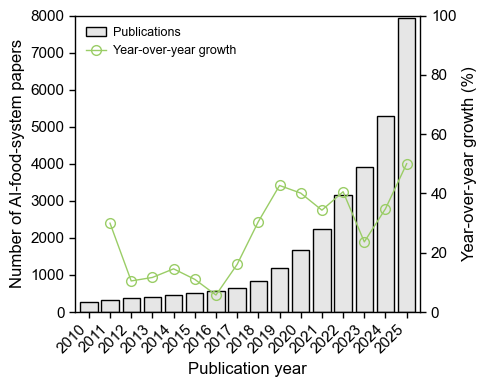

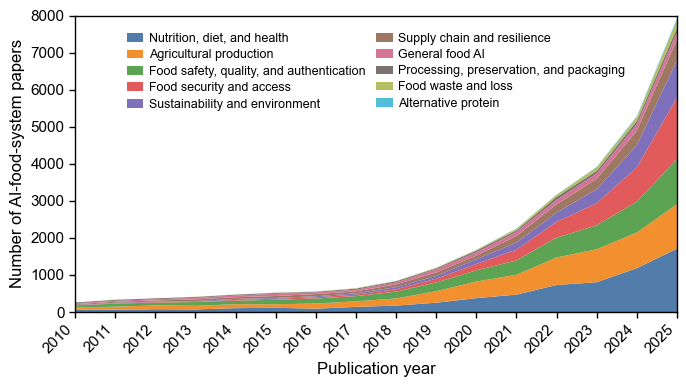

In [55]:
# ============================================================
# Cell 16. Figure 2 only
#          Fig. 2A: annual growth + year-over-year growth rate
#          Fig. 2B: annual domain composition, stacked area
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

DOMAIN_YEAR_IN = OUT_DIR / "00_food_system_core_main_primary_domain_year_counts.csv"

SAVE_FIGURE = False
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not DOMAIN_YEAR_IN.exists():
    raise FileNotFoundError(f"Missing required file: {DOMAIN_YEAR_IN}")

domain_year = pd.read_csv(DOMAIN_YEAR_IN, low_memory=False)

print("Domain-year table:", domain_year.shape)
display(domain_year.head())


# ------------------------------------------------------------
# 1. Figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

TICK_LABEL_SIZE = 11
TICK_LENGTH = 4
TICK_WIDTH = 1.0
BOX_LINE_WIDTH = 1.0
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 9

# Left y-axis: publication count
Y_MIN = 0
Y_MAX = 8000
Y_TICK_STEP = 1000

# Right y-axis: growth rate
GROWTH_Y_MIN = 0
GROWTH_Y_MAX = 100
GROWTH_Y_TICK_STEP = 20

# Fig. 2A colors
BAR_COLOR = "#E6E6E6"       # gray
GROWTH_COLOR = "#9ACD66"    # light green

def style_axis(ax):
    ax.tick_params(
        axis="both",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        colors="black"
    )

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
        ax.spines[spine].set_color("black")

def save_figure(fig, filename):
    if SAVE_FIGURE:
        fig.savefig(FIG_DIR / filename, dpi=600, bbox_inches="tight")
        fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
        print("Saved:", FIG_DIR / filename)


# ------------------------------------------------------------
# 2. Domain order, labels, and colors
# ------------------------------------------------------------
domain_order = [
    "nutrition_diet_health",
    "agriculture_production",
    "food_safety_quality_authentication",
    "food_security_access",
    "sustainability_environment",
    "supply_chain_resilience",
    "general_food_ai",
    "processing_preservation_packaging",
    "food_waste_loss",
    "alternative_protein",
]

domain_label_map = {
    "nutrition_diet_health": "Nutrition, diet, and health",
    "agriculture_production": "Agricultural production",
    "food_safety_quality_authentication": "Food safety, quality, and authentication",
    "food_security_access": "Food security and access",
    "sustainability_environment": "Sustainability and environment",
    "supply_chain_resilience": "Supply chain and resilience",
    "general_food_ai": "General food AI",
    "processing_preservation_packaging": "Processing, preservation, and packaging",
    "food_waste_loss": "Food waste and loss",
    "alternative_protein": "Alternative protein",
}

domain_color_map = {
    "nutrition_diet_health": "#4E79A7",
    "agriculture_production": "#F28E2B",
    "food_safety_quality_authentication": "#59A14F",
    "food_security_access": "#E15759",
    "sustainability_environment": "#7B6DBA",
    "supply_chain_resilience": "#9C755F",
    "general_food_ai": "#D37295",
    "processing_preservation_packaging": "#79706E",
    "food_waste_loss": "#B5BD61",
    "alternative_protein": "#4EBCD8",
}

domain_colors = [domain_color_map[d] for d in domain_order]
domain_labels = [domain_label_map[d] for d in domain_order]


# ------------------------------------------------------------
# 3. Prepare data
# ------------------------------------------------------------
domain_year = domain_year.copy()
domain_year["primary_food_system_domain"] = domain_year["primary_food_system_domain"].astype(str)

domain_year = domain_year[
    domain_year["primary_food_system_domain"].isin(domain_order)
].copy()

year_min = int(domain_year["year"].min())
year_max = int(domain_year["year"].max())
all_years = list(range(year_min, year_max + 1))

pivot_counts = (
    domain_year
    .pivot_table(
        index="year",
        columns="primary_food_system_domain",
        values="n_records",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(index=all_years, columns=domain_order, fill_value=0)
)

annual_counts = pivot_counts.sum(axis=1)

growth_rate = annual_counts.pct_change() * 100
growth_rate = growth_rate.replace([np.inf, -np.inf], np.nan)

domain_total = pivot_counts.sum(axis=0).reindex(domain_order)
domain_pct = domain_total / domain_total.sum() * 100

print("\nAnnual counts and growth rate:")
display(
    pd.DataFrame({
        "year": annual_counts.index,
        "n_records": annual_counts.values,
        "year_over_year_growth_pct": growth_rate.values
    })
)

print("\nOverall domain composition:")
display(
    pd.DataFrame({
        "primary_food_system_domain": domain_order,
        "domain_label": domain_labels,
        "n_records": domain_total.values,
        "pct_records": domain_pct.values.round(2),
    })
)


# ============================================================
# Fig. 2A. Annual growth + year-over-year growth rate
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))

x = annual_counts.index.to_numpy()
y_total = annual_counts.values

bar_publications = ax.bar(
    x,
    y_total,
    width=0.82,
    color=BAR_COLOR,
    edgecolor="black",
    linewidth=BOX_LINE_WIDTH,
    label="Publications"
)

ax.set_xlabel("Publication year", fontsize=AXIS_LABEL_SIZE, color="black")
ax.set_ylabel("Number of AI-food-system papers", fontsize=AXIS_LABEL_SIZE, color="black")

ax.set_xlim(year_min - 0.65, year_max + 0.65)
ax.margins(x=0)

ax.set_ylim(Y_MIN, Y_MAX)
ax.set_yticks(np.arange(Y_MIN, Y_MAX + 1, Y_TICK_STEP))

ax.set_xticks(all_years)
ax.set_xticklabels(all_years, rotation=45, ha="right")

# Primary axis: left, bottom, top only
ax.tick_params(
    axis="both",
    direction="out",
    length=TICK_LENGTH,
    width=TICK_WIDTH,
    labelsize=TICK_LABEL_SIZE,
    colors="black"
)

for spine in ["left", "bottom", "top"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
    ax.spines[spine].set_color("black")

# 오른쪽 spine은 ax2가 담당하므로 ax에서는 숨김
ax.spines["right"].set_visible(False)


# Secondary axis: growth rate
ax2 = ax.twinx()

line_growth, = ax2.plot(
    x,
    growth_rate.values,
    color=GROWTH_COLOR,
    linewidth=1.0,
    marker="o",
    markersize=7,
    markerfacecolor="none",
    markeredgecolor=GROWTH_COLOR,
    markeredgewidth=BOX_LINE_WIDTH,
    label="Year-over-year growth"
)

ax2.set_ylabel("Year-over-year growth (%)", fontsize=AXIS_LABEL_SIZE, color="black")

ax2.set_ylim(GROWTH_Y_MIN, GROWTH_Y_MAX)
ax2.set_yticks(np.arange(GROWTH_Y_MIN, GROWTH_Y_MAX + 1, GROWTH_Y_TICK_STEP))

ax2.tick_params(
    axis="y",
    direction="out",
    length=TICK_LENGTH,
    width=TICK_WIDTH,
    labelsize=TICK_LABEL_SIZE,
    colors="black"
)

# Secondary axis: right spine only
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_linewidth(BOX_LINE_WIDTH)
ax2.spines["right"].set_color("black")

# 겹쳐 보이는 나머지 spine 제거
for spine in ["left", "bottom", "top"]:
    ax2.spines[spine].set_visible(False)

# ax2 배경 제거
ax2.patch.set_visible(False)

ax.legend(
    handles=[bar_publications, line_growth],
    labels=["Publications", "Year-over-year growth"],
    loc="upper left",
    frameon=False,
    fontsize=9.0,
    handlelength=1.6,
    handletextpad=0.5
)

plt.tight_layout()
save_figure(fig, "fig2a_annual_growth_food_system_core.png")
plt.show()

# ============================================================
# Fig. 2B. Annual domain composition, stacked area
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))

x = pivot_counts.index.to_numpy()
y_stack = [pivot_counts[d].to_numpy() for d in domain_order]

ax.stackplot(
    x,
    y_stack,
    labels=domain_labels,
    colors=domain_colors,
    alpha=0.98,
    linewidth=0
)

ax.set_xlabel("Publication year", fontsize=AXIS_LABEL_SIZE)
ax.set_ylabel("Number of AI-food-system papers", fontsize=AXIS_LABEL_SIZE)

ax.set_xlim(year_min, year_max)
ax.margins(x=0, y=0)

ax.set_ylim(Y_MIN, Y_MAX)
ax.set_ybound(lower=Y_MIN, upper=Y_MAX)
ax.set_yticks(np.arange(Y_MIN, Y_MAX + 1, Y_TICK_STEP))

ax.set_xticks(all_years)
ax.set_xticklabels(all_years, rotation=45, ha="right")

style_axis(ax)

# autoscale 영향 방지
ax.set_autoscale_on(False)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_yticks(np.arange(Y_MIN, Y_MAX + 1, Y_TICK_STEP))

legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.50, 0.985),
    ncol=2,
    frameon=False,
    fancybox=False,
    fontsize=9.0,
    handlelength=1.3,
    columnspacing=0.9,
    handletextpad=0.45,
    borderpad=0.55,
    labelspacing=0.32
)

plt.tight_layout()
save_figure(fig, "fig2b_domain_stacked_area_food_system_core.png")
plt.show()

Country attention table: (163, 28)


,iso3,country_scopus,ai_food_papers_full_count,ai_food_papers_fractional_count,n_unique_papers,first_year,last_year,country_need,region_raw,income_group_raw,...,need_sustainability_score,need_supply_vulnerability_score,country,analysis_region,analysis_income_group,ai_food_papers_per_million_population_full,ai_food_papers_per_million_population_fractional,ai_food_papers_per_billion_gdp_full,ai_food_papers_per_billion_gdp_fractional,global_fractional_attention_share_pct
0,CHN,China,9643.0,8384.096068,9643,2010,2025,China,East Asia & Pacific,Upper middle income,...,0.452830,0.206704,China,East Asia & Pacific,Upper middle income,6.843982,5.950493,0.514463,0.447300,28.166687
1,USA,United States,4233.0,2938.863900,4233,2010,2025,United States,North America,High income,...,0.783019,0.100559,United States,North America,High income,12.445937,8.640897,0.145041,0.100698,9.873224
2,IND,India,3262.0,2743.212060,3262,2010,2025,India,South Asia,Lower middle income,...,0.169811,0.100559,India,South Asia,Lower middle income,2.248204,1.890650,0.833698,0.701107,9.215924
3,ESP,Spain,1314.0,875.880711,1314,2010,2025,Spain,Europe & Central Asia,High income,...,0.551887,0.474860,Spain,Europe & Central Asia,High income,26.899308,17.930430,0.762736,0.508421,2.942554
4,ITA,Italy,1199.0,821.201880,1199,2010,2025,Italy,Europe & Central Asia,High income,...,0.636792,0.483240,Italy,Europe & Central Asia,High income,20.338338,13.929842,0.505316,0.346094,2.758859



Top countries by map value:


,iso3,country_label,analysis_region,analysis_income_group,ai_food_papers_fractional_count
0,CHN,China,East Asia & Pacific,Upper middle income,8384.096068
1,USA,United States,North America,High income,2938.863900
2,IND,India,South Asia,Lower middle income,2743.212060
3,ESP,Spain,Europe & Central Asia,High income,875.880711
4,ITA,Italy,Europe & Central Asia,High income,821.201880
5,BRA,Brazil,Latin America & Caribbean,Upper middle income,786.455357
6,IRN,"Iran, Islamic Rep.",Middle East & North Africa,Upper middle income,761.028571
7,GBR,United Kingdom,Europe & Central Asia,High income,682.041562
8,AUS,Australia,East Asia & Pacific,High income,641.640650
9,DEU,Germany,Europe & Central Asia,High income,638.471162


Countries mapped with data: 152
Positive mapped countries: 152


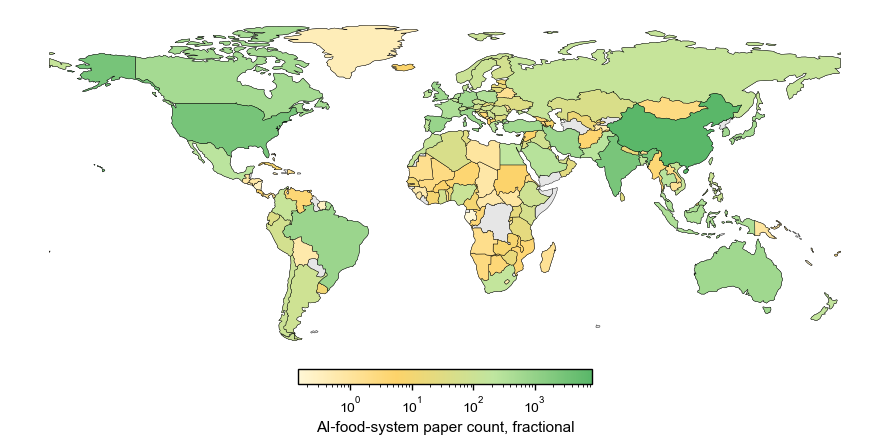

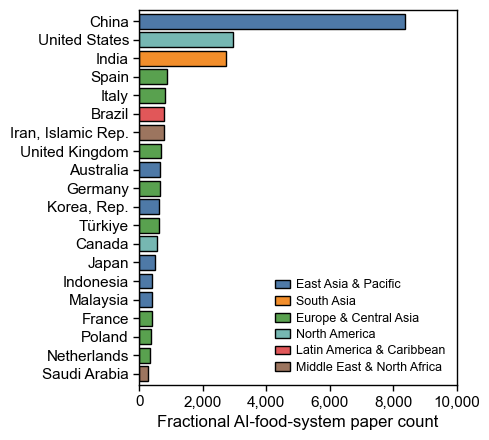

,iso3,country_label,analysis_region,analysis_income_group,ai_food_papers_fractional_count,global_fractional_attention_share_pct
0,CHN,China,East Asia & Pacific,Upper middle income,8384.096068,28.166687
1,USA,United States,North America,High income,2938.863900,9.873224
2,IND,India,South Asia,Lower middle income,2743.212060,9.215924
3,ESP,Spain,Europe & Central Asia,High income,875.880711,2.942554
4,ITA,Italy,Europe & Central Asia,High income,821.201880,2.758859
5,BRA,Brazil,Latin America & Caribbean,Upper middle income,786.455357,2.642126
6,IRN,"Iran, Islamic Rep.",Middle East & North Africa,Upper middle income,761.028571,2.556704
7,GBR,United Kingdom,Europe & Central Asia,High income,682.041562,2.291344
8,AUS,Australia,East Asia & Pacific,High income,641.640650,2.155616
9,DEU,Germany,Europe & Central Asia,High income,638.471162,2.144968


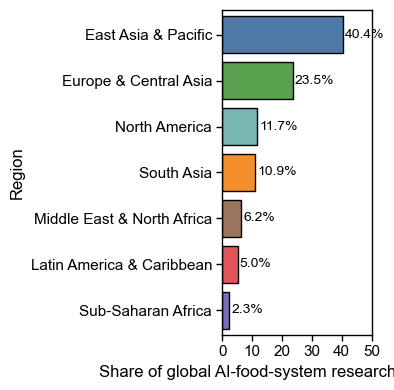

,analysis_region,fractional_attention,n_countries,attention_share_pct
0,East Asia & Pacific,12026.350221,24,40.402977
1,Europe & Central Asia,7005.626341,49,23.535666
4,North America,3478.749752,2,11.686991
5,South Asia,3231.684318,7,10.856965
3,Middle East & North Africa,1849.141948,19,6.212262
2,Latin America & Caribbean,1501.056944,24,5.042857
6,Sub-Saharan Africa,673.390476,38,2.262281


In [22]:
# ============================================================
# Cell 17. Figure 3 only
#          Global concentration of AI-food research attention
#          Fig. 3A: world map of country-level fractional attention
#          Fig. 3B: top countries by fractional attention
#          Fig. 3C: regional share of global attention
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

COUNTRY_ATTENTION_IN = OUT_DIR / "14_country_total_ai_food_research_attention_food_system_core_main.csv"

SAVE_FIGURE = False
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not COUNTRY_ATTENTION_IN.exists():
    raise FileNotFoundError(f"Missing required file: {COUNTRY_ATTENTION_IN}")

country_attention = pd.read_csv(COUNTRY_ATTENTION_IN, low_memory=False)

print("Country attention table:", country_attention.shape)
display(country_attention.head())


# ------------------------------------------------------------
# 1. Figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

TICK_LABEL_SIZE = 11
TICK_LENGTH = 4
TICK_WIDTH = 1.0
BOX_LINE_WIDTH = 1.0
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 9

MAP_EDGE_WIDTH = 0.30
COLORBAR_LINE_WIDTH = 1.0
COLORBAR_LABEL_SIZE = 11
COLORBAR_TICK_SIZE = 10

def style_axis(ax):
    ax.tick_params(
        axis="both",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        colors="black"
    )

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
        ax.spines[spine].set_color("black")

def save_figure(fig, filename):
    if SAVE_FIGURE:
        fig.savefig(FIG_DIR / filename, dpi=600, bbox_inches="tight")
        fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
        print("Saved:", FIG_DIR / filename)

def comma_formatter(x, pos):
    return f"{x:,.0f}"

def percent_formatter(x, pos):
    return f"{x:.0f}"


# ------------------------------------------------------------
# 2. Column setting
# ------------------------------------------------------------
MAP_VALUE_COL = "ai_food_papers_fractional_count"

# Alternative, if needed:
# MAP_VALUE_COL = "ai_food_papers_per_million_population_fractional"

required_cols = [
    "iso3",
    "ai_food_papers_fractional_count",
    "analysis_region",
    "analysis_income_group",
]

for col in required_cols:
    if col not in country_attention.columns:
        raise KeyError(f"Required column missing: {col}")

country_attention = country_attention.copy()
country_attention["iso3"] = country_attention["iso3"].astype(str).str.upper()
country_attention["analysis_region"] = (
    country_attention["analysis_region"]
    .fillna("Not classified")
    .astype(str)
)
country_attention["analysis_income_group"] = (
    country_attention["analysis_income_group"]
    .fillna("Not classified")
    .astype(str)
)

if "country_need" in country_attention.columns:
    COUNTRY_NAME_COL = "country_need"
elif "country" in country_attention.columns:
    COUNTRY_NAME_COL = "country"
else:
    COUNTRY_NAME_COL = "iso3"

country_attention["country_label"] = (
    country_attention[COUNTRY_NAME_COL]
    .fillna(country_attention["iso3"])
    .astype(str)
)

country_attention[MAP_VALUE_COL] = pd.to_numeric(
    country_attention[MAP_VALUE_COL],
    errors="coerce"
)

print("\nTop countries by map value:")
display(
    country_attention[
        ["iso3", "country_label", "analysis_region", "analysis_income_group", MAP_VALUE_COL]
    ]
    .sort_values(MAP_VALUE_COL, ascending=False)
    .head(20)
)


# ------------------------------------------------------------
# 3. Region color setting
# ------------------------------------------------------------
region_order = [
    "East Asia & Pacific",
    "South Asia",
    "Europe & Central Asia",
    "North America",
    "Latin America & Caribbean",
    "Middle East & North Africa",
    "Sub-Saharan Africa",
    "Not classified",
]

region_color_map = {
    "East Asia & Pacific": "#4E79A7",
    "South Asia": "#F28E2B",
    "Europe & Central Asia": "#59A14F",
    "North America": "#76B7B2",
    "Latin America & Caribbean": "#E15759",
    "Middle East & North Africa": "#9C755F",
    "Sub-Saharan Africa": "#7B6DBA",
    "Not classified": "#B3B3B3",
}


# ============================================================
# Fig. 3A. World map of country-level AI-food attention
# ============================================================
try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "geopandas is required for the world map. Install it first, e.g. pip install geopandas"
    ) from e

NATURAL_EARTH_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

try:
    world = gpd.read_file(NATURAL_EARTH_URL)
except Exception as e:
    raise RuntimeError(
        "Could not load Natural Earth country boundaries from URL. "
        "Check your internet connection, or manually download "
        "'ne_110m_admin_0_countries.zip' from Natural Earth and read it locally."
    ) from e

world = world.copy()

name_col = "NAME" if "NAME" in world.columns else "name"
if name_col in world.columns:
    world = world[world[name_col] != "Antarctica"].copy()

if "ISO_A3" in world.columns:
    world["map_iso3"] = world["ISO_A3"].astype(str).str.upper()
elif "iso_a3" in world.columns:
    world["map_iso3"] = world["iso_a3"].astype(str).str.upper()
else:
    raise KeyError("Natural Earth file does not contain ISO_A3 or iso_a3 column.")

# Natural Earth sometimes has -99 for some territories.
if "ADM0_A3" in world.columns:
    adm0 = world["ADM0_A3"].astype(str).str.upper()
    world.loc[world["map_iso3"].isin(["-99", "NAN", ""]), "map_iso3"] = adm0

world_map = world.merge(
    country_attention[["iso3", "country_label", MAP_VALUE_COL]],
    left_on="map_iso3",
    right_on="iso3",
    how="left"
)

# Taiwan patch, if needed
if name_col in world_map.columns and "TWN" in set(country_attention["iso3"]):
    taiwan_value = country_attention.loc[
        country_attention["iso3"].eq("TWN"),
        MAP_VALUE_COL
    ]
    taiwan_label = country_attention.loc[
        country_attention["iso3"].eq("TWN"),
        "country_label"
    ]

    taiwan_mask = world_map[name_col].astype(str).str.lower().eq("taiwan")
    if taiwan_mask.any() and len(taiwan_value) > 0:
        world_map.loc[taiwan_mask, MAP_VALUE_COL] = float(taiwan_value.iloc[0])
        world_map.loc[taiwan_mask, "iso3"] = "TWN"
        world_map.loc[taiwan_mask, "country_label"] = (
            str(taiwan_label.iloc[0]) if len(taiwan_label) > 0 else "Taiwan"
        )

world_map["plot_value"] = pd.to_numeric(world_map[MAP_VALUE_COL], errors="coerce")

positive_values = world_map.loc[world_map["plot_value"] > 0, "plot_value"].dropna()

if positive_values.empty:
    raise ValueError(f"No positive values found in {MAP_VALUE_COL}.")

vmin = positive_values.min()
vmax = positive_values.max()

from matplotlib.colors import LinearSegmentedColormap

norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)

cmap = LinearSegmentedColormap.from_list(
    "soft_gold_green",
    ["#FFF7D6", "#FDD36A", "#BFE6A0", "#5AB769"]
)

print("Countries mapped with data:", world_map[MAP_VALUE_COL].notna().sum())
print("Positive mapped countries:", world_map["plot_value"].gt(0).sum())

fig, ax = plt.subplots(figsize=(9, 5))

# Countries without data
world_map.plot(
    ax=ax,
    color="#E6E6E6",
    edgecolor="black",
    linewidth=MAP_EDGE_WIDTH
)

# Countries with positive data
world_map_pos = world_map[world_map["plot_value"] > 0].copy()

world_map_pos.plot(
    column="plot_value",
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=MAP_EDGE_WIDTH
)

ax.set_axis_off()

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.035,
    pad=0.03
)

if MAP_VALUE_COL == "ai_food_papers_fractional_count":
    cbar_label = "AI-food-system paper count, fractional"
elif MAP_VALUE_COL == "ai_food_papers_per_million_population_fractional":
    cbar_label = "AI-food-system papers per million population, fractional"
else:
    cbar_label = MAP_VALUE_COL

cbar.set_label(cbar_label, fontsize=COLORBAR_LABEL_SIZE)
cbar.ax.tick_params(
    labelsize=COLORBAR_TICK_SIZE,
    width=COLORBAR_LINE_WIDTH,
    length=4,
    direction="out"
)

try:
    cbar.outline.set_linewidth(COLORBAR_LINE_WIDTH)
except Exception:
    pass

plt.tight_layout()
save_figure(fig, "fig3a_world_map_ai_food_research_attention.png")
plt.show()


# ============================================================
# Fig. 3B. Top countries by fractional AI-food research attention
# ============================================================
TOP_N = 20

top_country = (
    country_attention
    .sort_values("ai_food_papers_fractional_count", ascending=False)
    .head(TOP_N)
    .copy()
)

top_country = top_country.iloc[::-1].copy()

bar_colors = [
    region_color_map.get(region, "#B3B3B3")
    for region in top_country["analysis_region"]
]

fig, ax = plt.subplots(figsize=(5, 4.5))

y_pos = np.arange(len(top_country))

ax.barh(
    y_pos,
    top_country["ai_food_papers_fractional_count"],
    color=bar_colors,
    edgecolor="black",
    linewidth=BOX_LINE_WIDTH
)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_country["country_label"], fontsize=TICK_LABEL_SIZE)

ax.set_xlabel("Fractional AI-food-system paper count", fontsize=AXIS_LABEL_SIZE)

ax.xaxis.set_major_formatter(FuncFormatter(comma_formatter))

xmax = np.ceil(top_country["ai_food_papers_fractional_count"].max() / 1000) * 1000
ax.set_xlim(0, 10000)
ax.margins(y=0.01)

style_axis(ax)

# Region legend for represented regions only
handles = []
labels = []

for region in region_order:
    if region in top_country["analysis_region"].values:
        handles.append(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                facecolor=region_color_map.get(region, "#B3B3B3"),
                edgecolor="black",
                linewidth=BOX_LINE_WIDTH
            )
        )
        labels.append(region)

ax.legend(
    handles,
    labels,
    loc="lower right",
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.2,
    handletextpad=0.5,
    labelspacing=0.35
)

plt.tight_layout()
save_figure(fig, "fig3b_top_country_fractional_attention_food_system_core.png")
plt.show()

display(
    top_country.iloc[::-1][
        [
            "iso3",
            "country_label",
            "analysis_region",
            "analysis_income_group",
            "ai_food_papers_fractional_count",
        ]
        + (
            ["global_fractional_attention_share_pct"]
            if "global_fractional_attention_share_pct" in top_country.columns
            else []
        )
    ]
)


# ============================================================
# Fig. 3C. Regional share of global AI-food research attention
# ============================================================
region_attention = (
    country_attention
    .groupby("analysis_region", as_index=False)
    .agg(
        fractional_attention=("ai_food_papers_fractional_count", "sum"),
        n_countries=("iso3", "nunique")
    )
)

region_attention["attention_share_pct"] = (
    region_attention["fractional_attention"]
    / region_attention["fractional_attention"].sum()
    * 100
)

region_attention["analysis_region"] = pd.Categorical(
    region_attention["analysis_region"],
    categories=region_order,
    ordered=True
)

region_attention = (
    region_attention
    .sort_values("attention_share_pct", ascending=True)
    .copy()
)

region_colors = [
    region_color_map.get(str(region), "#B3B3B3")
    for region in region_attention["analysis_region"].astype(str)
]

fig, ax = plt.subplots(figsize=(4, 4))

y_pos = np.arange(len(region_attention))

ax.barh(
    y_pos,
    region_attention["attention_share_pct"],
    color=region_colors,
    edgecolor="black",
    linewidth=BOX_LINE_WIDTH
)

ax.set_yticks(y_pos)
ax.set_yticklabels(region_attention["analysis_region"].astype(str), fontsize=TICK_LABEL_SIZE)

ax.set_xlabel("Share of global AI-food-system research attention (%)", fontsize=AXIS_LABEL_SIZE)
ax.set_ylabel("Region", fontsize=AXIS_LABEL_SIZE)

max_share = region_attention["attention_share_pct"].max()
xmax = np.ceil((max_share + 5) / 10) * 10

ax.set_xlim(0, xmax)
ax.set_xticks(np.arange(0, xmax + 1, 10))
ax.xaxis.set_major_formatter(FuncFormatter(percent_formatter))
ax.margins(y=0.02)

style_axis(ax)

for i, value in enumerate(region_attention["attention_share_pct"]):
    ax.text(
        value + 0.8,
        i,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=10
    )

plt.tight_layout()
save_figure(fig, "fig3c_region_attention_share_food_system_core.png")
plt.show()

display(
    region_attention.sort_values("attention_share_pct", ascending=False)
)

Need indicator table: (217, 60)

Columns in need_df:
['iso3', 'country', 'region', 'income_group', 'population_year', 'population', 'gdp_current_usd_year', 'gdp_current_usd', 'rd_expenditure_pct_gdp_year', 'rd_expenditure_pct_gdp', 'undernourishment_pct_year', 'undernourishment_pct', 'child_stunting_pct_year', 'child_stunting_pct', 'adult_obesity_pct_year', 'adult_obesity_pct', 'agrifood_ghg_ktco2eq_year', 'agrifood_ghg_ktco2eq', 'agrifood_ghg_tco2eq_per_capita', 'cereal_import_dependency_period', 'cereal_import_dependency_period_end_year', 'cereal_import_dependency_pct', 'household_food_waste_kg_capita', 'household_food_waste_tonnes_year', 'household_food_waste_confidence', 'household_food_waste_source', 'unep_country', 'unep_region', 'm49_code', 'gdp_per_capita_current_usd', 'log10_population', 'log10_gdp_current_usd', 'log10_gdp_per_capita_current_usd', 'cereal_import_dependency_vulnerability_pct', 'need_food_security_score', 'need_child_stunting_score', 'need_adult_obesity_score', 

,iso3,country,region,income_group,population_year,population,gdp_current_usd_year,gdp_current_usd,rd_expenditure_pct_gdp_year,rd_expenditure_pct_gdp,...,dominant_need_profile,missing_need_axes,flag_main_need_index_available,flag_strict_need_index_available,flag_population_ge_1m,flag_food_waste_higher_confidence,flag_food_waste_low_confidence,rank_need_v1_min3,rank_need_main_min4,rank_need_strict_all5
0,ABW,Aruba,Latin America & Caribbean,High income,2024,107995.0,2023.0,2.189144e+10,NaN,NaN,...,sustainability,food_security; nutrition; supply_vulnerability,False,False,False,False,True,NaN,NaN,NaN
1,AFG,Afghanistan,Middle East & North Africa,Low income,2024,42647492.0,2023.0,1.033175e+11,NaN,NaN,...,food_waste,none,True,True,True,False,False,58.0,54.0,45.0
2,AGO,Angola,Sub-Saharan Africa,Lower middle income,2024,37885849.0,2024.0,8.039694e+10,2016.0,0.03229,...,food_security,none,True,True,True,False,True,31.0,29.0,25.0
3,ALB,Albania,Europe & Central Asia,Upper middle income,2024,2377128.0,2024.0,2.717774e+10,2022.0,0.19997,...,food_security,none,True,True,True,False,True,117.0,112.0,98.0
4,AND,Andorra,Europe & Central Asia,High income,2024,81938.0,2024.0,4.039844e+09,2022.0,0.15818,...,nutrition,food_security; supply_vulnerability,False,False,False,False,True,138.0,NaN,NaN



Column used:
Country name column: country
Region column: region
Income column: income_group

Countries with available main food-system need index: 181


,iso3,country_label,analysis_region,analysis_income_group,food_system_need_index_main_min4
177,SSD,South Sudan,Sub-Saharan Africa,Low income,0.835271
155,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,0.807955
20,BHS,"Bahamas, The",Latin America & Caribbean,High income,0.759191
168,SDN,Sudan,Sub-Saharan Africa,Low income,0.721671
210,VUT,Vanuatu,East Asia & Pacific,Lower middle income,0.720836
109,LBR,Liberia,Sub-Saharan Africa,Low income,0.719502
139,NAM,Namibia,Sub-Saharan Africa,Lower middle income,0.718826
31,CAF,Central African Republic,Sub-Saharan Africa,Low income,0.715402
67,GAB,Gabon,Sub-Saharan Africa,Upper middle income,0.712279
175,SOM,"Somalia, Fed. Rep.",Sub-Saharan Africa,Low income,0.709381


Countries mapped with need data: 162


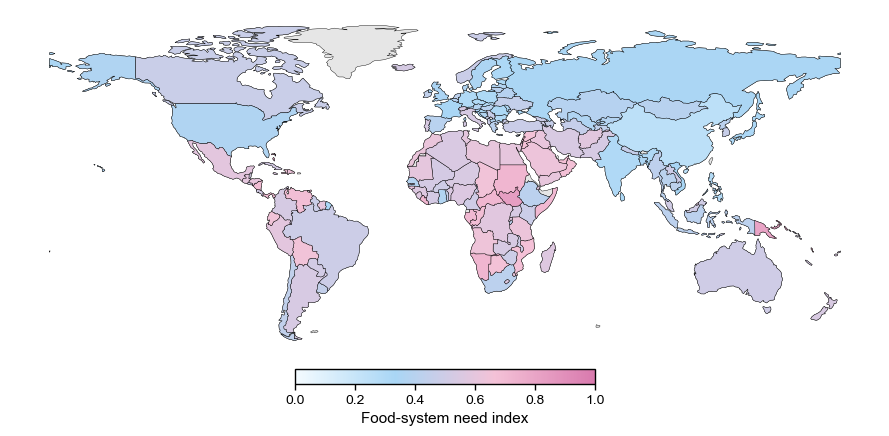

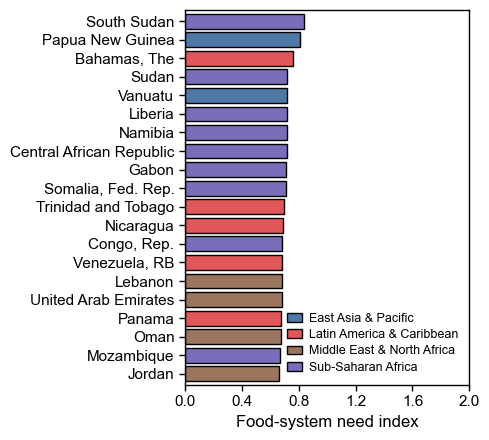

,iso3,country_label,analysis_region,analysis_income_group,food_system_need_index_main_min4
177,SSD,South Sudan,Sub-Saharan Africa,Low income,0.835271
155,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,0.807955
20,BHS,"Bahamas, The",Latin America & Caribbean,High income,0.759191
168,SDN,Sudan,Sub-Saharan Africa,Low income,0.721671
210,VUT,Vanuatu,East Asia & Pacific,Lower middle income,0.720836
109,LBR,Liberia,Sub-Saharan Africa,Low income,0.719502
139,NAM,Namibia,Sub-Saharan Africa,Lower middle income,0.718826
31,CAF,Central African Republic,Sub-Saharan Africa,Low income,0.715402
67,GAB,Gabon,Sub-Saharan Africa,Upper middle income,0.712279
175,SOM,"Somalia, Fed. Rep.",Sub-Saharan Africa,Low income,0.709381


In [21]:
# ============================================================
# Cell 18. Figure 4 only
#          Global distribution of food-system need
#          Fig. 4A: world map of country-level food-system need index
#          Fig. 4B: top countries by food-system need index
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

NEED_IN = OUT_DIR / "country_food_system_need_indicators_v2_analysis_ready.csv"

SAVE_FIGURE = False
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not NEED_IN.exists():
    raise FileNotFoundError(f"Missing required file: {NEED_IN}")

need_df = pd.read_csv(NEED_IN, low_memory=False)

print("Need indicator table:", need_df.shape)
print("\nColumns in need_df:")
print(need_df.columns.tolist())
display(need_df.head())


# ------------------------------------------------------------
# 1. Figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

TICK_LABEL_SIZE = 11
TICK_LENGTH = 4
TICK_WIDTH = 1.0
BOX_LINE_WIDTH = 1.0
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 9

MAP_EDGE_WIDTH = 0.30
COLORBAR_LINE_WIDTH = 1.0
COLORBAR_LABEL_SIZE = 11
COLORBAR_TICK_SIZE = 10

def style_axis(ax):
    ax.tick_params(
        axis="both",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        colors="black"
    )

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
        ax.spines[spine].set_color("black")

def save_figure(fig, filename):
    if SAVE_FIGURE:
        fig.savefig(FIG_DIR / filename, dpi=600, bbox_inches="tight")
        fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
        print("Saved:", FIG_DIR / filename)

def decimal_formatter(x, pos):
    return f"{x:.1f}"


# ------------------------------------------------------------
# 2. Column setting with automatic detection
# ------------------------------------------------------------
NEED_COL = "food_system_need_index_main_min4"

if "iso3" not in need_df.columns:
    raise KeyError("Required column missing: iso3")

if NEED_COL not in need_df.columns:
    raise KeyError(f"Required column missing: {NEED_COL}")

# Country name column 자동 탐색
possible_country_cols = [
    "country_need",
    "country_label",
    "country",
    "country_name",
    "Country Name",
    "Country",
    "name",
    "Name",
    "economy",
    "Economy"
]

COUNTRY_NAME_COL = None
for c in possible_country_cols:
    if c in need_df.columns:
        COUNTRY_NAME_COL = c
        break

if COUNTRY_NAME_COL is None:
    COUNTRY_NAME_COL = "iso3"
    print("No country name column found. Using iso3 as country_label.")

# Region column 자동 탐색
possible_region_cols = [
    "analysis_region",
    "region",
    "Region",
    "wb_region",
    "world_bank_region",
    "World Bank Region",
    "region_wb"
]

REGION_COL = None
for c in possible_region_cols:
    if c in need_df.columns:
        REGION_COL = c
        break

if REGION_COL is None:
    REGION_COL = None
    print("No region column found. Using 'Not classified' for all countries.")

# Income column 자동 탐색
possible_income_cols = [
    "analysis_income_group",
    "income_group",
    "IncomeGroup",
    "Income Group",
    "income",
    "Income",
    "wb_income_group",
    "world_bank_income_group",
    "World Bank Income Group",
    "income_group_wb"
]

INCOME_COL = None
for c in possible_income_cols:
    if c in need_df.columns:
        INCOME_COL = c
        break

if INCOME_COL is None:
    INCOME_COL = None
    print("No income-group column found. Using 'Not classified' for all countries.")

need_df = need_df.copy()
need_df["iso3"] = need_df["iso3"].astype(str).str.upper()
need_df["country_label"] = need_df[COUNTRY_NAME_COL].fillna(need_df["iso3"]).astype(str)

if REGION_COL is not None:
    need_df["analysis_region"] = need_df[REGION_COL].fillna("Not classified").astype(str)
else:
    need_df["analysis_region"] = "Not classified"

if INCOME_COL is not None:
    need_df["analysis_income_group"] = need_df[INCOME_COL].fillna("Not classified").astype(str)
else:
    need_df["analysis_income_group"] = "Not classified"

need_df[NEED_COL] = pd.to_numeric(need_df[NEED_COL], errors="coerce")

plot_need_df = need_df[need_df[NEED_COL].notna()].copy()

print("\nColumn used:")
print("Country name column:", COUNTRY_NAME_COL)
print("Region column:", REGION_COL)
print("Income column:", INCOME_COL)
print("\nCountries with available main food-system need index:", len(plot_need_df))

display(
    plot_need_df[
        ["iso3", "country_label", "analysis_region", "analysis_income_group", NEED_COL]
    ]
    .sort_values(NEED_COL, ascending=False)
    .head(20)
)


# ------------------------------------------------------------
# 3. Region colors for bar plot
# ------------------------------------------------------------
region_order = [
    "East Asia & Pacific",
    "South Asia",
    "Europe & Central Asia",
    "North America",
    "Latin America & Caribbean",
    "Middle East & North Africa",
    "Sub-Saharan Africa",
    "Not classified",
]

region_color_map = {
    "East Asia & Pacific": "#4E79A7",
    "South Asia": "#F28E2B",
    "Europe & Central Asia": "#59A14F",
    "North America": "#76B7B2",
    "Latin America & Caribbean": "#E15759",
    "Middle East & North Africa": "#9C755F",
    "Sub-Saharan Africa": "#7B6DBA",
    "Not classified": "#B3B3B3",
}


# ============================================================
# Fig. 4A. World map of food-system need index
# ============================================================
try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "geopandas is required for the world map. Install it first, e.g. pip install geopandas"
    ) from e

NATURAL_EARTH_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

try:
    world = gpd.read_file(NATURAL_EARTH_URL)
except Exception as e:
    raise RuntimeError(
        "Could not load Natural Earth country boundaries from URL. "
        "Check your internet connection, or manually download "
        "'ne_110m_admin_0_countries.zip' from Natural Earth and read it locally."
    ) from e

world = world.copy()

name_col = "NAME" if "NAME" in world.columns else "name"
if name_col in world.columns:
    world = world[world[name_col] != "Antarctica"].copy()

if "ISO_A3" in world.columns:
    world["map_iso3"] = world["ISO_A3"].astype(str).str.upper()
elif "iso_a3" in world.columns:
    world["map_iso3"] = world["iso_a3"].astype(str).str.upper()
else:
    raise KeyError("Natural Earth file does not contain ISO_A3 or iso_a3 column.")

if "ADM0_A3" in world.columns:
    adm0 = world["ADM0_A3"].astype(str).str.upper()
    world.loc[world["map_iso3"].isin(["-99", "NAN", ""]), "map_iso3"] = adm0

world_map = world.merge(
    need_df[["iso3", "country_label", NEED_COL]],
    left_on="map_iso3",
    right_on="iso3",
    how="left"
)

world_map["plot_value"] = pd.to_numeric(world_map[NEED_COL], errors="coerce")

print("Countries mapped with need data:", world_map["plot_value"].notna().sum())

# Need index는 0-1 bound이므로 linear scale
vmin = 0.0
vmax = 1.0
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Need burden palette: pale yellow -> orange -> red
need_cmap = LinearSegmentedColormap.from_list(
    "sky_pink",
    ["#F4FBFF", "#A9D6F5", "#F4C2D7", "#D97AAE"]
)

fig, ax = plt.subplots(figsize=(9, 5))

# Countries without data
world_map.plot(
    ax=ax,
    color="#E6E6E6",
    edgecolor="black",
    linewidth=MAP_EDGE_WIDTH
)

# Countries with need data
world_map_valid = world_map[world_map["plot_value"].notna()].copy()

world_map_valid.plot(
    column="plot_value",
    ax=ax,
    cmap=need_cmap,
    norm=norm,
    edgecolor="black",
    linewidth=MAP_EDGE_WIDTH
)

ax.set_axis_off()

sm = mpl.cm.ScalarMappable(norm=norm, cmap=need_cmap)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    fraction=0.035,
    pad=0.03
)

cbar.set_label("Food-system need index", fontsize=COLORBAR_LABEL_SIZE)

cbar.ax.tick_params(
    labelsize=COLORBAR_TICK_SIZE,
    width=COLORBAR_LINE_WIDTH,
    length=4,
    direction="out"
)

try:
    cbar.outline.set_linewidth(COLORBAR_LINE_WIDTH)
except Exception:
    pass

plt.tight_layout()
save_figure(fig, "fig4a_world_map_food_system_need_index.png")
plt.show()


# ============================================================
# Fig. 4B. Top countries by food-system need index
# ============================================================
TOP_N = 20

top_need = (
    plot_need_df
    .sort_values(NEED_COL, ascending=False)
    .head(TOP_N)
    .copy()
)

top_need = top_need.iloc[::-1].copy()

bar_colors = [
    region_color_map.get(region, "#B3B3B3")
    for region in top_need["analysis_region"]
]

fig, ax = plt.subplots(figsize=(5, 4.5))

y_pos = np.arange(len(top_need))

ax.barh(
    y_pos,
    top_need[NEED_COL],
    color=bar_colors,
    edgecolor="black",
    linewidth=BOX_LINE_WIDTH
)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_need["country_label"], fontsize=TICK_LABEL_SIZE)

ax.set_xlabel("Food-system need index", fontsize=AXIS_LABEL_SIZE)

ax.set_xlim(0, 2.0)
ax.set_xticks(np.arange(0, 2.1, 0.4))
ax.xaxis.set_major_formatter(FuncFormatter(decimal_formatter))

ax.margins(y=0.01)

style_axis(ax)

# Region legend for represented regions only
handles = []
labels = []

for region in region_order:
    if region in top_need["analysis_region"].values:
        handles.append(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                facecolor=region_color_map.get(region, "#B3B3B3"),
                edgecolor="black",
                linewidth=BOX_LINE_WIDTH
            )
        )
        labels.append(region)

ax.legend(
    handles,
    labels,
    loc="lower right",
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.2,
    handletextpad=0.5,
    labelspacing=0.35
)

plt.tight_layout()
save_figure(fig, "fig4b_top_country_food_system_need_index.png")
plt.show()

display(
    top_need.iloc[::-1][
        [
            "iso3",
            "country_label",
            "analysis_region",
            "analysis_income_group",
            NEED_COL,
        ]
    ]
)

Mismatch table: (152, 47)
Under-attended table: (40, 19)

Mismatch columns:
['iso3', 'country_need', 'region_raw', 'income_group_raw', 'population', 'gdp_current_usd', 'rd_expenditure_pct_gdp', 'food_system_need_index_main_min4', 'food_system_need_index_strict_all5', 'need_food_security_score', 'need_nutrition_score', 'need_food_waste_score', 'need_sustainability_score', 'need_supply_vulnerability_score', 'n_need_axes_available', 'dominant_need_profile', 'missing_need_axes', 'analysis_region', 'analysis_income_group', 'ai_food_papers_full_count', 'ai_food_papers_fractional_count', 'n_unique_papers', 'first_year', 'last_year', 'global_fractional_attention_share_pct', 'ai_food_papers_per_million_population_fractional', 'ai_food_papers_per_billion_gdp_fractional', 'has_any_ai_food_attention', 'flag_population_ge_1m', 'flag_main_need_index_available', 'need_percentile', 'attention_count_percentile', 'attention_per_capita_percentile', 'attention_per_gdp_percentile', 'simple_need_attention_g

,iso3,country_need,region_raw,income_group_raw,population,gdp_current_usd,rd_expenditure_pct_gdp,food_system_need_index_main_min4,food_system_need_index_strict_all5,need_food_security_score,...,log_fractional_attention,expected_log_fractional_attention,attention_capacity_residual,need_z,attention_capacity_residual_z,attention_count_z,capacity_adjusted_under_attention_score,raw_attention_need_gap_z,attention_need_quadrant,mismatch_priority_group
0,COD,"Congo, Dem. Rep.",Sub-Saharan Africa,Low income,109276265.0,7.074936e+10,0.40638,0.580111,0.580111,0.970414,...,0.000000,2.861543,-2.861543,0.583052,-2.963997,-1.389176,3.547049,1.972228,middle,highest_under_attention
1,PAN,Panama,Latin America & Caribbean,High income,4515577.0,8.626040e+10,0.19708,0.676234,0.676234,0.526627,...,0.773190,2.878855,-2.105665,1.346297,-2.181056,-1.034600,3.527353,2.380897,middle,highest_under_attention
2,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,3.253848e+10,0.03158,0.807955,0.807955,0.934911,...,0.650588,1.706416,-1.055828,2.392208,-1.093631,-1.090824,3.485839,3.483032,high_need_low_attention,highest_under_attention
3,GTM,Guatemala,Latin America & Caribbean,Upper middle income,18406359.0,1.131996e+11,0.00609,0.594918,0.594918,0.704142,...,0.606136,2.918193,-2.312057,0.700625,-2.394837,-1.111209,3.095462,1.811834,middle,highest_under_attention
4,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,3.534969e+10,NaN,0.835271,NaN,0.887574,...,0.606136,1.062283,-0.456147,2.609100,-0.472478,-1.111209,3.081579,3.720309,high_need_low_attention,highest_under_attention


,iso3,country_need,analysis_region,analysis_income_group,population,food_system_need_index_main_min4,need_percentile,ai_food_papers_fractional_count,ai_food_papers_per_million_population_fractional,attention_per_capita_percentile,attention_capacity_residual,capacity_adjusted_under_attention_score,attention_need_quadrant,dominant_need_profile,need_food_security_score,need_nutrition_score,need_food_waste_score,need_sustainability_score,need_supply_vulnerability_score
0,COD,"Congo, Dem. Rep.",Sub-Saharan Africa,Low income,109276265.0,0.580111,0.697368,0.000000,0.000000,0.046053,-2.861543,3.547049,middle,food_security,0.970414,0.550336,0.137209,0.896226,0.346369
1,PAN,Panama,Latin America & Caribbean,High income,4515577.0,0.676234,0.907895,1.166667,0.258365,0.309211,-2.105665,3.527353,middle,food_waste,0.526627,0.596552,0.853488,0.745283,0.659218
2,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,0.807955,0.993421,0.916667,0.086670,0.197368,-1.055828,3.485839,high_need_low_attention,supply_vulnerability,0.934911,0.762482,0.572093,0.806604,0.963687
3,GTM,Guatemala,Latin America & Caribbean,Upper middle income,18406359.0,0.594918,0.736842,0.833333,0.045274,0.125000,-2.312057,3.095462,middle,nutrition,0.704142,0.738244,0.676744,0.268868,0.586592
4,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,0.835271,1.000000,0.833333,0.069773,0.164474,-0.456147,3.081579,high_need_low_attention,food_security,0.887574,0.834356,0.746512,0.872642,NaN



Detected columns:
ISO_COL: iso3
COUNTRY_COL: country_need
REGION_COL: analysis_region
INCOME_COL: analysis_income_group
NEED_COL: food_system_need_index_main_min4
ATTN_PC_COL: ai_food_papers_per_million_population_fractional
FRACTIONAL_ATTENTION_COL: None
POP_COL: population
QUADRANT_COL: attention_need_quadrant
UNDER_SCORE_COL: capacity_adjusted_under_attention_score
UNDER_COUNTRY_COL: country_need
UNDER_REGION_COL: analysis_region
UNDER_NEED_COL: food_system_need_index_main_min4

Plotting countries: 152
Zero or negative attention countries shifted to log floor: 13
Log floor: 0.01724212420408505


,iso3_plot,country_label_plot,region_plot,need_index_plot,attention_per_million_plot,quadrant_plot
4,SSD,South Sudan,Sub-Saharan Africa,0.835271,0.069773,high_need_low_attention
2,PNG,Papua New Guinea,East Asia & Pacific,0.807955,0.086670,high_need_low_attention
20,SDN,Sudan,Sub-Saharan Africa,0.721671,0.122236,high_need_low_attention
23,LBR,Liberia,Sub-Saharan Africa,0.719502,0.000000,high_need_low_attention
35,NAM,Namibia,Sub-Saharan Africa,0.718826,0.880050,middle
40,CAF,Central African Republic,Sub-Saharan Africa,0.715402,0.125062,high_need_low_attention
11,GAB,Gabon,Sub-Saharan Africa,0.712279,0.056266,high_need_low_attention
10,SOM,"Somalia, Fed. Rep.",Sub-Saharan Africa,0.709381,0.000000,high_need_low_attention
25,TTO,Trinidad and Tobago,Latin America & Caribbean,0.700151,3.227772,middle
13,NIC,Nicaragua,Latin America & Caribbean,0.687671,0.036147,high_need_low_attention



Thresholds:
Need 25th percentile: 0.4047284286614739
Need 75th percentile: 0.6038346033048118
Attention per million 25th percentile: 0.13027786125929336
Attention per million 75th percentile: 5.495119921503029


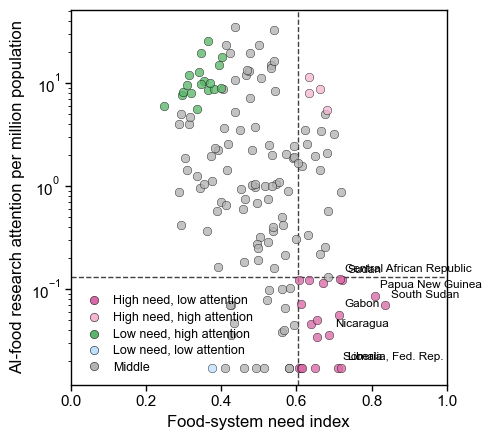

,country_label_plot,region_plot,under_attention_score_plot,need_index_plot
0,"Congo, Dem. Rep.",Sub-Saharan Africa,3.547049,0.580111
1,Panama,Latin America & Caribbean,3.527353,0.676234
2,Papua New Guinea,East Asia & Pacific,3.485839,0.807955
3,Guatemala,Latin America & Caribbean,3.095462,0.594918
4,South Sudan,Sub-Saharan Africa,3.081579,0.835271
5,Haiti,Latin America & Caribbean,3.040234,0.648777
6,Angola,Sub-Saharan Africa,3.011026,0.639044
7,Dominican Republic,Latin America & Caribbean,2.947493,0.633791
8,"Yemen, Rep.",Middle East & North Africa,2.866475,0.606678
9,"Venezuela, RB",Latin America & Caribbean,2.810350,0.684402


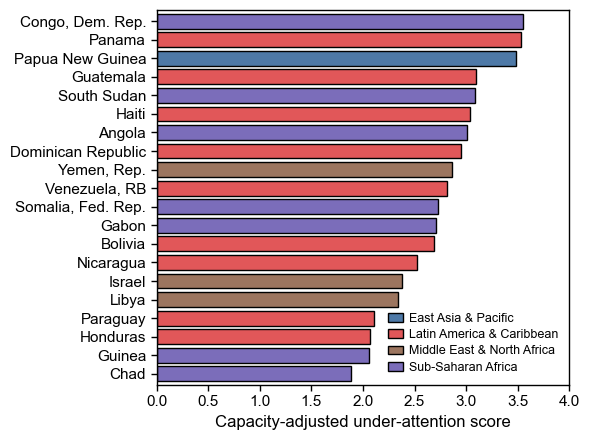


Figure 5 summary
Countries in Fig. 5A: 152
High-need, low-attention countries: 19
Top under-attended countries shown in Fig. 5B: 20

Top 10 under-attended countries:


,country_label_plot,region_plot,under_attention_score_plot,need_index_plot
0,"Congo, Dem. Rep.",Sub-Saharan Africa,3.547049,0.580111
1,Panama,Latin America & Caribbean,3.527353,0.676234
2,Papua New Guinea,East Asia & Pacific,3.485839,0.807955
3,Guatemala,Latin America & Caribbean,3.095462,0.594918
4,South Sudan,Sub-Saharan Africa,3.081579,0.835271
5,Haiti,Latin America & Caribbean,3.040234,0.648777
6,Angola,Sub-Saharan Africa,3.011026,0.639044
7,Dominican Republic,Latin America & Caribbean,2.947493,0.633791
8,"Yemen, Rep.",Middle East & North Africa,2.866475,0.606678
9,"Venezuela, RB",Latin America & Caribbean,2.810350,0.684402


In [30]:
# ============================================================
# Cell 19. Figure 5
#          Attention–need mismatch in AI-food research
#          Fig. 5A: Food-system need vs AI-food research attention per capita
#          Fig. 5B: Top capacity-adjusted under-attended countries
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

MISMATCH_IN = OUT_DIR / "15_country_attention_need_mismatch_food_system_core_main.csv"
UNDER_IN = OUT_DIR / "15_top_under_attended_countries_capacity_adjusted.csv"

SAVE_FIGURE = False
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not MISMATCH_IN.exists():
    raise FileNotFoundError(f"Missing required file: {MISMATCH_IN}")

if not UNDER_IN.exists():
    raise FileNotFoundError(f"Missing required file: {UNDER_IN}")

mismatch_df = pd.read_csv(MISMATCH_IN, low_memory=False)
under_df = pd.read_csv(UNDER_IN, low_memory=False)

print("Mismatch table:", mismatch_df.shape)
print("Under-attended table:", under_df.shape)

print("\nMismatch columns:")
print(mismatch_df.columns.tolist())

print("\nUnder-attended columns:")
print(under_df.columns.tolist())

display(mismatch_df.head())
display(under_df.head())


# ------------------------------------------------------------
# 1. Figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

TICK_LABEL_SIZE = 11
TICK_LENGTH = 4
TICK_WIDTH = 1.0
BOX_LINE_WIDTH = 1.0
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 9
POINT_SIZE = 38
POINT_ALPHA = 0.78

def style_axis(ax):
    ax.tick_params(
        axis="both",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        colors="black"
    )

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
        ax.spines[spine].set_color("black")

def save_figure(fig, filename):
    if SAVE_FIGURE:
        fig.savefig(FIG_DIR / filename, dpi=600, bbox_inches="tight")
        fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
        print("Saved:", FIG_DIR / filename)

def pct_formatter(x, pos):
    return f"{x:.1f}"

def decimal_formatter(x, pos):
    return f"{x:.1f}"


# ------------------------------------------------------------
# 2. Automatic column detection
# ------------------------------------------------------------
def find_first_existing_column(df, candidates, required=True, label="column"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find required {label}. Candidates: {candidates}")
    return None

# Country columns
ISO_COL = find_first_existing_column(
    mismatch_df,
    ["iso3", "ISO3", "country_code", "Country Code"],
    required=True,
    label="ISO3 column"
)

COUNTRY_COL = find_first_existing_column(
    mismatch_df,
    ["country_label", "country_need", "country", "country_name", "Country Name", "Country", "name"],
    required=False,
    label="country name column"
)

REGION_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_region", "region", "Region", "wb_region", "world_bank_region"],
    required=False,
    label="region column"
)

INCOME_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_income_group", "income_group", "Income Group", "income", "wb_income_group"],
    required=False,
    label="income group column"
)

# Need index
NEED_COL = find_first_existing_column(
    mismatch_df,
    [
        "food_system_need_index_main_min4",
        "food_system_need_index",
        "need_index",
        "need_score",
    ],
    required=True,
    label="food-system need index"
)

# Attention per capita candidates
ATTN_PC_COL = find_first_existing_column(
    mismatch_df,
    [
        "ai_food_papers_per_million_population_fractional",
        "fractional_attention_per_million_population",
        "papers_per_million_population_fractional",
        "attention_per_million_population",
        "ai_food_attention_per_million_population",
    ],
    required=False,
    label="attention per capita column"
)

# Fractional attention candidates
FRACTIONAL_ATTENTION_COL = find_first_existing_column(
    mismatch_df,
    [
        "fractional_attention",
        "fractional_publication_count",
        "fractional_papers",
        "n_records_fractional",
        "ai_food_fractional_attention",
        "total_fractional_attention",
    ],
    required=False,
    label="fractional attention column"
)

# Population candidates
POP_COL = find_first_existing_column(
    mismatch_df,
    [
        "population_2024",
        "population",
        "population_total",
        "SP.POP.TOTL",
    ],
    required=False,
    label="population column"
)

# Quadrant candidates
QUADRANT_COL = find_first_existing_column(
    mismatch_df,
    [
        "attention_need_quadrant",
        "quadrant",
        "need_attention_quadrant",
        "mismatch_quadrant",
    ],
    required=False,
    label="quadrant column"
)

# Under-attention score candidates
UNDER_SCORE_COL = find_first_existing_column(
    under_df,
    [
        "capacity_adjusted_under_attention_score",
        "under_attention_score",
        "need_residual_gap_score",
        "need_minus_attention_residual_z",
        "attention_need_mismatch_score",
        "mismatch_score",
    ],
    required=False,
    label="under-attention score column"
)

# If under_df does not contain an obvious score, infer numeric score column
if UNDER_SCORE_COL is None:
    numeric_cols = under_df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_numeric = {
        "year",
        "n_records",
        "rank",
        "food_system_need_index_main_min4",
        "need_percentile",
        "attention_per_capita_percentile",
        "fractional_attention",
        "population_2024",
        "gdp_current_usd",
        "rd_expenditure_pct_gdp",
    }
    candidate_numeric = [c for c in numeric_cols if c not in exclude_numeric]
    if len(candidate_numeric) == 0:
        raise KeyError("Could not infer under-attention score column from under_df.")
    UNDER_SCORE_COL = candidate_numeric[0]
    print(f"Inferred under-attention score column: {UNDER_SCORE_COL}")

UNDER_COUNTRY_COL = find_first_existing_column(
    under_df,
    ["country_label", "country_need", "country", "country_name", "Country Name", "Country", "name"],
    required=False,
    label="country name column in under_df"
)

UNDER_REGION_COL = find_first_existing_column(
    under_df,
    ["analysis_region", "region", "Region", "wb_region", "world_bank_region"],
    required=False,
    label="region column in under_df"
)

UNDER_NEED_COL = find_first_existing_column(
    under_df,
    [
        "food_system_need_index_main_min4",
        "food_system_need_index",
        "need_index",
        "need_score",
    ],
    required=False,
    label="need column in under_df"
)

print("\nDetected columns:")
print("ISO_COL:", ISO_COL)
print("COUNTRY_COL:", COUNTRY_COL)
print("REGION_COL:", REGION_COL)
print("INCOME_COL:", INCOME_COL)
print("NEED_COL:", NEED_COL)
print("ATTN_PC_COL:", ATTN_PC_COL)
print("FRACTIONAL_ATTENTION_COL:", FRACTIONAL_ATTENTION_COL)
print("POP_COL:", POP_COL)
print("QUADRANT_COL:", QUADRANT_COL)
print("UNDER_SCORE_COL:", UNDER_SCORE_COL)
print("UNDER_COUNTRY_COL:", UNDER_COUNTRY_COL)
print("UNDER_REGION_COL:", UNDER_REGION_COL)
print("UNDER_NEED_COL:", UNDER_NEED_COL)


# ------------------------------------------------------------
# 3. Prepare mismatch dataframe
# ------------------------------------------------------------
df = mismatch_df.copy()

df["iso3_plot"] = df[ISO_COL].astype(str).str.upper()

if COUNTRY_COL is not None:
    df["country_label_plot"] = df[COUNTRY_COL].fillna(df["iso3_plot"]).astype(str)
else:
    df["country_label_plot"] = df["iso3_plot"]

if REGION_COL is not None:
    df["region_plot"] = df[REGION_COL].fillna("Not classified").astype(str)
else:
    df["region_plot"] = "Not classified"

if INCOME_COL is not None:
    df["income_plot"] = df[INCOME_COL].fillna("Not classified").astype(str)
else:
    df["income_plot"] = "Not classified"

df["need_index_plot"] = pd.to_numeric(df[NEED_COL], errors="coerce")

# Attention per million population
if ATTN_PC_COL is not None:
    df["attention_per_million_plot"] = pd.to_numeric(df[ATTN_PC_COL], errors="coerce")
elif FRACTIONAL_ATTENTION_COL is not None and POP_COL is not None:
    df["fractional_attention_plot"] = pd.to_numeric(df[FRACTIONAL_ATTENTION_COL], errors="coerce")
    df["population_plot"] = pd.to_numeric(df[POP_COL], errors="coerce")
    df["attention_per_million_plot"] = (
        df["fractional_attention_plot"] / df["population_plot"] * 1_000_000
    )
else:
    raise KeyError(
        "Could not construct attention per million population. "
        "Need either an attention-per-capita column or fractional attention + population columns."
    )

if QUADRANT_COL is not None:
    df["quadrant_plot"] = df[QUADRANT_COL].fillna("middle").astype(str)
else:
    # Fallback quadrant definition using quartiles
    need_q75 = df["need_index_plot"].quantile(0.75)
    need_q25 = df["need_index_plot"].quantile(0.25)
    attn_q75 = df["attention_per_million_plot"].quantile(0.75)
    attn_q25 = df["attention_per_million_plot"].quantile(0.25)

    conditions = [
        (df["need_index_plot"] >= need_q75) & (df["attention_per_million_plot"] <= attn_q25),
        (df["need_index_plot"] <= need_q25) & (df["attention_per_million_plot"] >= attn_q75),
        (df["need_index_plot"] >= need_q75) & (df["attention_per_million_plot"] >= attn_q75),
        (df["need_index_plot"] <= need_q25) & (df["attention_per_million_plot"] <= attn_q25),
    ]

    choices = [
        "high_need_low_attention",
        "low_need_high_attention",
        "high_need_high_attention",
        "low_need_low_attention",
    ]

    df["quadrant_plot"] = np.select(conditions, choices, default="middle")

plot_df = df[
    df["need_index_plot"].notna()
    & df["attention_per_million_plot"].notna()
    & np.isfinite(df["attention_per_million_plot"])
].copy()

# Exclude countries with zero or negative attention from log-scale plotting by replacing zero with a small positive value.
# Keep zero-attention countries visible at the lower edge.
positive_min = plot_df.loc[plot_df["attention_per_million_plot"] > 0, "attention_per_million_plot"].min()

if pd.isna(positive_min):
    raise ValueError("No positive attention-per-million values found.")

zero_floor = positive_min * 0.5
plot_df["attention_per_million_log_plot"] = plot_df["attention_per_million_plot"].where(
    plot_df["attention_per_million_plot"] > 0,
    zero_floor
)

print("\nPlotting countries:", len(plot_df))
print("Zero or negative attention countries shifted to log floor:", (plot_df["attention_per_million_plot"] <= 0).sum())
print("Log floor:", zero_floor)

display(
    plot_df[
        [
            "iso3_plot",
            "country_label_plot",
            "region_plot",
            "need_index_plot",
            "attention_per_million_plot",
            "quadrant_plot",
        ]
    ]
    .sort_values("need_index_plot", ascending=False)
    .head(20)
)


# ------------------------------------------------------------
# 4. Color setting
# ------------------------------------------------------------
quadrant_color_map = {
    "high_need_low_attention": "#D96AA7",  # pink
    "low_need_high_attention": "#5AB769",  # green
    "high_need_high_attention": "#F4B6D2", # pale pink
    "low_need_low_attention": "#BFDFFF",   # pale sky
    "middle": "#B3B3B3",
}

quadrant_label_map = {
    "high_need_low_attention": "High need, low attention",
    "low_need_high_attention": "Low need, high attention",
    "high_need_high_attention": "High need, high attention",
    "low_need_low_attention": "Low need, low attention",
    "middle": "Middle",
}

plot_df["point_color"] = plot_df["quadrant_plot"].map(quadrant_color_map).fillna("#B3B3B3")

# Threshold lines for quadrant labels
need_q75 = plot_df["need_index_plot"].quantile(0.75)
need_q25 = plot_df["need_index_plot"].quantile(0.25)
attn_q75 = plot_df["attention_per_million_log_plot"].quantile(0.75)
attn_q25 = plot_df["attention_per_million_log_plot"].quantile(0.25)

print("\nThresholds:")
print("Need 25th percentile:", need_q25)
print("Need 75th percentile:", need_q75)
print("Attention per million 25th percentile:", attn_q25)
print("Attention per million 75th percentile:", attn_q75)


# ============================================================
# Fig. 5A. Attention–need relationship scatter plot
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4.5))

# Plot middle first, then highlighted groups on top
for q in ["middle", "low_need_low_attention", "low_need_high_attention", "high_need_high_attention", "high_need_low_attention"]:
    sub = plot_df[plot_df["quadrant_plot"] == q].copy()
    if len(sub) == 0:
        continue

    ax.scatter(
        sub["need_index_plot"],
        sub["attention_per_million_log_plot"],
        s=POINT_SIZE,
        c=quadrant_color_map.get(q, "#B3B3B3"),
        edgecolor="black",
        linewidth=0.35,
        alpha=POINT_ALPHA,
        label=quadrant_label_map.get(q, q),
        zorder=3 if q != "middle" else 2
    )

# Threshold lines: high need and low attention boundary
ax.axvline(
    need_q75,
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.75,
    zorder=1
)

ax.axhline(
    attn_q25,
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.75,
    zorder=1
)

ax.set_yscale("log")

ax.set_xlabel("Food-system need index", fontsize=AXIS_LABEL_SIZE)
ax.set_ylabel("AI-food research attention per million population", fontsize=AXIS_LABEL_SIZE)

ax.set_xlim(0, 1.0)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.xaxis.set_major_formatter(FuncFormatter(decimal_formatter))

style_axis(ax)

# Label selected under-attended high-need countries
label_candidates = plot_df[plot_df["quadrant_plot"] == "high_need_low_attention"].copy()
label_candidates = label_candidates.sort_values("need_index_plot", ascending=False).head(8)

for _, row in label_candidates.iterrows():
    ax.annotate(
        row["country_label_plot"],
        xy=(row["need_index_plot"], row["attention_per_million_log_plot"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8.5,
        ha="left",
        va="bottom"
    )

# Legend
handles = []
labels = []

for q in [
    "high_need_low_attention",
    "high_need_high_attention",
    "low_need_high_attention",
    "low_need_low_attention",
    "middle",
]:
    if q in plot_df["quadrant_plot"].values:
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markersize=6,
                markerfacecolor=quadrant_color_map.get(q, "#B3B3B3"),
                markeredgecolor="black",
                markeredgewidth=0.35
            )
        )
        labels.append(quadrant_label_map.get(q, q))

ax.legend(
    handles,
    labels,
    loc="lower left",
    frameon=False,
    fontsize=LEGEND_SIZE,
    handletextpad=0.5,
    labelspacing=0.35
)

plt.tight_layout()
save_figure(fig, "fig5a_attention_need_relationship_scatter.png")
plt.show()


# ------------------------------------------------------------
# 5. Prepare under-attended dataframe
# ------------------------------------------------------------
udf = under_df.copy()

if UNDER_COUNTRY_COL is not None:
    udf["country_label_plot"] = udf[UNDER_COUNTRY_COL].astype(str)
else:
    udf_iso_col = find_first_existing_column(
        udf,
        ["iso3", "ISO3", "country_code", "Country Code"],
        required=True,
        label="ISO3 column in under_df"
    )
    udf["country_label_plot"] = udf[udf_iso_col].astype(str)

if UNDER_REGION_COL is not None:
    udf["region_plot"] = udf[UNDER_REGION_COL].fillna("Not classified").astype(str)
else:
    udf["region_plot"] = "Not classified"

udf["under_attention_score_plot"] = pd.to_numeric(udf[UNDER_SCORE_COL], errors="coerce")

if UNDER_NEED_COL is not None:
    udf["need_index_plot"] = pd.to_numeric(udf[UNDER_NEED_COL], errors="coerce")
else:
    udf["need_index_plot"] = np.nan

udf = udf[udf["under_attention_score_plot"].notna()].copy()

TOP_N = 20
top_under = udf.sort_values("under_attention_score_plot", ascending=False).head(TOP_N).copy()
top_under = top_under.iloc[::-1].copy()

display(
    top_under.iloc[::-1][
        ["country_label_plot", "region_plot", "under_attention_score_plot", "need_index_plot"]
    ]
)


# ------------------------------------------------------------
# 6. Region colors for bar plot
# ------------------------------------------------------------
region_order = [
    "East Asia & Pacific",
    "South Asia",
    "Europe & Central Asia",
    "North America",
    "Latin America & Caribbean",
    "Middle East & North Africa",
    "Sub-Saharan Africa",
    "Not classified",
]

region_color_map = {
    "East Asia & Pacific": "#4E79A7",
    "South Asia": "#F28E2B",
    "Europe & Central Asia": "#59A14F",
    "North America": "#76B7B2",
    "Latin America & Caribbean": "#E15759",
    "Middle East & North Africa": "#9C755F",
    "Sub-Saharan Africa": "#7B6DBA",
    "Not classified": "#B3B3B3",
}

bar_colors = [
    region_color_map.get(region, "#B3B3B3")
    for region in top_under["region_plot"]
]


# ============================================================
# Fig. 5B. Top under-attended high-need countries
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4.5))

y_pos = np.arange(len(top_under))

ax.barh(
    y_pos,
    top_under["under_attention_score_plot"],
    color=bar_colors,
    edgecolor="black",
    linewidth=BOX_LINE_WIDTH
)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_under["country_label_plot"], fontsize=TICK_LABEL_SIZE)

ax.set_xlabel("Capacity-adjusted under-attention score", fontsize=AXIS_LABEL_SIZE)

# x-axis range and tick interval
ax.set_xlim(0, 4.0)
ax.set_xticks(np.arange(0, 4.01, 0.5))

style_axis(ax)

ax.margins(y=0.01)

# Region legend for represented regions only
handles = []
labels = []

for region in region_order:
    if region in top_under["region_plot"].values:
        handles.append(
            Patch(
                facecolor=region_color_map.get(region, "#B3B3B3"),
                edgecolor="black",
                linewidth=BOX_LINE_WIDTH
            )
        )
        labels.append(region)

ax.legend(
    handles,
    labels,
    loc="lower right",
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.2,
    handletextpad=0.5,
    labelspacing=0.35
)

plt.tight_layout()
save_figure(fig, "fig5b_top_capacity_adjusted_under_attended_countries.png")
plt.show()


# ------------------------------------------------------------
# 7. Summary output
# ------------------------------------------------------------
print("\nFigure 5 summary")
print("Countries in Fig. 5A:", len(plot_df))
print("High-need, low-attention countries:", (plot_df["quadrant_plot"] == "high_need_low_attention").sum())
print("Top under-attended countries shown in Fig. 5B:", len(top_under))

if len(top_under) > 0:
    print("\nTop 10 under-attended countries:")
    display(
        top_under.iloc[::-1]
        .head(10)[
            ["country_label_plot", "region_plot", "under_attention_score_plot", "need_index_plot"]
        ]
    )

Mismatch table: (152, 47)

Mismatch columns:
['iso3', 'country_need', 'region_raw', 'income_group_raw', 'population', 'gdp_current_usd', 'rd_expenditure_pct_gdp', 'food_system_need_index_main_min4', 'food_system_need_index_strict_all5', 'need_food_security_score', 'need_nutrition_score', 'need_food_waste_score', 'need_sustainability_score', 'need_supply_vulnerability_score', 'n_need_axes_available', 'dominant_need_profile', 'missing_need_axes', 'analysis_region', 'analysis_income_group', 'ai_food_papers_full_count', 'ai_food_papers_fractional_count', 'n_unique_papers', 'first_year', 'last_year', 'global_fractional_attention_share_pct', 'ai_food_papers_per_million_population_fractional', 'ai_food_papers_per_billion_gdp_fractional', 'has_any_ai_food_attention', 'flag_population_ge_1m', 'flag_main_need_index_available', 'need_percentile', 'attention_count_percentile', 'attention_per_capita_percentile', 'attention_per_gdp_percentile', 'simple_need_attention_gap_count', 'simple_need_attenti

,iso3,country_need,region_raw,income_group_raw,population,gdp_current_usd,rd_expenditure_pct_gdp,food_system_need_index_main_min4,food_system_need_index_strict_all5,need_food_security_score,...,log_fractional_attention,expected_log_fractional_attention,attention_capacity_residual,need_z,attention_capacity_residual_z,attention_count_z,capacity_adjusted_under_attention_score,raw_attention_need_gap_z,attention_need_quadrant,mismatch_priority_group
0,COD,"Congo, Dem. Rep.",Sub-Saharan Africa,Low income,109276265.0,7.074936e+10,0.40638,0.580111,0.580111,0.970414,...,0.000000,2.861543,-2.861543,0.583052,-2.963997,-1.389176,3.547049,1.972228,middle,highest_under_attention
1,PAN,Panama,Latin America & Caribbean,High income,4515577.0,8.626040e+10,0.19708,0.676234,0.676234,0.526627,...,0.773190,2.878855,-2.105665,1.346297,-2.181056,-1.034600,3.527353,2.380897,middle,highest_under_attention
2,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,3.253848e+10,0.03158,0.807955,0.807955,0.934911,...,0.650588,1.706416,-1.055828,2.392208,-1.093631,-1.090824,3.485839,3.483032,high_need_low_attention,highest_under_attention
3,GTM,Guatemala,Latin America & Caribbean,Upper middle income,18406359.0,1.131996e+11,0.00609,0.594918,0.594918,0.704142,...,0.606136,2.918193,-2.312057,0.700625,-2.394837,-1.111209,3.095462,1.811834,middle,highest_under_attention
4,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,3.534969e+10,NaN,0.835271,NaN,0.887574,...,0.606136,1.062283,-0.456147,2.609100,-0.472478,-1.111209,3.081579,3.720309,high_need_low_attention,highest_under_attention



Region summary: (7, 8)


,analysis_region,n_countries,median_need_index,median_fractional_attention,median_attention_per_million,median_capacity_adjusted_under_attention_score,n_high_need_low_attention,n_highest_under_attention
0,Latin America & Caribbean,22,0.591688,4.083333,0.501837,1.409780,5,7
1,Middle East & North Africa,17,0.622651,39.487771,2.433132,0.411336,2,3
2,Sub-Saharan Africa,42,0.568151,3.141667,0.233592,0.359461,11,5
3,North America,2,0.419847,1739.374876,10.858401,-0.411984,0,0
4,East Asia & Pacific,18,0.425259,115.202579,1.348721,-0.816815,1,1



Income summary: (5, 8)


,analysis_income_group,n_countries,median_need_index,median_fractional_attention,median_attention_per_million,median_capacity_adjusted_under_attention_score,n_high_need_low_attention,n_highest_under_attention
0,Low income,24,0.578494,1.217262,0.100901,0.659576,9,4
1,Not classified,2,0.548743,45.078175,0.393157,0.333977,0,1
2,Lower middle income,42,0.545600,9.175000,0.366569,0.209512,7,5
3,Upper middle income,38,0.499696,7.913095,1.431899,-0.122715,3,4
4,High income,46,0.409485,109.805350,9.255786,-0.854975,0,2



Quadrant counts: (5, 3)


,attention_need_quadrant,n_countries,pct_countries
0,middle,110,72.37
1,high_need_low_attention,19,12.50
2,low_need_high_attention,18,11.84
3,high_need_high_attention,4,2.63
4,low_need_low_attention,1,0.66



Detected columns:
ISO_COL: iso3
COUNTRY_COL: country_need
REGION_COL: analysis_region
INCOME_COL: analysis_income_group
NEED_COL: food_system_need_index_main_min4
QUADRANT_COL: attention_need_quadrant
UNDER_SCORE_COL: capacity_adjusted_under_attention_score

Countries available for Fig. 6: 151


,iso3_plot,country_label_plot,region_plot,income_plot,need_index_plot,under_attention_score_plot,quadrant_plot
0,COD,"Congo, Dem. Rep.",Sub-Saharan Africa,Low income,0.580111,3.547049,middle
1,PAN,Panama,Latin America & Caribbean,High income,0.676234,3.527353,middle
2,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,0.807955,3.485839,high_need_low_attention
3,GTM,Guatemala,Latin America & Caribbean,Upper middle income,0.594918,3.095462,middle
4,SSD,South Sudan,Sub-Saharan Africa,Low income,0.835271,3.081579,high_need_low_attention
5,HTI,Haiti,Latin America & Caribbean,Lower middle income,0.648777,3.040234,high_need_low_attention
6,AGO,Angola,Sub-Saharan Africa,Lower middle income,0.639044,3.011026,high_need_low_attention
7,DOM,Dominican Republic,Latin America & Caribbean,Upper middle income,0.633791,2.947493,high_need_low_attention
8,YEM,"Yemen, Rep.",Middle East & North Africa,Low income,0.606678,2.866475,high_need_low_attention
9,VEN,"Venezuela, RB",Latin America & Caribbean,Not classified,0.684402,2.810350,middle


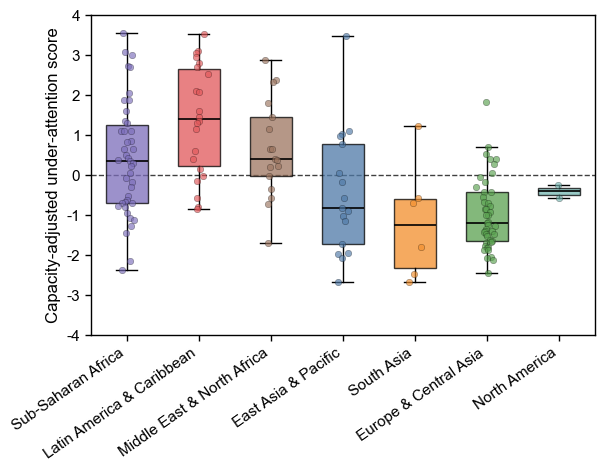


Calculated region-level summary:


,region_plot,n_countries,median_under_attention,mean_under_attention,q25_under_attention,q75_under_attention
6,Sub-Saharan Africa,42,0.359461,0.425757,-0.696260,1.253634
2,Latin America & Caribbean,22,1.409780,1.383202,0.217731,2.650344
3,Middle East & North Africa,17,0.411336,0.652487,-0.022880,1.446521
0,East Asia & Pacific,17,-0.816815,-0.446467,-1.734889,0.786055
5,South Asia,6,-1.251631,-1.164546,-2.313973,-0.599915
1,Europe & Central Asia,45,-1.211525,-0.977852,-1.658158,-0.416995
4,North America,2,-0.411984,-0.411984,-0.493047,-0.330920


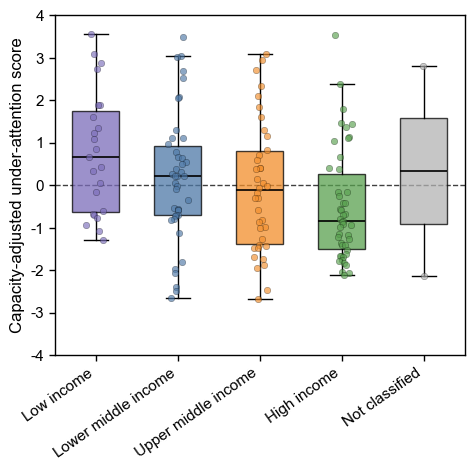


Calculated income-group summary:


,income_plot,n_countries,median_under_attention,mean_under_attention,q25_under_attention,q75_under_attention
1,Low income,23,0.659576,0.754285,-0.642633,1.744242
2,Lower middle income,42,0.209512,0.170427,-0.703775,0.928949
4,Upper middle income,38,-0.122715,-0.052239,-1.373690,0.798221
0,High income,46,-0.854975,-0.504117,-1.492707,0.254639
3,Not classified,2,0.333977,0.333977,-0.904210,1.572163


,region_plot,n_countries,n_high_need_low_attention,share_high_need_low_attention_pct
6,Sub-Saharan Africa,42,11,26.190476
2,Latin America & Caribbean,22,5,22.727273
3,Middle East & North Africa,17,2,11.764706
0,East Asia & Pacific,17,1,5.882353
5,South Asia,6,0,0.000000
1,Europe & Central Asia,45,0,0.000000
4,North America,2,0,0.000000


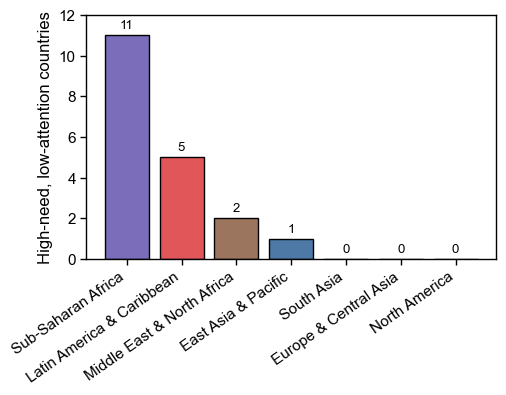


Saved calculated summaries:
processed\20_fig6_region_under_attention_summary_calculated.csv
processed\20_fig6_income_under_attention_summary_calculated.csv
processed\20_fig6_high_need_low_attention_by_region_calculated.csv


In [43]:
# ============================================================
# Cell 20. Figure 6
#          Regional and income-group structure of the AI-food
#          attention–need mismatch
#
#          Fig. 6A: Under-attention score by region
#          Fig. 6B: Under-attention score by income group
#          Fig. 6C: High-need, low-attention countries by region
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

MISMATCH_IN = OUT_DIR / "15_country_attention_need_mismatch_food_system_core_main.csv"
REGION_SUMMARY_IN = OUT_DIR / "15_region_mismatch_summary.csv"
INCOME_SUMMARY_IN = OUT_DIR / "15_income_group_mismatch_summary.csv"
QUADRANT_COUNTS_IN = OUT_DIR / "15_attention_need_quadrant_counts.csv"

SAVE_FIGURE = False
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not MISMATCH_IN.exists():
    raise FileNotFoundError(f"Missing required file: {MISMATCH_IN}")

mismatch_df = pd.read_csv(MISMATCH_IN, low_memory=False)

print("Mismatch table:", mismatch_df.shape)
print("\nMismatch columns:")
print(mismatch_df.columns.tolist())
display(mismatch_df.head())

if REGION_SUMMARY_IN.exists():
    region_summary_df = pd.read_csv(REGION_SUMMARY_IN, low_memory=False)
    print("\nRegion summary:", region_summary_df.shape)
    display(region_summary_df.head())
else:
    region_summary_df = None
    print("\nRegion summary file not found. Summary will be calculated from mismatch table.")

if INCOME_SUMMARY_IN.exists():
    income_summary_df = pd.read_csv(INCOME_SUMMARY_IN, low_memory=False)
    print("\nIncome summary:", income_summary_df.shape)
    display(income_summary_df.head())
else:
    income_summary_df = None
    print("\nIncome summary file not found. Summary will be calculated from mismatch table.")

if QUADRANT_COUNTS_IN.exists():
    quadrant_counts_df = pd.read_csv(QUADRANT_COUNTS_IN, low_memory=False)
    print("\nQuadrant counts:", quadrant_counts_df.shape)
    display(quadrant_counts_df)
else:
    quadrant_counts_df = None
    print("\nQuadrant count file not found. Counts will be calculated from mismatch table.")


# ------------------------------------------------------------
# 1. Figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

TICK_LABEL_SIZE = 11
TICK_LENGTH = 4
TICK_WIDTH = 1.0
BOX_LINE_WIDTH = 1.0
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 9

BOX_WIDTH = 0.58
POINT_SIZE = 22
POINT_ALPHA = 0.65

def style_axis(ax):
    ax.tick_params(
        axis="both",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        colors="black"
    )

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
        ax.spines[spine].set_color("black")

def save_figure(fig, filename):
    if SAVE_FIGURE:
        fig.savefig(FIG_DIR / filename, dpi=600, bbox_inches="tight")
        fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
        print("Saved:", FIG_DIR / filename)


# ------------------------------------------------------------
# 2. Automatic column detection
# ------------------------------------------------------------
def find_first_existing_column(df, candidates, required=True, label="column"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find required {label}. Candidates: {candidates}")
    return None

ISO_COL = find_first_existing_column(
    mismatch_df,
    ["iso3", "ISO3", "country_code", "Country Code"],
    required=True,
    label="ISO3 column"
)

COUNTRY_COL = find_first_existing_column(
    mismatch_df,
    ["country_label", "country_need", "country", "country_name", "Country Name", "Country", "name"],
    required=False,
    label="country name column"
)

REGION_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_region", "region", "Region", "wb_region", "world_bank_region"],
    required=False,
    label="region column"
)

INCOME_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_income_group", "income_group", "Income Group", "income", "wb_income_group"],
    required=False,
    label="income group column"
)

NEED_COL = find_first_existing_column(
    mismatch_df,
    [
        "food_system_need_index_main_min4",
        "food_system_need_index",
        "need_index",
        "need_score",
    ],
    required=False,
    label="food-system need index"
)

QUADRANT_COL = find_first_existing_column(
    mismatch_df,
    [
        "attention_need_quadrant",
        "quadrant",
        "need_attention_quadrant",
        "mismatch_quadrant",
    ],
    required=False,
    label="quadrant column"
)

UNDER_SCORE_COL = find_first_existing_column(
    mismatch_df,
    [
        "capacity_adjusted_under_attention_score",
        "under_attention_score",
        "need_residual_gap_score",
        "need_minus_attention_residual_z",
        "attention_need_mismatch_score",
        "mismatch_score",
    ],
    required=False,
    label="under-attention score column"
)

# If obvious under-attention score column is not found, infer from numeric columns
if UNDER_SCORE_COL is None:
    numeric_cols = mismatch_df.select_dtypes(include=[np.number]).columns.tolist()

    exclude_numeric = {
        "year",
        "n_records",
        "rank",
        "food_system_need_index_main_min4",
        "food_system_need_index",
        "need_index",
        "need_score",
        "need_percentile",
        "attention_per_capita_percentile",
        "fractional_attention",
        "fractional_publication_count",
        "n_records_fractional",
        "population_2024",
        "population",
        "gdp_current_usd",
        "rd_expenditure_pct_gdp",
        "ai_food_papers_per_million_population_fractional",
        "attention_per_million_population",
        "papers_per_million_population_fractional",
    }

    candidate_numeric = [c for c in numeric_cols if c not in exclude_numeric]

    print("\nNumeric columns available for inferred score:")
    print(candidate_numeric)

    if len(candidate_numeric) == 0:
        raise KeyError(
            "Could not infer under-attention score column. "
            "Please manually set UNDER_SCORE_COL to the correct column name."
        )

    preferred = [
        c for c in candidate_numeric
        if any(k in c.lower() for k in ["under", "mismatch", "gap", "residual", "score"])
    ]

    UNDER_SCORE_COL = preferred[0] if len(preferred) > 0 else candidate_numeric[0]
    print(f"Inferred UNDER_SCORE_COL: {UNDER_SCORE_COL}")

print("\nDetected columns:")
print("ISO_COL:", ISO_COL)
print("COUNTRY_COL:", COUNTRY_COL)
print("REGION_COL:", REGION_COL)
print("INCOME_COL:", INCOME_COL)
print("NEED_COL:", NEED_COL)
print("QUADRANT_COL:", QUADRANT_COL)
print("UNDER_SCORE_COL:", UNDER_SCORE_COL)


# ------------------------------------------------------------
# 3. Prepare plotting dataframe
# ------------------------------------------------------------
df = mismatch_df.copy()

df["iso3_plot"] = df[ISO_COL].astype(str).str.upper()

if COUNTRY_COL is not None:
    df["country_label_plot"] = df[COUNTRY_COL].fillna(df["iso3_plot"]).astype(str)
else:
    df["country_label_plot"] = df["iso3_plot"]

if REGION_COL is not None:
    df["region_plot"] = df[REGION_COL].fillna("Not classified").astype(str)
else:
    df["region_plot"] = "Not classified"

if INCOME_COL is not None:
    df["income_plot"] = df[INCOME_COL].fillna("Not classified").astype(str)
else:
    df["income_plot"] = "Not classified"

if NEED_COL is not None:
    df["need_index_plot"] = pd.to_numeric(df[NEED_COL], errors="coerce")
else:
    df["need_index_plot"] = np.nan

df["under_attention_score_plot"] = pd.to_numeric(df[UNDER_SCORE_COL], errors="coerce")

if QUADRANT_COL is not None:
    df["quadrant_plot"] = df[QUADRANT_COL].fillna("middle").astype(str)
else:
    if NEED_COL is None:
        raise KeyError("Need index column is required to infer quadrants.")

    attention_pc_col = find_first_existing_column(
        df,
        [
            "ai_food_papers_per_million_population_fractional",
            "fractional_attention_per_million_population",
            "papers_per_million_population_fractional",
            "attention_per_million_population",
            "ai_food_attention_per_million_population",
        ],
        required=True,
        label="attention per capita column for quadrant inference"
    )

    df["attention_per_million_plot"] = pd.to_numeric(df[attention_pc_col], errors="coerce")

    need_q75 = df["need_index_plot"].quantile(0.75)
    need_q25 = df["need_index_plot"].quantile(0.25)
    attn_q75 = df["attention_per_million_plot"].quantile(0.75)
    attn_q25 = df["attention_per_million_plot"].quantile(0.25)

    conditions = [
        (df["need_index_plot"] >= need_q75) & (df["attention_per_million_plot"] <= attn_q25),
        (df["need_index_plot"] <= need_q25) & (df["attention_per_million_plot"] >= attn_q75),
        (df["need_index_plot"] >= need_q75) & (df["attention_per_million_plot"] >= attn_q75),
        (df["need_index_plot"] <= need_q25) & (df["attention_per_million_plot"] <= attn_q25),
    ]

    choices = [
        "high_need_low_attention",
        "low_need_high_attention",
        "high_need_high_attention",
        "low_need_low_attention",
    ]

    df["quadrant_plot"] = np.select(conditions, choices, default="middle")

plot_df = df[
    df["under_attention_score_plot"].notna()
    & np.isfinite(df["under_attention_score_plot"])
].copy()

print("\nCountries available for Fig. 6:", len(plot_df))

display(
    plot_df[
        [
            "iso3_plot",
            "country_label_plot",
            "region_plot",
            "income_plot",
            "need_index_plot",
            "under_attention_score_plot",
            "quadrant_plot",
        ]
    ]
    .sort_values("under_attention_score_plot", ascending=False)
    .head(20)
)


# ------------------------------------------------------------
# 4. Orders and colors
# ------------------------------------------------------------
region_order_default = [
    "Sub-Saharan Africa",
    "Latin America & Caribbean",
    "Middle East & North Africa",
    "East Asia & Pacific",
    "South Asia",
    "Europe & Central Asia",
    "North America",
    "Not classified",
]

income_order_default = [
    "Low income",
    "Lower middle income",
    "Upper middle income",
    "High income",
    "Not classified",
]

region_color_map = {
    "East Asia & Pacific": "#4E79A7",
    "South Asia": "#F28E2B",
    "Europe & Central Asia": "#59A14F",
    "North America": "#76B7B2",
    "Latin America & Caribbean": "#E15759",
    "Middle East & North Africa": "#9C755F",
    "Sub-Saharan Africa": "#7B6DBA",
    "Not classified": "#B3B3B3",
}

income_color_map = {
    "Low income": "#7B6DBA",
    "Lower middle income": "#4E79A7",
    "Upper middle income": "#F28E2B",
    "High income": "#59A14F",
    "Not classified": "#B3B3B3",
}

region_order = [
    r for r in region_order_default
    if r in plot_df["region_plot"].unique()
]

region_order += [
    r for r in sorted(plot_df["region_plot"].dropna().unique())
    if r not in region_order
]

income_order = [
    i for i in income_order_default
    if i in plot_df["income_plot"].unique()
]

income_order += [
    i for i in sorted(plot_df["income_plot"].dropna().unique())
    if i not in income_order
]


# ------------------------------------------------------------
# 5. Helper for boxplot with jitter
# ------------------------------------------------------------
def draw_group_boxplot(
    data,
    group_col,
    value_col,
    group_order,
    color_map,
    ylabel,
    figsize,
    filename,
    rotate_xticks=False,
    bottom_margin=0.28,
    left_margin=0.14
):
    fig, ax = plt.subplots(figsize=figsize)

    values_by_group = [
        data.loc[data[group_col] == group, value_col].dropna().values
        for group in group_order
    ]

    positions = np.arange(1, len(group_order) + 1)

    bp = ax.boxplot(
        values_by_group,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.2),
        boxprops=dict(linewidth=BOX_LINE_WIDTH, color="black"),
        whiskerprops=dict(linewidth=BOX_LINE_WIDTH, color="black"),
        capprops=dict(linewidth=BOX_LINE_WIDTH, color="black")
    )

    for patch, group in zip(bp["boxes"], group_order):
        patch.set_facecolor(color_map.get(group, "#B3B3B3"))
        patch.set_alpha(0.75)

    rng = np.random.default_rng(123)

    for i, group in enumerate(group_order, start=1):
        y = data.loc[data[group_col] == group, value_col].dropna().values
        if len(y) == 0:
            continue

        x = rng.normal(i, 0.055, size=len(y))

        ax.scatter(
            x,
            y,
            s=POINT_SIZE,
            color=color_map.get(group, "#B3B3B3"),
            edgecolor="black",
            linewidth=0.25,
            alpha=POINT_ALPHA,
            zorder=3
        )

    ax.axhline(
        0,
        color="black",
        linewidth=1.0,
        linestyle="--",
        alpha=0.75,
        zorder=1
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, fontsize=TICK_LABEL_SIZE)

    if rotate_xticks:
        for tick in ax.get_xticklabels():
            tick.set_rotation(35)
            tick.set_horizontalalignment("right")

    # No x-axis label for Fig. 6A and Fig. 6B
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)

    # Fixed y-axis range and ticks for Fig. 6A and Fig. 6B
    ax.set_ylim(-4, 4)
    ax.set_yticks(np.arange(-4, 4.1, 1))

    style_axis(ax)

    fig.subplots_adjust(
        left=left_margin,
        right=0.98,
        bottom=bottom_margin,
        top=0.96
    )

    save_figure(fig, filename)
    plt.show()

    summary = (
        data
        .groupby(group_col, dropna=False)
        .agg(
            n_countries=(value_col, "count"),
            median_under_attention=(value_col, "median"),
            mean_under_attention=(value_col, "mean"),
            q25_under_attention=(value_col, lambda x: np.nanpercentile(x, 25)),
            q75_under_attention=(value_col, lambda x: np.nanpercentile(x, 75)),
        )
        .reset_index()
    )

    summary[group_col] = pd.Categorical(
        summary[group_col],
        categories=group_order,
        ordered=True
    )

    summary = summary.sort_values(group_col)

    return summary


# ============================================================
# Fig. 6A. Under-attention score by region
# ============================================================
region_summary_calc = draw_group_boxplot(
    data=plot_df,
    group_col="region_plot",
    value_col="under_attention_score_plot",
    group_order=region_order,
    color_map=region_color_map,
    ylabel="Capacity-adjusted under-attention score",
    figsize=(6, 5),
    filename="fig6a_under_attention_by_region.png",
    rotate_xticks=True,
    bottom_margin=0.32,
    left_margin=0.14
)

print("\nCalculated region-level summary:")
display(region_summary_calc)


# ============================================================
# Fig. 6B. Under-attention score by income group
# ============================================================
income_summary_calc = draw_group_boxplot(
    data=plot_df,
    group_col="income_plot",
    value_col="under_attention_score_plot",
    group_order=income_order,
    color_map=income_color_map,
    ylabel="Capacity-adjusted under-attention score",
    figsize=(5, 5),
    filename="fig6b_under_attention_by_income_group.png",
    rotate_xticks=True,
    bottom_margin=0.28,
    left_margin=0.16
)

print("\nCalculated income-group summary:")
display(income_summary_calc)


# ============================================================
# Fig. 6C. High-need, low-attention countries by region
# ============================================================
target_quadrant = "high_need_low_attention"

quad_region_counts = (
    plot_df
    .assign(is_high_need_low_attention=lambda x: x["quadrant_plot"].eq(target_quadrant))
    .groupby("region_plot", dropna=False)
    .agg(
        n_countries=("iso3_plot", "nunique"),
        n_high_need_low_attention=("is_high_need_low_attention", "sum")
    )
    .reset_index()
)

quad_region_counts["share_high_need_low_attention_pct"] = (
    quad_region_counts["n_high_need_low_attention"]
    / quad_region_counts["n_countries"]
    * 100
)

quad_region_counts["region_plot"] = pd.Categorical(
    quad_region_counts["region_plot"],
    categories=region_order,
    ordered=True
)

quad_region_counts = quad_region_counts.sort_values("region_plot").copy()

display(quad_region_counts)

fig, ax = plt.subplots(figsize=(5, 4))

x_pos = np.arange(len(quad_region_counts))

bar_colors = [
    region_color_map.get(region, "#B3B3B3")
    for region in quad_region_counts["region_plot"].astype(str)
]

ax.bar(
    x_pos,
    quad_region_counts["n_high_need_low_attention"],
    color=bar_colors,
    edgecolor="black",
    linewidth=BOX_LINE_WIDTH
)

ax.set_xticks(x_pos)
ax.set_xticklabels(
    quad_region_counts["region_plot"].astype(str),
    fontsize=TICK_LABEL_SIZE,
    rotation=35,
    ha="right"
)

# No x-axis label for Fig. 6C
ax.set_xlabel("")

# Shorter y-axis label to prevent clipping
ax.set_ylabel("High-need, low-attention countries", fontsize=AXIS_LABEL_SIZE)

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Add headroom so value labels do not touch or leave the frame
max_count = quad_region_counts["n_high_need_low_attention"].max()
ax.set_ylim(0, 12)

style_axis(ax)

# Add counts above bars
for i, value in enumerate(quad_region_counts["n_high_need_low_attention"].values):
    ax.text(
        i,
        value + 0.18,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9.5
    )

# Explicit margins to avoid clipped y-label and x-tick labels
fig.subplots_adjust(
    left=0.16,
    right=0.98,
    bottom=0.33,
    top=0.94
)

save_figure(fig, "fig6c_high_need_low_attention_countries_by_region.png")
plt.show()


# ------------------------------------------------------------
# 6. Export calculated summaries
# ------------------------------------------------------------
region_summary_calc.to_csv(
    OUT_DIR / "20_fig6_region_under_attention_summary_calculated.csv",
    index=False,
    encoding="utf-8-sig"
)

income_summary_calc.to_csv(
    OUT_DIR / "20_fig6_income_under_attention_summary_calculated.csv",
    index=False,
    encoding="utf-8-sig"
)

quad_region_counts.to_csv(
    OUT_DIR / "20_fig6_high_need_low_attention_by_region_calculated.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved calculated summaries:")
print(OUT_DIR / "20_fig6_region_under_attention_summary_calculated.csv")
print(OUT_DIR / "20_fig6_income_under_attention_summary_calculated.csv")
print(OUT_DIR / "20_fig6_high_need_low_attention_by_region_calculated.csv")

Country-domain attention table: (1015, 12)
Mismatch table: (152, 47)

Domain table columns:
['iso3', 'country', 'analysis_region', 'analysis_income_group', 'primary_food_system_domain', 'ai_food_papers_full_count', 'ai_food_papers_fractional_count', 'n_unique_papers', 'first_year', 'last_year', 'country_total_fractional_count', 'within_country_domain_share_pct']

Mismatch table columns:
['iso3', 'country_need', 'region_raw', 'income_group_raw', 'population', 'gdp_current_usd', 'rd_expenditure_pct_gdp', 'food_system_need_index_main_min4', 'food_system_need_index_strict_all5', 'need_food_security_score', 'need_nutrition_score', 'need_food_waste_score', 'need_sustainability_score', 'need_supply_vulnerability_score', 'n_need_axes_available', 'dominant_need_profile', 'missing_need_axes', 'analysis_region', 'analysis_income_group', 'ai_food_papers_full_count', 'ai_food_papers_fractional_count', 'n_unique_papers', 'first_year', 'last_year', 'global_fractional_attention_share_pct', 'ai_food_pa

,iso3,country,analysis_region,analysis_income_group,primary_food_system_domain,ai_food_papers_full_count,ai_food_papers_fractional_count,n_unique_papers,first_year,last_year,country_total_fractional_count,within_country_domain_share_pct
0,CHN,China,East Asia & Pacific,Upper middle income,food_safety_quality_authentication,2138.0,1930.183333,2138,2010,2025,8384.096068,23.021961
1,CHN,China,East Asia & Pacific,Upper middle income,agriculture_production,2098.0,1861.042857,2098,2010,2025,8384.096068,22.197299
2,CHN,China,East Asia & Pacific,Upper middle income,nutrition_diet_health,1738.0,1506.790512,1738,2010,2025,8384.096068,17.972009
3,CHN,China,East Asia & Pacific,Upper middle income,food_security_access,1340.0,1087.211905,1340,2010,2025,8384.096068,12.967551
4,USA,United States,North America,High income,nutrition_diet_health,1241.0,884.195869,1241,2010,2025,2938.863900,30.086316


,iso3,country_need,region_raw,income_group_raw,population,gdp_current_usd,rd_expenditure_pct_gdp,food_system_need_index_main_min4,food_system_need_index_strict_all5,need_food_security_score,...,log_fractional_attention,expected_log_fractional_attention,attention_capacity_residual,need_z,attention_capacity_residual_z,attention_count_z,capacity_adjusted_under_attention_score,raw_attention_need_gap_z,attention_need_quadrant,mismatch_priority_group
0,COD,"Congo, Dem. Rep.",Sub-Saharan Africa,Low income,109276265.0,7.074936e+10,0.40638,0.580111,0.580111,0.970414,...,0.000000,2.861543,-2.861543,0.583052,-2.963997,-1.389176,3.547049,1.972228,middle,highest_under_attention
1,PAN,Panama,Latin America & Caribbean,High income,4515577.0,8.626040e+10,0.19708,0.676234,0.676234,0.526627,...,0.773190,2.878855,-2.105665,1.346297,-2.181056,-1.034600,3.527353,2.380897,middle,highest_under_attention
2,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,3.253848e+10,0.03158,0.807955,0.807955,0.934911,...,0.650588,1.706416,-1.055828,2.392208,-1.093631,-1.090824,3.485839,3.483032,high_need_low_attention,highest_under_attention
3,GTM,Guatemala,Latin America & Caribbean,Upper middle income,18406359.0,1.131996e+11,0.00609,0.594918,0.594918,0.704142,...,0.606136,2.918193,-2.312057,0.700625,-2.394837,-1.111209,3.095462,1.811834,middle,highest_under_attention
4,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,3.534969e+10,NaN,0.835271,NaN,0.887574,...,0.606136,1.062283,-0.456147,2.609100,-0.472478,-1.111209,3.081579,3.720309,high_need_low_attention,highest_under_attention


Inferred DOMAIN_ATTENTION_COL: ai_food_papers_full_count

Detected columns:
D_ISO_COL: iso3
DOMAIN_COL: primary_food_system_domain
DOMAIN_LABEL_COL: None
DOMAIN_ATTENTION_COL: ai_food_papers_full_count
M_ISO_COL: iso3
COUNTRY_COL: country_need
REGION_COL: analysis_region
INCOME_COL: analysis_income_group
NEED_COL: food_system_need_index_main_min4
NEED_PERCENTILE_COL: need_percentile
QUADRANT_COL: attention_need_quadrant
ATTN_PC_COL: ai_food_papers_per_million_population_fractional

Aggregated country-domain table: (1015, 4)


,iso3_plot,domain_code_plot,domain_label_plot,domain_attention_plot
0,AFG,agriculture_production,Agricultural production,1.0
1,AFG,food_safety_quality_authentication,"Food safety, quality, and authentication",1.0
2,AFG,food_security_access,Food security and access,6.0
3,AFG,nutrition_diet_health,"Nutrition, diet, and health",2.0
4,AFG,sustainability_environment,Sustainability and environment,1.0


...

,iso3_plot,domain_code_plot,domain_label_plot,domain_attention_plot,country_label_plot,region_plot,income_plot,need_index_plot,need_percentile_plot,need_group_plot,quadrant_plot
0,AFG,agriculture_production,Agricultural production,1.0,Afghanistan,South Asia,Low income,0.582036,0.710526,Middle need,middle
1,AFG,food_safety_quality_authentication,"Food safety, quality, and authentication",1.0,Afghanistan,South Asia,Low income,0.582036,0.710526,Middle need,middle
2,AFG,food_security_access,Food security and access,6.0,Afghanistan,South Asia,Low income,0.582036,0.710526,Middle need,middle
3,AFG,nutrition_diet_health,"Nutrition, diet, and health",2.0,Afghanistan,South Asia,Low income,0.582036,0.710526,Middle need,middle
4,AFG,sustainability_environment,Sustainability and environment,1.0,Afghanistan,South Asia,Low income,0.582036,0.710526,Middle need,middle



Global domain shares:


,domain_code_plot,domain_label_plot,global_attention,global_share_pct
6,nutrition_diet_health,"Nutrition, diet, and health",9157.0,22.018371
0,agriculture_production,Agricultural production,7929.0,19.065596
3,food_security_access,Food security and access,7038.0,16.923151
2,food_safety_quality_authentication,"Food safety, quality, and authentication",6589.0,15.843513
9,sustainability_environment,Sustainability and environment,4384.0,10.541502
8,supply_chain_resilience,Supply chain and resilience,2996.0,7.204001
5,general_food_ai,General food AI,1623.0,3.902568
7,processing_preservation_packaging,"Processing, preservation, and packaging",866.0,2.082331
4,food_waste_loss,Food waste and loss,851.0,2.046263
1,alternative_protein,Alternative protein,155.0,0.372704



Domain share by food-system need group:


domain_label_plot,need_group_plot,"Nutrition, diet, and health",Agricultural production,Food security and access,"Food safety, quality, and authentication",Sustainability and environment,Supply chain and resilience,General food AI,"Processing, preservation, and packaging",Food waste and loss,Alternative protein
0,High need,17.754919,17.799642,25.760286,9.615385,14.221825,6.574240,3.443649,1.833631,2.772809,0.223614
1,Middle need,22.830950,17.997800,16.303630,15.313531,11.433810,7.040704,3.857719,2.720939,2.046205,0.454712
2,Low need,21.958238,19.741805,16.483260,16.666019,9.748415,7.345336,3.966248,1.765369,1.983124,0.342186


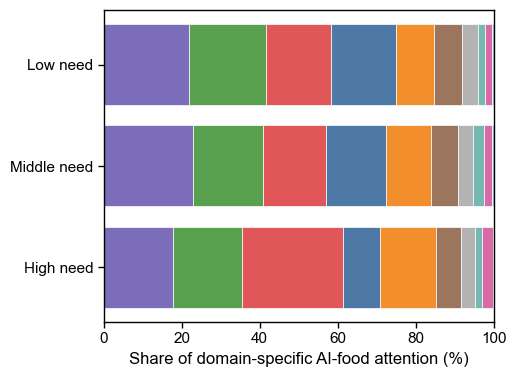


Domain share by attention–need quadrant:


domain_label_plot,quadrant_label_plot,"Nutrition, diet, and health",Agricultural production,Food security and access,"Food safety, quality, and authentication",Sustainability and environment,Supply chain and resilience,General food AI,"Processing, preservation, and packaging",Food waste and loss,Alternative protein
0,"High need, low attention",25.000000,6.250000,31.250000,7.812500,20.312500,4.687500,0.000000,3.125000,1.562500,0.000000
1,"High need, high attention",19.052045,20.167286,23.234201,7.527881,13.382900,7.156134,3.717472,2.323420,3.066914,0.371747
2,"Low need, high attention",22.586503,19.415951,15.234356,18.017178,9.369325,7.592638,3.970552,1.541104,1.899387,0.373006
3,Middle,21.591192,18.691775,18.253375,14.108504,11.547850,6.820107,3.855926,2.615454,2.142181,0.373636


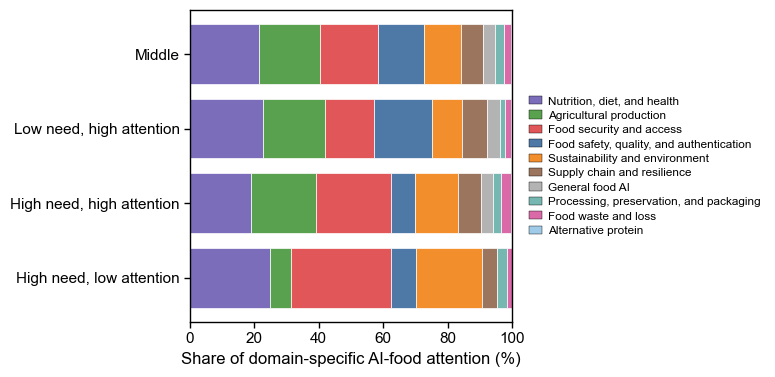


Domain-share difference in high-need, low-attention countries vs global corpus:


,domain_code_plot,domain_label_plot,global_attention,global_share_pct,hnla_attention,hnla_share_pct,share_difference_pct_point
1,agriculture_production,Agricultural production,7929.0,19.065596,4.0,6.2500,-12.815596
3,food_safety_quality_authentication,"Food safety, quality, and authentication",6589.0,15.843513,5.0,7.8125,-8.031013
6,general_food_ai,General food AI,1623.0,3.902568,0.0,0.0000,-3.902568
5,supply_chain_resilience,Supply chain and resilience,2996.0,7.204001,3.0,4.6875,-2.516501
8,food_waste_loss,Food waste and loss,851.0,2.046263,1.0,1.5625,-0.483763
9,alternative_protein,Alternative protein,155.0,0.372704,0.0,0.0000,-0.372704
7,processing_preservation_packaging,"Processing, preservation, and packaging",866.0,2.082331,2.0,3.1250,1.042669
0,nutrition_diet_health,"Nutrition, diet, and health",9157.0,22.018371,16.0,25.0000,2.981629
4,sustainability_environment,Sustainability and environment,4384.0,10.541502,13.0,20.3125,9.770998
2,food_security_access,Food security and access,7038.0,16.923151,20.0,31.2500,14.326849


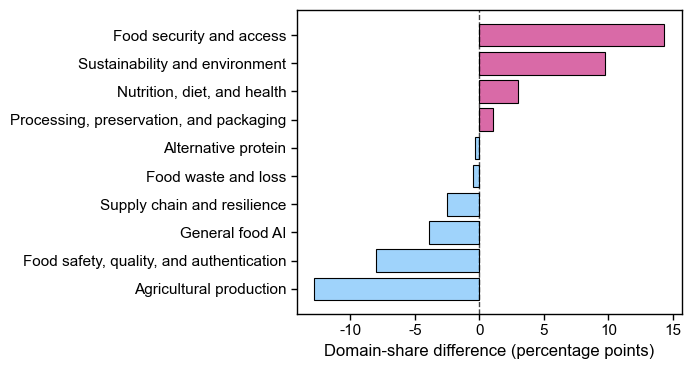


Saved Fig. 7 summary tables:
processed\21_fig7_domain_share_by_need_group.csv
processed\21_fig7_domain_share_by_attention_need_quadrant.csv
processed\21_fig7_domain_share_difference_hnla_vs_global.csv


In [53]:
# ============================================================
# Cell 21. Figure 7
#          Domain-specific attention–need mismatch
#
#          Fig. 7A: Domain composition by food-system need group
#          Fig. 7B: Domain composition by attention–need quadrant
#          Fig. 7C: Domain-share difference in high-need, low-attention countries
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

DOMAIN_IN = OUT_DIR / "14_country_domain_attention_primary_food_system_core_main.csv"
MISMATCH_IN = OUT_DIR / "15_country_attention_need_mismatch_food_system_core_main.csv"

SAVE_FIGURE = False
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not DOMAIN_IN.exists():
    raise FileNotFoundError(f"Missing required file: {DOMAIN_IN}")

if not MISMATCH_IN.exists():
    raise FileNotFoundError(f"Missing required file: {MISMATCH_IN}")

domain_df = pd.read_csv(DOMAIN_IN, low_memory=False)
mismatch_df = pd.read_csv(MISMATCH_IN, low_memory=False)

print("Country-domain attention table:", domain_df.shape)
print("Mismatch table:", mismatch_df.shape)

print("\nDomain table columns:")
print(domain_df.columns.tolist())

print("\nMismatch table columns:")
print(mismatch_df.columns.tolist())

display(domain_df.head())
display(mismatch_df.head())


# ------------------------------------------------------------
# 1. Figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

TICK_LABEL_SIZE = 11
TICK_LENGTH = 4
TICK_WIDTH = 1.0
BOX_LINE_WIDTH = 1.0
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 8.5

BAR_EDGE_WIDTH = 0.8

def style_axis(ax):
    ax.tick_params(
        axis="both",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        colors="black"
    )

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
        ax.spines[spine].set_color("black")

def save_figure(fig, filename):
    if SAVE_FIGURE:
        fig.savefig(FIG_DIR / filename, dpi=600, bbox_inches="tight")
        fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
        print("Saved:", FIG_DIR / filename)

def pct_formatter(x, pos):
    return f"{x:.0f}"


# ------------------------------------------------------------
# 2. Automatic column detection
# ------------------------------------------------------------
def find_first_existing_column(df, candidates, required=True, label="column"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find required {label}. Candidates: {candidates}")
    return None

# Domain table columns
D_ISO_COL = find_first_existing_column(
    domain_df,
    ["iso3", "ISO3", "country_code", "Country Code"],
    required=True,
    label="ISO3 column in domain table"
)

DOMAIN_COL = find_first_existing_column(
    domain_df,
    [
        "primary_food_system_domain",
        "food_system_domain",
        "domain",
        "primary_domain",
        "domain_code",
    ],
    required=True,
    label="domain column"
)

DOMAIN_LABEL_COL = find_first_existing_column(
    domain_df,
    [
        "domain_label",
        "primary_food_system_domain_label",
        "primary_domain_label",
        "food_system_domain_label",
    ],
    required=False,
    label="domain label column"
)

DOMAIN_ATTENTION_COL = find_first_existing_column(
    domain_df,
    [
        "fractional_attention",
        "fractional_publication_attention",
        "fractional_publication_count",
        "n_records_fractional",
        "n_fractional",
        "fractional_count",
        "n_records",
        "count",
    ],
    required=False,
    label="domain attention column"
)

if DOMAIN_ATTENTION_COL is None:
    numeric_cols = domain_df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_numeric = {"year", "rank"}
    candidate_numeric = [c for c in numeric_cols if c not in exclude_numeric]

    if len(candidate_numeric) == 0:
        raise KeyError("Could not infer domain attention column from numeric columns.")

    preferred = [
        c for c in candidate_numeric
        if any(k in c.lower() for k in ["fractional", "attention", "record", "count"])
    ]

    DOMAIN_ATTENTION_COL = preferred[0] if len(preferred) > 0 else candidate_numeric[0]
    print(f"Inferred DOMAIN_ATTENTION_COL: {DOMAIN_ATTENTION_COL}")

# Mismatch table columns
M_ISO_COL = find_first_existing_column(
    mismatch_df,
    ["iso3", "ISO3", "country_code", "Country Code"],
    required=True,
    label="ISO3 column in mismatch table"
)

COUNTRY_COL = find_first_existing_column(
    mismatch_df,
    ["country_label", "country_need", "country", "country_name", "Country Name", "Country", "name"],
    required=False,
    label="country name column"
)

REGION_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_region", "region", "Region", "wb_region", "world_bank_region"],
    required=False,
    label="region column"
)

INCOME_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_income_group", "income_group", "Income Group", "income", "wb_income_group"],
    required=False,
    label="income group column"
)

NEED_COL = find_first_existing_column(
    mismatch_df,
    [
        "food_system_need_index_main_min4",
        "food_system_need_index",
        "need_index",
        "need_score",
    ],
    required=True,
    label="food-system need index"
)

NEED_PERCENTILE_COL = find_first_existing_column(
    mismatch_df,
    [
        "need_percentile",
        "food_system_need_percentile",
        "need_index_percentile",
    ],
    required=False,
    label="need percentile column"
)

QUADRANT_COL = find_first_existing_column(
    mismatch_df,
    [
        "attention_need_quadrant",
        "quadrant",
        "need_attention_quadrant",
        "mismatch_quadrant",
    ],
    required=False,
    label="attention-need quadrant column"
)

ATTN_PC_COL = find_first_existing_column(
    mismatch_df,
    [
        "ai_food_papers_per_million_population_fractional",
        "fractional_attention_per_million_population",
        "papers_per_million_population_fractional",
        "attention_per_million_population",
        "ai_food_attention_per_million_population",
    ],
    required=False,
    label="attention per capita column"
)

print("\nDetected columns:")
print("D_ISO_COL:", D_ISO_COL)
print("DOMAIN_COL:", DOMAIN_COL)
print("DOMAIN_LABEL_COL:", DOMAIN_LABEL_COL)
print("DOMAIN_ATTENTION_COL:", DOMAIN_ATTENTION_COL)
print("M_ISO_COL:", M_ISO_COL)
print("COUNTRY_COL:", COUNTRY_COL)
print("REGION_COL:", REGION_COL)
print("INCOME_COL:", INCOME_COL)
print("NEED_COL:", NEED_COL)
print("NEED_PERCENTILE_COL:", NEED_PERCENTILE_COL)
print("QUADRANT_COL:", QUADRANT_COL)
print("ATTN_PC_COL:", ATTN_PC_COL)


# ------------------------------------------------------------
# 3. Prepare domain table
# ------------------------------------------------------------
d = domain_df.copy()

d["iso3_plot"] = d[D_ISO_COL].astype(str).str.upper()
d["domain_code_plot"] = d[DOMAIN_COL].astype(str)

if DOMAIN_LABEL_COL is not None:
    d["domain_label_plot"] = d[DOMAIN_LABEL_COL].fillna(d["domain_code_plot"]).astype(str)
else:
    domain_label_map_default = {
        "nutrition_diet_health": "Nutrition, diet, and health",
        "agriculture_production": "Agricultural production",
        "food_safety_quality_authentication": "Food safety, quality, and authentication",
        "food_security_access": "Food security and access",
        "sustainability_environment": "Sustainability and environment",
        "supply_chain_resilience": "Supply chain and resilience",
        "general_food_ai": "General food AI",
        "processing_preservation_packaging": "Processing, preservation, and packaging",
        "food_waste_loss": "Food waste and loss",
        "alternative_protein": "Alternative protein",
    }

    d["domain_label_plot"] = (
        d["domain_code_plot"]
        .map(domain_label_map_default)
        .fillna(d["domain_code_plot"])
    )

d["domain_attention_plot"] = pd.to_numeric(d[DOMAIN_ATTENTION_COL], errors="coerce")
d = d[d["domain_attention_plot"].notna() & np.isfinite(d["domain_attention_plot"])].copy()

# If duplicated country-domain rows exist, aggregate them
d_agg = (
    d
    .groupby(["iso3_plot", "domain_code_plot", "domain_label_plot"], as_index=False)
    .agg(domain_attention_plot=("domain_attention_plot", "sum"))
)

print("\nAggregated country-domain table:", d_agg.shape)
display(d_agg.head())


# ------------------------------------------------------------
# 4. Prepare mismatch table
# ------------------------------------------------------------
m = mismatch_df.copy()

m["iso3_plot"] = m[M_ISO_COL].astype(str).str.upper()

if COUNTRY_COL is not None:
    m["country_label_plot"] = m[COUNTRY_COL].fillna(m["iso3_plot"]).astype(str)
else:
    m["country_label_plot"] = m["iso3_plot"]

if REGION_COL is not None:
    m["region_plot"] = m[REGION_COL].fillna("Not classified").astype(str)
else:
    m["region_plot"] = "Not classified"

if INCOME_COL is not None:
    m["income_plot"] = m[INCOME_COL].fillna("Not classified").astype(str)
else:
    m["income_plot"] = "Not classified"

m["need_index_plot"] = pd.to_numeric(m[NEED_COL], errors="coerce")

if NEED_PERCENTILE_COL is not None:
    m["need_percentile_plot"] = pd.to_numeric(m[NEED_PERCENTILE_COL], errors="coerce")
else:
    m["need_percentile_plot"] = m["need_index_plot"].rank(pct=True)

# Need group: high, middle, low
m["need_group_plot"] = "Middle need"
m.loc[m["need_percentile_plot"] >= 0.75, "need_group_plot"] = "High need"
m.loc[m["need_percentile_plot"] <= 0.25, "need_group_plot"] = "Low need"

if QUADRANT_COL is not None:
    m["quadrant_plot"] = m[QUADRANT_COL].fillna("middle").astype(str)
else:
    if ATTN_PC_COL is None:
        raise KeyError(
            "To infer attention–need quadrants, an attention-per-capita column is required."
        )

    m["attention_per_million_plot"] = pd.to_numeric(m[ATTN_PC_COL], errors="coerce")

    need_q75 = m["need_index_plot"].quantile(0.75)
    need_q25 = m["need_index_plot"].quantile(0.25)
    attn_q75 = m["attention_per_million_plot"].quantile(0.75)
    attn_q25 = m["attention_per_million_plot"].quantile(0.25)

    conditions = [
        (m["need_index_plot"] >= need_q75) & (m["attention_per_million_plot"] <= attn_q25),
        (m["need_index_plot"] <= need_q25) & (m["attention_per_million_plot"] >= attn_q75),
        (m["need_index_plot"] >= need_q75) & (m["attention_per_million_plot"] >= attn_q75),
        (m["need_index_plot"] <= need_q25) & (m["attention_per_million_plot"] <= attn_q25),
    ]

    choices = [
        "high_need_low_attention",
        "low_need_high_attention",
        "high_need_high_attention",
        "low_need_low_attention",
    ]

    m["quadrant_plot"] = np.select(conditions, choices, default="middle")

m_core = m[
    m["need_index_plot"].notna()
    & m["need_percentile_plot"].notna()
].copy()

print("\nCountries in mismatch table with need index:", len(m_core))
display(
    m_core[
        [
            "iso3_plot",
            "country_label_plot",
            "region_plot",
            "income_plot",
            "need_index_plot",
            "need_percentile_plot",
            "need_group_plot",
            "quadrant_plot",
        ]
    ].head()
)


# ------------------------------------------------------------
# 5. Merge country-domain attention with need and mismatch groups
# ------------------------------------------------------------
dm = d_agg.merge(
    m_core[
        [
            "iso3_plot",
            "country_label_plot",
            "region_plot",
            "income_plot",
            "need_index_plot",
            "need_percentile_plot",
            "need_group_plot",
            "quadrant_plot",
        ]
    ],
    on="iso3_plot",
    how="inner"
)

print("\nMerged country-domain table:", dm.shape)
display(dm.head())

# Domain order based on global domain attention
domain_global = (
    dm
    .groupby(["domain_code_plot", "domain_label_plot"], as_index=False)
    .agg(global_attention=("domain_attention_plot", "sum"))
)

domain_global["global_share_pct"] = (
    domain_global["global_attention"]
    / domain_global["global_attention"].sum()
    * 100
)

domain_global = domain_global.sort_values("global_attention", ascending=False).copy()

domain_order = domain_global["domain_label_plot"].tolist()

print("\nGlobal domain shares:")
display(domain_global)


# ------------------------------------------------------------
# 6. Domain colors
# ------------------------------------------------------------
base_colors = list(plt.cm.tab20.colors)

domain_color_map = {}

for i, domain_label in enumerate(domain_order):
    domain_color_map[domain_label] = base_colors[i % len(base_colors)]

manual_domain_colors = {
    "Nutrition, diet, and health": "#7B6DBA",
    "Agricultural production": "#59A14F",
    "Food safety, quality, and authentication": "#4E79A7",
    "Food security and access": "#E15759",
    "Sustainability and environment": "#F28E2B",
    "Supply chain and resilience": "#9C755F",
    "General food AI": "#B3B3B3",
    "Processing, preservation, and packaging": "#76B7B2",
    "Food waste and loss": "#D96AA7",
    "Alternative protein": "#A0CBE8",
}

for k, v in manual_domain_colors.items():
    if k in domain_color_map:
        domain_color_map[k] = v


# ------------------------------------------------------------
# 7. Helper function for stacked horizontal shares
# ------------------------------------------------------------
def make_share_table(data, group_col, group_order):
    tmp = (
        data
        .groupby([group_col, "domain_label_plot"], as_index=False)
        .agg(attention=("domain_attention_plot", "sum"))
    )

    totals = (
        tmp
        .groupby(group_col, as_index=False)
        .agg(total_attention=("attention", "sum"))
    )

    tmp = tmp.merge(totals, on=group_col, how="left")
    tmp["share_pct"] = tmp["attention"] / tmp["total_attention"] * 100

    pivot = (
        tmp
        .pivot(index=group_col, columns="domain_label_plot", values="share_pct")
        .fillna(0)
    )

    for group in group_order:
        if group not in pivot.index:
            pivot.loc[group] = 0

    for domain in domain_order:
        if domain not in pivot.columns:
            pivot[domain] = 0

    pivot = pivot.loc[group_order, domain_order]

    return pivot.reset_index()

def plot_stacked_share_bar(
    share_df,
    group_col,
    group_order,
    figsize,
    filename,
    show_legend=True
):
    fig, ax = plt.subplots(figsize=figsize)

    y_pos = np.arange(len(group_order))
    left = np.zeros(len(group_order))

    for domain in domain_order:
        values = share_df[domain].values

        ax.barh(
            y_pos,
            values,
            left=left,
            color=domain_color_map.get(domain, "#B3B3B3"),
            edgecolor="white",
            linewidth=0.5,
            label=domain
        )

        left += values

    ax.set_yticks(y_pos)
    ax.set_yticklabels(group_order, fontsize=TICK_LABEL_SIZE)

    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))

    ax.set_xlabel("Share of domain-specific AI-food attention (%)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("")

    style_axis(ax)

    if show_legend:
        handles = [
            Patch(
                facecolor=domain_color_map.get(domain, "#B3B3B3"),
                edgecolor="black",
                linewidth=0.3
            )
            for domain in domain_order
        ]

        labels = domain_order

        ax.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=LEGEND_SIZE,
            handlelength=1.1,
            handletextpad=0.5,
            labelspacing=0.35
        )

        fig.subplots_adjust(
            left=0.18,
            right=0.64,
            bottom=0.18,
            top=0.96
        )
    else:
        fig.subplots_adjust(
            left=0.18,
            right=0.96,
            bottom=0.18,
            top=0.96
        )

    save_figure(fig, filename)
    plt.show()


# ============================================================
# Fig. 7A. Domain composition by food-system need group
# ============================================================
need_group_order = ["High need", "Middle need", "Low need"]

share_need_group = make_share_table(
    data=dm,
    group_col="need_group_plot",
    group_order=need_group_order
)

print("\nDomain share by food-system need group:")
display(share_need_group)

plot_stacked_share_bar(
    share_df=share_need_group,
    group_col="need_group_plot",
    group_order=need_group_order,
    figsize=(5, 4),
    filename="fig7a_domain_share_by_need_group.png",
    show_legend=False
)


# ============================================================
# Fig. 7B. Domain composition by attention–need quadrant
# ============================================================
quadrant_label_map = {
    "high_need_low_attention": "High need, low attention",
    "high_need_high_attention": "High need, high attention",
    "low_need_high_attention": "Low need, high attention",
    "low_need_low_attention": "Low need, low attention",
    "middle": "Middle",
}

dm["quadrant_label_plot"] = (
    dm["quadrant_plot"]
    .map(quadrant_label_map)
    .fillna(dm["quadrant_plot"])
)

quadrant_group_order = [
    "High need, low attention",
    "High need, high attention",
    "Low need, high attention",
    "Low need, low attention",
    "Middle",
]

quadrant_group_order = [
    q for q in quadrant_group_order
    if q in dm["quadrant_label_plot"].unique()
]

share_quadrant = make_share_table(
    data=dm,
    group_col="quadrant_label_plot",
    group_order=quadrant_group_order
)

print("\nDomain share by attention–need quadrant:")
display(share_quadrant)

plot_stacked_share_bar(
    share_df=share_quadrant,
    group_col="quadrant_label_plot",
    group_order=quadrant_group_order,
    figsize=(7, 4),
    filename="fig7b_domain_share_by_attention_need_quadrant.png",
    show_legend=True
)


# ============================================================
# Fig. 7C. Difference in domain share:
#          High-need, low-attention countries vs global corpus
# ============================================================
target_quadrant_label = "High need, low attention"

if target_quadrant_label not in dm["quadrant_label_plot"].unique():
    raise ValueError(
        f"No countries found in target quadrant: {target_quadrant_label}. "
        "Check quadrant labels."
    )

hnla = dm[dm["quadrant_label_plot"] == target_quadrant_label].copy()

hnla_domain = (
    hnla
    .groupby(["domain_code_plot", "domain_label_plot"], as_index=False)
    .agg(hnla_attention=("domain_attention_plot", "sum"))
)

hnla_domain["hnla_share_pct"] = (
    hnla_domain["hnla_attention"]
    / hnla_domain["hnla_attention"].sum()
    * 100
)

domain_diff = domain_global.merge(
    hnla_domain[["domain_label_plot", "hnla_attention", "hnla_share_pct"]],
    on="domain_label_plot",
    how="left"
)

domain_diff["hnla_attention"] = domain_diff["hnla_attention"].fillna(0)
domain_diff["hnla_share_pct"] = domain_diff["hnla_share_pct"].fillna(0)

domain_diff["share_difference_pct_point"] = (
    domain_diff["hnla_share_pct"]
    - domain_diff["global_share_pct"]
)

domain_diff = domain_diff.sort_values("share_difference_pct_point", ascending=True).copy()

print("\nDomain-share difference in high-need, low-attention countries vs global corpus:")
display(domain_diff)

fig, ax = plt.subplots(figsize=(7, 4))

y_pos = np.arange(len(domain_diff))

bar_colors = [
    "#D96AA7" if v >= 0 else "#9FD3FB"
    for v in domain_diff["share_difference_pct_point"]
]

ax.barh(
    y_pos,
    domain_diff["share_difference_pct_point"],
    color=bar_colors,
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH
)

ax.axvline(
    0,
    color="black",
    linewidth=1.0,
    linestyle="--",
    alpha=0.75
)

ax.set_yticks(y_pos)
ax.set_yticklabels(domain_diff["domain_label_plot"], fontsize=TICK_LABEL_SIZE)

# Shortened x-axis label to prevent clipping
ax.set_xlabel(
    "Domain-share difference (percentage points)",
    fontsize=AXIS_LABEL_SIZE
)
ax.set_ylabel("")

style_axis(ax)

fig.subplots_adjust(
    left=0.43,
    right=0.98,
    bottom=0.20,
    top=0.96
)

plt.show()


# ------------------------------------------------------------
# 8. Export calculated tables
# ------------------------------------------------------------
share_need_group.to_csv(
    OUT_DIR / "21_fig7_domain_share_by_need_group.csv",
    index=False,
    encoding="utf-8-sig"
)

share_quadrant.to_csv(
    OUT_DIR / "21_fig7_domain_share_by_attention_need_quadrant.csv",
    index=False,
    encoding="utf-8-sig"
)

domain_diff.to_csv(
    OUT_DIR / "21_fig7_domain_share_difference_hnla_vs_global.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved Fig. 7 summary tables:")
print(OUT_DIR / "21_fig7_domain_share_by_need_group.csv")
print(OUT_DIR / "21_fig7_domain_share_by_attention_need_quadrant.csv")
print(OUT_DIR / "21_fig7_domain_share_difference_hnla_vs_global.csv")

Paper-country table: (42256, 9)
Mismatch table: (152, 47)

Paper-country columns:
['eid', 'year', 'document_type', 'source_title', 'iso3', 'country', 'n_affiliation_countries', 'full_count', 'fractional_count']

Mismatch columns:
['iso3', 'country_need', 'region_raw', 'income_group_raw', 'population', 'gdp_current_usd', 'rd_expenditure_pct_gdp', 'food_system_need_index_main_min4', 'food_system_need_index_strict_all5', 'need_food_security_score', 'need_nutrition_score', 'need_food_waste_score', 'need_sustainability_score', 'need_supply_vulnerability_score', 'n_need_axes_available', 'dominant_need_profile', 'missing_need_axes', 'analysis_region', 'analysis_income_group', 'ai_food_papers_full_count', 'ai_food_papers_fractional_count', 'n_unique_papers', 'first_year', 'last_year', 'global_fractional_attention_share_pct', 'ai_food_papers_per_million_population_fractional', 'ai_food_papers_per_billion_gdp_fractional', 'has_any_ai_food_attention', 'flag_population_ge_1m', 'flag_main_need_inde

,eid,year,document_type,source_title,iso3,country,n_affiliation_countries,full_count,fractional_count
0,2-s2.0-84877133420,2013,Article,JAMA,USA,United States,1,1.0,1.00
1,2-s2.0-85209379413,2024,Article,JAMA,USA,United States,1,1.0,1.00
2,2-s2.0-85014951284,2017,Article,JAMA Cardiology,USA,United States,2,1.0,0.50
3,2-s2.0-85014951284,2017,Article,JAMA Cardiology,GBR,United Kingdom,2,1.0,0.50
4,2-s2.0-85068112890,2019,Article,JAMA network open,USA,United States,4,1.0,0.25


,iso3,country_need,region_raw,income_group_raw,population,gdp_current_usd,rd_expenditure_pct_gdp,food_system_need_index_main_min4,food_system_need_index_strict_all5,need_food_security_score,...,log_fractional_attention,expected_log_fractional_attention,attention_capacity_residual,need_z,attention_capacity_residual_z,attention_count_z,capacity_adjusted_under_attention_score,raw_attention_need_gap_z,attention_need_quadrant,mismatch_priority_group
0,COD,"Congo, Dem. Rep.",Sub-Saharan Africa,Low income,109276265.0,7.074936e+10,0.40638,0.580111,0.580111,0.970414,...,0.000000,2.861543,-2.861543,0.583052,-2.963997,-1.389176,3.547049,1.972228,middle,highest_under_attention
1,PAN,Panama,Latin America & Caribbean,High income,4515577.0,8.626040e+10,0.19708,0.676234,0.676234,0.526627,...,0.773190,2.878855,-2.105665,1.346297,-2.181056,-1.034600,3.527353,2.380897,middle,highest_under_attention
2,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,10576502.0,3.253848e+10,0.03158,0.807955,0.807955,0.934911,...,0.650588,1.706416,-1.055828,2.392208,-1.093631,-1.090824,3.485839,3.483032,high_need_low_attention,highest_under_attention
3,GTM,Guatemala,Latin America & Caribbean,Upper middle income,18406359.0,1.131996e+11,0.00609,0.594918,0.594918,0.704142,...,0.606136,2.918193,-2.312057,0.700625,-2.394837,-1.111209,3.095462,1.811834,middle,highest_under_attention
4,SSD,South Sudan,Sub-Saharan Africa,Low income,11943408.0,3.534969e+10,NaN,0.835271,NaN,0.887574,...,0.606136,1.062283,-0.456147,2.609100,-0.472478,-1.111209,3.081579,3.720309,high_need_low_attention,highest_under_attention



Detected columns:
PC_EID_COL: eid
PC_ISO_COL: iso3
PC_COUNTRY_COL: country
PC_FRACTION_COL: fractional_count
M_ISO_COL: iso3
M_COUNTRY_COL: country_need
REGION_COL: analysis_region
INCOME_COL: analysis_income_group
QUADRANT_COL: attention_need_quadrant
NEED_COL: food_system_need_index_main_min4
UNDER_SCORE_COL: capacity_adjusted_under_attention_score

Prepared paper-country table: (42256, 15)


,eid,year,document_type,source_title,iso3,country,n_affiliation_countries,full_count,fractional_count,eid_plot,iso3_plot,country_label_pc,n_countries,is_international,fractional_contribution_plot
0,2-s2.0-84877133420,2013,Article,JAMA,USA,United States,1,1.0,1.00,2-s2.0-84877133420,USA,United States,1,False,1.00
1,2-s2.0-85209379413,2024,Article,JAMA,USA,United States,1,1.0,1.00,2-s2.0-85209379413,USA,United States,1,False,1.00
2,2-s2.0-85014951284,2017,Article,JAMA Cardiology,USA,United States,2,1.0,0.50,2-s2.0-85014951284,USA,United States,2,True,0.50
3,2-s2.0-85014951284,2017,Article,JAMA Cardiology,GBR,United Kingdom,2,1.0,0.50,2-s2.0-85014951284,GBR,United Kingdom,2,True,0.50
4,2-s2.0-85068112890,2019,Article,JAMA network open,USA,United States,4,1.0,0.25,2-s2.0-85068112890,USA,United States,4,True,0.25


...


High-need, low-attention country collaboration summary:


,iso3_plot,country_label_plot,region_plot,income_plot,full_count_papers,fractional_contribution,single_country_papers,international_joint_papers,international_collaboration_ratio,mean_number_of_countries,need_index,under_attention_score,fractional_contribution_intensity,international_collaboration_pct,fractional_contribution_intensity_pct
10,SDN,Sudan,Sub-Saharan Africa,Low income,17,6.166667,0,17,1.0,3.000000,0.721671,1.880493,0.362745,100.0,36.274510
7,MOZ,Mozambique,Sub-Saharan Africa,Low income,11,4.000000,0,11,1.0,3.090909,0.670407,1.347574,0.363636,100.0,36.363636
0,AGO,Angola,Sub-Saharan Africa,Lower middle income,9,1.737302,0,9,1.0,5.555556,0.639044,3.011026,0.193034,100.0,19.303351
3,DOM,Dominican Republic,Latin America & Caribbean,Upper middle income,7,1.398413,0,7,1.0,6.285714,0.633791,2.947493,0.199773,100.0,19.977324
9,PNG,Papua New Guinea,East Asia & Pacific,Lower middle income,3,0.916667,0,3,1.0,3.333333,0.807955,3.485839,0.305556,100.0,30.555556
11,SSD,South Sudan,Sub-Saharan Africa,Low income,3,0.833333,0,3,1.0,3.666667,0.835271,3.081579,0.277778,100.0,27.777778
6,LBY,Libya,Middle East & North Africa,Upper middle income,3,0.904762,0,3,1.0,6.333333,0.605740,2.334830,0.301587,100.0,30.158730
5,HND,Honduras,Latin America & Caribbean,Lower middle income,3,0.783333,0,3,1.0,4.000000,0.611178,2.065607,0.261111,100.0,26.111111
1,BOL,Bolivia,Latin America & Caribbean,Lower middle income,2,0.625000,0,2,1.0,5.000000,0.653517,2.691415,0.312500,100.0,31.250000
12,TCD,Chad,Sub-Saharan Africa,Low income,2,0.700000,0,2,1.0,3.500000,0.653889,1.880969,0.350000,100.0,35.000000



Check for Fig. 8B values:


,country_label_plot,full_count_papers,single_country_papers,international_joint_papers,bar_total,bar_total_equals_full_count,ratio_from_bars,international_collaboration_ratio,ratio_matches_map
10,Sudan,17,0,17,17,True,1.0,1.0,True
7,Mozambique,11,0,11,11,True,1.0,1.0,True
0,Angola,9,0,9,9,True,1.0,1.0,True
3,Dominican Republic,7,0,7,7,True,1.0,1.0,True
9,Papua New Guinea,3,0,3,3,True,1.0,1.0,True
11,South Sudan,3,0,3,3,True,1.0,1.0,True
6,Libya,3,0,3,3,True,1.0,1.0,True
5,Honduras,3,0,3,3,True,1.0,1.0,True
1,Bolivia,2,0,2,2,True,1.0,1.0,True
12,Chad,2,0,2,2,True,1.0,1.0,True


Total single-country papers in plotted countries: 0
Total international joint papers in plotted countries: 64


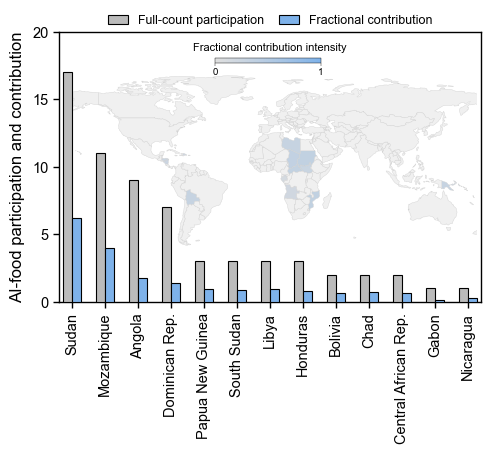

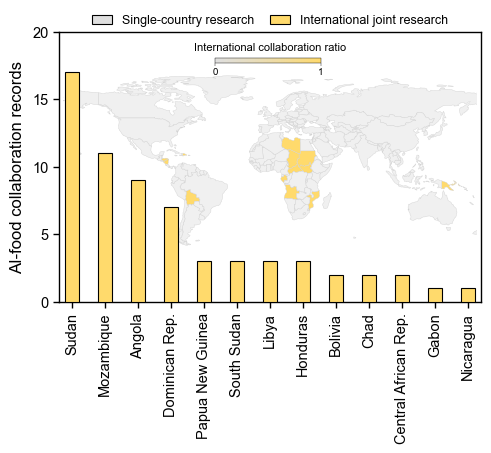

In [89]:
# ============================================================
# Cell 22. Figure 8
#          Collaboration pathways in under-attended AI-food
#          research contexts
#
#          Fig. 8A: Full-count participation vs fractional contribution
#                   among high-need, low-attention countries
#                   Background map: fractional contribution intensity
#
#          Fig. 8B: Single-country vs international joint research
#                   among high-need, low-attention countries
#                   Background map: international collaboration ratio
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
DATA_DIR = Path(".")
OUT_DIR = DATA_DIR / "processed"

PAPER_COUNTRY_IN = OUT_DIR / "14_paper_country_long_food_system_core_main.csv"
MISMATCH_IN = OUT_DIR / "15_country_attention_need_mismatch_food_system_core_main.csv"

if not PAPER_COUNTRY_IN.exists():
    raise FileNotFoundError(f"Missing required file: {PAPER_COUNTRY_IN}")

if not MISMATCH_IN.exists():
    raise FileNotFoundError(f"Missing required file: {MISMATCH_IN}")

paper_country_df = pd.read_csv(PAPER_COUNTRY_IN, low_memory=False)
mismatch_df = pd.read_csv(MISMATCH_IN, low_memory=False)

print("Paper-country table:", paper_country_df.shape)
print("Mismatch table:", mismatch_df.shape)

print("\nPaper-country columns:")
print(paper_country_df.columns.tolist())

print("\nMismatch columns:")
print(mismatch_df.columns.tolist())

display(paper_country_df.head())
display(mismatch_df.head())


# ------------------------------------------------------------
# 1. Figure style
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.major.width"] = 1.0
plt.rcParams["ytick.major.width"] = 1.0
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

TICK_LABEL_SIZE = 10.5
TICK_LENGTH = 4
TICK_WIDTH = 1.0
BOX_LINE_WIDTH = 1.0
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 9
BAR_EDGE_WIDTH = 0.8

def style_axis(ax):
    ax.tick_params(
        axis="both",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        labelsize=TICK_LABEL_SIZE,
        colors="black"
    )

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(BOX_LINE_WIDTH)
        ax.spines[spine].set_color("black")

def integer_formatter(x, pos):
    return f"{int(x)}"


# ------------------------------------------------------------
# 2. Automatic column detection
# ------------------------------------------------------------
def find_first_existing_column(df, candidates, required=True, label="column"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find required {label}. Candidates: {candidates}")
    return None

PC_EID_COL = find_first_existing_column(
    paper_country_df,
    ["eid", "EID", "scopus_id", "paper_id", "record_id", "id"],
    required=True,
    label="paper identifier column"
)

PC_ISO_COL = find_first_existing_column(
    paper_country_df,
    ["iso3", "ISO3", "country_code", "Country Code"],
    required=True,
    label="ISO3 column in paper-country table"
)

PC_COUNTRY_COL = find_first_existing_column(
    paper_country_df,
    ["country_label", "country", "country_name", "Country Name", "Country", "name"],
    required=False,
    label="country name column in paper-country table"
)

PC_FRACTION_COL = find_first_existing_column(
    paper_country_df,
    [
        "fractional_count",
        "fractional_attention",
        "fractional_publication_count",
        "country_fraction",
        "paper_fraction",
        "weight",
    ],
    required=False,
    label="fractional contribution column"
)

M_ISO_COL = find_first_existing_column(
    mismatch_df,
    ["iso3", "ISO3", "country_code", "Country Code"],
    required=True,
    label="ISO3 column in mismatch table"
)

M_COUNTRY_COL = find_first_existing_column(
    mismatch_df,
    ["country_label", "country_need", "country", "country_name", "Country Name", "Country", "name"],
    required=False,
    label="country name column in mismatch table"
)

REGION_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_region", "region", "Region", "wb_region", "world_bank_region"],
    required=False,
    label="region column"
)

INCOME_COL = find_first_existing_column(
    mismatch_df,
    ["analysis_income_group", "income_group", "Income Group", "income", "wb_income_group"],
    required=False,
    label="income group column"
)

QUADRANT_COL = find_first_existing_column(
    mismatch_df,
    [
        "attention_need_quadrant",
        "quadrant",
        "need_attention_quadrant",
        "mismatch_quadrant",
    ],
    required=True,
    label="attention–need quadrant column"
)

NEED_COL = find_first_existing_column(
    mismatch_df,
    [
        "food_system_need_index_main_min4",
        "food_system_need_index",
        "need_index",
        "need_score",
    ],
    required=False,
    label="food-system need index"
)

UNDER_SCORE_COL = find_first_existing_column(
    mismatch_df,
    [
        "capacity_adjusted_under_attention_score",
        "under_attention_score",
        "need_residual_gap_score",
        "need_minus_attention_residual_z",
        "attention_need_mismatch_score",
        "mismatch_score",
    ],
    required=False,
    label="under-attention score"
)

print("\nDetected columns:")
print("PC_EID_COL:", PC_EID_COL)
print("PC_ISO_COL:", PC_ISO_COL)
print("PC_COUNTRY_COL:", PC_COUNTRY_COL)
print("PC_FRACTION_COL:", PC_FRACTION_COL)
print("M_ISO_COL:", M_ISO_COL)
print("M_COUNTRY_COL:", M_COUNTRY_COL)
print("REGION_COL:", REGION_COL)
print("INCOME_COL:", INCOME_COL)
print("QUADRANT_COL:", QUADRANT_COL)
print("NEED_COL:", NEED_COL)
print("UNDER_SCORE_COL:", UNDER_SCORE_COL)


# ------------------------------------------------------------
# 3. Prepare paper-country table
# ------------------------------------------------------------
pc = paper_country_df.copy()

pc["eid_plot"] = pc[PC_EID_COL].astype(str)
pc["iso3_plot"] = pc[PC_ISO_COL].astype(str).str.upper()

if PC_COUNTRY_COL is not None:
    pc["country_label_pc"] = pc[PC_COUNTRY_COL].fillna(pc["iso3_plot"]).astype(str)
else:
    pc["country_label_pc"] = pc["iso3_plot"]

pc = pc.drop_duplicates(subset=["eid_plot", "iso3_plot"]).copy()

paper_country_counts = (
    pc
    .groupby("eid_plot", as_index=False)
    .agg(n_countries=("iso3_plot", "nunique"))
)

pc = pc.merge(paper_country_counts, on="eid_plot", how="left")
pc["is_international"] = pc["n_countries"] >= 2

if PC_FRACTION_COL is not None:
    pc["fractional_contribution_plot"] = pd.to_numeric(pc[PC_FRACTION_COL], errors="coerce")
else:
    pc["fractional_contribution_plot"] = 1 / pc["n_countries"]

pc["fractional_contribution_plot"] = pc["fractional_contribution_plot"].fillna(
    1 / pc["n_countries"]
)

print("\nPrepared paper-country table:", pc.shape)
display(pc.head())


# ------------------------------------------------------------
# 4. Prepare mismatch table and merge
# ------------------------------------------------------------
m = mismatch_df.copy()

m["iso3_plot"] = m[M_ISO_COL].astype(str).str.upper()

if M_COUNTRY_COL is not None:
    m["country_label_plot"] = m[M_COUNTRY_COL].fillna(m["iso3_plot"]).astype(str)
else:
    m["country_label_plot"] = m["iso3_plot"]

if REGION_COL is not None:
    m["region_plot"] = m[REGION_COL].fillna("Not classified").astype(str)
else:
    m["region_plot"] = "Not classified"

if INCOME_COL is not None:
    m["income_plot"] = m[INCOME_COL].fillna("Not classified").astype(str)
else:
    m["income_plot"] = "Not classified"

m["quadrant_plot"] = m[QUADRANT_COL].fillna("middle").astype(str)

if NEED_COL is not None:
    m["need_index_plot"] = pd.to_numeric(m[NEED_COL], errors="coerce")
else:
    m["need_index_plot"] = np.nan

if UNDER_SCORE_COL is not None:
    m["under_attention_score_plot"] = pd.to_numeric(m[UNDER_SCORE_COL], errors="coerce")
else:
    m["under_attention_score_plot"] = np.nan

country_meta = m[
    [
        "iso3_plot",
        "country_label_plot",
        "region_plot",
        "income_plot",
        "quadrant_plot",
        "need_index_plot",
        "under_attention_score_plot",
    ]
].drop_duplicates("iso3_plot")

pcm = pc.merge(country_meta, on="iso3_plot", how="left")

pcm["quadrant_plot"] = pcm["quadrant_plot"].fillna("Not classified")
pcm["region_plot"] = pcm["region_plot"].fillna("Not classified")
pcm["income_plot"] = pcm["income_plot"].fillna("Not classified")
pcm["country_label_plot"] = pcm["country_label_plot"].fillna(pcm["country_label_pc"])

print("\nPaper-country table with mismatch metadata:", pcm.shape)
display(pcm.head())


# ------------------------------------------------------------
# 5. Construct country-level collaboration summary
# ------------------------------------------------------------
target_quadrant = "high_need_low_attention"

hnla_pcm = pcm[pcm["quadrant_plot"] == target_quadrant].copy()

if len(hnla_pcm) == 0:
    raise ValueError(
        "No high-need, low-attention country-paper links found. "
        "Check the quadrant column and labels."
    )

country_collab = (
    hnla_pcm
    .groupby(["iso3_plot", "country_label_plot", "region_plot", "income_plot"], as_index=False)
    .agg(
        full_count_papers=("eid_plot", "nunique"),
        fractional_contribution=("fractional_contribution_plot", "sum"),
        single_country_papers=("is_international", lambda x: int((~x).sum())),
        international_joint_papers=("is_international", lambda x: int(x.sum())),
        international_collaboration_ratio=("is_international", "mean"),
        mean_number_of_countries=("n_countries", "mean"),
        need_index=("need_index_plot", "first"),
        under_attention_score=("under_attention_score_plot", "first"),
    )
)

country_collab["fractional_contribution_intensity"] = (
    country_collab["fractional_contribution"] / country_collab["full_count_papers"]
)

country_collab["international_collaboration_pct"] = (
    country_collab["international_collaboration_ratio"] * 100
)

country_collab["fractional_contribution_intensity_pct"] = (
    country_collab["fractional_contribution_intensity"] * 100
)

country_collab = country_collab.sort_values(
    ["full_count_papers", "under_attention_score"],
    ascending=[False, False]
).copy()

print("\nHigh-need, low-attention country collaboration summary:")
display(country_collab.head(30))

TOP_N = 20
top_collab = country_collab.head(TOP_N).copy()

name_replace = {
    "Somalia, Fed. Rep.": "Somalia",
    "Venezuela, RB": "Venezuela",
    "Yemen, Rep.": "Yemen",
    "Dominican Republic": "Dominican Rep.",
    "Central African Republic": "Central African Rep.",
    "Congo, Dem. Rep.": "Congo, Dem. Rep.",
    "Congo, Rep.": "Congo, Rep.",
}

top_collab["country_label_short"] = (
    top_collab["country_label_plot"].replace(name_replace)
)


# ------------------------------------------------------------
# 6. Check whether B panel values are correctly linked
# ------------------------------------------------------------
check_b = top_collab.copy()
check_b["bar_total"] = check_b["single_country_papers"] + check_b["international_joint_papers"]
check_b["bar_total_equals_full_count"] = check_b["bar_total"].eq(check_b["full_count_papers"])
check_b["ratio_from_bars"] = np.where(
    check_b["full_count_papers"] > 0,
    check_b["international_joint_papers"] / check_b["full_count_papers"],
    np.nan
)
check_b["ratio_matches_map"] = np.isclose(
    check_b["ratio_from_bars"],
    check_b["international_collaboration_ratio"],
    equal_nan=True
)

print("\nCheck for Fig. 8B values:")
display(
    check_b[
        [
            "country_label_plot",
            "full_count_papers",
            "single_country_papers",
            "international_joint_papers",
            "bar_total",
            "bar_total_equals_full_count",
            "ratio_from_bars",
            "international_collaboration_ratio",
            "ratio_matches_map",
        ]
    ]
)

print("Total single-country papers in plotted countries:", check_b["single_country_papers"].sum())
print("Total international joint papers in plotted countries:", check_b["international_joint_papers"].sum())


# ------------------------------------------------------------
# 7. Load world map
# ------------------------------------------------------------
try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "geopandas is required for background maps. Install it first, e.g. pip install geopandas"
    ) from e

NATURAL_EARTH_URL = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

try:
    world = gpd.read_file(NATURAL_EARTH_URL)
except Exception as e:
    raise RuntimeError(
        "Could not load Natural Earth country boundaries from URL. "
        "Check your internet connection, or manually download "
        "'ne_110m_admin_0_countries.zip' from Natural Earth and read it locally."
    ) from e

world = world.copy()

name_col = "NAME" if "NAME" in world.columns else "name"
if name_col in world.columns:
    world = world[world[name_col] != "Antarctica"].copy()

if "ISO_A3" in world.columns:
    world["map_iso3"] = world["ISO_A3"].astype(str).str.upper()
elif "iso_a3" in world.columns:
    world["map_iso3"] = world["iso_a3"].astype(str).str.upper()
else:
    raise KeyError("Natural Earth file does not contain ISO_A3 or iso_a3 column.")

if "ADM0_A3" in world.columns:
    adm0 = world["ADM0_A3"].astype(str).str.upper()
    world.loc[world["map_iso3"].isin(["-99", "NAN", ""]), "map_iso3"] = adm0

world_map_collab = world.merge(
    country_collab,
    left_on="map_iso3",
    right_on="iso3_plot",
    how="left"
)

world_map_collab["fractional_contribution_intensity_map"] = (
    world_map_collab["fractional_contribution_intensity"].clip(0, 1)
)

world_map_collab["international_collaboration_ratio_map"] = (
    world_map_collab["international_collaboration_ratio"].clip(0, 1)
)


# ------------------------------------------------------------
# 8. Background map settings
# ------------------------------------------------------------
# Map slightly lowered and enlarged
map_pos_a = [0.01, 0.03, 0.98, 0.98]
map_pos_b = [0.01, 0.03, 0.98, 0.98]

# Shorter colorbar centered above the map
label_x = 0.50
label_y = 0.925
cbar_pos = [0.37, 0.885, 0.25, 0.018]

cmap_a = LinearSegmentedColormap.from_list(
    "gray_to_skyblue",
    ["#D4D4D4BB", "#7EB2EA"]
)

# 0 = single-country side = green
# 1 = international joint side = peach
cmap_b = LinearSegmentedColormap.from_list(
    "lightgreen_to_peach",
    ["#D4D4D4BB", "#FFDA6C"]
)

norm_01 = Normalize(vmin=0, vmax=1)


# ============================================================
# Fig. 8A. Full-count participation vs fractional contribution
# ============================================================
fig, ax = plt.subplots(figsize=(6.4, 5.4))

ax.set_zorder(2)
ax.patch.set_alpha(0)

plot_a = top_collab.copy().reset_index(drop=True)

# Map
axins = ax.inset_axes(map_pos_a, zorder=0)

world_map_collab.plot(
    column="fractional_contribution_intensity_map",
    cmap=cmap_a,
    vmin=0,
    vmax=1,
    linewidth=0.3,
    edgecolor="lightgray",
    missing_kwds={"color": "#F0F0F0"},
    ax=axins
)

axins.set_xlim(-170, 170)
axins.set_ylim(-58, 85)
axins.set_aspect("equal", adjustable="box")
axins.margins(0)
axins.set_axis_off()

# Colorbar
ax.text(
    label_x,
    label_y,
    "Fractional contribution intensity",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8
)

cax = ax.inset_axes(cbar_pos, zorder=10)
cax.patch.set_alpha(0)

sm = ScalarMappable(norm=norm_01, cmap=cmap_a)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_ticks([0, 1])
cb.ax.tick_params(labelsize=7, length=2, pad=1, width=0.3)
cb.outline.set_linewidth(0.3)

# Bars
x = np.arange(len(plot_a))
bar_width = 0.28

ax.bar(
    x - bar_width / 2,
    plot_a["full_count_papers"],
    width=bar_width,
    color="#BBBBBB",
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="Full-count participation",
    zorder=5
)

ax.bar(
    x + bar_width / 2,
    plot_a["fractional_contribution"],
    width=bar_width,
    color="#7EB2EA",
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="Fractional contribution",
    zorder=5
)

ax.set_ylabel("AI-food participation and contribution", fontsize=AXIS_LABEL_SIZE, labelpad=0)
ax.yaxis.set_label_coords(-0.08, 0.5)

ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(
    plot_a["country_label_short"],
    rotation=90,
    ha="center",
    fontsize=TICK_LABEL_SIZE
)

ax.set_ylim(0, 20)
ax.set_yticks(np.arange(0, 21, 5))
ax.yaxis.set_major_formatter(FuncFormatter(integer_formatter))
ax.set_xlim(-0.4, len(plot_a) - 0.6)

ax.legend(
    frameon=False,
    fontsize=LEGEND_SIZE,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    borderaxespad=0.0,
    ncol=2,
    columnspacing=1.2,
    handlelength=1.6
)

style_axis(ax)

fig.subplots_adjust(
    left=0.32,
    right=0.98,
    bottom=0.34,
    top=0.84
)

plt.show()


# ============================================================
# Fig. 8B. Single-country vs international joint research
# ============================================================
fig, ax = plt.subplots(figsize=(6.4, 5.4))

ax.set_zorder(2)
ax.patch.set_alpha(0)

plot_b = top_collab.copy().reset_index(drop=True)

# Map
axins = ax.inset_axes(map_pos_b, zorder=0)

world_map_collab.plot(
    column="international_collaboration_ratio_map",
    cmap=cmap_b,
    vmin=0,
    vmax=1,
    linewidth=0.3,
    edgecolor="lightgray",
    missing_kwds={"color": "#F0F0F0"},
    ax=axins
)

axins.set_xlim(-170, 170)
axins.set_ylim(-58, 85)
axins.set_aspect("equal", adjustable="box")
axins.margins(0)
axins.set_axis_off()

# Colorbar
ax.text(
    label_x,
    label_y,
    "International collaboration ratio",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8
)

cax = ax.inset_axes(cbar_pos, zorder=10)
cax.patch.set_alpha(0)

sm = ScalarMappable(norm=norm_01, cmap=cmap_b)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_ticks([0, 1])
cb.ax.tick_params(labelsize=7, length=2, pad=1, width=0.3)
cb.outline.set_linewidth(0.3)

# Bars
x = np.arange(len(plot_b))

ax.bar(
    x,
    plot_b["single_country_papers"],
    width=0.42,
    color="#D4D4D4BB",
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="Single-country research",
    zorder=5
)

ax.bar(
    x,
    plot_b["international_joint_papers"],
    bottom=plot_b["single_country_papers"],
    width=0.42,
    color="#FFDA6C",
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="International joint research",
    zorder=5
)

ax.set_ylabel("AI-food collaboration records", fontsize=AXIS_LABEL_SIZE, labelpad=0)
ax.yaxis.set_label_coords(-0.08, 0.5)

ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(
    plot_b["country_label_short"],
    rotation=90,
    ha="center",
    fontsize=TICK_LABEL_SIZE
)

ax.set_ylim(0, 20)
ax.set_yticks(np.arange(0, 21, 5))
ax.yaxis.set_major_formatter(FuncFormatter(integer_formatter))
ax.set_xlim(-0.4, len(plot_b) - 0.6)

ax.legend(
    frameon=False,
    fontsize=LEGEND_SIZE,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    borderaxespad=0.0,
    ncol=2,
    columnspacing=1.2,
    handlelength=1.6
)

style_axis(ax)

fig.subplots_adjust(
    left=0.32,
    right=0.98,
    bottom=0.34,
    top=0.84
)

plt.show()